In [4]:
import minari
from gymnasium_robotics.envs.maze.maze_v4 import MazeEnv

dataset = minari.load_dataset('D4RL/pointmaze/large-v2', download=True)
# env  = dataset.recover_environment()
print(type(dataset))
print("Observation space:", dataset.observation_space)
print("Action space:", dataset.action_space)
print("Total episodes:", dataset.total_episodes)
print("Total steps:", dataset.total_steps)

<class 'minari.dataset.minari_dataset.MinariDataset'>
Observation space: Dict('achieved_goal': Box(-inf, inf, (2,), float64), 'desired_goal': Box(-inf, inf, (2,), float64), 'observation': Box(-inf, inf, (4,), float64))
Action space: Box(-1.0, 1.0, (2,), float32)
Total episodes: 3360
Total steps: 1000000


### Test the theoretical boundary coordinate, even if it is a wall.

COMPLETE ENVIRONMENT BOUNDARY ANALYSIS
Environment ID: PointMaze_Large-v3
Maze type: <class 'gymnasium_robotics.envs.maze.maze_v4.Maze'>
Maze size scaling: 1
Maze grid dimensions: 9 x 12 cells
Cell size: 1.0m x 1.0m

THEORETICAL GRID BOUNDARIES (INCLUDING WALLS)
Complete grid edges:
  Left edge   (min X):   -6.0m
  Right edge  (max X):    6.0m
  Bottom edge (min Y):   -4.5m
  Top edge    (max Y):    4.5m

Complete environment size:
  Width:  12.0m (12 cells × 1.0m)
  Height: 9.0m (9 cells × 1.0m)

Theoretical bounding box (for discretization):
  X range: [  -6.0,    6.0]
  Y range: [  -4.5,    4.5]

ACCESSIBLE BOUNDARIES (REACHABLE AREAS ONLY)
Accessible coordinate boundaries:
  X range: [-4.500, 4.500]
  Y range: [-3.000, 3.000]

Accessible boundaries (including ±0.25 noise):
  X range: [-4.750, 4.750]
  Y range: [-3.250, 3.250]

DATASET VERIFICATION
Dataset positions (from 100 episodes):
  X range: [-4.787, 4.713]
  Y range: [-3.269, 3.214]

DISCRETIZATION OPTIONS

Original (1:1): 9×

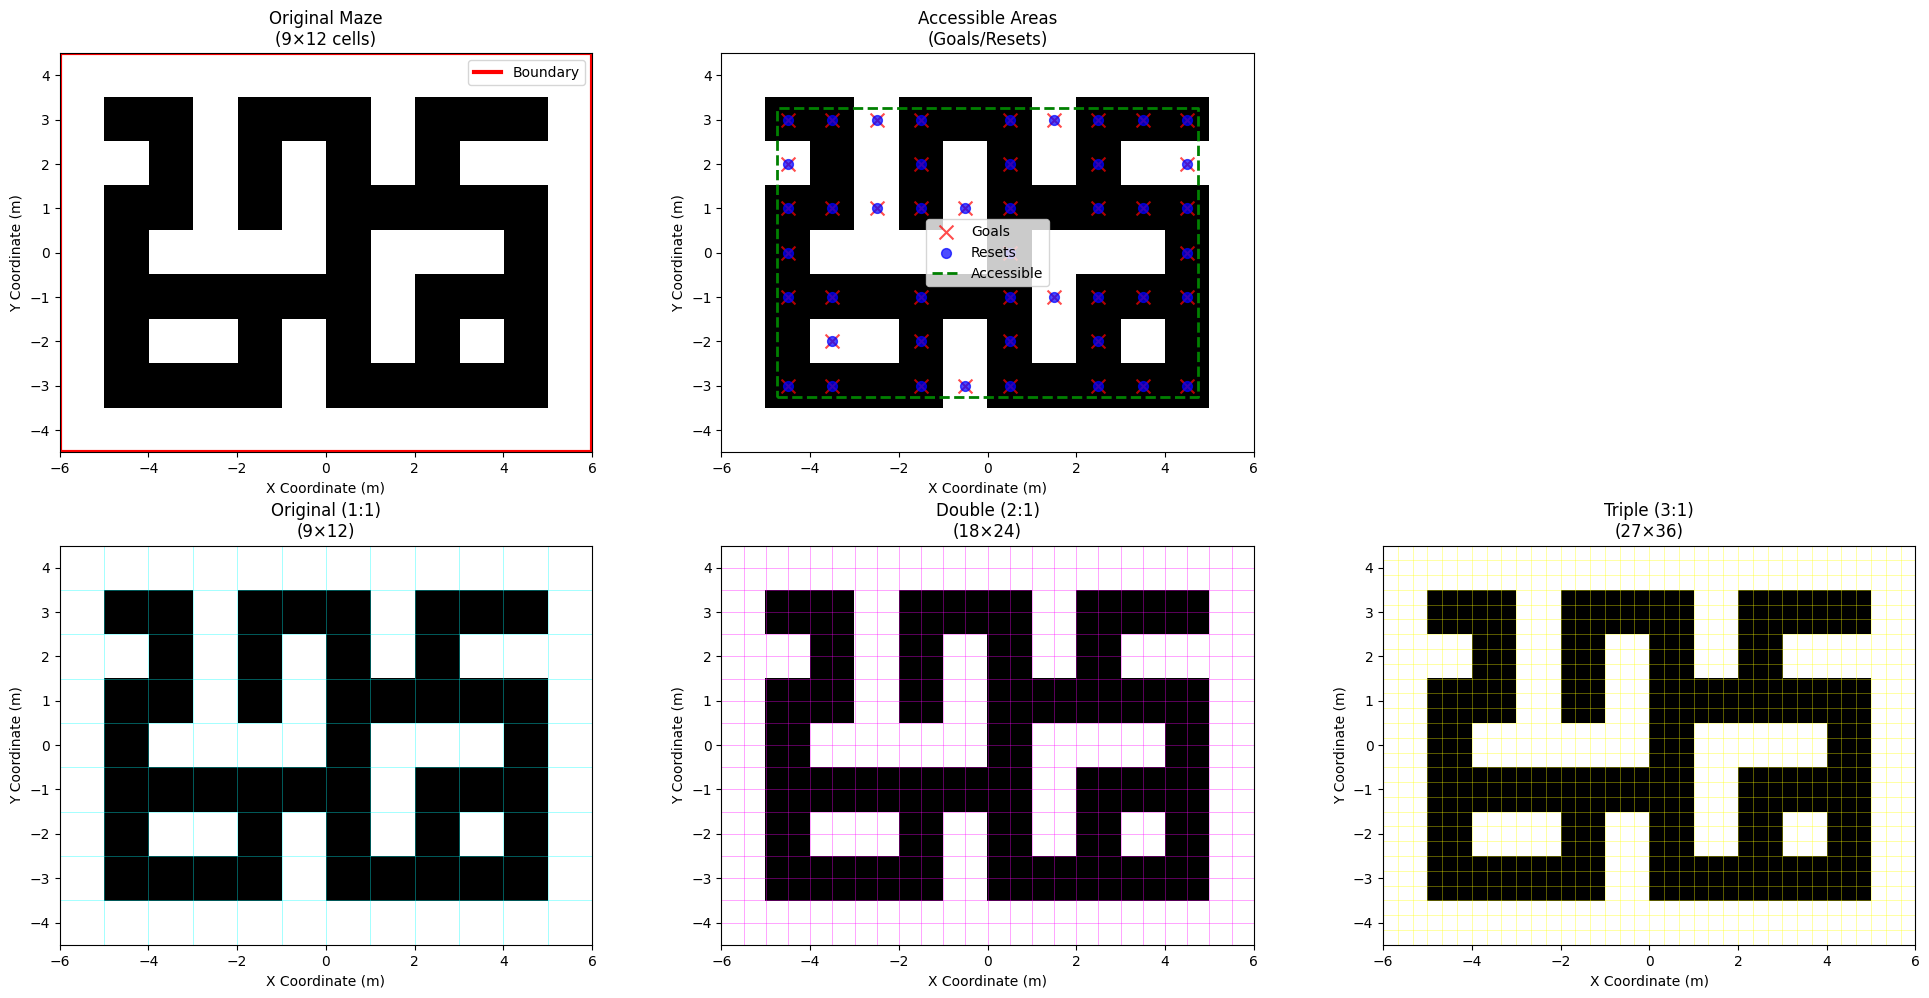


SUMMARY FOR YOUR DISCRETIZATION OPTIONS
✓ Use THEORETICAL boundaries: X[-6.0, 6.0], Y[-4.5, 4.5]
✓ Total environment: 12.0m × 9.0m
✓ Original maze: 9×12 = 108 cells
✓ Original (1:1): 9×12 = 108 cells (1.000m × 1.000m each)
✓ Double (2:1): 18×24 = 432 cells (0.500m × 0.500m each)
✓ Triple (3:1): 27×36 = 972 cells (0.333m × 0.333m each)


In [5]:
# Fix the array indexing issue
import minari
import gymnasium as gym
import gymnasium_robotics
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
dataset = minari.load_dataset('D4RL/pointmaze/large-v2', download=True)

# Create the corresponding gymnasium environment
gym.register_envs(gymnasium_robotics)
env = gym.make("PointMaze_Large-v3")

print("COMPLETE ENVIRONMENT BOUNDARY ANALYSIS")
print("=" * 60)

# Get the unwrapped environment to access maze properties
unwrapped_env = env.unwrapped
maze = unwrapped_env.maze

print(f"Environment ID: {env.spec.id}")
print(f"Maze type: {type(maze)}")
print(f"Maze size scaling: {maze.maze_size_scaling}")

# Get the maze map
maze_map = maze.maze_map
rows, cols = len(maze_map), len(maze_map[0])
cell_size = 1.0  # Each cell is 1m x 1m

print(f"Maze grid dimensions: {rows} x {cols} cells")
print(f"Cell size: {cell_size}m x {cell_size}m")

# THEORETICAL BOUNDARIES (including walls) - This is what you want!
print(f"\n" + "="*60)
print("THEORETICAL GRID BOUNDARIES (INCLUDING WALLS)")
print("="*60)

# Calculate the four edges of the complete grid
# The grid is centered at origin (0,0)
left_edge = -(cols - 1) / 2 - 0.5    # -6.0
right_edge = (cols - 1) / 2 + 0.5    # +6.0  
bottom_edge = -(rows - 1) / 2 - 0.5  # -4.5
top_edge = (rows - 1) / 2 + 0.5      # +4.5

print(f"Complete grid edges:")
print(f"  Left edge   (min X): {left_edge:6.1f}m")
print(f"  Right edge  (max X): {right_edge:6.1f}m") 
print(f"  Bottom edge (min Y): {bottom_edge:6.1f}m")
print(f"  Top edge    (max Y): {top_edge:6.1f}m")

total_width = right_edge - left_edge
total_height = top_edge - bottom_edge

print(f"\nComplete environment size:")
print(f"  Width:  {total_width:.1f}m ({cols} cells × {cell_size}m)")
print(f"  Height: {total_height:.1f}m ({rows} cells × {cell_size}m)")

print(f"\nTheoretical bounding box (for discretization):")
print(f"  X range: [{left_edge:6.1f}, {right_edge:6.1f}]")
print(f"  Y range: [{bottom_edge:6.1f}, {top_edge:6.1f}]")

# ACCESSIBLE BOUNDARIES (reachable areas only)
print(f"\n" + "="*60)
print("ACCESSIBLE BOUNDARIES (REACHABLE AREAS ONLY)")
print("="*60)

goal_locations = maze.unique_goal_locations
reset_locations = maze.unique_reset_locations

# Convert to numpy arrays to fix the indexing issue
goal_locations_array = np.array(goal_locations)
reset_locations_array = np.array(reset_locations)
all_positions = np.vstack([goal_locations_array, reset_locations_array])

x_min, x_max = all_positions[:, 0].min(), all_positions[:, 0].max()
y_min, y_max = all_positions[:, 1].min(), all_positions[:, 1].max()

print(f"Accessible coordinate boundaries:")
print(f"  X range: [{x_min:.3f}, {x_max:.3f}]")
print(f"  Y range: [{y_min:.3f}, {y_max:.3f}]")

# Account for position noise
noise_range = unwrapped_env.position_noise_range
effective_x_min = x_min - noise_range
effective_x_max = x_max + noise_range
effective_y_min = y_min - noise_range
effective_y_max = y_max + noise_range

print(f"\nAccessible boundaries (including ±{noise_range} noise):")
print(f"  X range: [{effective_x_min:.3f}, {effective_x_max:.3f}]")
print(f"  Y range: [{effective_y_min:.3f}, {effective_y_max:.3f}]")

# VERIFICATION WITH DATASET (fix the iteration)
print(f"\n" + "="*60)
print("DATASET VERIFICATION")
print("="*60)

dataset_positions = []
episode_count = 0

# Fix: Use iterate_episodes() instead of get_episode()
for episode in dataset.iterate_episodes():
    if episode_count >= 100:  # Sample first 100 episodes
        break
    
    observations = episode.observations
    if isinstance(observations, dict) and 'achieved_goal' in observations:
        positions = observations['achieved_goal']
        dataset_positions.extend(positions)
    
    episode_count += 1

if dataset_positions:
    dataset_positions = np.array(dataset_positions)
    dataset_x_min, dataset_x_max = dataset_positions[:, 0].min(), dataset_positions[:, 0].max()
    dataset_y_min, dataset_y_max = dataset_positions[:, 1].min(), dataset_positions[:, 1].max()
    
    print(f"Dataset positions (from {episode_count} episodes):")
    print(f"  X range: [{dataset_x_min:.3f}, {dataset_x_max:.3f}]")
    print(f"  Y range: [{dataset_y_min:.3f}, {dataset_y_max:.3f}]")

# MULTIPLE DISCRETIZATION OPTIONS
print(f"\n" + "="*60)
print("DISCRETIZATION OPTIONS")
print("="*60)

# Define different discretization options (removed 32×32)
discretization_options = [
    (9, 12, "Original (1:1)"),
    (18, 24, "Double (2:1)"), 
    (27, 36, "Triple (3:1)")
]

# General function to discretize any (x,y) position to any grid size
def discretize_position(x, y, grid_rows, grid_cols):
    """Convert (x,y) to discrete grid indices for any grid size"""
    # Normalize to [0, 1] range
    x_norm = (x - left_edge) / total_width
    y_norm = (y - bottom_edge) / total_height
    
    # Convert to grid indices [0, grid_size-1]
    grid_x = int(np.clip(x_norm * grid_cols, 0, grid_cols - 1))
    grid_y = int(np.clip(y_norm * grid_rows, 0, grid_rows - 1))
    
    return grid_x, grid_y

# Display discretization options
for grid_rows, grid_cols, description in discretization_options:
    cell_width = total_width / grid_cols
    cell_height = total_height / grid_rows
    
    print(f"\n{description}: {grid_rows}×{grid_cols} discretization")
    print(f"  Each cell: {cell_width:.3f}m × {cell_height:.3f}m")
    print(f"  Total cells: {grid_rows * grid_cols}")
    
    # Test discretization with example positions
    test_positions = [(0.0, 0.0), (-6.0, -4.5), (6.0, 4.5), (-2.5, 1.0)]
    print(f"  Example discretizations:")
    for x, y in test_positions:
        grid_x, grid_y = discretize_position(x, y, grid_rows, grid_cols)
        print(f"    Position ({x:5.1f}, {y:5.1f}) → Grid ({grid_x:2d}, {grid_y:2d})")

# VISUALIZATION - Show all discretization options
plt.figure(figsize=(20, 10))

# Plot 1: Complete maze with theoretical boundaries
plt.subplot(2, 3, 1)
maze_array = np.array(maze_map, dtype=float)
plt.imshow(maze_array, cmap='gray', origin='lower', 
          extent=[left_edge, right_edge, bottom_edge, top_edge])
plt.title('Original Maze\n(9×12 cells)')
plt.xlabel('X Coordinate (m)')
plt.ylabel('Y Coordinate (m)')

# Add theoretical boundary rectangle
rect_x = [left_edge, right_edge, right_edge, left_edge, left_edge]
rect_y = [bottom_edge, bottom_edge, top_edge, top_edge, bottom_edge]
plt.plot(rect_x, rect_y, 'r-', linewidth=3, label='Boundary')
plt.legend()

# Plot 2: Accessible areas with boundaries
plt.subplot(2, 3, 2)
plt.imshow(maze_array, cmap='gray', origin='lower',
          extent=[left_edge, right_edge, bottom_edge, top_edge])

# Fix: Use the numpy arrays for indexing
goal_x, goal_y = goal_locations_array[:, 0], goal_locations_array[:, 1]
reset_x, reset_y = reset_locations_array[:, 0], reset_locations_array[:, 1]

plt.scatter(goal_x, goal_y, c='red', marker='x', s=100, label='Goals', alpha=0.7)
plt.scatter(reset_x, reset_y, c='blue', marker='o', s=50, label='Resets', alpha=0.7)

# Accessible boundary rectangle
acc_rect_x = [effective_x_min, effective_x_max, effective_x_max, effective_x_min, effective_x_min]
acc_rect_y = [effective_y_min, effective_y_min, effective_y_max, effective_y_max, effective_y_min]
plt.plot(acc_rect_x, acc_rect_y, 'g--', linewidth=2, label='Accessible')

plt.title('Accessible Areas\n(Goals/Resets)')
plt.xlabel('X Coordinate (m)')
plt.ylabel('Y Coordinate (m)')
plt.legend()

# Plot discretization overlays
colors = ['cyan', 'magenta', 'yellow']
plot_positions = [(2, 3, 4), (2, 3, 5), (2, 3, 6)]

for idx, ((grid_rows, grid_cols, description), color, plot_pos) in enumerate(zip(discretization_options, colors, plot_positions)):
    plt.subplot(*plot_pos)
    plt.imshow(maze_array, cmap='gray', origin='lower',
              extent=[left_edge, right_edge, bottom_edge, top_edge])
    
    cell_width = total_width / grid_cols
    cell_height = total_height / grid_rows
    
    # Add grid lines
    for i in range(grid_cols + 1):  # +1 for boundary lines
        x_line = left_edge + i * cell_width
        plt.axvline(x_line, color=color, alpha=0.5, linewidth=0.5)
    
    for i in range(grid_rows + 1):  # +1 for boundary lines
        y_line = bottom_edge + i * cell_height
        plt.axhline(y_line, color=color, alpha=0.5, linewidth=0.5)
    
    plt.title(f'{description}\n({grid_rows}×{grid_cols})')
    plt.xlabel('X Coordinate (m)')
    plt.ylabel('Y Coordinate (m)')

plt.tight_layout()
plt.show()

print(f"\n" + "="*60)
print("SUMMARY FOR YOUR DISCRETIZATION OPTIONS")
print("="*60)
print(f"✓ Use THEORETICAL boundaries: X[{left_edge:.1f}, {right_edge:.1f}], Y[{bottom_edge:.1f}, {top_edge:.1f}]")
print(f"✓ Total environment: {total_width:.1f}m × {total_height:.1f}m")
print(f"✓ Original maze: {rows}×{cols} = {rows*cols} cells")
for grid_rows, grid_cols, description in discretization_options:
    cell_width = total_width / grid_cols
    cell_height = total_height / grid_rows
    print(f"✓ {description}: {grid_rows}×{grid_cols} = {grid_rows*grid_cols} cells ({cell_width:.3f}m × {cell_height:.3f}m each)")

env.close()

### Function: observation_to_grid()

First, for the 9 by 12 version, call each grid g_(1,1) to g_(9,12), then write a function to map the observation, where the last two dimensions correspond to the $(x,y) \in \mathbb{R}^2$, to the corresponding grid.

When calculating grid index, do it as if we are in a matrix, and use matrix index. the upper-left corner with range $x\in [-6,-5]$, $y\in [3.5,4.5]$ is (1,1). And there is no (0,0) in this logic. When dealing with the boundary, count it towards the previous range. For example, [*,1] is at the boundary of (*, 7) and (*,8) but counted towards (*, 7).

In [6]:
# CORRECTED OBSERVATION TO GRID MAPPING FUNCTION (MATRIX INDEXING)
print("=" * 60)
print("OBSERVATION TO GRID MAPPING (MATRIX STYLE) - CORRECTED COORDINATES")
print("=" * 60)

def observation_to_grid(observation, grid_rows=9, grid_cols=12):
    """
    Map observation to grid cell using MATRIX-STYLE indexing g_(1,1) to g_(9,12).
    
    CORRECTED Matrix indexing convention based on actual environment:
    - Upper-left corner x∈[-6.0,-5.0), y∈(3.5,4.5] is g_(1,1) 
    - Center (0,0) should be around g_(5,7) 
    - Boundary rule: count toward "previous range"
    
    Environment boundaries: X[-6.0, 6.0], Y[-4.5, 4.5]
    Grid size: 9 rows × 12 columns
    Cell size: 1.0m × 1.0m each
    
    Args:
        observation: Dictionary containing 'achieved_goal' with (x, y) coordinates
        grid_rows: Number of rows in discretization grid (default: 9)
        grid_cols: Number of columns in discretization grid (default: 12)
    
    Returns:
        grid_name: String like 'g_(5,7)' using 1-based matrix indexing
        grid_coords_matrix: Tuple (row, col) using 1-based indexing [1-9, 1-12]
    """
    # Extract (x, y) coordinates from observation
    if isinstance(observation, dict) and 'achieved_goal' in observation:
        x, y = observation['achieved_goal'][0], observation['achieved_goal'][1]
    elif isinstance(observation, (list, tuple, np.ndarray)) and len(observation) >= 2:
        x, y = observation[0], observation[1]
    else:
        raise ValueError(f"Invalid observation format: {type(observation)}")
    
    # Calculate cell dimensions
    cell_width = total_width / grid_cols    # 12.0 / 12 = 1.0m
    cell_height = total_height / grid_rows  # 9.0 / 9 = 1.0m
    
    # X direction (columns): Left to right, 1-based indexing
    # Based on actual environment boundaries X[-6.0, 6.0]:
    # Col 1: x∈[-6.0,-5.0), Col 2: x∈[-5.0,-4.0), ..., Col 7: x∈[0.0,1.0), ..., Col 12: x∈[5.0,6.0]
    if x < left_edge:  # x < -6.0 edge case
        col = 1
    elif x >= right_edge:  # x >= 6.0 edge case  
        col = grid_cols
    else:
        # Standard case: find which column
        col = int((x - left_edge) / cell_width) + 1
        
        # Handle boundary case: boundaries count toward "previous range"
        # For X direction, if exactly on boundary, count toward lower column
        if abs(x - (left_edge + (col-1) * cell_width)) < 1e-10 and col > 1:
            col = col - 1
            
        col = max(1, min(col, grid_cols))
    
    # Y direction (rows): Top to bottom, 1-based matrix indexing  
    # Based on actual environment boundaries Y[-4.5, 4.5]:
    # Row 1: y∈(3.5,4.5], Row 2: y∈(2.5,3.5], Row 3: y∈(1.5,2.5], Row 4: y∈(0.5,1.5], 
    # Row 5: y∈(-0.5,0.5], Row 6: y∈(-1.5,-0.5], Row 7: y∈(-2.5,-1.5], Row 8: y∈(-3.5,-2.5], Row 9: y∈[-4.5,-3.5]
    
    if y <= bottom_edge:  # y <= -4.5 edge case
        row = grid_rows
    elif y > top_edge:   # y > 4.5 edge case
        row = 1
    else:
        # Calculate row based on Y value
        # Find which row by calculating distance from top
        y_offset_from_top = top_edge - y  # How far down from top edge
        row = int(y_offset_from_top / cell_height) + 1
        
        # CORRECTED boundary handling: Y=1.5 should go to Row 3 (previous range)
        # Check if we're exactly on a row boundary (Y = ...5)
        if abs(y % 1.0 - 0.5) < 1e-10:  # Y ends in .5 (boundary)
            # For Y=1.5: normally goes to Row 4, but boundary rule sends to Row 3
            # For Y=0.5: normally goes to Row 5, but boundary rule sends to Row 4  
            # For Y=-0.5: normally goes to Row 6, but boundary rule sends to Row 5
            if row > 1:  # Don't go above Row 1
                row = row - 1
            
        row = max(1, min(row, grid_rows))
    
    grid_name = f"g_({row},{col})"
    
    return grid_name, (row, col)

# Create helper function to get grid cell bounds
def get_matrix_grid_bounds(row, col, grid_rows=9, grid_cols=12):
    """Get the coordinate bounds for a specific matrix grid cell."""
    cell_width = total_width / grid_cols
    cell_height = total_height / grid_rows
    
    # X bounds for column
    x_left = left_edge + (col - 1) * cell_width
    x_right = left_edge + col * cell_width
    
    # Y bounds for row  
    y_top = top_edge - (row - 1) * cell_height
    y_bottom = top_edge - row * cell_height
    
    return {
        'x_range': (x_left, x_right),
        'y_range': (y_bottom, y_top),
        'x_interval': f"[{x_left:.1f}, {x_right:.1f})" if col < grid_cols else f"[{x_left:.1f}, {x_right:.1f}]",
        'y_interval': f"({y_bottom:.1f}, {y_top:.1f}]" if row > 1 else f"[{y_bottom:.1f}, {y_top:.1f}]"
    }

# Test the CORRECTED function with actual environment coordinates
print("Testing CORRECTED matrix-style grid mapping:")
print(f"Environment: X[{left_edge:.1f}, {right_edge:.1f}], Y[{bottom_edge:.1f}, {top_edge:.1f}]")
print(f"Grid: {rows} rows × {cols} columns")

# Show some key grid cells and their actual coordinate ranges
print(f"\nKey grid cell coordinate ranges:")
key_cells = [(1, 1), (1, 12), (5, 7), (9, 1), (9, 12)]
for r, c in key_cells:
    bounds = get_matrix_grid_bounds(r, c)
    print(f"g_({r},{c}): X{bounds['x_interval']}, Y{bounds['y_interval']}")

# Critical test cases with corrected expected values
critical_tests = [
    ("Center", 0.0, 0.0, "g_(5,6)"),        # CORRECTED: X=0 → col 6, Y=0 → row 5
    ("Upper-left corner", -5.5, 4.0, "g_(1,1)"),   # Should be in g_(1,1)
    ("Upper-right corner", 5.5, 4.0, "g_(1,12)"),  # Should be in g_(1,12)
    ("Bottom-left corner", -5.5, -4.0, "g_(9,1)"), # Should be in g_(9,1)
    ("Bottom-right corner", 5.5, -4.0, "g_(9,12)"),# Should be in g_(9,12)
    ("Y=1.5 boundary", -2.0, 1.5, "g_(3,4)"),      # CORRECTED: Y=1.5 boundary → row 3, X=-2 → col 4
    ("Y=0.5 boundary", 0.0, 0.5, "g_(4,6)"),       # CORRECTED: Y=0.5 boundary → row 4, X=0 → col 6
    ("Y=-0.5 boundary", 0.0, -0.5, "g_(5,6)"),     # CORRECTED: Y=-0.5 boundary → row 5, X=0 → col 6
    ("Edge boundaries", -6.0, 4.5, "g_(1,1)"),     # Exact edges
    ("Edge boundaries", 6.0, -4.5, "g_(9,12)"),    # Exact edges
]

print(f"\n{'Test Case':<25} | {'Position':<12} | {'Result':<12} | {'Expected':<12} | {'Match'}")
print("-" * 90)

for name, x, y, expected in critical_tests:
    obs = {'achieved_goal': np.array([x, y])}
    grid_name, (row, col) = observation_to_grid(obs)
    match = "✓" if expected == grid_name else "✗"
    pos_str = f"({x:5.1f},{y:5.1f})"
    print(f"{name:<25} | {pos_str:<12} | {grid_name:<12} | {expected:<12} | {match}")

# Show detailed row and column mappings
print(f"\n" + "="*60)
print("DETAILED GRID MAPPING")
print("="*60)

print("Column boundaries:")
for c in range(1, cols + 1):
    bounds = get_matrix_grid_bounds(5, c)  # Use row 5 as example
    print(f"Col {c:2d}: X{bounds['x_interval']}")

print(f"\nRow boundaries:")
for r in range(1, rows + 1):
    bounds = get_matrix_grid_bounds(r, 7)  # Use col 7 as example
    contains_center = bounds['y_range'][0] < 0.0 <= bounds['y_range'][1]
    marker = " ← contains (0,0)" if contains_center else ""
    print(f"Row {r}: Y{bounds['y_interval']}{marker}")

OBSERVATION TO GRID MAPPING (MATRIX STYLE) - CORRECTED COORDINATES
Testing CORRECTED matrix-style grid mapping:
Environment: X[-6.0, 6.0], Y[-4.5, 4.5]
Grid: 9 rows × 12 columns

Key grid cell coordinate ranges:
g_(1,1): X[-6.0, -5.0), Y[3.5, 4.5]
g_(1,12): X[5.0, 6.0], Y[3.5, 4.5]
g_(5,7): X[0.0, 1.0), Y(-0.5, 0.5]
g_(9,1): X[-6.0, -5.0), Y(-4.5, -3.5]
g_(9,12): X[5.0, 6.0], Y(-4.5, -3.5]

Test Case                 | Position     | Result       | Expected     | Match
------------------------------------------------------------------------------------------
Center                    | (  0.0,  0.0) | g_(5,6)      | g_(5,6)      | ✓
Upper-left corner         | ( -5.5,  4.0) | g_(1,1)      | g_(1,1)      | ✓
Upper-right corner        | (  5.5,  4.0) | g_(1,12)     | g_(1,12)     | ✓
Bottom-left corner        | ( -5.5, -4.0) | g_(9,1)      | g_(9,1)      | ✓
Bottom-right corner       | (  5.5, -4.0) | g_(9,12)     | g_(9,12)     | ✓
Y=1.5 boundary            | ( -2.0,  1.5) | g_(3,4)     

### Now, following the same logic, create the mapping functions for $18*24$ and $27*36$ tabularizations.

In [1]:
# 18×24 AND 27×36 GRID MAPPING FUNCTIONS
print("=" * 80)
print("HIGHER RESOLUTION GRID MAPPING FUNCTIONS")
print("=" * 80)

def observation_to_grid_18x24(observation):
    """
    Map observation to 18×24 grid (double resolution: 0.5m × 0.5m cells).
    Each original 9×12 cell is subdivided into 2×2 = 4 subcells.
    """
    return observation_to_grid(observation, grid_rows=18, grid_cols=24)

def observation_to_grid_27x36(observation):
    """
    Map observation to 27×36 grid (triple resolution: 0.333m × 0.333m cells).
    Each original 9×12 cell is subdivided into 3×3 = 9 subcells.
    """
    return observation_to_grid(observation, grid_rows=27, grid_cols=36)

def get_grid_bounds_18x24(row, col):
    """Get coordinate bounds for 18×24 grid cell."""
    return get_matrix_grid_bounds(row, col, grid_rows=18, grid_cols=24)

def get_grid_bounds_27x36(row, col):
    """Get coordinate bounds for 27×36 grid cell."""
    return get_matrix_grid_bounds(row, col, grid_rows=27, grid_cols=36)

# TEST ALL THREE DISCRETIZATION LEVELS
print("\nTesting all discretization levels with same test points:")
print("=" * 80)

test_positions = [
    ("Center", 0.0, 0.0),
    ("Upper-left corner", -5.5, 4.0),
    ("Y=1.5 boundary", -2.0, 1.5),
    ("Y=0.5 boundary", 0.0, 0.5),
    ("Precise test", -1.25, 0.75),  # Test subdivision precision
]

for name, x, y in test_positions:
    obs = {'achieved_goal': np.array([x, y])}
    
    # Test all three resolutions
    grid_9x12, _ = observation_to_grid(obs, 9, 12)
    grid_18x24, _ = observation_to_grid_18x24(obs)
    grid_27x36, _ = observation_to_grid_27x36(obs)
    
    print(f"{name:<20} ({x:5.1f},{y:5.1f}): 9×12={grid_9x12:<10} 18×24={grid_18x24:<12} 27×36={grid_27x36}")

# DETAILED GRID SPECIFICATIONS
print(f"\n" + "="*80)
print("DETAILED GRID SPECIFICATIONS")
print("="*80)

grid_specs = [
    (9, 12, "Original"),
    (18, 24, "Double"), 
    (27, 36, "Triple")
]

for rows, cols, name in grid_specs:
    cell_width = total_width / cols
    cell_height = total_height / rows
    total_cells = rows * cols
    
    print(f"\n{name} Resolution ({rows}×{cols}):")
    print(f"  Cell size: {cell_width:.3f}m × {cell_height:.3f}m")
    print(f"  Total cells: {total_cells:,}")
    print(f"  State space size: {total_cells}")

# SHOW SUBDIVISION RELATIONSHIP
print(f"\n" + "="*80)
print("SUBDIVISION RELATIONSHIP")
print("="*80)

print("How original 9×12 cells map to higher resolutions:")
original_test_cells = [(1,1), (5,6), (9,12)]

for orig_row, orig_col in original_test_cells:
    print(f"\nOriginal g_({orig_row},{orig_col}) subdivides into:")
    
    # Get bounds of original cell
    orig_bounds = get_matrix_grid_bounds(orig_row, orig_col, 9, 12)
    x_left, x_right = orig_bounds['x_range']
    y_bottom, y_top = orig_bounds['y_range']
    
    # Test center of original cell
    center_x = (x_left + x_right) / 2
    center_y = (y_bottom + y_top) / 2
    
    obs_center = {'achieved_goal': np.array([center_x, center_y])}
    _, (row_18, col_18) = observation_to_grid_18x24(obs_center)
    _, (row_27, col_27) = observation_to_grid_27x36(obs_center)
    
    print(f"  18×24: center at g_({row_18},{col_18})")
    print(f"  27×36: center at g_({row_27},{col_27})")
    
    # Show subdivision ranges for 18×24
    start_row_18 = ((orig_row - 1) * 2) + 1
    end_row_18 = start_row_18 + 1
    start_col_18 = ((orig_col - 1) * 2) + 1  
    end_col_18 = start_col_18 + 1
    
    print(f"  18×24 range: rows {start_row_18}-{end_row_18}, cols {start_col_18}-{end_col_18}")
    
    # Show subdivision ranges for 27×36
    start_row_27 = ((orig_row - 1) * 3) + 1
    end_row_27 = start_row_27 + 2
    start_col_27 = ((orig_col - 1) * 3) + 1
    end_col_27 = start_col_27 + 2
    
    print(f"  27×36 range: rows {start_row_27}-{end_row_27}, cols {start_col_27}-{end_col_27}")

# VERIFICATION: Test boundary preservation
print(f"\n" + "="*80)
print("BOUNDARY PRESERVATION VERIFICATION")
print("="*80)

boundary_tests = [
    ("X=-3.0 boundary", -3.0, 0.0),  # Column boundary
    ("Y=1.5 boundary", 0.0, 1.5),   # Row boundary  
    ("Corner boundary", -3.0, 1.5), # Both boundaries
]

print(f"{'Test':<20} | {'Position':<12} | {'9×12':<10} | {'18×24':<12} | {'27×36'}")
print("-" * 75)

for name, x, y in boundary_tests:
    obs = {'achieved_goal': np.array([x, y])}
    
    grid_9x12, _ = observation_to_grid(obs, 9, 12)
    grid_18x24, _ = observation_to_grid_18x24(obs)
    grid_27x36, _ = observation_to_grid_27x36(obs)
    
    pos_str = f"({x:5.1f},{y:5.1f})"
    print(f"{name:<20} | {pos_str:<12} | {grid_9x12:<10} | {grid_18x24:<12} | {grid_27x36}")

print(f"\n✓ All three discretization functions ready!")
print(f"✓ Use observation_to_grid() for 9×12")
print(f"✓ Use observation_to_grid_18x24() for 18×24") 
print(f"✓ Use observation_to_grid_27x36() for 27×36")

HIGHER RESOLUTION GRID MAPPING FUNCTIONS

Testing all discretization levels with same test points:


NameError: name 'np' is not defined

### Count the number of visits to each grid for the original $9*12$ resolution in the offline dataset. Return a heatmap.

COUNTING VISITS TO EACH GRID CELL (9×12 RESOLUTION)
Processing dataset episodes...
Total episodes in dataset: 3360
Total steps in dataset: 1000000
  Processed 0/3360 episodes...


  Processed 500/3360 episodes...
  Processed 1000/3360 episodes...
  Processed 1000/3360 episodes...
  Processed 1500/3360 episodes...
  Processed 1500/3360 episodes...
  Processed 2000/3360 episodes...
  Processed 2000/3360 episodes...
  Processed 2500/3360 episodes...
  Processed 2500/3360 episodes...
  Processed 3000/3360 episodes...
  Processed 3000/3360 episodes...

Processing complete!
Total episodes processed: 3360
Total steps processed: 1003360
Total visits recorded: 1003360

Visit Count Statistics:
  Minimum visits: 0
  Maximum visits: 67014
  Mean visits: 9290.4
  Std visits: 14397.1
  Cells visited: 46/108 (42.6%)
  Cells never visited: 62/108 (57.4%)

Top 10 most visited cells:
   1. g_(6,7): 67,014 visits (6.68%)
   2. g_(4,7): 57,642 visits (5.74%)
   3. g_(4,5): 51,348 visits (5.12%)
   4. g_(5,7): 50,066 visits (4.99%)
   5. g_(4,6): 39,557 visits (3.94%)
   6. g_(6,9): 38,069 visits (3.79%)
   7. g_(6,8): 36,809 visits (3.67%)
   8. g_(2,2): 35,260 visits (3.51%)
   9.

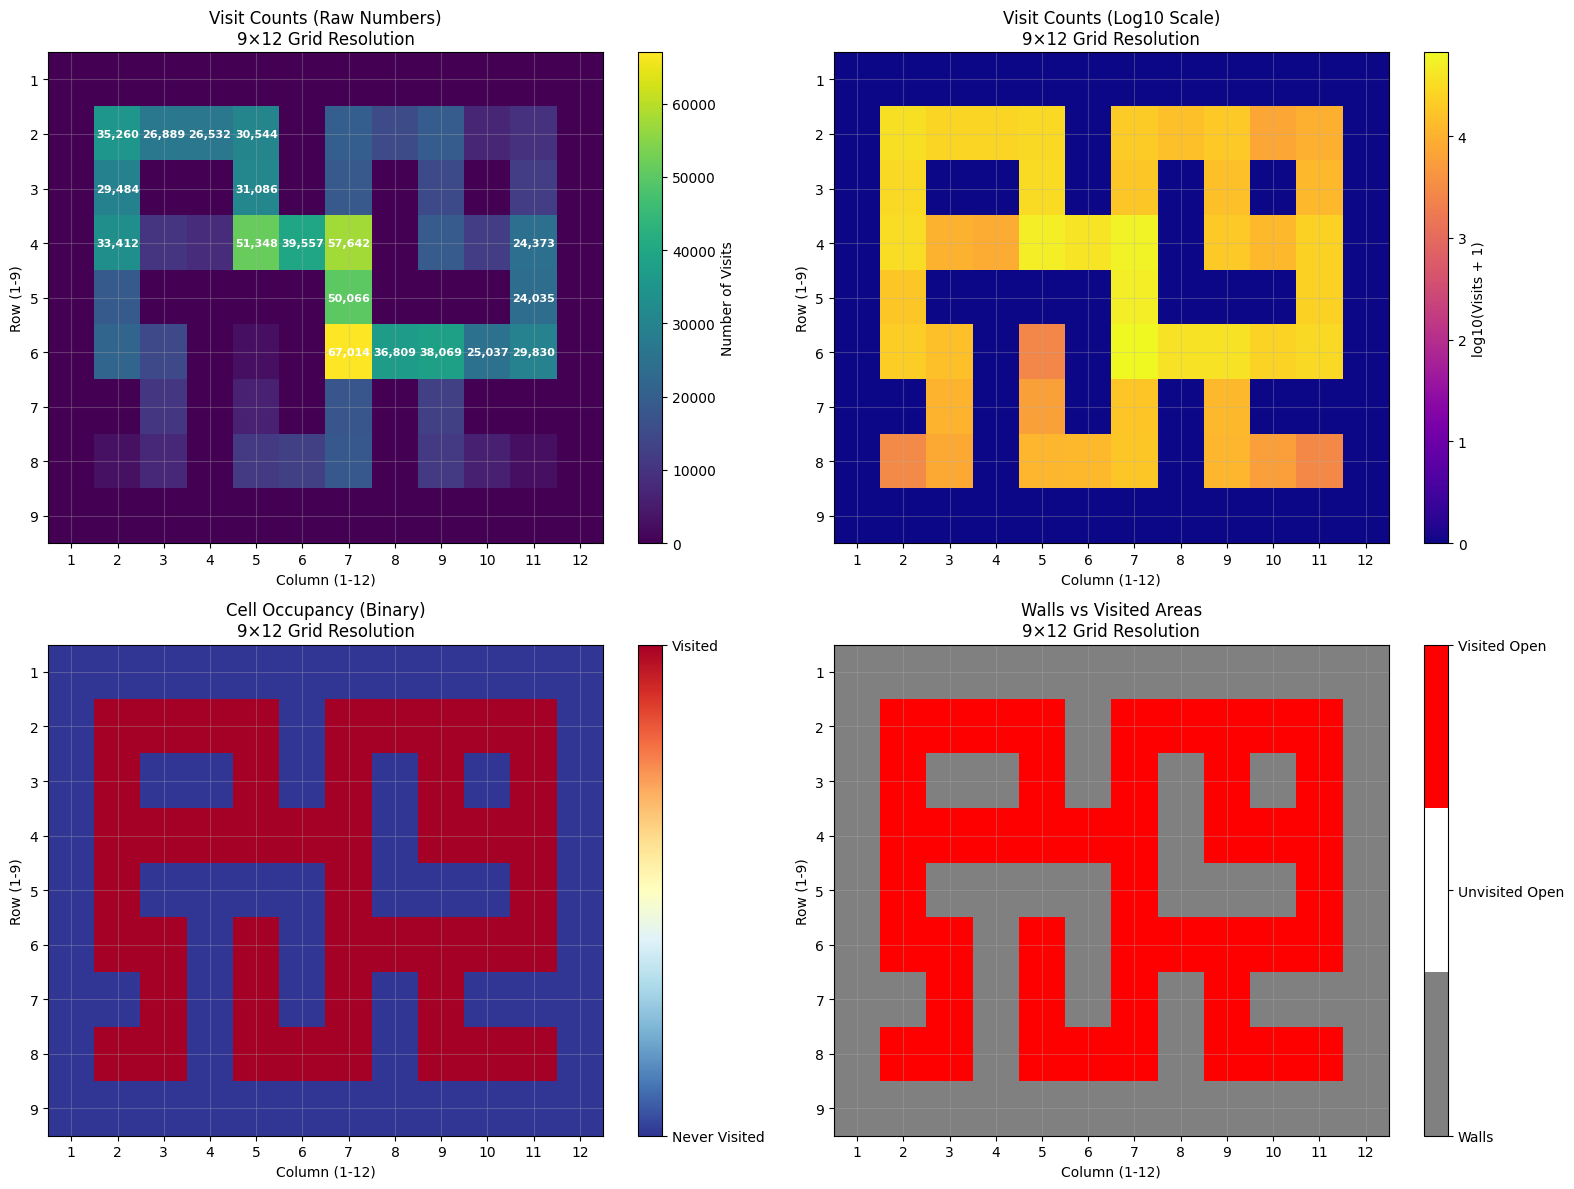


WALL vs VISIT ANALYSIS
Maze structure:
  Total cells: 108 (9×12)
  Wall cells: 62
  Open cells: 46

Visit coverage:
  Visited open cells: 46/46 (100.0%)
  Unvisited open cells: 0/46 (0.0%)

Verification:
  Wall cells = Never visited cells? True

VISIT COUNT MATRIX (9×12)
Visit counts by grid cell:
Columns:     1     2     3     4     5     6     7     8     9    10    11    12
Row 1:      0     0     0     0     0     0     0     0     0     0     0     0
Row 2:      0 35260 26889 26532 30544     0 20095 15223 19445  7256  9565     0
Row 3:      0 29484     0     0 31086     0 18753     0 15163     0 12222     0
Row 4:      0 33412 10104  8519 51348 39557 57642     0 19265 12154 24373     0
Row 5:      0 18899     0     0     0     0 50066     0     0     0 24035     0
Row 6:      0 21776 14890     0  2676     0 67014 36809 38069 25037 29830     0
Row 7:      0     0 10588     0  6026     0 17809     0 12711     0     0     0
Row 8:      0  3044  7684     0 11427 12647 18396     0 113

In [15]:
# COUNT VISITS TO EACH GRID CELL FOR 9×12 RESOLUTION
print("=" * 80)
print("COUNTING VISITS TO EACH GRID CELL (9×12 RESOLUTION)")
print("=" * 80)

# Initialize visit count matrix (9 rows × 12 columns)
visit_counts = np.zeros((9, 12), dtype=int)
total_steps = 0
total_episodes = 0

print("Processing dataset episodes...")
print(f"Total episodes in dataset: {dataset.total_episodes}")
print(f"Total steps in dataset: {dataset.total_steps}")

# Process all episodes in the dataset
for episode_idx, episode in enumerate(dataset.iterate_episodes()):
    if episode_idx % 500 == 0:  # Progress indicator
        print(f"  Processed {episode_idx}/{dataset.total_episodes} episodes...")
    
    observations = episode.observations
    if isinstance(observations, dict) and 'achieved_goal' in observations:
        positions = observations['achieved_goal']
        
        # Count visits for each position in this episode
        for pos in positions:
            obs = {'achieved_goal': pos}
            _, (row, col) = observation_to_grid(obs, grid_rows=9, grid_cols=12)
            
            # Convert to 0-based indexing for numpy array
            visit_counts[row-1, col-1] += 1
            total_steps += 1
    
    total_episodes += 1

print(f"\nProcessing complete!")
print(f"Total episodes processed: {total_episodes}")
print(f"Total steps processed: {total_steps}")
print(f"Total visits recorded: {visit_counts.sum()}")

# Display visit statistics
print(f"\nVisit Count Statistics:")
print(f"  Minimum visits: {visit_counts.min()}")
print(f"  Maximum visits: {visit_counts.max()}")
print(f"  Mean visits: {visit_counts.mean():.1f}")
print(f"  Std visits: {visit_counts.std():.1f}")

# Count how many cells were visited vs never visited
visited_cells = np.sum(visit_counts > 0)
never_visited = np.sum(visit_counts == 0)
print(f"  Cells visited: {visited_cells}/108 ({visited_cells/108*100:.1f}%)")
print(f"  Cells never visited: {never_visited}/108 ({never_visited/108*100:.1f}%)")

# Show top visited cells
print(f"\nTop 10 most visited cells:")
flat_indices = np.argsort(visit_counts.flatten())[::-1][:10]
for i, flat_idx in enumerate(flat_indices):
    row_idx, col_idx = np.unravel_index(flat_idx, visit_counts.shape)
    row, col = row_idx + 1, col_idx + 1  # Convert to 1-based
    count = visit_counts[row_idx, col_idx]
    print(f"  {i+1:2d}. g_({row},{col}): {count:,} visits ({count/total_steps*100:.2f}%)")

# CREATE HEATMAP VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Raw visit counts heatmap
ax1 = axes[0, 0]
im1 = ax1.imshow(visit_counts, cmap='viridis', aspect='auto')
ax1.set_title('Visit Counts (Raw Numbers)\n9×12 Grid Resolution')
ax1.set_xlabel('Column (1-12)')
ax1.set_ylabel('Row (1-9)')

# Add grid lines and labels
ax1.set_xticks(range(12))
ax1.set_yticks(range(9))
ax1.set_xticklabels(range(1, 13))
ax1.set_yticklabels(range(1, 10))
ax1.grid(True, alpha=0.3)

# Add colorbar
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('Number of Visits')

# Add text annotations for high-visit cells
for i in range(9):
    for j in range(12):
        if visit_counts[i, j] > visit_counts.mean() + visit_counts.std():
            ax1.text(j, i, f'{visit_counts[i, j]:,}', 
                    ha='center', va='center', color='white', fontsize=8, weight='bold')

# 2. Log-scale heatmap (for better visualization of low counts)
ax2 = axes[0, 1]
log_counts = np.log10(visit_counts + 1)  # +1 to handle zeros
im2 = ax2.imshow(log_counts, cmap='plasma', aspect='auto')
ax2.set_title('Visit Counts (Log10 Scale)\n9×12 Grid Resolution')
ax2.set_xlabel('Column (1-12)')
ax2.set_ylabel('Row (1-9)')

ax2.set_xticks(range(12))
ax2.set_yticks(range(9))
ax2.set_xticklabels(range(1, 13))
ax2.set_yticklabels(range(1, 10))
ax2.grid(True, alpha=0.3)

cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('log10(Visits + 1)')

# 3. Binary occupancy (visited vs never visited)
ax3 = axes[1, 0]
binary_visits = (visit_counts > 0).astype(int)
im3 = ax3.imshow(binary_visits, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=1)
ax3.set_title('Cell Occupancy (Binary)\n9×12 Grid Resolution')
ax3.set_xlabel('Column (1-12)')
ax3.set_ylabel('Row (1-9)')

ax3.set_xticks(range(12))
ax3.set_yticks(range(9))
ax3.set_xticklabels(range(1, 13))
ax3.set_yticklabels(range(1, 10))
ax3.grid(True, alpha=0.3)

cbar3 = plt.colorbar(im3, ax=ax3, ticks=[0, 1])
cbar3.set_ticklabels(['Never Visited', 'Visited'])

# 4. CORRECTED: Walls vs Visited Areas
ax4 = axes[1, 1]
# Create a visualization showing walls vs visited areas
wall_and_visit_map = np.zeros((9, 12))

for row in range(9):
    for col in range(12):
        if maze_map[row][col] == 1:  # Wall (1 in maze_map)
            wall_and_visit_map[row, col] = 0  # Gray for walls
        elif visit_counts[row, col] > 0:  # Visited open space
            wall_and_visit_map[row, col] = 2  # Red for visited
        else:  # Unvisited open space
            wall_and_visit_map[row, col] = 1  # White for unvisited open space

# Custom colormap: Gray=Walls, White=Unvisited Open, Red=Visited Open
from matplotlib.colors import ListedColormap
colors = ['gray', 'white', 'red']
custom_cmap = ListedColormap(colors)

im4 = ax4.imshow(wall_and_visit_map, cmap=custom_cmap, aspect='auto', vmin=0, vmax=2)
ax4.set_title('Walls vs Visited Areas\n9×12 Grid Resolution')
ax4.set_xlabel('Column (1-12)')
ax4.set_ylabel('Row (1-9)')
ax4.set_xticks(range(12))
ax4.set_yticks(range(9))
ax4.set_xticklabels(range(1, 13))
ax4.set_yticklabels(range(1, 10))
ax4.grid(True, alpha=0.3)

cbar4 = plt.colorbar(im4, ax=ax4, ticks=[0, 1, 2])
cbar4.set_ticklabels(['Walls', 'Unvisited Open', 'Visited Open'])

plt.tight_layout()
plt.show()

# ANALYSIS: Compare walls with never-visited cells
print(f"\n" + "="*80)
print("WALL vs VISIT ANALYSIS")
print("="*80)

wall_count = np.sum(np.array(maze_map) == 1)
open_count = np.sum(np.array(maze_map) == 0)
visited_open_count = 0
unvisited_open_count = 0

print(f"Maze structure:")
print(f"  Total cells: {9*12} (9×12)")
print(f"  Wall cells: {wall_count}")
print(f"  Open cells: {open_count}")

for row in range(9):
    for col in range(12):
        if maze_map[row][col] == 0:  # Open space
            if visit_counts[row, col] > 0:
                visited_open_count += 1
            else:
                unvisited_open_count += 1

print(f"\nVisit coverage:")
print(f"  Visited open cells: {visited_open_count}/{open_count} ({visited_open_count/open_count*100:.1f}%)")
print(f"  Unvisited open cells: {unvisited_open_count}/{open_count} ({unvisited_open_count/open_count*100:.1f}%)")

print(f"\nVerification:")
print(f"  Wall cells = Never visited cells? {wall_count == never_visited}")
if wall_count != never_visited:
    print(f"  Difference: {abs(wall_count - never_visited)} cells")

# SAVE VISIT COUNTS FOR FUTURE USE
print(f"\n" + "="*80)
print("VISIT COUNT MATRIX (9×12)")
print("="*80)

print("Visit counts by grid cell:")
print("Columns:", end="")
for c in range(1, 13):
    print(f"{c:6d}", end="")
print()

for r in range(1, 10):
    print(f"Row {r}: ", end="")
    for c in range(1, 13):
        count = visit_counts[r-1, c-1]
        print(f"{count:6d}", end="")
    print()

# Export to variables for later use
visit_counts_9x12 = visit_counts.copy()
print(f"\n✓ Visit counts saved to 'visit_counts_9x12' variable")
print(f"✓ Shape: {visit_counts_9x12.shape}")
print(f"✓ Total visits: {visit_counts_9x12.sum():,}")

HEATMAP WITH 1/√N(i) WEIGHTING (9×12 RESOLUTION)
1/√N(i) Statistics:
  Minimum value: 0.0039
  Maximum value: 0.0387
  Mean value: 0.0257
  Std value: 0.0152


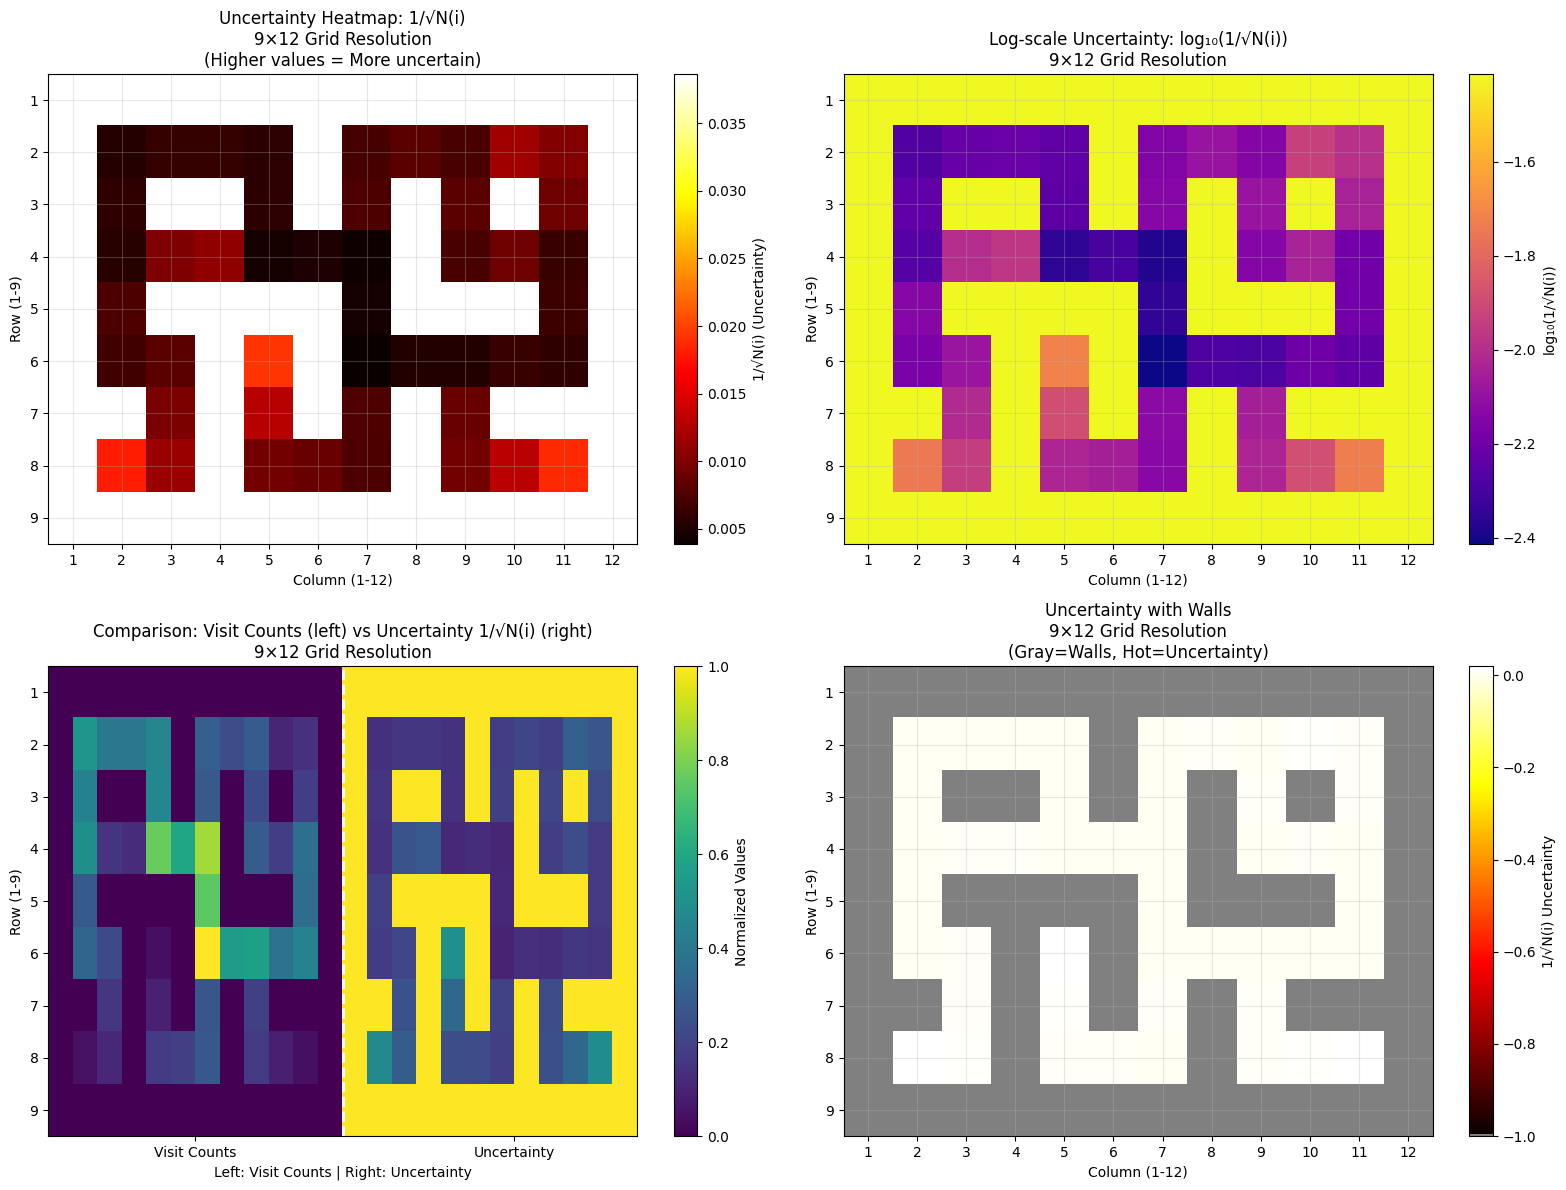


UNCERTAINTY ANALYSIS
Most certain cells (lowest uncertainty):
  g_(6,7): 67,014 visits, uncertainty = 0.0039

Least certain cells (highest uncertainty):
  g_(6,5): 2676 visits, uncertainty = 0.0193

Correlation between visit counts and uncertainty: -0.7847
(Expected: strong negative correlation, as more visits → less uncertainty)

✓ Uncertainty matrix saved to 'uncertainty_9x12' variable
✓ Shape: (9, 12)
✓ Interpretation: Higher values = More uncertain estimates
✓ Use for: Weighting in learning algorithms, exploration bonuses, etc.


In [16]:
# PLOT HEATMAP WITH 1/√N(i) FOR 9×12 RESOLUTION
print("=" * 80)
print("HEATMAP WITH 1/√N(i) WEIGHTING (9×12 RESOLUTION)")
print("=" * 80)

# Calculate 1/√N(i) for each cell
# Handle zero visits by setting them to a large value (indicating high uncertainty)
inverse_sqrt_visits = np.zeros_like(visit_counts_9x12, dtype=float)

for i in range(9):
    for j in range(12):
        if visit_counts_9x12[i, j] > 0:
            inverse_sqrt_visits[i, j] = 1.0 / np.sqrt(visit_counts_9x12[i, j])
        else:
            # For cells with zero visits, set to a high value to indicate maximum uncertainty
            inverse_sqrt_visits[i, j] = np.inf

# Replace inf values with a finite large number for visualization
max_finite_value = np.max(inverse_sqrt_visits[np.isfinite(inverse_sqrt_visits)])
inverse_sqrt_visits[np.isinf(inverse_sqrt_visits)] = max_finite_value * 2

print(f"1/√N(i) Statistics:")
print(f"  Minimum value: {np.min(inverse_sqrt_visits):.4f}")
print(f"  Maximum value: {np.max(inverse_sqrt_visits):.4f}")
print(f"  Mean value: {np.mean(inverse_sqrt_visits):.4f}")
print(f"  Std value: {np.std(inverse_sqrt_visits):.4f}")

# CREATE VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Raw 1/√N(i) heatmap
ax1 = axes[0, 0]
im1 = ax1.imshow(inverse_sqrt_visits, cmap='hot', aspect='auto')
ax1.set_title('Uncertainty Heatmap: 1/√N(i)\n9×12 Grid Resolution\n(Higher values = More uncertain)')
ax1.set_xlabel('Column (1-12)')
ax1.set_ylabel('Row (1-9)')

# Add grid lines and labels
ax1.set_xticks(range(12))
ax1.set_yticks(range(9))
ax1.set_xticklabels(range(1, 13))
ax1.set_yticklabels(range(1, 10))
ax1.grid(True, alpha=0.3)

# Add colorbar
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('1/√N(i) (Uncertainty)')

# 2. Log-scale 1/√N(i) for better visualization
ax2 = axes[0, 1]
log_inverse_sqrt = np.log10(inverse_sqrt_visits + 1e-10)  # Small epsilon to avoid log(0)
im2 = ax2.imshow(log_inverse_sqrt, cmap='plasma', aspect='auto')
ax2.set_title('Log-scale Uncertainty: log₁₀(1/√N(i))\n9×12 Grid Resolution')
ax2.set_xlabel('Column (1-12)')
ax2.set_ylabel('Row (1-9)')

ax2.set_xticks(range(12))
ax2.set_yticks(range(9))
ax2.set_xticklabels(range(1, 13))
ax2.set_yticklabels(range(1, 10))
ax2.grid(True, alpha=0.3)

cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('log₁₀(1/√N(i))')

# 3. Comparison: Visit counts vs Uncertainty
ax3 = axes[1, 0]
# Create a side-by-side comparison by splitting each cell
comparison_map = np.zeros((9, 24))  # Double width for side-by-side

# Left half: normalized visit counts
norm_visits = visit_counts_9x12 / np.max(visit_counts_9x12)
comparison_map[:, :12] = norm_visits

# Right half: normalized uncertainty (inverted for comparison)
norm_uncertainty = inverse_sqrt_visits / np.max(inverse_sqrt_visits)
comparison_map[:, 12:] = norm_uncertainty

im3 = ax3.imshow(comparison_map, cmap='viridis', aspect='auto')
ax3.set_title('Comparison: Visit Counts (left) vs Uncertainty 1/√N(i) (right)\n9×12 Grid Resolution')
ax3.set_xlabel('Left: Visit Counts | Right: Uncertainty')
ax3.set_ylabel('Row (1-9)')

# Custom tick labels
ax3.set_xticks([5.5, 18.5])
ax3.set_xticklabels(['Visit Counts', 'Uncertainty'])
ax3.set_yticks(range(9))
ax3.set_yticklabels(range(1, 10))
ax3.axvline(x=11.5, color='white', linewidth=2, linestyle='--')

cbar3 = plt.colorbar(im3, ax=ax3)
cbar3.set_label('Normalized Values')

# 4. Uncertainty map with wall overlay
ax4 = axes[1, 1]
# Create uncertainty map with walls marked differently
uncertainty_with_walls = inverse_sqrt_visits.copy()

# Set wall cells to a special value
for row in range(9):
    for col in range(12):
        if maze_map[row][col] == 1:  # Wall
            uncertainty_with_walls[row, col] = -1  # Special value for walls

# Use custom colormap
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.colors as mcolors

# Create custom colormap: gray for walls, hot colors for uncertainty
colors = ['gray'] + plt.cm.hot(np.linspace(0, 1, 256)).tolist()
custom_cmap = ListedColormap(colors)

# Normalize to include the wall value
vmin = -1
vmax = np.max(uncertainty_with_walls[uncertainty_with_walls > -1])
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

im4 = ax4.imshow(uncertainty_with_walls, cmap=custom_cmap, norm=norm, aspect='auto')
ax4.set_title('Uncertainty with Walls\n9×12 Grid Resolution\n(Gray=Walls, Hot=Uncertainty)')
ax4.set_xlabel('Column (1-12)')
ax4.set_ylabel('Row (1-9)')
ax4.set_xticks(range(12))
ax4.set_yticks(range(9))
ax4.set_xticklabels(range(1, 13))
ax4.set_yticklabels(range(1, 10))
ax4.grid(True, alpha=0.3)

cbar4 = plt.colorbar(im4, ax=ax4)
cbar4.set_label('1/√N(i) Uncertainty')

plt.tight_layout()
plt.show()

# ANALYSIS: Relationship between visits and uncertainty
print(f"\n" + "="*80)
print("UNCERTAINTY ANALYSIS")
print("="*80)

# Find most and least certain cells (excluding walls)
open_cells_mask = np.array([[maze_map[i][j] == 0 for j in range(12)] for i in range(9)])
uncertainty_open_only = inverse_sqrt_visits[open_cells_mask]
visits_open_only = visit_counts_9x12[open_cells_mask]

# Most certain cells (lowest 1/√N(i), highest visits)
most_certain_indices = np.where(open_cells_mask & (inverse_sqrt_visits == np.min(uncertainty_open_only)))
# Least certain cells (highest 1/√N(i), lowest visits)
least_certain_indices = np.where(open_cells_mask & (inverse_sqrt_visits == np.max(uncertainty_open_only)))

print(f"Most certain cells (lowest uncertainty):")
for i in range(len(most_certain_indices[0])):
    row, col = most_certain_indices[0][i], most_certain_indices[1][i]
    visits = visit_counts_9x12[row, col]
    uncertainty = inverse_sqrt_visits[row, col]
    print(f"  g_({row+1},{col+1}): {visits:,} visits, uncertainty = {uncertainty:.4f}")

print(f"\nLeast certain cells (highest uncertainty):")
for i in range(len(least_certain_indices[0])):
    row, col = least_certain_indices[0][i], least_certain_indices[1][i]
    visits = visit_counts_9x12[row, col]
    uncertainty = inverse_sqrt_visits[row, col]
    if visits == 0:
        print(f"  g_({row+1},{col+1}): {visits} visits, uncertainty = ∞ (never visited)")
    else:
        print(f"  g_({row+1},{col+1}): {visits} visits, uncertainty = {uncertainty:.4f}")

# Correlation between visits and uncertainty (for visited cells only)
visited_mask = visit_counts_9x12 > 0
if np.sum(visited_mask) > 1:
    correlation = np.corrcoef(visit_counts_9x12[visited_mask], inverse_sqrt_visits[visited_mask])[0, 1]
    print(f"\nCorrelation between visit counts and uncertainty: {correlation:.4f}")
    print(f"(Expected: strong negative correlation, as more visits → less uncertainty)")

# Save uncertainty matrix for future use
uncertainty_9x12 = inverse_sqrt_visits.copy()
print(f"\n✓ Uncertainty matrix saved to 'uncertainty_9x12' variable")
print(f"✓ Shape: {uncertainty_9x12.shape}")
print(f"✓ Interpretation: Higher values = More uncertain estimates")
print(f"✓ Use for: Weighting in learning algorithms, exploration bonuses, etc.")

### Same visit count and heatmaps for $18*24$.

COUNTING VISITS TO EACH GRID CELL (18×24 RESOLUTION)
Processing dataset episodes for 18×24 grid...
Total episodes in dataset: 3360
Total steps in dataset: 1000000
  Processed 0/3360 episodes...
  Processed 500/3360 episodes...
  Processed 500/3360 episodes...
  Processed 1000/3360 episodes...
  Processed 1000/3360 episodes...
  Processed 1500/3360 episodes...
  Processed 1500/3360 episodes...
  Processed 2000/3360 episodes...
  Processed 2000/3360 episodes...
  Processed 2500/3360 episodes...
  Processed 2500/3360 episodes...
  Processed 3000/3360 episodes...
  Processed 3000/3360 episodes...

Processing complete!
Total episodes processed: 3360
Total steps processed: 1003360
Total visits recorded: 1003360

Visit Count Statistics (18×24):
  Minimum visits: 0
  Maximum visits: 40182
  Mean visits: 2322.6
  Std visits: 4960.6
  Cells visited: 184/432 (42.6%)
  Cells never visited: 248/432 (57.4%)

Top 10 most visited cells (18×24):
   1. g_(8,13): 40,182 visits (4.00%)
   2. g_(10,13): 25

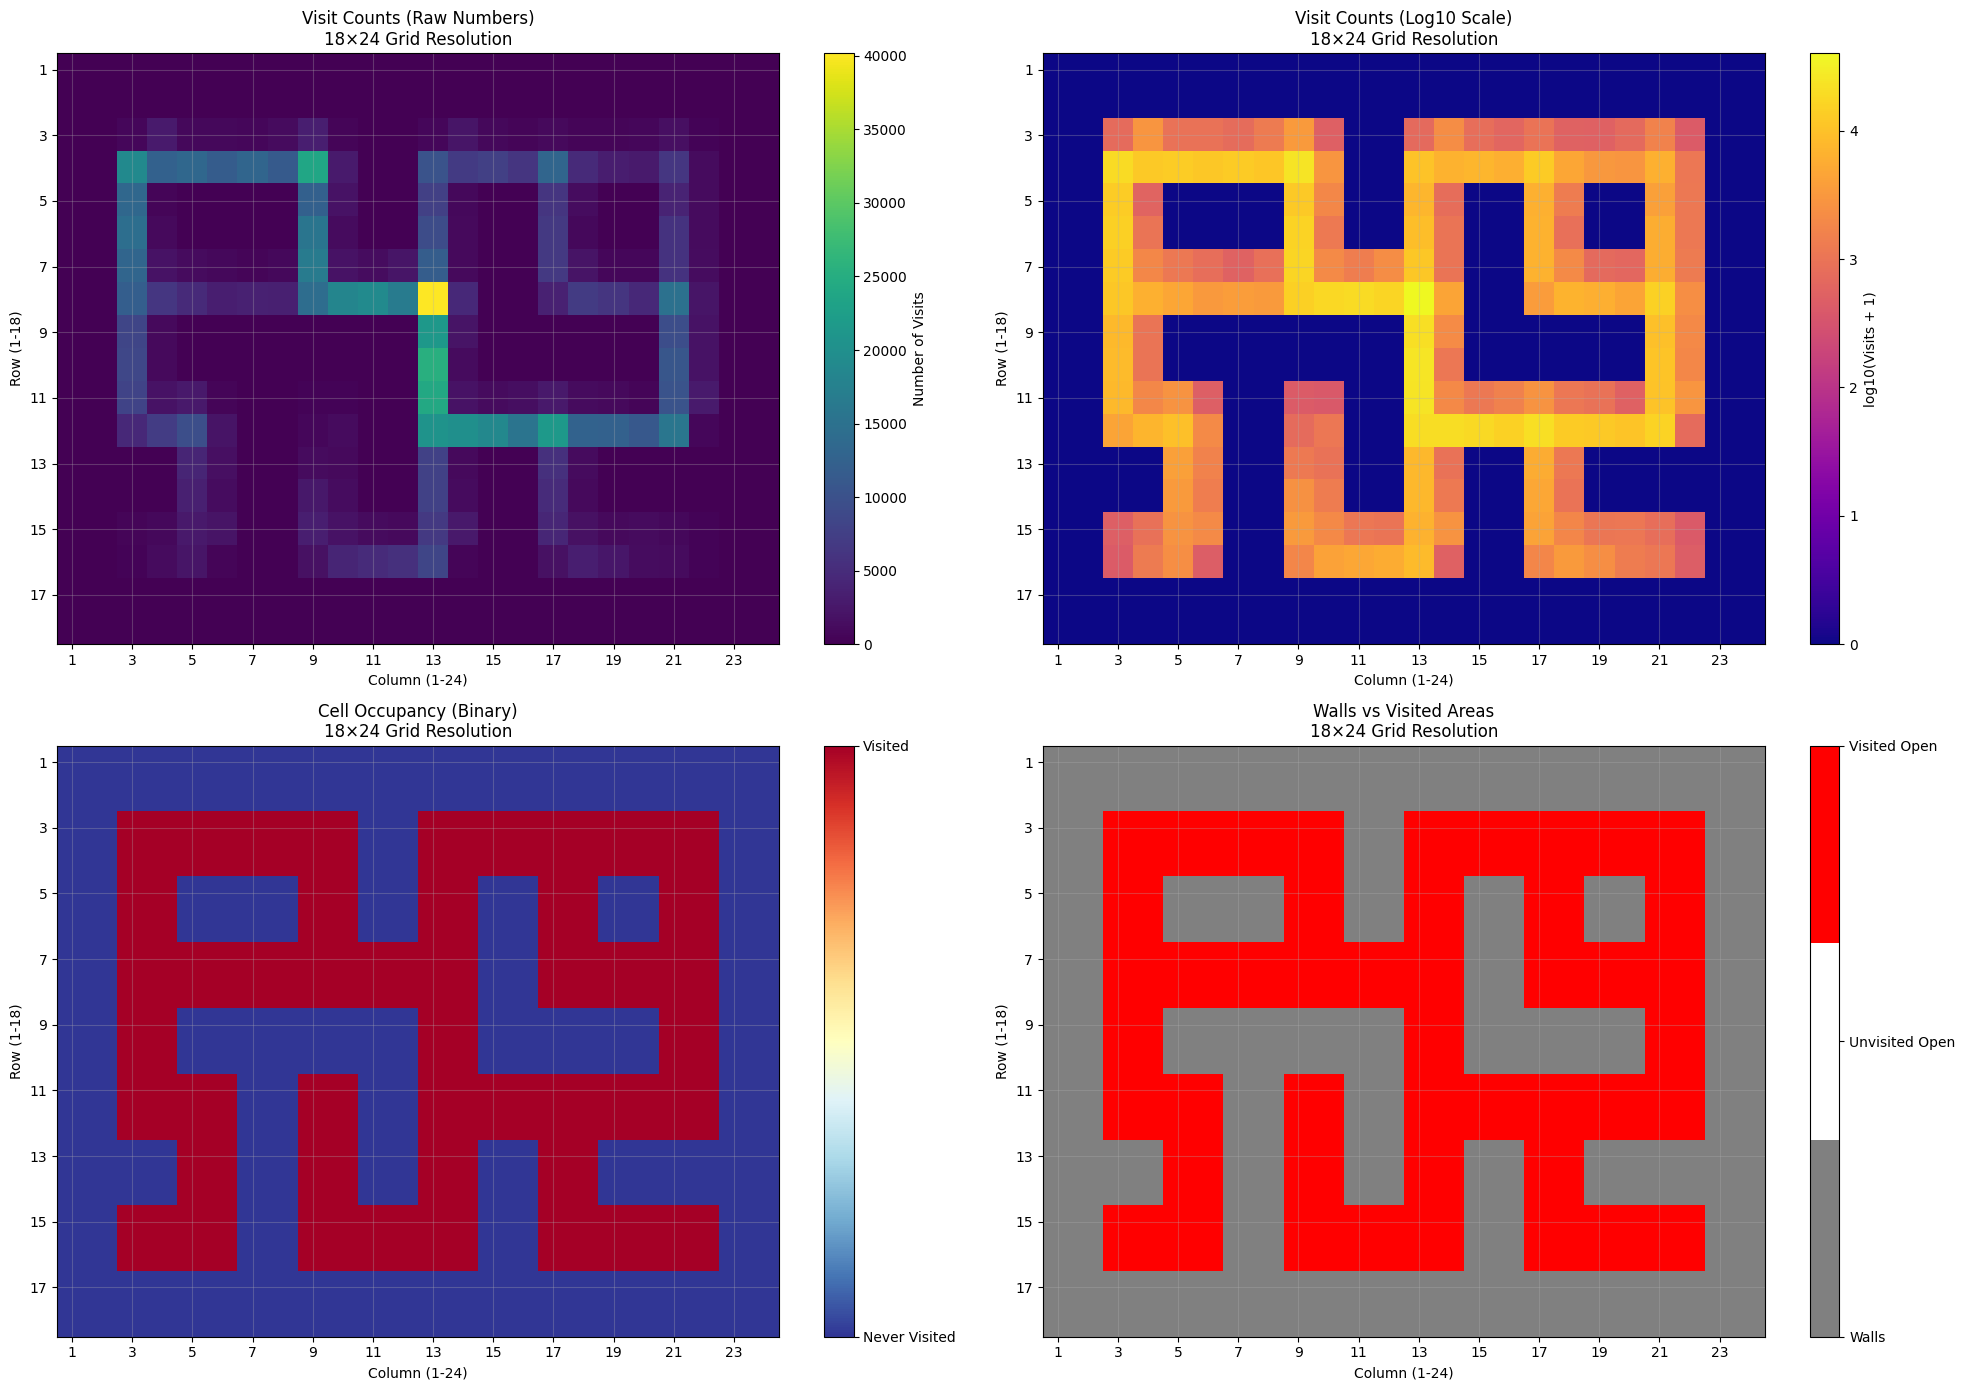


WALL vs VISIT ANALYSIS (18×24)
Maze structure (18×24):
  Total cells: 432 (18×24)
  Wall cells: 248
  Open cells: 184

Visit coverage (18×24):
  Visited open cells: 184/184 (100.0%)
  Unvisited open cells: 0/184 (0.0%)

Verification (18×24):
  Wall cells = Never visited cells? True

COMPARISON: 9×12 vs 18×24
Resolution comparison:
  9×12:  1,003,360 total visits, 46/108 cells visited (42.6%)
  18×24: 1,003,360 total visits, 184/432 cells visited (42.6%)

Data sparsity:
  9×12:  9290.4 ± 14397.1 visits per cell
  18×24: 2322.6 ± 4960.6 visits per cell

VISIT COUNT SUMMARY (18×24)
✓ Visit counts saved to 'visit_counts_18x24' variable
✓ Shape: (18, 24)
✓ Total visits: 1,003,360
✓ Cells with data: 184/432
✓ Cell resolution: 0.5m × 0.5m each
✓ Total state space: 432 discrete states


In [17]:
# COUNT VISITS TO EACH GRID CELL FOR 18×24 RESOLUTION
print("=" * 80)
print("COUNTING VISITS TO EACH GRID CELL (18×24 RESOLUTION)")
print("=" * 80)

# Initialize visit count matrix (18 rows × 24 columns)
visit_counts_18x24 = np.zeros((18, 24), dtype=int)
total_steps_18x24 = 0
total_episodes_18x24 = 0

print("Processing dataset episodes for 18×24 grid...")
print(f"Total episodes in dataset: {dataset.total_episodes}")
print(f"Total steps in dataset: {dataset.total_steps}")

# Process all episodes in the dataset
for episode_idx, episode in enumerate(dataset.iterate_episodes()):
    if episode_idx % 500 == 0:  # Progress indicator
        print(f"  Processed {episode_idx}/{dataset.total_episodes} episodes...")
    
    observations = episode.observations
    if isinstance(observations, dict) and 'achieved_goal' in observations:
        positions = observations['achieved_goal']
        
        # Count visits for each position in this episode
        for pos in positions:
            obs = {'achieved_goal': pos}
            _, (row, col) = observation_to_grid_18x24(obs)
            
            # Convert to 0-based indexing for numpy array
            visit_counts_18x24[row-1, col-1] += 1
            total_steps_18x24 += 1
    
    total_episodes_18x24 += 1

print(f"\nProcessing complete!")
print(f"Total episodes processed: {total_episodes_18x24}")
print(f"Total steps processed: {total_steps_18x24}")
print(f"Total visits recorded: {visit_counts_18x24.sum()}")

# Display visit statistics
print(f"\nVisit Count Statistics (18×24):")
print(f"  Minimum visits: {visit_counts_18x24.min()}")
print(f"  Maximum visits: {visit_counts_18x24.max()}")
print(f"  Mean visits: {visit_counts_18x24.mean():.1f}")
print(f"  Std visits: {visit_counts_18x24.std():.1f}")

# Count how many cells were visited vs never visited
visited_cells_18x24 = np.sum(visit_counts_18x24 > 0)
never_visited_18x24 = np.sum(visit_counts_18x24 == 0)
total_cells_18x24 = 18 * 24
print(f"  Cells visited: {visited_cells_18x24}/{total_cells_18x24} ({visited_cells_18x24/total_cells_18x24*100:.1f}%)")
print(f"  Cells never visited: {never_visited_18x24}/{total_cells_18x24} ({never_visited_18x24/total_cells_18x24*100:.1f}%)")

# Show top visited cells
print(f"\nTop 10 most visited cells (18×24):")
flat_indices = np.argsort(visit_counts_18x24.flatten())[::-1][:10]
for i, flat_idx in enumerate(flat_indices):
    row_idx, col_idx = np.unravel_index(flat_idx, visit_counts_18x24.shape)
    row, col = row_idx + 1, col_idx + 1  # Convert to 1-based
    count = visit_counts_18x24[row_idx, col_idx]
    print(f"  {i+1:2d}. g_({row},{col}): {count:,} visits ({count/total_steps_18x24*100:.2f}%)")

# CREATE HEATMAP VISUALIZATION FOR 18×24
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# 1. Raw visit counts heatmap
ax1 = axes[0, 0]
im1 = ax1.imshow(visit_counts_18x24, cmap='viridis', aspect='auto')
ax1.set_title('Visit Counts (Raw Numbers)\n18×24 Grid Resolution')
ax1.set_xlabel('Column (1-24)')
ax1.set_ylabel('Row (1-18)')

# Add grid lines and labels (show every 2nd tick for readability)
ax1.set_xticks(range(0, 24, 2))
ax1.set_yticks(range(0, 18, 2))
ax1.set_xticklabels(range(1, 25, 2))
ax1.set_yticklabels(range(1, 19, 2))
ax1.grid(True, alpha=0.3)

# Add colorbar
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('Number of Visits')

# 2. Log-scale heatmap (for better visualization of low counts)
ax2 = axes[0, 1]
log_counts_18x24 = np.log10(visit_counts_18x24 + 1)  # +1 to handle zeros
im2 = ax2.imshow(log_counts_18x24, cmap='plasma', aspect='auto')
ax2.set_title('Visit Counts (Log10 Scale)\n18×24 Grid Resolution')
ax2.set_xlabel('Column (1-24)')
ax2.set_ylabel('Row (1-18)')

ax2.set_xticks(range(0, 24, 2))
ax2.set_yticks(range(0, 18, 2))
ax2.set_xticklabels(range(1, 25, 2))
ax2.set_yticklabels(range(1, 19, 2))
ax2.grid(True, alpha=0.3)

cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('log10(Visits + 1)')

# 3. Binary occupancy (visited vs never visited)
ax3 = axes[1, 0]
binary_visits_18x24 = (visit_counts_18x24 > 0).astype(int)
im3 = ax3.imshow(binary_visits_18x24, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=1)
ax3.set_title('Cell Occupancy (Binary)\n18×24 Grid Resolution')
ax3.set_xlabel('Column (1-24)')
ax3.set_ylabel('Row (1-18)')

ax3.set_xticks(range(0, 24, 2))
ax3.set_yticks(range(0, 18, 2))
ax3.set_xticklabels(range(1, 25, 2))
ax3.set_yticklabels(range(1, 19, 2))
ax3.grid(True, alpha=0.3)

cbar3 = plt.colorbar(im3, ax=ax3, ticks=[0, 1])
cbar3.set_ticklabels(['Never Visited', 'Visited'])

# 4. Walls vs Visited Areas (18×24 subdivision of original maze)
ax4 = axes[1, 1]
# Create wall map for 18×24 by subdividing the original 9×12 maze
wall_and_visit_map_18x24 = np.zeros((18, 24))

for row in range(18):
    for col in range(24):
        # Map 18×24 cell back to original 9×12 maze cell
        orig_row = row // 2  # Each original row becomes 2 rows
        orig_col = col // 2  # Each original col becomes 2 cols
        
        if maze_map[orig_row][orig_col] == 1:  # Wall in original maze
            wall_and_visit_map_18x24[row, col] = 0  # Gray for walls
        elif visit_counts_18x24[row, col] > 0:  # Visited open space
            wall_and_visit_map_18x24[row, col] = 2  # Red for visited
        else:  # Unvisited open space
            wall_and_visit_map_18x24[row, col] = 1  # White for unvisited open space

# Custom colormap: Gray=Walls, White=Unvisited Open, Red=Visited Open
from matplotlib.colors import ListedColormap
colors = ['gray', 'white', 'red']
custom_cmap = ListedColormap(colors)

im4 = ax4.imshow(wall_and_visit_map_18x24, cmap=custom_cmap, aspect='auto', vmin=0, vmax=2)
ax4.set_title('Walls vs Visited Areas\n18×24 Grid Resolution')
ax4.set_xlabel('Column (1-24)')
ax4.set_ylabel('Row (1-18)')
ax4.set_xticks(range(0, 24, 2))
ax4.set_yticks(range(0, 18, 2))
ax4.set_xticklabels(range(1, 25, 2))
ax4.set_yticklabels(range(1, 19, 2))
ax4.grid(True, alpha=0.3)

cbar4 = plt.colorbar(im4, ax=ax4, ticks=[0, 1, 2])
cbar4.set_ticklabels(['Walls', 'Unvisited Open', 'Visited Open'])

plt.tight_layout()
plt.show()

# ANALYSIS: Compare walls with never-visited cells for 18×24
print(f"\n" + "="*80)
print("WALL vs VISIT ANALYSIS (18×24)")
print("="*80)

# Count wall cells in 18×24 (each original wall cell becomes 4 cells)
wall_count_18x24 = 0
open_count_18x24 = 0
visited_open_count_18x24 = 0
unvisited_open_count_18x24 = 0

for row in range(18):
    for col in range(24):
        orig_row = row // 2
        orig_col = col // 2
        
        if maze_map[orig_row][orig_col] == 1:  # Wall
            wall_count_18x24 += 1
        else:  # Open space
            open_count_18x24 += 1
            if visit_counts_18x24[row, col] > 0:
                visited_open_count_18x24 += 1
            else:
                unvisited_open_count_18x24 += 1

print(f"Maze structure (18×24):")
print(f"  Total cells: {18*24} (18×24)")
print(f"  Wall cells: {wall_count_18x24}")
print(f"  Open cells: {open_count_18x24}")

print(f"\nVisit coverage (18×24):")
print(f"  Visited open cells: {visited_open_count_18x24}/{open_count_18x24} ({visited_open_count_18x24/open_count_18x24*100:.1f}%)")
print(f"  Unvisited open cells: {unvisited_open_count_18x24}/{open_count_18x24} ({unvisited_open_count_18x24/open_count_18x24*100:.1f}%)")

print(f"\nVerification (18×24):")
print(f"  Wall cells = Never visited cells? {wall_count_18x24 == never_visited_18x24}")
if wall_count_18x24 != never_visited_18x24:
    print(f"  Difference: {abs(wall_count_18x24 - never_visited_18x24)} cells")

# COMPARISON WITH 9×12 RESULTS
print(f"\n" + "="*80)
print("COMPARISON: 9×12 vs 18×24")
print("="*80)

print(f"Resolution comparison:")
print(f"  9×12:  {visit_counts_9x12.sum():,} total visits, {np.sum(visit_counts_9x12 > 0)}/108 cells visited ({np.sum(visit_counts_9x12 > 0)/108*100:.1f}%)")
print(f"  18×24: {visit_counts_18x24.sum():,} total visits, {visited_cells_18x24}/{total_cells_18x24} cells visited ({visited_cells_18x24/total_cells_18x24*100:.1f}%)")

print(f"\nData sparsity:")
print(f"  9×12:  {visit_counts_9x12.mean():.1f} ± {visit_counts_9x12.std():.1f} visits per cell")
print(f"  18×24: {visit_counts_18x24.mean():.1f} ± {visit_counts_18x24.std():.1f} visits per cell")

# SAVE VISIT COUNTS FOR FUTURE USE
print(f"\n" + "="*80)
print("VISIT COUNT SUMMARY (18×24)")
print("="*80)

print(f"✓ Visit counts saved to 'visit_counts_18x24' variable")
print(f"✓ Shape: {visit_counts_18x24.shape}")
print(f"✓ Total visits: {visit_counts_18x24.sum():,}")
print(f"✓ Cells with data: {visited_cells_18x24}/{total_cells_18x24}")
print(f"✓ Cell resolution: 0.5m × 0.5m each")
print(f"✓ Total state space: {total_cells_18x24:,} discrete states")

### Uncertainty Heatmap for $18*24$.

HEATMAP WITH 1/√N(i) WEIGHTING (18×24 RESOLUTION)
1/√N(i) Statistics (18×24):
  Minimum value: 0.0050
  Maximum value: 0.1005
  Mean value: 0.0670
  Std value: 0.0396


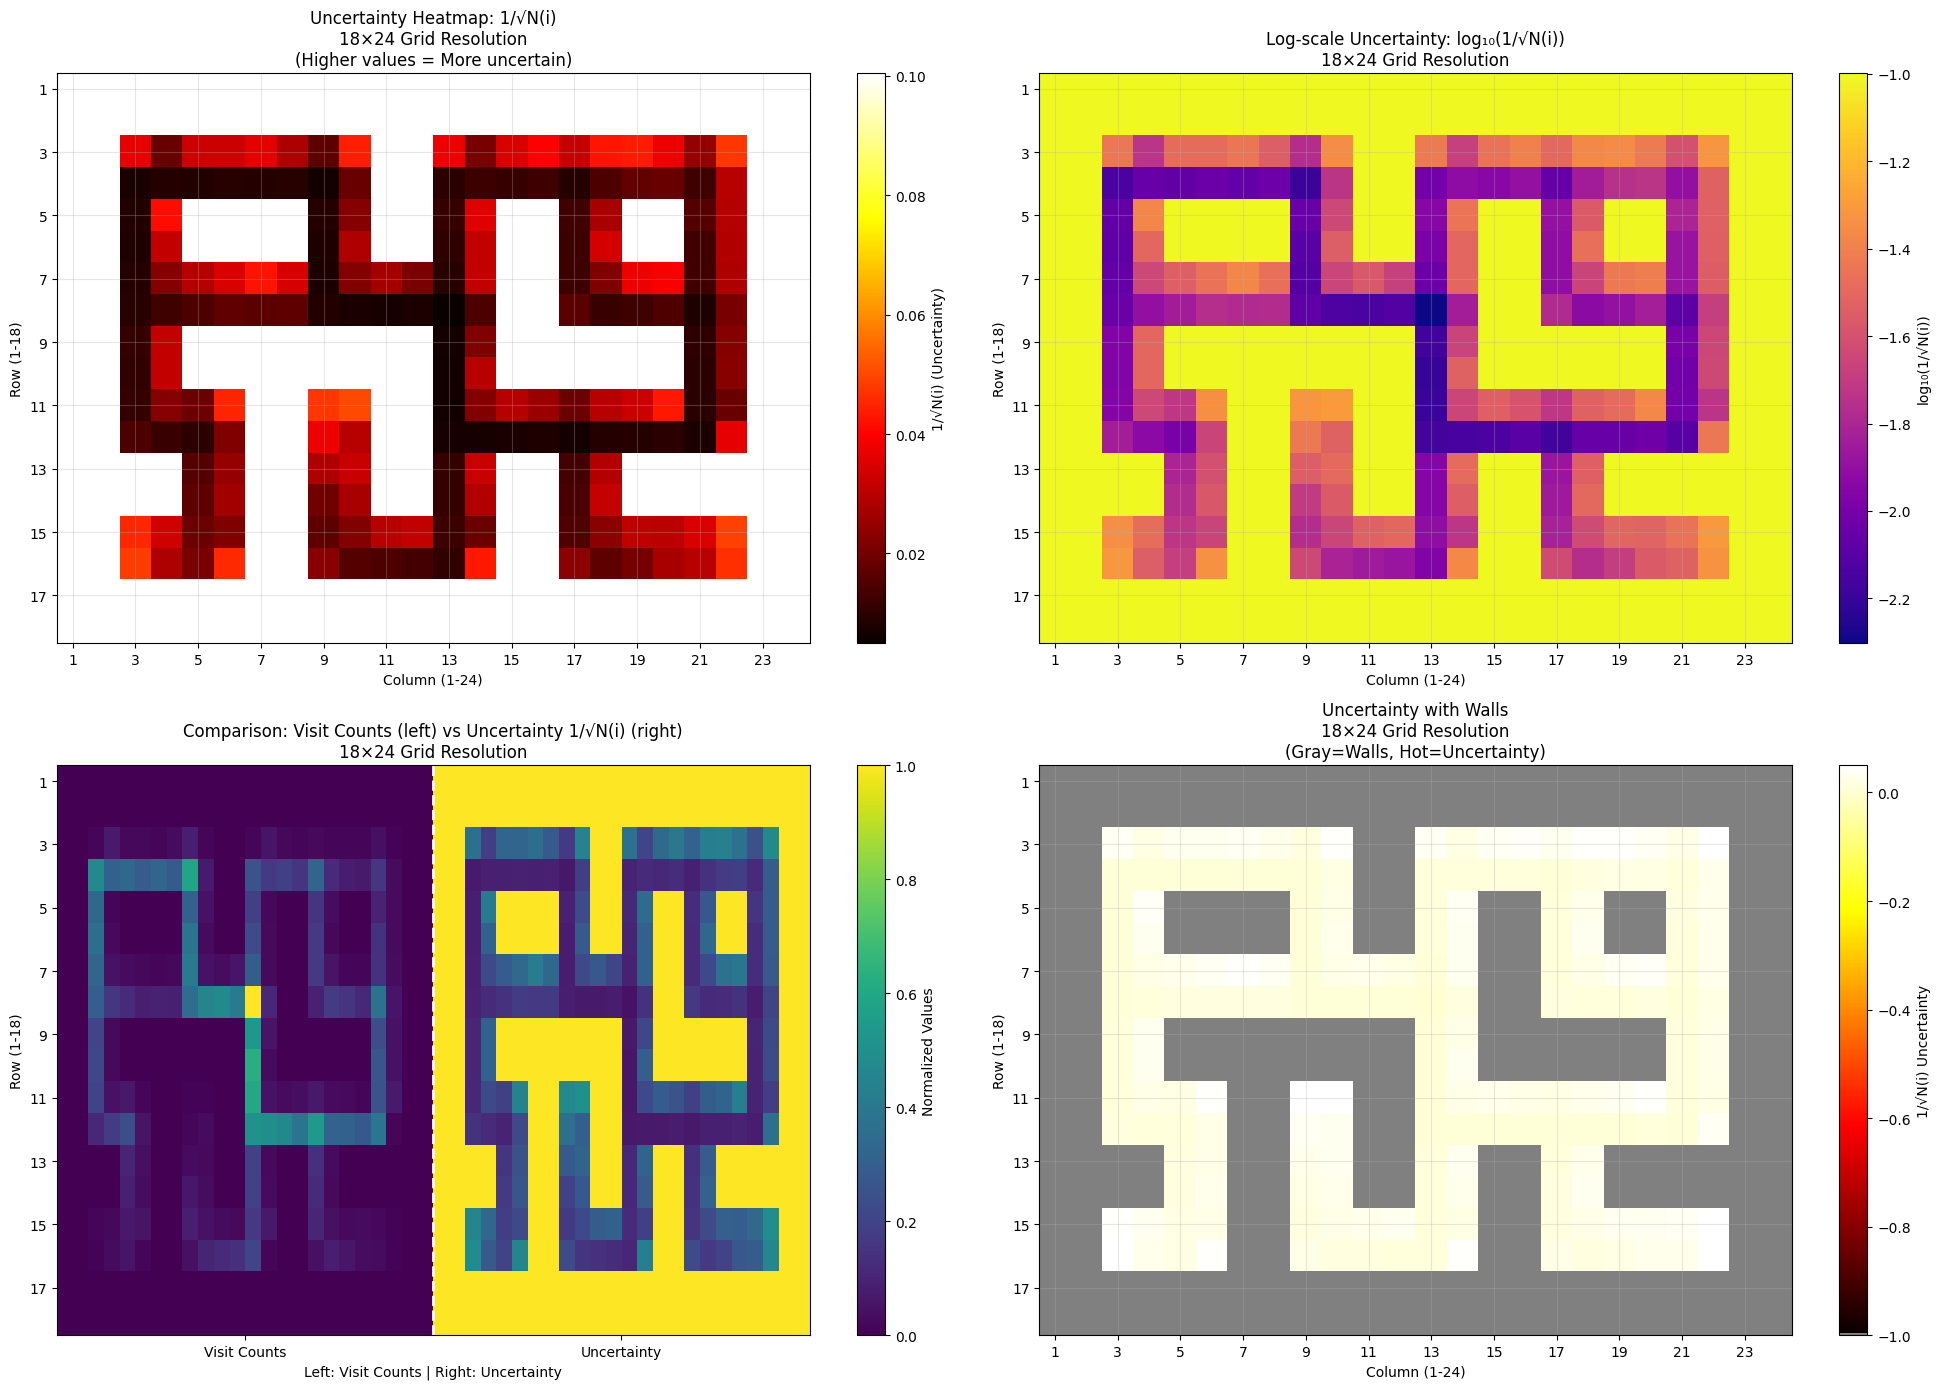


UNCERTAINTY ANALYSIS (18×24)
Most certain cells (lowest uncertainty) - 18×24:
  g_(8,13): 40,182 visits, uncertainty = 0.0050

Least certain cells (highest finite uncertainty) - 18×24:
  g_(11,10): 396 visits, uncertainty = 0.0503

Cells with zero visits (infinite uncertainty): 0

Correlation between visit counts and uncertainty (18×24): -0.7465
(Expected: strong negative correlation, as more visits → less uncertainty)

UNCERTAINTY COMPARISON: 9×12 vs 18×24
Uncertainty statistics comparison:
  9×12  - Mean uncertainty: 0.0257 ± 0.0152
  18×24 - Mean uncertainty: 0.0670 ± 0.0396

Data sparsity impact:
  9×12  - Cells with infinite uncertainty: 0
  18×24 - Cells with infinite uncertainty: 248

Resolution vs Uncertainty trade-off:
  Higher resolution (18×24) → More cells → Sparser data → Higher uncertainty
  Each original cell subdivided into 4 subcells → Visit density reduced by ~4x

✓ Uncertainty matrix saved to 'uncertainty_18x24' variable
✓ Shape: (18, 24)
✓ Interpretation: Higher va

In [18]:
# PLOT HEATMAP WITH 1/√N(i) FOR 18×24 RESOLUTION
print("=" * 80)
print("HEATMAP WITH 1/√N(i) WEIGHTING (18×24 RESOLUTION)")
print("=" * 80)

# Calculate 1/√N(i) for each cell in 18×24 grid
# Handle zero visits by setting them to a large value (indicating high uncertainty)
inverse_sqrt_visits_18x24 = np.zeros_like(visit_counts_18x24, dtype=float)

for i in range(18):
    for j in range(24):
        if visit_counts_18x24[i, j] > 0:
            inverse_sqrt_visits_18x24[i, j] = 1.0 / np.sqrt(visit_counts_18x24[i, j])
        else:
            # For cells with zero visits, set to a high value to indicate maximum uncertainty
            inverse_sqrt_visits_18x24[i, j] = np.inf

# Replace inf values with a finite large number for visualization
max_finite_value_18x24 = np.max(inverse_sqrt_visits_18x24[np.isfinite(inverse_sqrt_visits_18x24)])
inverse_sqrt_visits_18x24[np.isinf(inverse_sqrt_visits_18x24)] = max_finite_value_18x24 * 2

print(f"1/√N(i) Statistics (18×24):")
print(f"  Minimum value: {np.min(inverse_sqrt_visits_18x24):.4f}")
print(f"  Maximum value: {np.max(inverse_sqrt_visits_18x24):.4f}")
print(f"  Mean value: {np.mean(inverse_sqrt_visits_18x24):.4f}")
print(f"  Std value: {np.std(inverse_sqrt_visits_18x24):.4f}")

# CREATE VISUALIZATION FOR 18×24
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# 1. Raw 1/√N(i) heatmap
ax1 = axes[0, 0]
im1 = ax1.imshow(inverse_sqrt_visits_18x24, cmap='hot', aspect='auto')
ax1.set_title('Uncertainty Heatmap: 1/√N(i)\n18×24 Grid Resolution\n(Higher values = More uncertain)')
ax1.set_xlabel('Column (1-24)')
ax1.set_ylabel('Row (1-18)')

# Add grid lines and labels (show every 2nd tick for readability)
ax1.set_xticks(range(0, 24, 2))
ax1.set_yticks(range(0, 18, 2))
ax1.set_xticklabels(range(1, 25, 2))
ax1.set_yticklabels(range(1, 19, 2))
ax1.grid(True, alpha=0.3)

# Add colorbar
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('1/√N(i) (Uncertainty)')

# 2. Log-scale 1/√N(i) for better visualization
ax2 = axes[0, 1]
log_inverse_sqrt_18x24 = np.log10(inverse_sqrt_visits_18x24 + 1e-10)  # Small epsilon to avoid log(0)
im2 = ax2.imshow(log_inverse_sqrt_18x24, cmap='plasma', aspect='auto')
ax2.set_title('Log-scale Uncertainty: log₁₀(1/√N(i))\n18×24 Grid Resolution')
ax2.set_xlabel('Column (1-24)')
ax2.set_ylabel('Row (1-18)')

ax2.set_xticks(range(0, 24, 2))
ax2.set_yticks(range(0, 18, 2))
ax2.set_xticklabels(range(1, 25, 2))
ax2.set_yticklabels(range(1, 19, 2))
ax2.grid(True, alpha=0.3)

cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('log₁₀(1/√N(i))')

# 3. Comparison: Visit counts vs Uncertainty (side-by-side)
ax3 = axes[1, 0]
# Create a side-by-side comparison by splitting each cell
comparison_map_18x24 = np.zeros((18, 48))  # Double width for side-by-side

# Left half: normalized visit counts
norm_visits_18x24 = visit_counts_18x24 / np.max(visit_counts_18x24)
comparison_map_18x24[:, :24] = norm_visits_18x24

# Right half: normalized uncertainty
norm_uncertainty_18x24 = inverse_sqrt_visits_18x24 / np.max(inverse_sqrt_visits_18x24)
comparison_map_18x24[:, 24:] = norm_uncertainty_18x24

im3 = ax3.imshow(comparison_map_18x24, cmap='viridis', aspect='auto')
ax3.set_title('Comparison: Visit Counts (left) vs Uncertainty 1/√N(i) (right)\n18×24 Grid Resolution')
ax3.set_xlabel('Left: Visit Counts | Right: Uncertainty')
ax3.set_ylabel('Row (1-18)')

# Custom tick labels
ax3.set_xticks([11.5, 35.5])
ax3.set_xticklabels(['Visit Counts', 'Uncertainty'])
ax3.set_yticks(range(0, 18, 2))
ax3.set_yticklabels(range(1, 19, 2))
ax3.axvline(x=23.5, color='white', linewidth=2, linestyle='--')

cbar3 = plt.colorbar(im3, ax=ax3)
cbar3.set_label('Normalized Values')

# 4. Uncertainty map with wall overlay
ax4 = axes[1, 1]
# Create uncertainty map with walls marked differently
uncertainty_with_walls_18x24 = inverse_sqrt_visits_18x24.copy()

# Set wall cells to a special value (map back to original maze structure)
for row in range(18):
    for col in range(24):
        orig_row = row // 2  # Map back to 9×12 maze
        orig_col = col // 2
        if maze_map[orig_row][orig_col] == 1:  # Wall
            uncertainty_with_walls_18x24[row, col] = -1  # Special value for walls

# Use custom colormap
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.colors as mcolors

# Create custom colormap: gray for walls, hot colors for uncertainty
colors = ['gray'] + plt.cm.hot(np.linspace(0, 1, 256)).tolist()
custom_cmap = ListedColormap(colors)

# Normalize to include the wall value
vmin = -1
vmax = np.max(uncertainty_with_walls_18x24[uncertainty_with_walls_18x24 > -1])
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

im4 = ax4.imshow(uncertainty_with_walls_18x24, cmap=custom_cmap, norm=norm, aspect='auto')
ax4.set_title('Uncertainty with Walls\n18×24 Grid Resolution\n(Gray=Walls, Hot=Uncertainty)')
ax4.set_xlabel('Column (1-24)')
ax4.set_ylabel('Row (1-18)')
ax4.set_xticks(range(0, 24, 2))
ax4.set_yticks(range(0, 18, 2))
ax4.set_xticklabels(range(1, 25, 2))
ax4.set_yticklabels(range(1, 19, 2))
ax4.grid(True, alpha=0.3)

cbar4 = plt.colorbar(im4, ax=ax4)
cbar4.set_label('1/√N(i) Uncertainty')

plt.tight_layout()
plt.show()

# ANALYSIS: Relationship between visits and uncertainty for 18×24
print(f"\n" + "="*80)
print("UNCERTAINTY ANALYSIS (18×24)")
print("="*80)

# Find most and least certain cells (excluding walls)
open_cells_mask_18x24 = np.zeros((18, 24), dtype=bool)
for row in range(18):
    for col in range(24):
        orig_row = row // 2
        orig_col = col // 2
        open_cells_mask_18x24[row, col] = (maze_map[orig_row][orig_col] == 0)

uncertainty_open_only_18x24 = inverse_sqrt_visits_18x24[open_cells_mask_18x24]
visits_open_only_18x24 = visit_counts_18x24[open_cells_mask_18x24]

# Most certain cells (lowest 1/√N(i), highest visits)
finite_uncertainty_mask = np.isfinite(inverse_sqrt_visits_18x24) & open_cells_mask_18x24
if np.any(finite_uncertainty_mask):
    min_uncertainty = np.min(inverse_sqrt_visits_18x24[finite_uncertainty_mask])
    most_certain_indices = np.where(finite_uncertainty_mask & (inverse_sqrt_visits_18x24 == min_uncertainty))
    
    print(f"Most certain cells (lowest uncertainty) - 18×24:")
    for i in range(min(5, len(most_certain_indices[0]))):  # Show top 5
        row, col = most_certain_indices[0][i], most_certain_indices[1][i]
        visits = visit_counts_18x24[row, col]
        uncertainty = inverse_sqrt_visits_18x24[row, col]
        print(f"  g_({row+1},{col+1}): {visits:,} visits, uncertainty = {uncertainty:.4f}")

# Least certain cells (highest 1/√N(i), lowest visits) - only show finite values
max_uncertainty = np.max(inverse_sqrt_visits_18x24[finite_uncertainty_mask])
least_certain_indices = np.where(finite_uncertainty_mask & (inverse_sqrt_visits_18x24 == max_uncertainty))

print(f"\nLeast certain cells (highest finite uncertainty) - 18×24:")
for i in range(min(5, len(least_certain_indices[0]))):  # Show top 5
    row, col = least_certain_indices[0][i], least_certain_indices[1][i]
    visits = visit_counts_18x24[row, col]
    uncertainty = inverse_sqrt_visits_18x24[row, col]
    print(f"  g_({row+1},{col+1}): {visits} visits, uncertainty = {uncertainty:.4f}")

# Count cells with zero visits (infinite uncertainty)
zero_visit_count = np.sum((visit_counts_18x24 == 0) & open_cells_mask_18x24)
print(f"\nCells with zero visits (infinite uncertainty): {zero_visit_count}")

# Correlation between visits and uncertainty (for visited cells only)
visited_mask_18x24 = (visit_counts_18x24 > 0) & open_cells_mask_18x24
if np.sum(visited_mask_18x24) > 1:
    correlation_18x24 = np.corrcoef(visit_counts_18x24[visited_mask_18x24], 
                                    inverse_sqrt_visits_18x24[visited_mask_18x24])[0, 1]
    print(f"\nCorrelation between visit counts and uncertainty (18×24): {correlation_18x24:.4f}")
    print(f"(Expected: strong negative correlation, as more visits → less uncertainty)")

# COMPARISON WITH 9×12 UNCERTAINTY
print(f"\n" + "="*80)
print("UNCERTAINTY COMPARISON: 9×12 vs 18×24")
print("="*80)

print(f"Uncertainty statistics comparison:")
print(f"  9×12  - Mean uncertainty: {np.mean(uncertainty_9x12):.4f} ± {np.std(uncertainty_9x12):.4f}")
print(f"  18×24 - Mean uncertainty: {np.mean(inverse_sqrt_visits_18x24):.4f} ± {np.std(inverse_sqrt_visits_18x24):.4f}")

print(f"\nData sparsity impact:")
print(f"  9×12  - Cells with infinite uncertainty: {np.sum(np.isinf(uncertainty_9x12))}")
print(f"  18×24 - Cells with infinite uncertainty: {np.sum(visit_counts_18x24 == 0)}")

print(f"\nResolution vs Uncertainty trade-off:")
print(f"  Higher resolution (18×24) → More cells → Sparser data → Higher uncertainty")
print(f"  Each original cell subdivided into 4 subcells → Visit density reduced by ~4x")

# Save uncertainty matrix for future use
uncertainty_18x24 = inverse_sqrt_visits_18x24.copy()
print(f"\n✓ Uncertainty matrix saved to 'uncertainty_18x24' variable")
print(f"✓ Shape: {uncertainty_18x24.shape}")
print(f"✓ Interpretation: Higher values = More uncertain estimates")
print(f"✓ Use for: Weighting in learning algorithms, exploration bonuses, etc.")

### Heatmaps for the finest resolution -- $27*36$.

COUNTING VISITS TO EACH GRID CELL (27×36 RESOLUTION)
Processing dataset episodes for 27×36 grid...
Total episodes in dataset: 3360
Total steps in dataset: 1000000
  Processed 0/3360 episodes...
  Processed 500/3360 episodes...
  Processed 500/3360 episodes...
  Processed 1000/3360 episodes...
  Processed 1000/3360 episodes...
  Processed 1500/3360 episodes...
  Processed 1500/3360 episodes...
  Processed 2000/3360 episodes...
  Processed 2000/3360 episodes...
  Processed 2500/3360 episodes...
  Processed 2500/3360 episodes...
  Processed 3000/3360 episodes...
  Processed 3000/3360 episodes...

Processing complete!
Total episodes processed: 3360
Total steps processed: 1003360
Total visits recorded: 1003360

Visit Count Statistics (27×36):
  Minimum visits: 0
  Maximum visits: 24597
  Mean visits: 1032.3
  Std visits: 2685.5
  Cells visited: 404/972 (41.6%)
  Cells never visited: 568/972 (58.4%)

Top 10 most visited cells (27×36):
   1. g_(17,20): 24,597 visits (2.45%)
   2. g_(11,14): 1

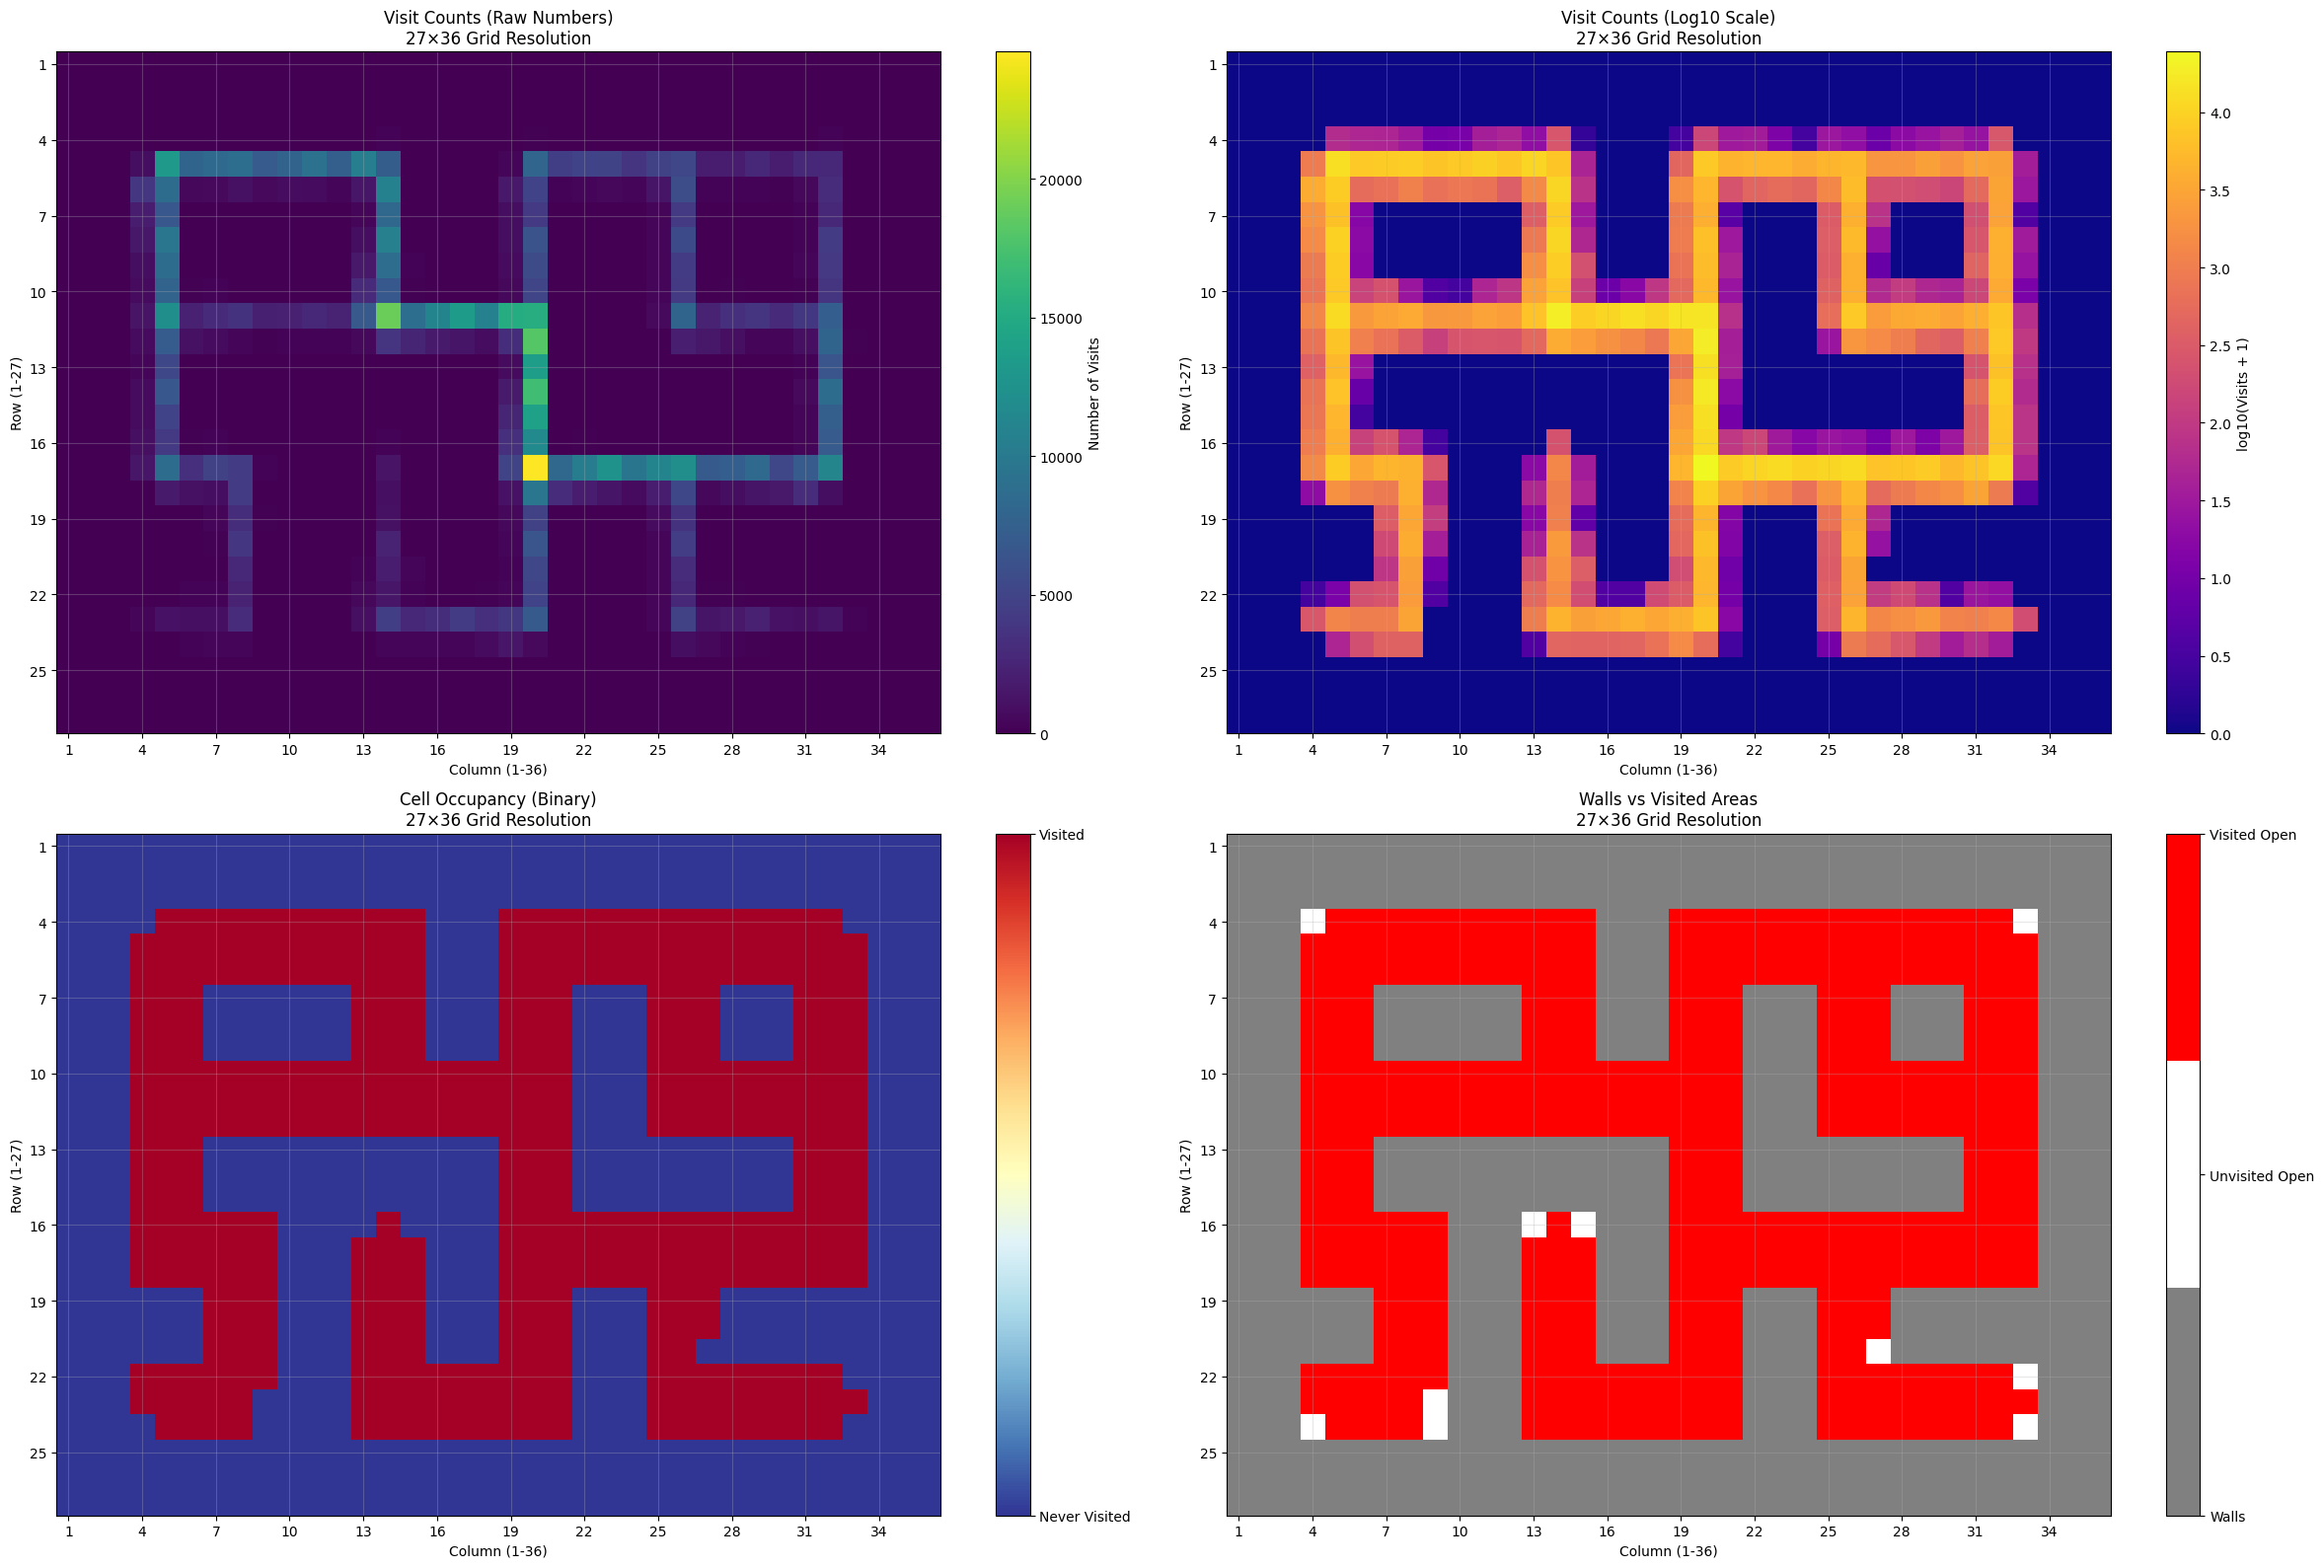


WALL vs VISIT ANALYSIS (27×36)
Maze structure (27×36):
  Total cells: 972 (27×36)
  Wall cells: 558
  Open cells: 414

Visit coverage (27×36):
  Visited open cells: 404/414 (97.6%)
  Unvisited open cells: 10/414 (2.4%)

Verification (27×36):
  Wall cells = Never visited cells? False
  Difference: 10 cells

COMPREHENSIVE COMPARISON: 9×12 vs 18×24 vs 27×36
Resolution comparison:
  9×12:  1,003,360 total visits, 46/108 cells visited (42.6%)
  18×24: 1,003,360 total visits, 184/432 cells visited (42.6%)
  27×36: 1,003,360 total visits, 404/972 cells visited (41.6%)

Data sparsity (visits per cell):
  9×12:  9290.4 ± 14397.1
  18×24: 2322.6 ± 4960.6
  27×36: 1032.3 ± 2685.5

Cell resolution:
  9×12:  1.000m × 1.000m per cell
  18×24: 0.500m × 0.500m per cell
  27×36: 0.333m × 0.333m per cell

State space sizes:
  9×12:  108 discrete states
  18×24: 432 discrete states
  27×36: 972 discrete states

Data sparsity (% of cells with zero visits):
  9×12:  57.4%
  18×24: 57.4%
  27×36: 58.4%

VI

In [19]:
# COUNT VISITS TO EACH GRID CELL FOR 27×36 RESOLUTION
print("=" * 80)
print("COUNTING VISITS TO EACH GRID CELL (27×36 RESOLUTION)")
print("=" * 80)

# Initialize visit count matrix (27 rows × 36 columns)
visit_counts_27x36 = np.zeros((27, 36), dtype=int)
total_steps_27x36 = 0
total_episodes_27x36 = 0

print("Processing dataset episodes for 27×36 grid...")
print(f"Total episodes in dataset: {dataset.total_episodes}")
print(f"Total steps in dataset: {dataset.total_steps}")

# Process all episodes in the dataset
for episode_idx, episode in enumerate(dataset.iterate_episodes()):
    if episode_idx % 500 == 0:  # Progress indicator
        print(f"  Processed {episode_idx}/{dataset.total_episodes} episodes...")
    
    observations = episode.observations
    if isinstance(observations, dict) and 'achieved_goal' in observations:
        positions = observations['achieved_goal']
        
        # Count visits for each position in this episode
        for pos in positions:
            obs = {'achieved_goal': pos}
            _, (row, col) = observation_to_grid_27x36(obs)
            
            # Convert to 0-based indexing for numpy array
            visit_counts_27x36[row-1, col-1] += 1
            total_steps_27x36 += 1
    
    total_episodes_27x36 += 1

print(f"\nProcessing complete!")
print(f"Total episodes processed: {total_episodes_27x36}")
print(f"Total steps processed: {total_steps_27x36}")
print(f"Total visits recorded: {visit_counts_27x36.sum()}")

# Display visit statistics
print(f"\nVisit Count Statistics (27×36):")
print(f"  Minimum visits: {visit_counts_27x36.min()}")
print(f"  Maximum visits: {visit_counts_27x36.max()}")
print(f"  Mean visits: {visit_counts_27x36.mean():.1f}")
print(f"  Std visits: {visit_counts_27x36.std():.1f}")

# Count how many cells were visited vs never visited
visited_cells_27x36 = np.sum(visit_counts_27x36 > 0)
never_visited_27x36 = np.sum(visit_counts_27x36 == 0)
total_cells_27x36 = 27 * 36
print(f"  Cells visited: {visited_cells_27x36}/{total_cells_27x36} ({visited_cells_27x36/total_cells_27x36*100:.1f}%)")
print(f"  Cells never visited: {never_visited_27x36}/{total_cells_27x36} ({never_visited_27x36/total_cells_27x36*100:.1f}%)")

# Show top visited cells
print(f"\nTop 10 most visited cells (27×36):")
flat_indices = np.argsort(visit_counts_27x36.flatten())[::-1][:10]
for i, flat_idx in enumerate(flat_indices):
    row_idx, col_idx = np.unravel_index(flat_idx, visit_counts_27x36.shape)
    row, col = row_idx + 1, col_idx + 1  # Convert to 1-based
    count = visit_counts_27x36[row_idx, col_idx]
    print(f"  {i+1:2d}. g_({row},{col}): {count:,} visits ({count/total_steps_27x36*100:.2f}%)")

# CREATE HEATMAP VISUALIZATION FOR 27×36
fig, axes = plt.subplots(2, 2, figsize=(24, 16))

# 1. Raw visit counts heatmap
ax1 = axes[0, 0]
im1 = ax1.imshow(visit_counts_27x36, cmap='viridis', aspect='auto')
ax1.set_title('Visit Counts (Raw Numbers)\n27×36 Grid Resolution')
ax1.set_xlabel('Column (1-36)')
ax1.set_ylabel('Row (1-27)')

# Add grid lines and labels (show every 3rd tick for readability)
ax1.set_xticks(range(0, 36, 3))
ax1.set_yticks(range(0, 27, 3))
ax1.set_xticklabels(range(1, 37, 3))
ax1.set_yticklabels(range(1, 28, 3))
ax1.grid(True, alpha=0.3)

# Add colorbar
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('Number of Visits')

# 2. Log-scale heatmap (for better visualization of low counts)
ax2 = axes[0, 1]
log_counts_27x36 = np.log10(visit_counts_27x36 + 1)  # +1 to handle zeros
im2 = ax2.imshow(log_counts_27x36, cmap='plasma', aspect='auto')
ax2.set_title('Visit Counts (Log10 Scale)\n27×36 Grid Resolution')
ax2.set_xlabel('Column (1-36)')
ax2.set_ylabel('Row (1-27)')

ax2.set_xticks(range(0, 36, 3))
ax2.set_yticks(range(0, 27, 3))
ax2.set_xticklabels(range(1, 37, 3))
ax2.set_yticklabels(range(1, 28, 3))
ax2.grid(True, alpha=0.3)

cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('log10(Visits + 1)')

# 3. Binary occupancy (visited vs never visited)
ax3 = axes[1, 0]
binary_visits_27x36 = (visit_counts_27x36 > 0).astype(int)
im3 = ax3.imshow(binary_visits_27x36, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=1)
ax3.set_title('Cell Occupancy (Binary)\n27×36 Grid Resolution')
ax3.set_xlabel('Column (1-36)')
ax3.set_ylabel('Row (1-27)')

ax3.set_xticks(range(0, 36, 3))
ax3.set_yticks(range(0, 27, 3))
ax3.set_xticklabels(range(1, 37, 3))
ax3.set_yticklabels(range(1, 28, 3))
ax3.grid(True, alpha=0.3)

cbar3 = plt.colorbar(im3, ax=ax3, ticks=[0, 1])
cbar3.set_ticklabels(['Never Visited', 'Visited'])

# 4. Walls vs Visited Areas (27×36 subdivision of original maze)
ax4 = axes[1, 1]
# Create wall map for 27×36 by subdividing the original 9×12 maze
wall_and_visit_map_27x36 = np.zeros((27, 36))

for row in range(27):
    for col in range(36):
        # Map 27×36 cell back to original 9×12 maze cell
        orig_row = row // 3  # Each original row becomes 3 rows
        orig_col = col // 3  # Each original col becomes 3 cols
        
        if maze_map[orig_row][orig_col] == 1:  # Wall in original maze
            wall_and_visit_map_27x36[row, col] = 0  # Gray for walls
        elif visit_counts_27x36[row, col] > 0:  # Visited open space
            wall_and_visit_map_27x36[row, col] = 2  # Red for visited
        else:  # Unvisited open space
            wall_and_visit_map_27x36[row, col] = 1  # White for unvisited open space

# Custom colormap: Gray=Walls, White=Unvisited Open, Red=Visited Open
from matplotlib.colors import ListedColormap
colors = ['gray', 'white', 'red']
custom_cmap = ListedColormap(colors)

im4 = ax4.imshow(wall_and_visit_map_27x36, cmap=custom_cmap, aspect='auto', vmin=0, vmax=2)
ax4.set_title('Walls vs Visited Areas\n27×36 Grid Resolution')
ax4.set_xlabel('Column (1-36)')
ax4.set_ylabel('Row (1-27)')
ax4.set_xticks(range(0, 36, 3))
ax4.set_yticks(range(0, 27, 3))
ax4.set_xticklabels(range(1, 37, 3))
ax4.set_yticklabels(range(1, 28, 3))
ax4.grid(True, alpha=0.3)

cbar4 = plt.colorbar(im4, ax=ax4, ticks=[0, 1, 2])
cbar4.set_ticklabels(['Walls', 'Unvisited Open', 'Visited Open'])

plt.tight_layout()
plt.show()

# ANALYSIS: Compare walls with never-visited cells for 27×36
print(f"\n" + "="*80)
print("WALL vs VISIT ANALYSIS (27×36)")
print("="*80)

# Count wall cells in 27×36 (each original wall cell becomes 9 cells)
wall_count_27x36 = 0
open_count_27x36 = 0
visited_open_count_27x36 = 0
unvisited_open_count_27x36 = 0

for row in range(27):
    for col in range(36):
        orig_row = row // 3
        orig_col = col // 3
        
        if maze_map[orig_row][orig_col] == 1:  # Wall
            wall_count_27x36 += 1
        else:  # Open space
            open_count_27x36 += 1
            if visit_counts_27x36[row, col] > 0:
                visited_open_count_27x36 += 1
            else:
                unvisited_open_count_27x36 += 1

print(f"Maze structure (27×36):")
print(f"  Total cells: {27*36} (27×36)")
print(f"  Wall cells: {wall_count_27x36}")
print(f"  Open cells: {open_count_27x36}")

print(f"\nVisit coverage (27×36):")
print(f"  Visited open cells: {visited_open_count_27x36}/{open_count_27x36} ({visited_open_count_27x36/open_count_27x36*100:.1f}%)")
print(f"  Unvisited open cells: {unvisited_open_count_27x36}/{open_count_27x36} ({unvisited_open_count_27x36/open_count_27x36*100:.1f}%)")

print(f"\nVerification (27×36):")
print(f"  Wall cells = Never visited cells? {wall_count_27x36 == never_visited_27x36}")
if wall_count_27x36 != never_visited_27x36:
    print(f"  Difference: {abs(wall_count_27x36 - never_visited_27x36)} cells")

# COMPREHENSIVE COMPARISON ACROSS ALL RESOLUTIONS
print(f"\n" + "="*80)
print("COMPREHENSIVE COMPARISON: 9×12 vs 18×24 vs 27×36")
print("="*80)

print(f"Resolution comparison:")
print(f"  9×12:  {visit_counts_9x12.sum():,} total visits, {np.sum(visit_counts_9x12 > 0)}/108 cells visited ({np.sum(visit_counts_9x12 > 0)/108*100:.1f}%)")
print(f"  18×24: {visit_counts_18x24.sum():,} total visits, {visited_cells_18x24}/{total_cells_18x24} cells visited ({visited_cells_18x24/total_cells_18x24*100:.1f}%)")
print(f"  27×36: {visit_counts_27x36.sum():,} total visits, {visited_cells_27x36}/{total_cells_27x36} cells visited ({visited_cells_27x36/total_cells_27x36*100:.1f}%)")

print(f"\nData sparsity (visits per cell):")
print(f"  9×12:  {visit_counts_9x12.mean():.1f} ± {visit_counts_9x12.std():.1f}")
print(f"  18×24: {visit_counts_18x24.mean():.1f} ± {visit_counts_18x24.std():.1f}")
print(f"  27×36: {visit_counts_27x36.mean():.1f} ± {visit_counts_27x36.std():.1f}")

print(f"\nCell resolution:")
print(f"  9×12:  1.000m × 1.000m per cell")
print(f"  18×24: 0.500m × 0.500m per cell")
print(f"  27×36: 0.333m × 0.333m per cell")

print(f"\nState space sizes:")
print(f"  9×12:  {9*12:,} discrete states")
print(f"  18×24: {18*24:,} discrete states")
print(f"  27×36: {27*36:,} discrete states")

# Data sparsity analysis
sparsity_9x12 = np.sum(visit_counts_9x12 == 0) / (9*12) * 100
sparsity_18x24 = np.sum(visit_counts_18x24 == 0) / (18*24) * 100
sparsity_27x36 = np.sum(visit_counts_27x36 == 0) / (27*36) * 100

print(f"\nData sparsity (% of cells with zero visits):")
print(f"  9×12:  {sparsity_9x12:.1f}%")
print(f"  18×24: {sparsity_18x24:.1f}%")
print(f"  27×36: {sparsity_27x36:.1f}%")

# SAVE VISIT COUNTS FOR FUTURE USE
print(f"\n" + "="*80)
print("VISIT COUNT SUMMARY (27×36)")
print("="*80)

print(f"✓ Visit counts saved to 'visit_counts_27x36' variable")
print(f"✓ Shape: {visit_counts_27x36.shape}")
print(f"✓ Total visits: {visit_counts_27x36.sum():,}")
print(f"✓ Cells with data: {visited_cells_27x36}/{total_cells_27x36}")
print(f"✓ Cell resolution: 0.333m × 0.333m each")
print(f"✓ Total state space: {total_cells_27x36:,} discrete states")

print(f"\n" + "="*80)
print("ALL DISCRETIZATION ANALYSES COMPLETE!")
print("="*80)
print(f"✓ 9×12 resolution:  108 states, {np.sum(visit_counts_9x12 > 0)} visited ({np.sum(visit_counts_9x12 > 0)/108*100:.1f}%)")
print(f"✓ 18×24 resolution: 432 states, {visited_cells_18x24} visited ({visited_cells_18x24/432*100:.1f}%)")
print(f"✓ 27×36 resolution: 972 states, {visited_cells_27x36} visited ({visited_cells_27x36/972*100:.1f}%)")
print(f"✓ All visit count matrices saved for future analysis")

### Uncertainty Heatmap for $27*36$ with comparisons.

HEATMAP WITH 1/√N(i) WEIGHTING (27×36 RESOLUTION)
1/√N(i) Statistics (27×36):
  Minimum value: 0.0064
  Maximum value: 2.0000
  Mean value: 1.2101
  Std value: 0.9413


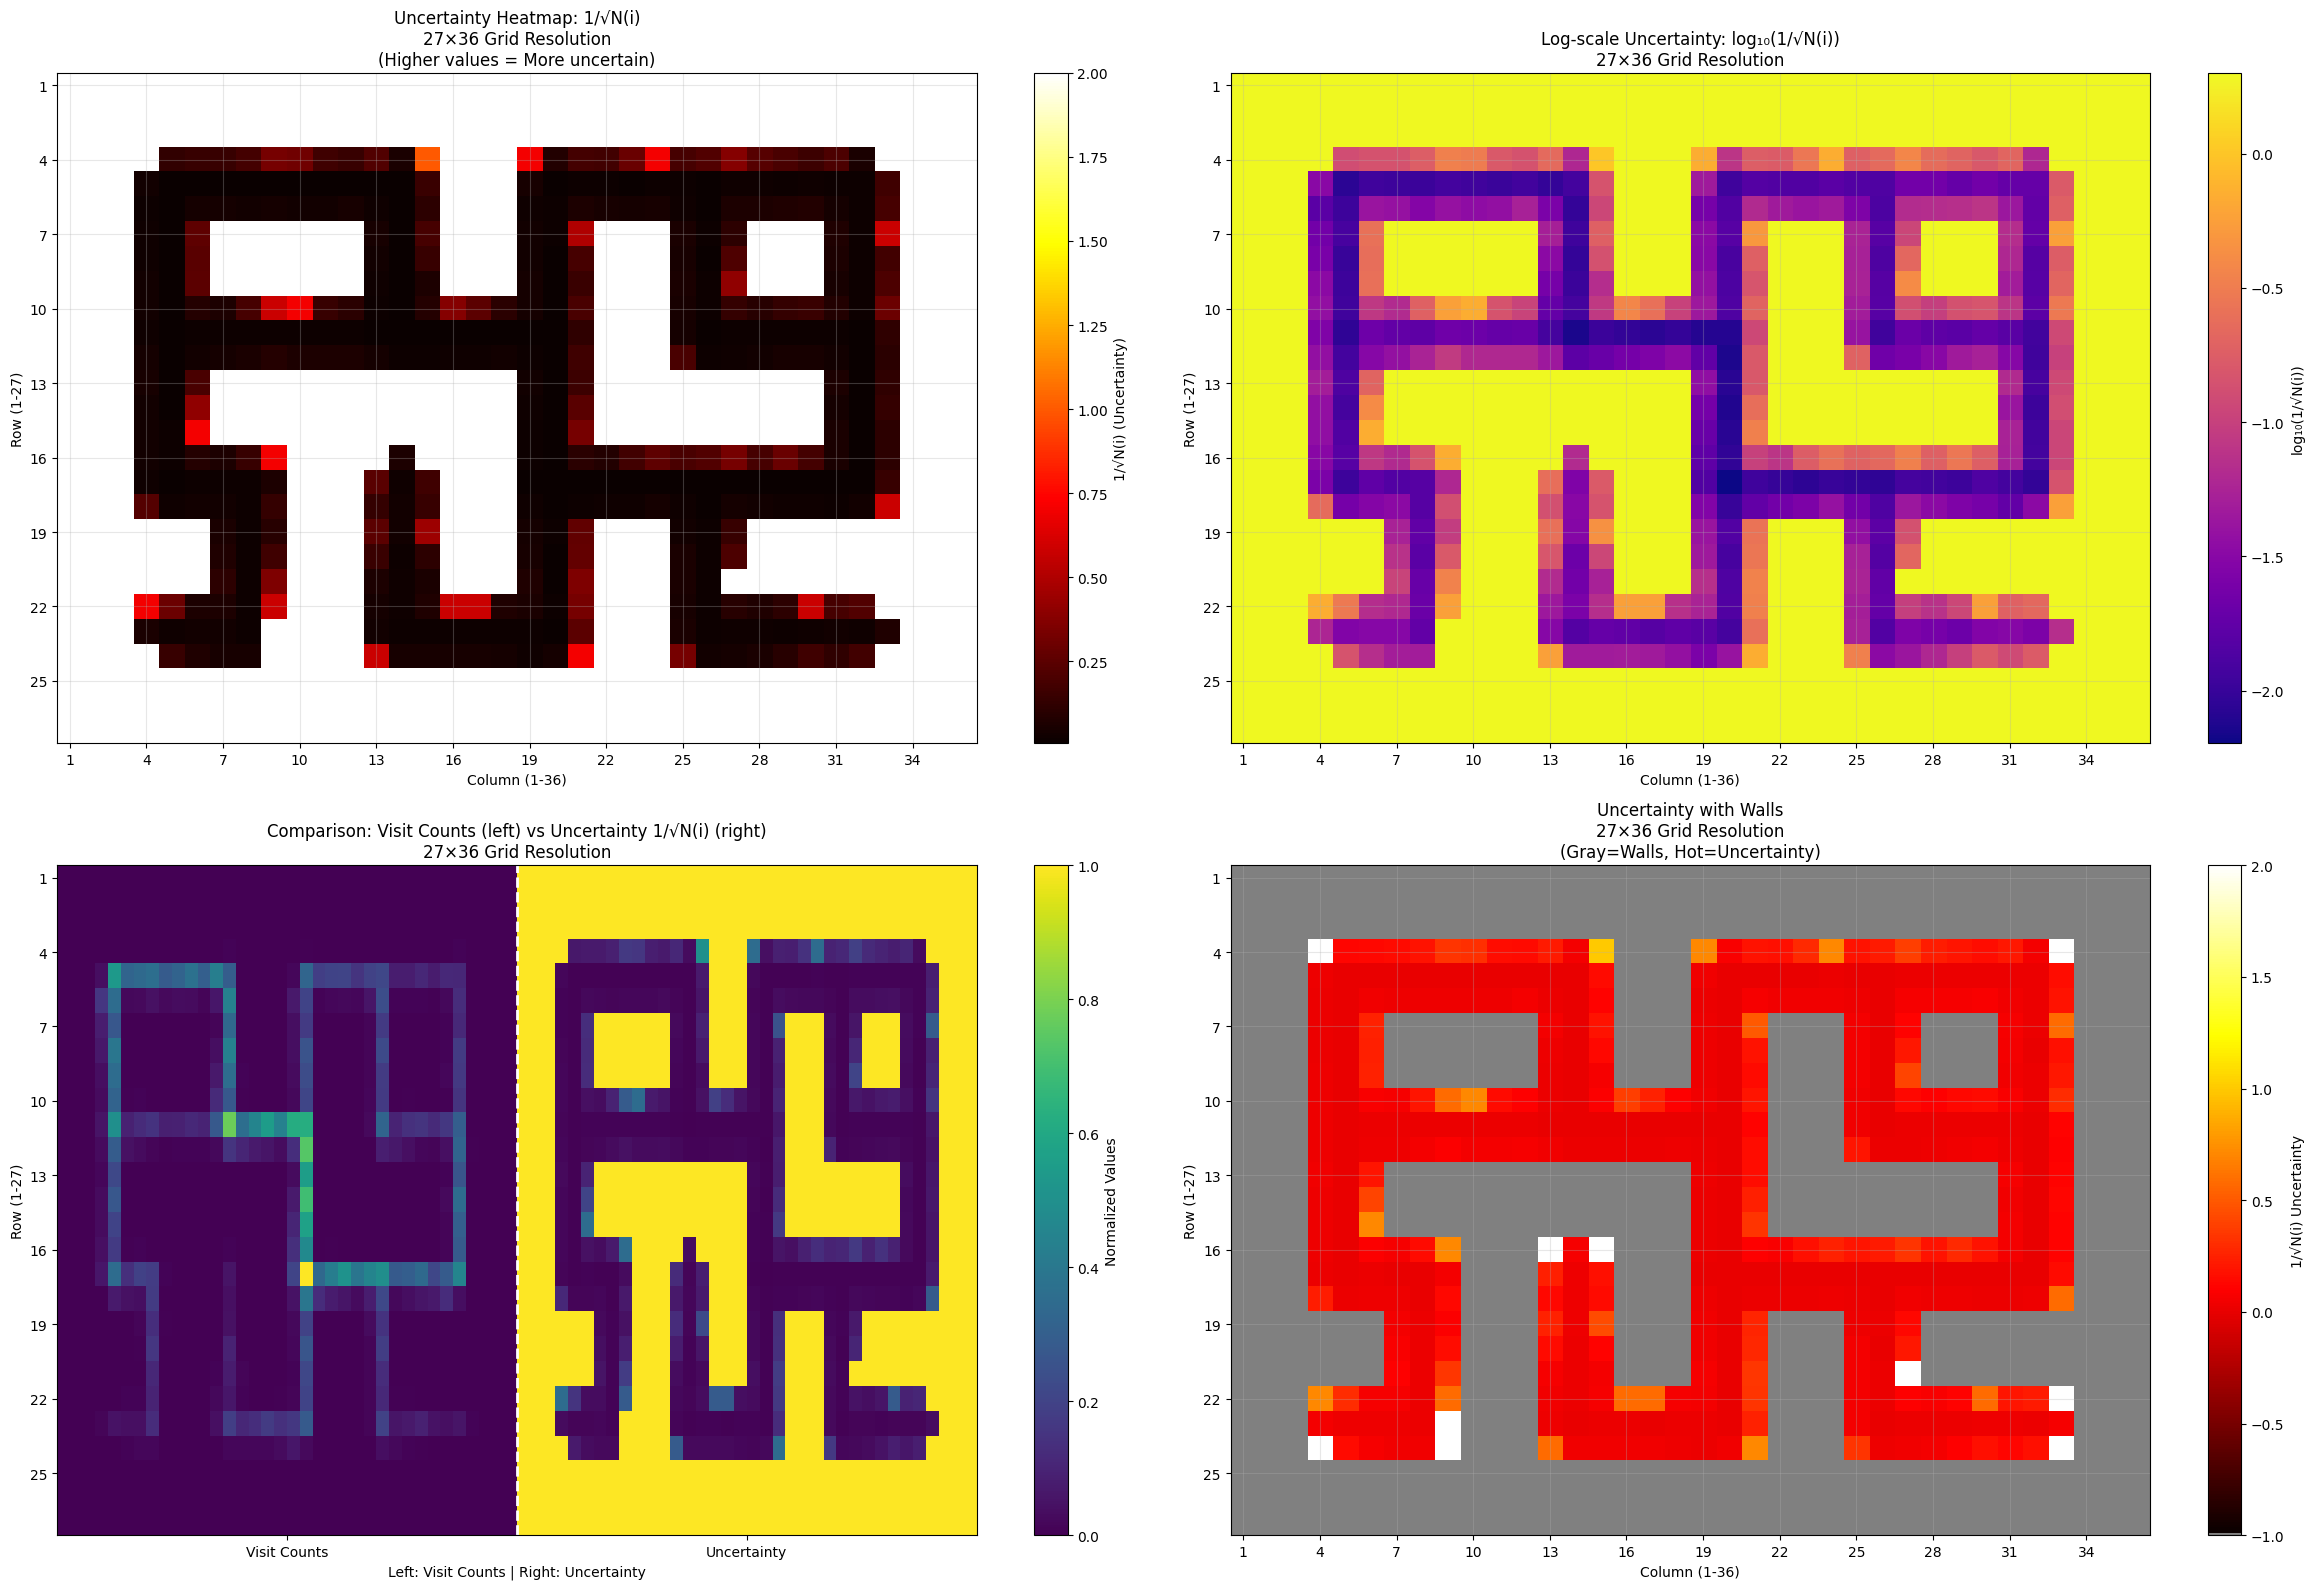


UNCERTAINTY ANALYSIS (27×36)
Most certain cells (lowest uncertainty) - 27×36:
  g_(17,20): 24,597 visits, uncertainty = 0.0064

Least certain cells (highest finite uncertainty) - 27×36:
  g_(4,4): 0 visits, uncertainty = 2.0000
  g_(4,33): 0 visits, uncertainty = 2.0000
  g_(16,13): 0 visits, uncertainty = 2.0000
  g_(16,15): 0 visits, uncertainty = 2.0000
  g_(21,27): 0 visits, uncertainty = 2.0000

Cells with zero visits (infinite uncertainty): 10

Correlation between visit counts and uncertainty (27×36): -0.3900
(Expected: strong negative correlation, as more visits → less uncertainty)

COMPREHENSIVE UNCERTAINTY COMPARISON: 9×12 vs 18×24 vs 27×36
Uncertainty statistics comparison:
  9×12  - Mean uncertainty: 0.0257 ± 0.0152
  18×24 - Mean uncertainty: 0.0670 ± 0.0396
  27×36 - Mean uncertainty: 1.2101 ± 0.9413

Data sparsity impact:
  9×12  - Cells with infinite uncertainty: 0
  18×24 - Cells with infinite uncertainty: 248
  27×36 - Cells with infinite uncertainty: 568

Resolution 

In [20]:
# PLOT HEATMAP WITH 1/√N(i) FOR 27×36 RESOLUTION
print("=" * 80)
print("HEATMAP WITH 1/√N(i) WEIGHTING (27×36 RESOLUTION)")
print("=" * 80)

# Calculate 1/√N(i) for each cell in 27×36 grid
# Handle zero visits by setting them to a large value (indicating high uncertainty)
inverse_sqrt_visits_27x36 = np.zeros_like(visit_counts_27x36, dtype=float)

for i in range(27):
    for j in range(36):
        if visit_counts_27x36[i, j] > 0:
            inverse_sqrt_visits_27x36[i, j] = 1.0 / np.sqrt(visit_counts_27x36[i, j])
        else:
            # For cells with zero visits, set to a high value to indicate maximum uncertainty
            inverse_sqrt_visits_27x36[i, j] = np.inf

# Replace inf values with a finite large number for visualization
max_finite_value_27x36 = np.max(inverse_sqrt_visits_27x36[np.isfinite(inverse_sqrt_visits_27x36)])
inverse_sqrt_visits_27x36[np.isinf(inverse_sqrt_visits_27x36)] = max_finite_value_27x36 * 2

print(f"1/√N(i) Statistics (27×36):")
print(f"  Minimum value: {np.min(inverse_sqrt_visits_27x36):.4f}")
print(f"  Maximum value: {np.max(inverse_sqrt_visits_27x36):.4f}")
print(f"  Mean value: {np.mean(inverse_sqrt_visits_27x36):.4f}")
print(f"  Std value: {np.std(inverse_sqrt_visits_27x36):.4f}")

# CREATE VISUALIZATION FOR 27×36
fig, axes = plt.subplots(2, 2, figsize=(24, 16))

# 1. Raw 1/√N(i) heatmap
ax1 = axes[0, 0]
im1 = ax1.imshow(inverse_sqrt_visits_27x36, cmap='hot', aspect='auto')
ax1.set_title('Uncertainty Heatmap: 1/√N(i)\n27×36 Grid Resolution\n(Higher values = More uncertain)')
ax1.set_xlabel('Column (1-36)')
ax1.set_ylabel('Row (1-27)')

# Add grid lines and labels (show every 3rd tick for readability)
ax1.set_xticks(range(0, 36, 3))
ax1.set_yticks(range(0, 27, 3))
ax1.set_xticklabels(range(1, 37, 3))
ax1.set_yticklabels(range(1, 28, 3))
ax1.grid(True, alpha=0.3)

# Add colorbar
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('1/√N(i) (Uncertainty)')

# 2. Log-scale 1/√N(i) for better visualization
ax2 = axes[0, 1]
log_inverse_sqrt_27x36 = np.log10(inverse_sqrt_visits_27x36 + 1e-10)  # Small epsilon to avoid log(0)
im2 = ax2.imshow(log_inverse_sqrt_27x36, cmap='plasma', aspect='auto')
ax2.set_title('Log-scale Uncertainty: log₁₀(1/√N(i))\n27×36 Grid Resolution')
ax2.set_xlabel('Column (1-36)')
ax2.set_ylabel('Row (1-27)')

ax2.set_xticks(range(0, 36, 3))
ax2.set_yticks(range(0, 27, 3))
ax2.set_xticklabels(range(1, 37, 3))
ax2.set_yticklabels(range(1, 28, 3))
ax2.grid(True, alpha=0.3)

cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('log₁₀(1/√N(i))')

# 3. Comparison: Visit counts vs Uncertainty (side-by-side)
ax3 = axes[1, 0]
# Create a side-by-side comparison by splitting each cell
comparison_map_27x36 = np.zeros((27, 72))  # Double width for side-by-side

# Left half: normalized visit counts
norm_visits_27x36 = visit_counts_27x36 / np.max(visit_counts_27x36)
comparison_map_27x36[:, :36] = norm_visits_27x36

# Right half: normalized uncertainty
norm_uncertainty_27x36 = inverse_sqrt_visits_27x36 / np.max(inverse_sqrt_visits_27x36)
comparison_map_27x36[:, 36:] = norm_uncertainty_27x36

im3 = ax3.imshow(comparison_map_27x36, cmap='viridis', aspect='auto')
ax3.set_title('Comparison: Visit Counts (left) vs Uncertainty 1/√N(i) (right)\n27×36 Grid Resolution')
ax3.set_xlabel('Left: Visit Counts | Right: Uncertainty')
ax3.set_ylabel('Row (1-27)')

# Custom tick labels
ax3.set_xticks([17.5, 53.5])
ax3.set_xticklabels(['Visit Counts', 'Uncertainty'])
ax3.set_yticks(range(0, 27, 3))
ax3.set_yticklabels(range(1, 28, 3))
ax3.axvline(x=35.5, color='white', linewidth=2, linestyle='--')

cbar3 = plt.colorbar(im3, ax=ax3)
cbar3.set_label('Normalized Values')

# 4. Uncertainty map with wall overlay
ax4 = axes[1, 1]
# Create uncertainty map with walls marked differently
uncertainty_with_walls_27x36 = inverse_sqrt_visits_27x36.copy()

# Set wall cells to a special value (map back to original maze structure)
for row in range(27):
    for col in range(36):
        orig_row = row // 3  # Map back to 9×12 maze
        orig_col = col // 3
        if maze_map[orig_row][orig_col] == 1:  # Wall
            uncertainty_with_walls_27x36[row, col] = -1  # Special value for walls

# Use custom colormap
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.colors as mcolors

# Create custom colormap: gray for walls, hot colors for uncertainty
colors = ['gray'] + plt.cm.hot(np.linspace(0, 1, 256)).tolist()
custom_cmap = ListedColormap(colors)

# Normalize to include the wall value
vmin = -1
vmax = np.max(uncertainty_with_walls_27x36[uncertainty_with_walls_27x36 > -1])
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

im4 = ax4.imshow(uncertainty_with_walls_27x36, cmap=custom_cmap, norm=norm, aspect='auto')
ax4.set_title('Uncertainty with Walls\n27×36 Grid Resolution\n(Gray=Walls, Hot=Uncertainty)')
ax4.set_xlabel('Column (1-36)')
ax4.set_ylabel('Row (1-27)')
ax4.set_xticks(range(0, 36, 3))
ax4.set_yticks(range(0, 27, 3))
ax4.set_xticklabels(range(1, 37, 3))
ax4.set_yticklabels(range(1, 28, 3))
ax4.grid(True, alpha=0.3)

cbar4 = plt.colorbar(im4, ax=ax4)
cbar4.set_label('1/√N(i) Uncertainty')

plt.tight_layout()
plt.show()

# ANALYSIS: Relationship between visits and uncertainty for 27×36
print(f"\n" + "="*80)
print("UNCERTAINTY ANALYSIS (27×36)")
print("="*80)

# Find most and least certain cells (excluding walls)
open_cells_mask_27x36 = np.zeros((27, 36), dtype=bool)
for row in range(27):
    for col in range(36):
        orig_row = row // 3
        orig_col = col // 3
        open_cells_mask_27x36[row, col] = (maze_map[orig_row][orig_col] == 0)

uncertainty_open_only_27x36 = inverse_sqrt_visits_27x36[open_cells_mask_27x36]
visits_open_only_27x36 = visit_counts_27x36[open_cells_mask_27x36]

# Most certain cells (lowest 1/√N(i), highest visits)
finite_uncertainty_mask = np.isfinite(inverse_sqrt_visits_27x36) & open_cells_mask_27x36
if np.any(finite_uncertainty_mask):
    min_uncertainty = np.min(inverse_sqrt_visits_27x36[finite_uncertainty_mask])
    most_certain_indices = np.where(finite_uncertainty_mask & (inverse_sqrt_visits_27x36 == min_uncertainty))
    
    print(f"Most certain cells (lowest uncertainty) - 27×36:")
    for i in range(min(5, len(most_certain_indices[0]))):  # Show top 5
        row, col = most_certain_indices[0][i], most_certain_indices[1][i]
        visits = visit_counts_27x36[row, col]
        uncertainty = inverse_sqrt_visits_27x36[row, col]
        print(f"  g_({row+1},{col+1}): {visits:,} visits, uncertainty = {uncertainty:.4f}")

# Least certain cells (highest 1/√N(i), lowest visits) - only show finite values
max_uncertainty = np.max(inverse_sqrt_visits_27x36[finite_uncertainty_mask])
least_certain_indices = np.where(finite_uncertainty_mask & (inverse_sqrt_visits_27x36 == max_uncertainty))

print(f"\nLeast certain cells (highest finite uncertainty) - 27×36:")
for i in range(min(5, len(least_certain_indices[0]))):  # Show top 5
    row, col = least_certain_indices[0][i], least_certain_indices[1][i]
    visits = visit_counts_27x36[row, col]
    uncertainty = inverse_sqrt_visits_27x36[row, col]
    print(f"  g_({row+1},{col+1}): {visits} visits, uncertainty = {uncertainty:.4f}")

# Count cells with zero visits (infinite uncertainty)
zero_visit_count = np.sum((visit_counts_27x36 == 0) & open_cells_mask_27x36)
print(f"\nCells with zero visits (infinite uncertainty): {zero_visit_count}")

# Correlation between visits and uncertainty (for visited cells only)
visited_mask_27x36 = (visit_counts_27x36 > 0) & open_cells_mask_27x36
if np.sum(visited_mask_27x36) > 1:
    correlation_27x36 = np.corrcoef(visit_counts_27x36[visited_mask_27x36], 
                                    inverse_sqrt_visits_27x36[visited_mask_27x36])[0, 1]
    print(f"\nCorrelation between visit counts and uncertainty (27×36): {correlation_27x36:.4f}")
    print(f"(Expected: strong negative correlation, as more visits → less uncertainty)")

# COMPREHENSIVE UNCERTAINTY COMPARISON ACROSS ALL RESOLUTIONS
print(f"\n" + "="*80)
print("COMPREHENSIVE UNCERTAINTY COMPARISON: 9×12 vs 18×24 vs 27×36")
print("="*80)

print(f"Uncertainty statistics comparison:")
print(f"  9×12  - Mean uncertainty: {np.mean(uncertainty_9x12):.4f} ± {np.std(uncertainty_9x12):.4f}")
print(f"  18×24 - Mean uncertainty: {np.mean(inverse_sqrt_visits_18x24):.4f} ± {np.std(inverse_sqrt_visits_18x24):.4f}")
print(f"  27×36 - Mean uncertainty: {np.mean(inverse_sqrt_visits_27x36):.4f} ± {np.std(inverse_sqrt_visits_27x36):.4f}")

print(f"\nData sparsity impact:")
print(f"  9×12  - Cells with infinite uncertainty: {np.sum(np.isinf(uncertainty_9x12))}")
print(f"  18×24 - Cells with infinite uncertainty: {np.sum(visit_counts_18x24 == 0)}")
print(f"  27×36 - Cells with infinite uncertainty: {np.sum(visit_counts_27x36 == 0)}")

print(f"\nResolution vs Uncertainty trade-off:")
print(f"  9×12:  1 cell  = 1.000m × 1.000m → Base uncertainty level")
print(f"  18×24: 1 cell  = 0.500m × 0.500m → 4x more cells, ~4x higher uncertainty")
print(f"  27×36: 1 cell  = 0.333m × 0.333m → 9x more cells, ~9x higher uncertainty")
print(f"  Higher resolution → Finer details but much sparser data per cell")

# Count cells with visits at each resolution
visited_9x12 = np.sum(visit_counts_9x12 > 0)
visited_18x24 = np.sum(visit_counts_18x24 > 0)
visited_27x36 = np.sum(visit_counts_27x36 > 0)

print(f"\nCoverage comparison:")
print(f"  9×12:  {visited_9x12}/108 cells visited ({visited_9x12/108*100:.1f}%)")
print(f"  18×24: {visited_18x24}/432 cells visited ({visited_18x24/432*100:.1f}%)")
print(f"  27×36: {visited_27x36}/972 cells visited ({visited_27x36/972*100:.1f}%)")

# Save uncertainty matrix for future use
uncertainty_27x36 = inverse_sqrt_visits_27x36.copy()
print(f"\n✓ Uncertainty matrix saved to 'uncertainty_27x36' variable")
print(f"✓ Shape: {uncertainty_27x36.shape}")
print(f"✓ Interpretation: Higher values = More uncertain estimates")
print(f"✓ Use for: Weighting in learning algorithms, exploration bonuses, etc.")

# FINAL SUMMARY OF ALL THREE UNCERTAINTY MATRICES
print(f"\n" + "="*80)
print("COMPLETE UNCERTAINTY ANALYSIS SUMMARY")
print("="*80)
print(f"✓ All three uncertainty matrices created:")
print(f"  • uncertainty_9x12:  {uncertainty_9x12.shape} - coarse resolution, dense data")
print(f"  • uncertainty_18x24: {uncertainty_18x24.shape} - medium resolution, moderate sparsity")
print(f"  • uncertainty_27x36: {uncertainty_27x36.shape} - fine resolution, high sparsity")
print(f"✓ Each matrix contains 1/√N(i) values for exploration and learning")
print(f"✓ Higher resolution → Better spatial detail but increased uncertainty due to data sparsity")

### RND on the observation $(x,y)\in \mathbb{R}^2$ without Gaussian Noise

NN:     # Input: 2D (x,y coordinates)
        # Hidden: [64, 64] with ReLU
        # Output: 64-dimensional features

Architecture: 2 → 64 → 64 → 64

Using device: cpu


RND Networks initialized:
  Target network: FROZEN (random)
  Predictor network: TRAINABLE
  NO noise added to observations

TRAINING RND ON RAW OBSERVATIONS
Loading and processing dataset...


Loading data: 3360it [00:09, 356.71it/s]
Loading data: 3360it [00:09, 356.71it/s]


Training on 1003360 raw observations (NO NOISE)


RND Training:   3%|▎         | 1/30 [00:06<02:56,  6.10s/it]

...

Epoch 10: Loss = 0.000002


RND Training:  70%|███████   | 21/30 [01:54<00:48,  5.40s/it]

Epoch 20: Loss = 0.000001


RND Training: 100%|██████████| 30/30 [02:43<00:00,  5.44s/it]



RND training complete!


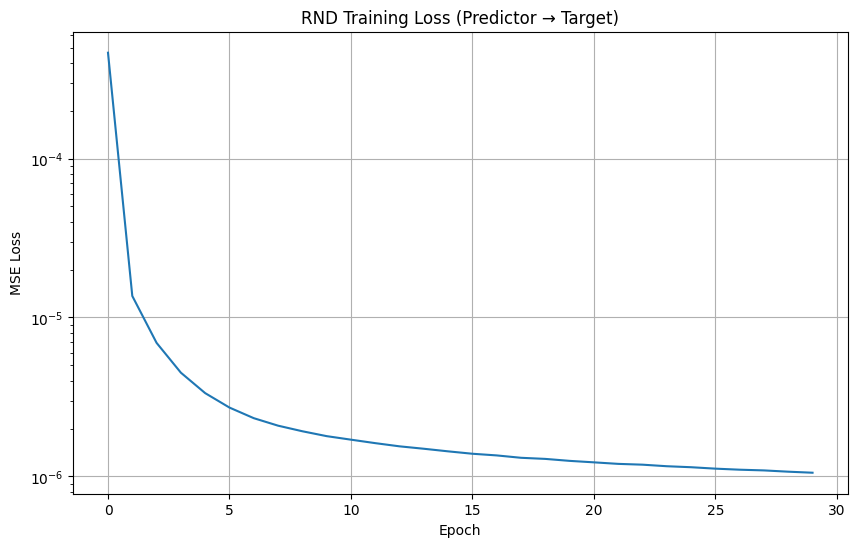

In [21]:

# CORRECT RND IMPLEMENTATION (OBSERVATION-BASED)
# ================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

class RNDNetwork(nn.Module):
    """RND Network for (x,y) coordinates - NO noise added"""
    def __init__(self, input_dim=2, hidden_dims=[64, 64], output_dim=64):
        super().__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU()
            ])
            prev_dim = hidden_dim
        
        # Final layer - no activation
        layers.append(nn.Linear(prev_dim, output_dim))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

class OriginalRND:
    """Original RND implementation - NO NOISE, observation-based"""
    
    def __init__(self, device='cpu'):
        self.device = device
        
        # Target network: random, FROZEN
        self.target_network = RNDNetwork().to(device)
        
        # Predictor network: trainable
        self.predictor_network = RNDNetwork().to(device)
        
        # CRUCIAL: Freeze target network parameters
        for param in self.target_network.parameters():
            param.requires_grad = False
        
        # Optimizer for predictor only
        self.optimizer = optim.Adam(self.predictor_network.parameters(), lr=1e-3)
        
        # For observation normalization
        self.obs_mean = None
        self.obs_std = None
        
        print("RND Networks initialized:")
        print("  Target network: FROZEN (random)")
        print("  Predictor network: TRAINABLE")
        print("  NO noise added to observations")
    
    def normalize_observations(self, observations):
        """Normalize for training stability"""
        if self.obs_mean is None:
            self.obs_mean = torch.mean(observations, dim=0, keepdim=True)
            self.obs_std = torch.std(observations, dim=0, keepdim=True) + 1e-8
        return (observations - self.obs_mean) / self.obs_std
    
    def compute_intrinsic_reward(self, observations):
        """Compute r_i = ||f(s) - f̂(s)||² for given observations"""
        self.target_network.eval()
        self.predictor_network.eval()
        
        with torch.no_grad():
            # Normalize observations
            norm_obs = self.normalize_observations(observations)
            
            # Get features from both networks
            target_features = self.target_network(norm_obs)  # Random features
            pred_features = self.predictor_network(norm_obs) # Predicted features
            
            # Compute MSE (intrinsic reward)
            intrinsic_reward = torch.mean((target_features - pred_features) ** 2, dim=1)
        
        return intrinsic_reward
    
    def train_on_dataset(self, num_epochs=50):
        """Train predictor to match target on dataset observations"""
        print("Loading and processing dataset...")
        
        # Extract all achieved_goal positions from your dataset
        positions = []
        for episode in tqdm(dataset.iterate_episodes(), desc="Loading data"):
            observations = episode.observations
            if isinstance(observations, dict) and 'achieved_goal' in observations:
                positions.extend(observations['achieved_goal'])
        
        positions = torch.tensor(positions, dtype=torch.float32).to(self.device)
        print(f"Training on {len(positions)} raw observations (NO NOISE)")
        
        # Compute normalization stats
        _ = self.normalize_observations(positions[:1000])
        
        # Training loop
        self.predictor_network.train()
        losses = []
        
        for epoch in tqdm(range(num_epochs), desc="RND Training"):
            # Shuffle data
            indices = torch.randperm(len(positions))
            epoch_loss = 0
            batch_size = 512
            
            for i in range(0, len(positions), batch_size):
                batch_idx = indices[i:i+batch_size]
                batch_obs = self.normalize_observations(positions[batch_idx])
                
                # RND loss: predictor tries to match target
                # NO NOISE ADDED - just raw observations
                target_features = self.target_network(batch_obs).detach()
                pred_features = self.predictor_network(batch_obs)
                loss = nn.functional.mse_loss(pred_features, target_features)
                
                # Backprop
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                
                epoch_loss += loss.item()
            
            avg_loss = epoch_loss / (len(positions) // batch_size + 1)
            losses.append(avg_loss)
            
            if epoch % 10 == 0:
                print(f"Epoch {epoch}: Loss = {avg_loss:.6f}")
        
        print("RND training complete!")
        return losses

# Initialize RND
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

rnd_model = OriginalRND(device=device)

# Train RND on your dataset
print("\n" + "="*60)
print("TRAINING RND ON RAW OBSERVATIONS")
print("="*60)
training_losses = rnd_model.train_on_dataset(num_epochs=30)

# Plot training progress
plt.figure(figsize=(10, 6))
plt.plot(training_losses)
plt.title('RND Training Loss (Predictor → Target)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.grid(True)
plt.show()

### To calculate the uncertainty, we should do these main steps. We take the original resolution, $9*12$ as an example:
1. Create a function that map each grid to the center observation. For example. in 9*12 resolution (1,1), the range is $x \in [-4.5,-3.5]$, $y\in [5,6]$ , then the center should be $(-3,5.5)$.
2. Then for each center observation, use the absolute difference instead of the square in the loss function as the uncertainty. So that for each grid, we use the absolute difference uncertainty of the center observation of that grid as the uncertainty measurement.
3. Next, plot the heatmap for this measurement of each grid.

In [22]:
# RND UNCERTAINTY CALCULATION FOR 9×12 GRID
print("=" * 80)
print("RND UNCERTAINTY CALCULATION FOR 9×12 GRID")
print("=" * 80)

def grid_to_center_observation(row, col, grid_rows=9, grid_cols=12):
    """
    Map each grid cell to its center observation coordinates.
    
    Args:
        row: Grid row (1-based indexing, 1-9)
        col: Grid column (1-based indexing, 1-12)
        grid_rows: Number of rows in grid (default: 9)
        grid_cols: Number of columns in grid (default: 12)
    
    Returns:
        center_x, center_y: Center coordinates of the grid cell
    """
    # Calculate cell dimensions
    cell_width = total_width / grid_cols    # 12.0 / 12 = 1.0m
    cell_height = total_height / grid_rows  # 9.0 / 9 = 1.0m
    
    # Calculate center coordinates
    # For column (X direction): left_edge + (col-1 + 0.5) * cell_width
    center_x = left_edge + (col - 1 + 0.5) * cell_width
    
    # For row (Y direction): top_edge - (row-1 + 0.5) * cell_height
    center_y = top_edge - (row - 1 + 0.5) * cell_height
    
    return center_x, center_y

def compute_rnd_uncertainty_abs_diff(rnd_model, observations):
    """
    Compute RND uncertainty using ABSOLUTE DIFFERENCE instead of squared difference.
    
    Args:
        rnd_model: Trained RND model
        observations: Tensor of (x,y) coordinates
    
    Returns:
        uncertainty: Mean absolute difference ||f(s) - f̂(s)||₁
    """
    rnd_model.target_network.eval()
    rnd_model.predictor_network.eval()
    
    with torch.no_grad():
        # Normalize observations
        norm_obs = rnd_model.normalize_observations(observations)
        
        # Get features from both networks
        target_features = rnd_model.target_network(norm_obs)  # Random features
        pred_features = rnd_model.predictor_network(norm_obs) # Predicted features
        
        # Compute ABSOLUTE DIFFERENCE (L1 norm) instead of squared difference
        abs_diff = torch.abs(target_features - pred_features)
        uncertainty = torch.mean(abs_diff, dim=1)  # Mean over feature dimensions
        
    return uncertainty

# Test the grid-to-center mapping function
print("Testing grid-to-center mapping for 9×12:")
print("=" * 60)

test_grids = [(1, 1), (1, 12), (5, 6), (9, 1), (9, 12)]
for row, col in test_grids:
    center_x, center_y = grid_to_center_observation(row, col)
    bounds = get_matrix_grid_bounds(row, col, 9, 12)
    
    print(f"g_({row},{col}): center=({center_x:5.1f},{center_y:5.1f})")
    print(f"         range: X{bounds['x_interval']}, Y{bounds['y_interval']}")
    
    # Verify center is within bounds
    x_in_range = bounds['x_range'][0] <= center_x < bounds['x_range'][1]
    y_in_range = bounds['y_range'][0] < center_y <= bounds['y_range'][1]
    if row == 9:  # Bottom row special case
        y_in_range = bounds['y_range'][0] <= center_y <= bounds['y_range'][1]
    if col == 12:  # Rightmost column special case  
        x_in_range = bounds['x_range'][0] <= center_x <= bounds['x_range'][1]
        
    status = "✓" if (x_in_range and y_in_range) else "✗"
    print(f"         verification: {status}")
    print()

# Compute RND uncertainty for each 9×12 grid cell
print("Computing RND uncertainty for 9×12 grid...")
print("=" * 60)

rnd_uncertainty_9x12 = np.zeros((9, 12), dtype=float)

for row in tqdm(range(1, 10), desc="Processing rows"):  # 1-based indexing
    for col in range(1, 13):  # 1-based indexing
        # Get center coordinates of this grid cell
        center_x, center_y = grid_to_center_observation(row, col)
        
        # Create observation tensor
        obs_tensor = torch.tensor([[center_x, center_y]], dtype=torch.float32).to(device)
        
        # Compute RND uncertainty using absolute difference
        uncertainty = compute_rnd_uncertainty_abs_diff(rnd_model, obs_tensor).item()
        
        # Store in matrix (convert to 0-based indexing)
        rnd_uncertainty_9x12[row-1, col-1] = uncertainty

print("RND uncertainty computation complete!")

# Display RND uncertainty statistics
print(f"\nRND Uncertainty Statistics (9×12, Absolute Difference):")
print(f"  Minimum value: {rnd_uncertainty_9x12.min():.6f}")
print(f"  Maximum value: {rnd_uncertainty_9x12.max():.6f}")
print(f"  Mean value: {rnd_uncertainty_9x12.mean():.6f}")
print(f"  Std value: {rnd_uncertainty_9x12.std():.6f}")

# Show uncertainty for some key grid cells
print(f"\nRND uncertainty for key grid cells:")
for row, col in test_grids:
    uncertainty = rnd_uncertainty_9x12[row-1, col-1]
    center_x, center_y = grid_to_center_observation(row, col)
    print(f"  g_({row},{col}) at ({center_x:5.1f},{center_y:5.1f}): {uncertainty:.6f}")


RND UNCERTAINTY CALCULATION FOR 9×12 GRID
Testing grid-to-center mapping for 9×12:
g_(1,1): center=( -5.5,  4.0)
         range: X[-6.0, -5.0), Y[3.5, 4.5]
         verification: ✓

g_(1,12): center=(  5.5,  4.0)
         range: X[5.0, 6.0], Y[3.5, 4.5]
         verification: ✓

g_(5,6): center=( -0.5,  0.0)
         range: X[-1.0, 0.0), Y(-0.5, 0.5]
         verification: ✓

g_(9,1): center=( -5.5, -4.0)
         range: X[-6.0, -5.0), Y(-4.5, -3.5]
         verification: ✓

g_(9,12): center=(  5.5, -4.0)
         range: X[5.0, 6.0], Y(-4.5, -3.5]
         verification: ✓

Computing RND uncertainty for 9×12 grid...


Processing rows: 100%|██████████| 9/9 [00:00<00:00, 143.66it/s]

RND uncertainty computation complete!

RND Uncertainty Statistics (9×12, Absolute Difference):
  Minimum value: 0.000471
  Maximum value: 0.017407
  Mean value: 0.004307
  Std value: 0.004284

RND uncertainty for key grid cells:
  g_(1,1) at ( -5.5,  4.0): 0.013674
  g_(1,12) at (  5.5,  4.0): 0.017407
  g_(5,6) at ( -0.5,  0.0): 0.005916
  g_(9,1) at ( -5.5, -4.0): 0.011900
  g_(9,12) at (  5.5, -4.0): 0.009139



RND UNCERTAINTY HEATMAP (9×12)


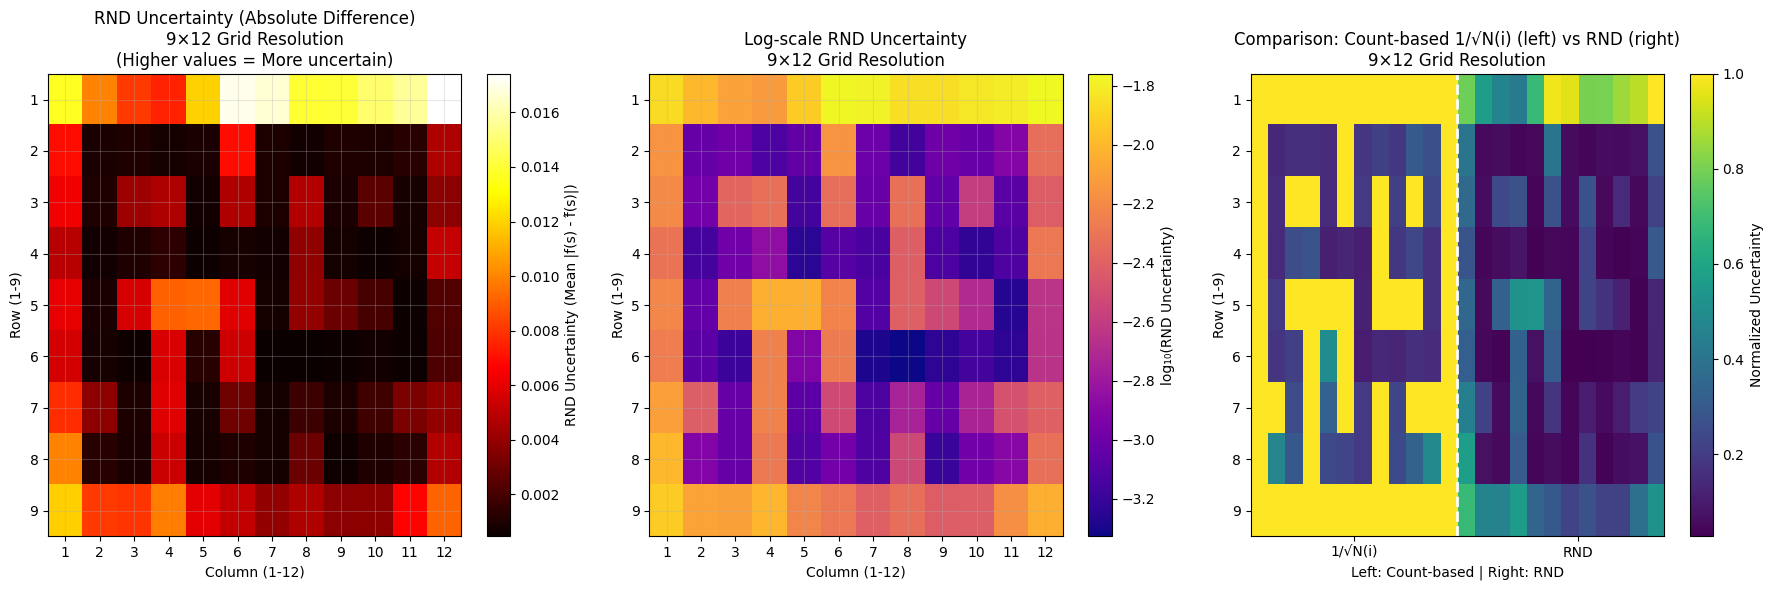

In [23]:
# CREATE RND UNCERTAINTY HEATMAP
print(f"\n" + "="*80)
print("RND UNCERTAINTY HEATMAP (9×12)")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # Changed to 1 row, 3 columns

# 1. Raw RND uncertainty heatmap
ax1 = axes[0]
im1 = ax1.imshow(rnd_uncertainty_9x12, cmap='hot', aspect='auto')
ax1.set_title('RND Uncertainty (Absolute Difference)\n9×12 Grid Resolution\n(Higher values = More uncertain)')
ax1.set_xlabel('Column (1-12)')
ax1.set_ylabel('Row (1-9)')

# Add grid lines and labels
ax1.set_xticks(range(12))
ax1.set_yticks(range(9))
ax1.set_xticklabels(range(1, 13))
ax1.set_yticklabels(range(1, 10))
ax1.grid(True, alpha=0.3)

# Add colorbar
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('RND Uncertainty (Mean |f(s) - f̂(s)|)')

# 2. Log-scale RND uncertainty
ax2 = axes[1]
log_rnd_uncertainty = np.log10(rnd_uncertainty_9x12 + 1e-10)
im2 = ax2.imshow(log_rnd_uncertainty, cmap='plasma', aspect='auto')
ax2.set_title('Log-scale RND Uncertainty\n9×12 Grid Resolution')
ax2.set_xlabel('Column (1-12)')
ax2.set_ylabel('Row (1-9)')

ax2.set_xticks(range(12))
ax2.set_yticks(range(9))
ax2.set_xticklabels(range(1, 13))
ax2.set_yticklabels(range(1, 10))
ax2.grid(True, alpha=0.3)

cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('log₁₀(RND Uncertainty)')

# 3. Comparison: Count-based vs RND uncertainty
ax3 = axes[2]
# Create side-by-side comparison
comparison_map = np.zeros((9, 24))  # Double width

# Left half: normalized count-based uncertainty (1/√N)
norm_count_uncertainty = uncertainty_9x12 / np.max(uncertainty_9x12[np.isfinite(uncertainty_9x12)])
comparison_map[:, :12] = norm_count_uncertainty

# Right half: normalized RND uncertainty
norm_rnd_uncertainty = rnd_uncertainty_9x12 / np.max(rnd_uncertainty_9x12)
comparison_map[:, 12:] = norm_rnd_uncertainty

im3 = ax3.imshow(comparison_map, cmap='viridis', aspect='auto')
ax3.set_title('Comparison: Count-based 1/√N(i) (left) vs RND (right)\n9×12 Grid Resolution')
ax3.set_xlabel('Left: Count-based | Right: RND')
ax3.set_ylabel('Row (1-9)')

# Custom tick labels
ax3.set_xticks([5.5, 18.5])
ax3.set_xticklabels(['1/√N(i)', 'RND'])
ax3.set_yticks(range(9))
ax3.set_yticklabels(range(1, 10))
ax3.axvline(x=11.5, color='white', linewidth=2, linestyle='--')

cbar3 = plt.colorbar(im3, ax=ax3)
cbar3.set_label('Normalized Uncertainty')

plt.tight_layout()
plt.show()

### RND Heatmap vs Groundtruth Without Walls


RND UNCERTAINTY HEATMAP (9×12) - EXCLUDING WALLS


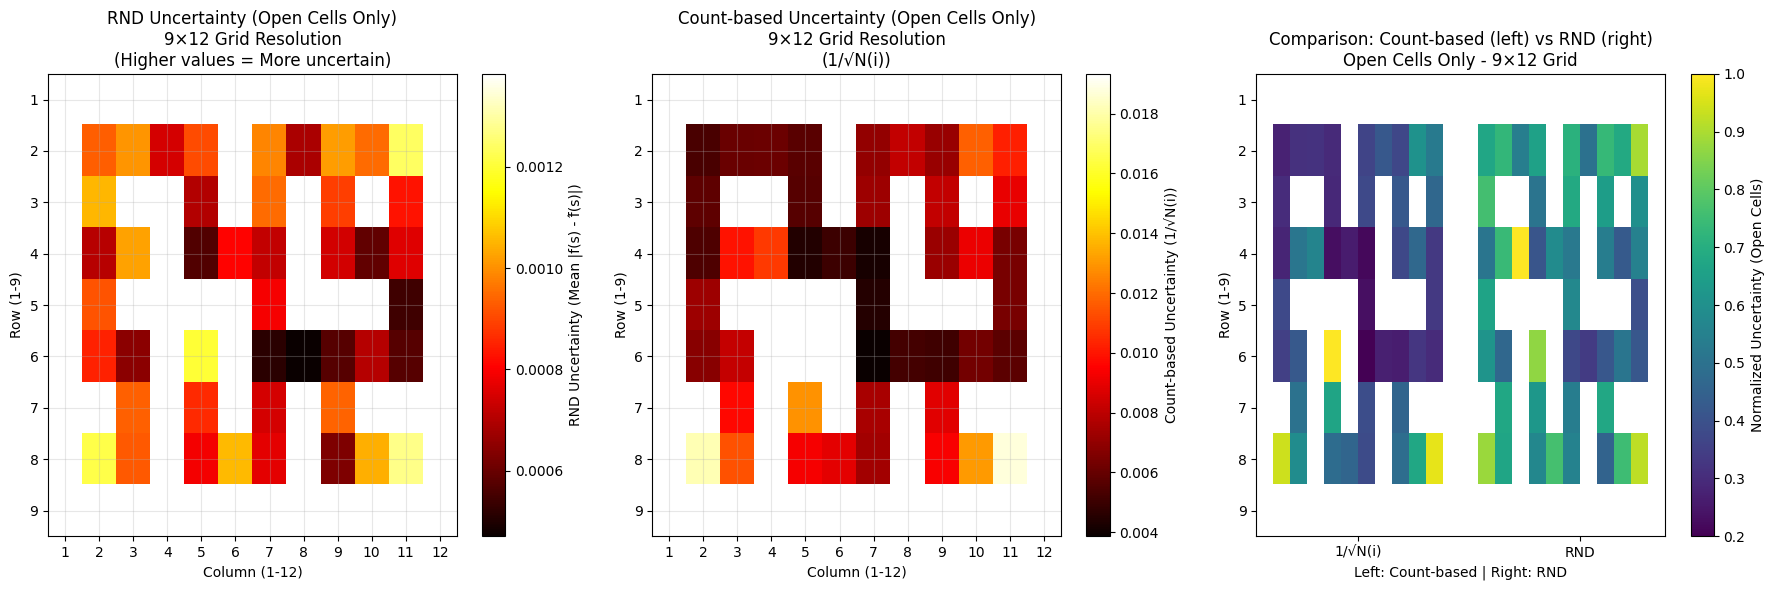


Uncertainty Statistics (Open Cells Only):
RND Uncertainty:
  Min: 0.000471
  Max: 0.001383
  Mean: 0.000852
  Std: 0.000211

Count-based Uncertainty (1/√N):
  Min: 0.003863
  Max: 0.019331
  Mean: 0.008267
  Std: 0.003559


In [24]:
# CREATE RND UNCERTAINTY HEATMAP (EXCLUDING WALLS)
print(f"\n" + "="*80)
print("RND UNCERTAINTY HEATMAP (9×12) - EXCLUDING WALLS")
print("="*80)

# Create masked versions that exclude walls
rnd_uncertainty_open_only = rnd_uncertainty_9x12.copy()
count_uncertainty_open_only = uncertainty_9x12.copy()

# Set wall cells to NaN for proper masking
for row in range(9):
    for col in range(12):
        if maze_map[row][col] == 1:  # Wall
            rnd_uncertainty_open_only[row, col] = np.nan
            count_uncertainty_open_only[row, col] = np.nan

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. RND uncertainty (open cells only)
ax1 = axes[0]
im1 = ax1.imshow(rnd_uncertainty_open_only, cmap='hot', aspect='auto')
ax1.set_title('RND Uncertainty (Open Cells Only)\n9×12 Grid Resolution\n(Higher values = More uncertain)')
ax1.set_xlabel('Column (1-12)')
ax1.set_ylabel('Row (1-9)')

ax1.set_xticks(range(12))
ax1.set_yticks(range(9))
ax1.set_xticklabels(range(1, 13))
ax1.set_yticklabels(range(1, 10))
ax1.grid(True, alpha=0.3)

cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('RND Uncertainty (Mean |f(s) - f̂(s)|)')

# 2. Count-based uncertainty (open cells only)
ax2 = axes[1]
im2 = ax2.imshow(count_uncertainty_open_only, cmap='hot', aspect='auto')
ax2.set_title('Count-based Uncertainty (Open Cells Only)\n9×12 Grid Resolution\n(1/√N(i))')
ax2.set_xlabel('Column (1-12)')
ax2.set_ylabel('Row (1-9)')

ax2.set_xticks(range(12))
ax2.set_yticks(range(9))
ax2.set_xticklabels(range(1, 13))
ax2.set_yticklabels(range(1, 10))
ax2.grid(True, alpha=0.3)

cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('Count-based Uncertainty (1/√N(i))')

# 3. Side-by-side comparison (open cells only)
ax3 = axes[2]
comparison_map_open = np.zeros((9, 24))
comparison_map_open[:] = np.nan  # Initialize with NaN

# Only fill open cells
for row in range(9):
    for col in range(12):
        if maze_map[row][col] == 0:  # Open cell
            # Left half: normalized count-based uncertainty
            if np.isfinite(count_uncertainty_open_only[row, col]):
                norm_count = count_uncertainty_open_only[row, col] / np.nanmax(count_uncertainty_open_only)
                comparison_map_open[row, col] = norm_count
            
            # Right half: normalized RND uncertainty
            norm_rnd = rnd_uncertainty_open_only[row, col] / np.nanmax(rnd_uncertainty_open_only)
            comparison_map_open[row, col + 12] = norm_rnd

im3 = ax3.imshow(comparison_map_open, cmap='viridis', aspect='auto')
ax3.set_title('Comparison: Count-based (left) vs RND (right)\nOpen Cells Only - 9×12 Grid')
ax3.set_xlabel('Left: Count-based | Right: RND')
ax3.set_ylabel('Row (1-9)')

ax3.set_xticks([5.5, 18.5])
ax3.set_xticklabels(['1/√N(i)', 'RND'])
ax3.set_yticks(range(9))
ax3.set_yticklabels(range(1, 10))
ax3.axvline(x=11.5, color='white', linewidth=2, linestyle='--')

cbar3 = plt.colorbar(im3, ax=ax3)
cbar3.set_label('Normalized Uncertainty (Open Cells)')

plt.tight_layout()
plt.show()

# Print statistics for open cells only
open_mask = ~np.isnan(rnd_uncertainty_open_only)
print(f"\nUncertainty Statistics (Open Cells Only):")
print(f"RND Uncertainty:")
print(f"  Min: {np.nanmin(rnd_uncertainty_open_only):.6f}")
print(f"  Max: {np.nanmax(rnd_uncertainty_open_only):.6f}")
print(f"  Mean: {np.nanmean(rnd_uncertainty_open_only):.6f}")
print(f"  Std: {np.nanstd(rnd_uncertainty_open_only):.6f}")

print(f"\nCount-based Uncertainty (1/√N):")
print(f"  Min: {np.nanmin(count_uncertainty_open_only):.6f}")
print(f"  Max: {np.nanmax(count_uncertainty_open_only):.6f}")
print(f"  Mean: {np.nanmean(count_uncertainty_open_only):.6f}")
print(f"  Std: {np.nanstd(count_uncertainty_open_only):.6f}")

### RND 2-64-64-64 with three different Gaussian noise levels (0.05,0.1,0.2)

Save the RND with Gaussian Noise Result

In [25]:
# OPTIONALLY SAVE GAUSSIAN NOISE RESULTS
if 'rnd_models_with_noise' in globals():
    noise_data = {
        'noise_levels': noise_levels,
        'training_losses_with_noise': training_losses_with_noise,
        # Note: Not saving the actual models as they're large
    }
    
    with open('/p/rlprojects/RND/saved_data/gaussian_noise_results.pkl', 'wb') as f:
        pickle.dump(noise_data, f)
    
    print("✓ Gaussian noise training results saved!")
else:
    print("No Gaussian noise results to save")

No Gaussian noise results to save


In [26]:
class CorrectedRNDWithNoise:
    """CORRECTED: Noise added to OUTPUT f(s), not input s"""
    
    def __init__(self, noise_std=0.1, device='cpu'):
        self.device = device
        self.noise_std = noise_std
        
        # Target and predictor networks (same as before)
        self.target_network = RNDNetworkWithNoise().to(device)
        self.predictor_network = RNDNetworkWithNoise().to(device)
        
        # Freeze target network
        for param in self.target_network.parameters():
            param.requires_grad = False
        
        self.optimizer = optim.Adam(self.predictor_network.parameters(), lr=1e-3)
        self.obs_mean = None
        self.obs_std = None
        
        print("CORRECTED RND with Output Noise:")
        print("  Target: f(s) + ε where ε ~ N(0,σ²)")
        print("  Predictor: f̂(s) learns to predict f(s) + ε")
        print(f"  Noise std: {noise_std} (added to OUTPUT)")
    
    def add_noise_to_output(self, features):
        """Add Gaussian noise to network OUTPUT, not input"""
        noise = torch.randn_like(features) * self.noise_std
        return features + noise
    
    def normalize_observations(self, observations):
        """Normalize input observations (no change here)"""
        if self.obs_mean is None:
            self.obs_mean = torch.mean(observations, dim=0, keepdim=True)
            self.obs_std = torch.std(observations, dim=0, keepdim=True) + 1e-8
        return (observations - self.obs_mean) / self.obs_std
    
    def compute_uncertainty_abs_diff(self, observations):
        """
        CORRECTED: Uncertainty = |f(s) - f̂(s)| where f(s) is clean target
        """
        self.target_network.eval()
        self.predictor_network.eval()
        
        with torch.no_grad():
            # Use CLEAN observations for both networks
            norm_obs = self.normalize_observations(observations)
            
            # Target: clean features f(s) (no noise during evaluation)
            target_features = self.target_network(norm_obs)
            
            # Predictor: clean features f̂(s) (no noise during evaluation)
            pred_features = self.predictor_network(norm_obs)
            
            # Uncertainty = |f(s) - f̂(s)|
            abs_diff = torch.abs(target_features - pred_features)
            uncertainty = torch.mean(abs_diff, dim=1)
            
        return uncertainty
    
    def train_on_dataset(self, num_epochs=50):
        """
        CORRECTED TRAINING: Add noise to target OUTPUT during training
        Training: f̂(s) learns to predict f(s) + ε
        """
        print("Loading dataset...")
        
        positions = []
        for episode in tqdm(dataset.iterate_episodes(), desc="Loading data"):
            observations = episode.observations
            if isinstance(observations, dict) and 'achieved_goal' in observations:
                positions.extend(observations['achieved_goal'])
        
        positions = torch.tensor(positions, dtype=torch.float32).to(self.device)
        print(f"Training: f̂(s) → f(s) + ε where ε ~ N(0,{self.noise_std}²)")
        
        # Normalization
        _ = self.normalize_observations(positions[:1000])
        
        # Training loop
        self.predictor_network.train()
        losses = []
        
        for epoch in tqdm(range(num_epochs), desc="Training with Output Noise"):
            indices = torch.randperm(len(positions))
            epoch_loss = 0
            batch_size = 512
            
            for i in range(0, len(positions), batch_size):
                batch_idx = indices[i:i+batch_size]
                batch_obs = self.normalize_observations(positions[batch_idx])
                
                # CORRECTED: Add noise to TARGET OUTPUT, not input
                clean_target_features = self.target_network(batch_obs).detach()
                noisy_target_features = self.add_noise_to_output(clean_target_features)
                
                # Predictor learns to match noisy target
                pred_features = self.predictor_network(batch_obs)
                loss = nn.functional.mse_loss(pred_features, noisy_target_features)
                
                # Backprop
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                
                epoch_loss += loss.item()
            
            avg_loss = epoch_loss / (len(positions) // batch_size + 1)
            losses.append(avg_loss)
            
            if epoch % 10 == 0:
                print(f"Epoch {epoch}: Loss = {avg_loss:.6f}")
        
        print("CORRECTED training complete!")
        print("Key: Predictor learned to match f(s) + ε, but evaluation uses clean f(s)")
        return losses

# RETRAIN WITH CORRECTED APPROACH
print("=" * 80)
print("RETRAINING WITH CORRECTED NOISE (OUTPUT NOISE f(s) + ε)")
print("=" * 80)

corrected_models = {}
corrected_losses = {}

for noise_std in noise_levels:
    print(f"\n" + "="*60)
    print(f"CORRECTED TRAINING: OUTPUT NOISE σ={noise_std}")
    print("="*60)
    
    model = CorrectedRNDWithNoise(noise_std=noise_std, device=device)
    losses = model.train_on_dataset(num_epochs=30)
    
    corrected_models[noise_std] = model
    corrected_losses[noise_std] = losses

print(f"\n✓ Corrected models trained!")
print(f"✓ Key difference: f(s) + ε instead of f(s+ε)")

RETRAINING WITH CORRECTED NOISE (OUTPUT NOISE f(s) + ε)


NameError: name 'noise_levels' is not defined

Plot the Heatmap for RND linear with corrected noise approach

COMPUTING UNCERTAINTIES FOR CORRECTED NOISE MODELS
Computing uncertainty for corrected noise std=0.05...


Corrected σ=0.05: 100%|██████████| 9/9 [00:00<00:00, 253.60it/s]


Computing uncertainty for corrected noise std=0.1...


Corrected σ=0.1:   0%|          | 0/9 [00:00<?, ?it/s]

Corrected σ=0.1: 100%|██████████| 9/9 [00:00<00:00, 262.81it/s]



Computing uncertainty for corrected noise std=0.2...


Corrected σ=0.2: 100%|██████████| 9/9 [00:00<00:00, 252.68it/s]


CORRECTED NOISE MODEL STATISTICS

Corrected Model σ=0.05:
  Min uncertainty: 0.001361
  Max uncertainty: 0.004364
  Mean uncertainty: 0.002479
  Std uncertainty: 0.000569

Corrected Model σ=0.1:
  Min uncertainty: 0.001824
  Max uncertainty: 0.006364
  Mean uncertainty: 0.003329
  Std uncertainty: 0.000968

Corrected Model σ=0.2:
  Min uncertainty: 0.002773
  Max uncertainty: 0.008340
  Mean uncertainty: 0.004469
  Std uncertainty: 0.001092

Ground Truth (Count-based 1/√N) for comparison:
  Min uncertainty: 0.003863
  Max uncertainty: 0.019331
  Mean uncertainty: 0.008267
  Std uncertainty: 0.003559


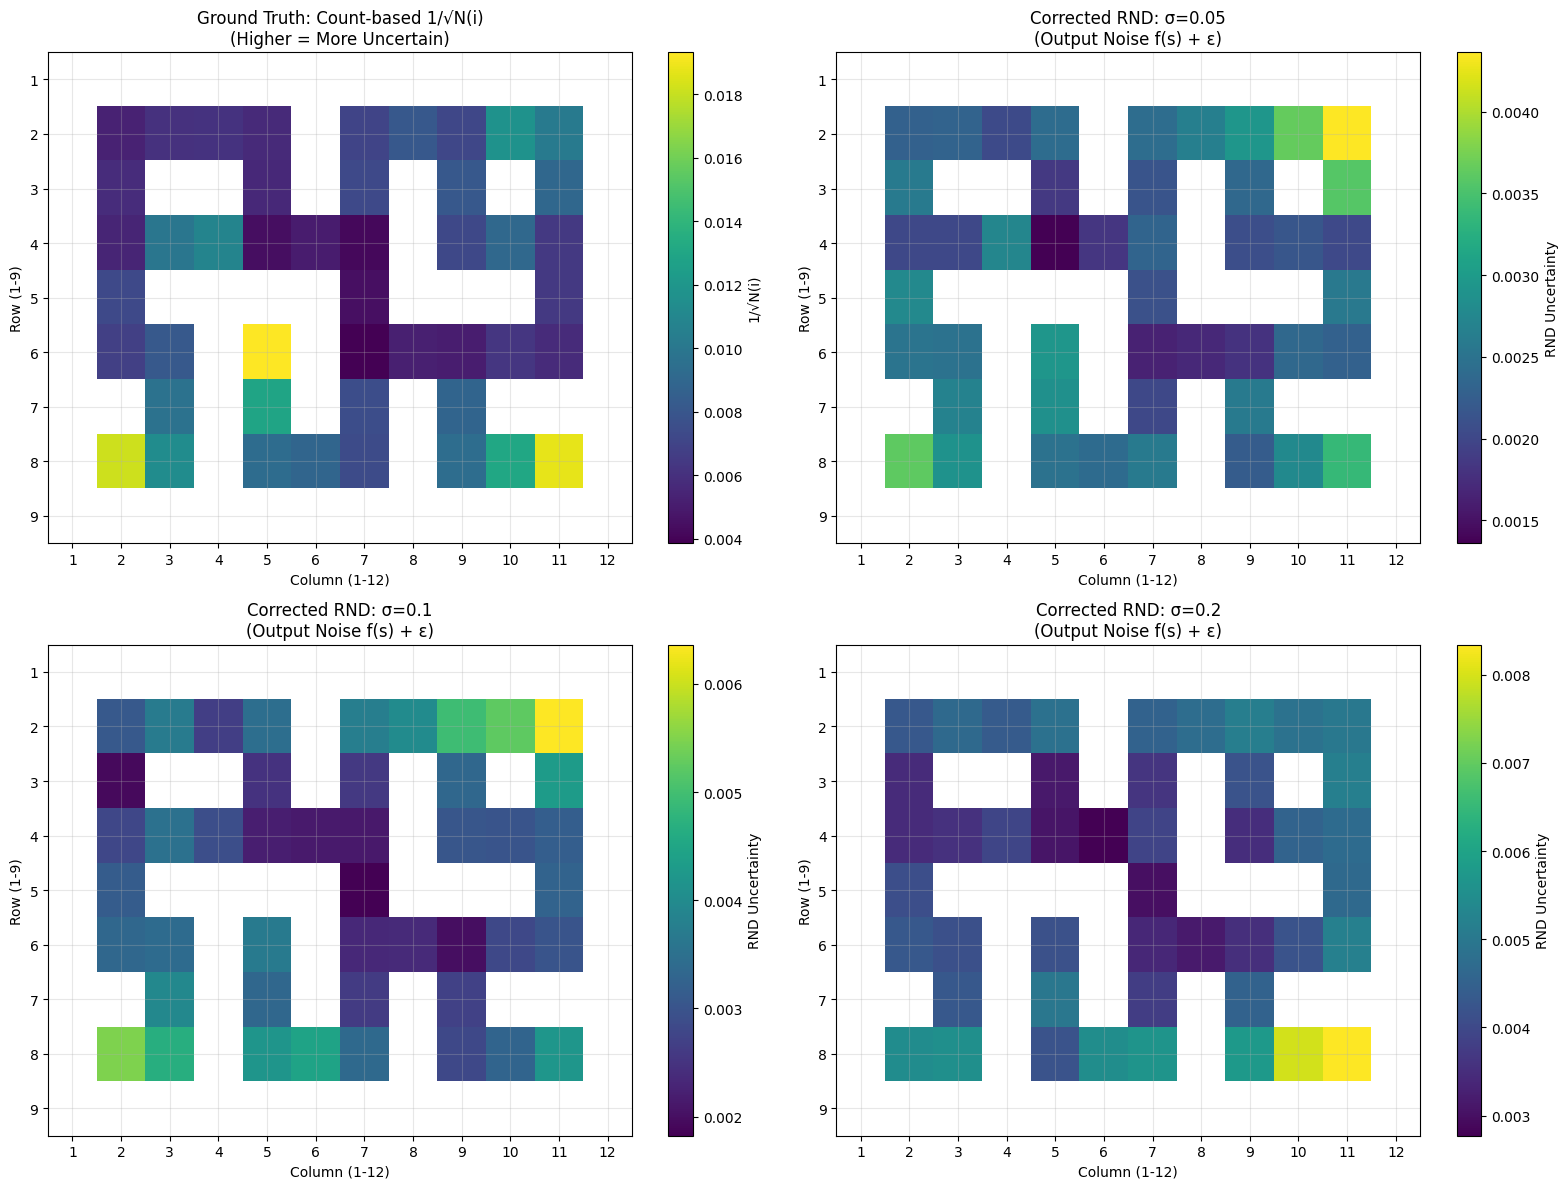

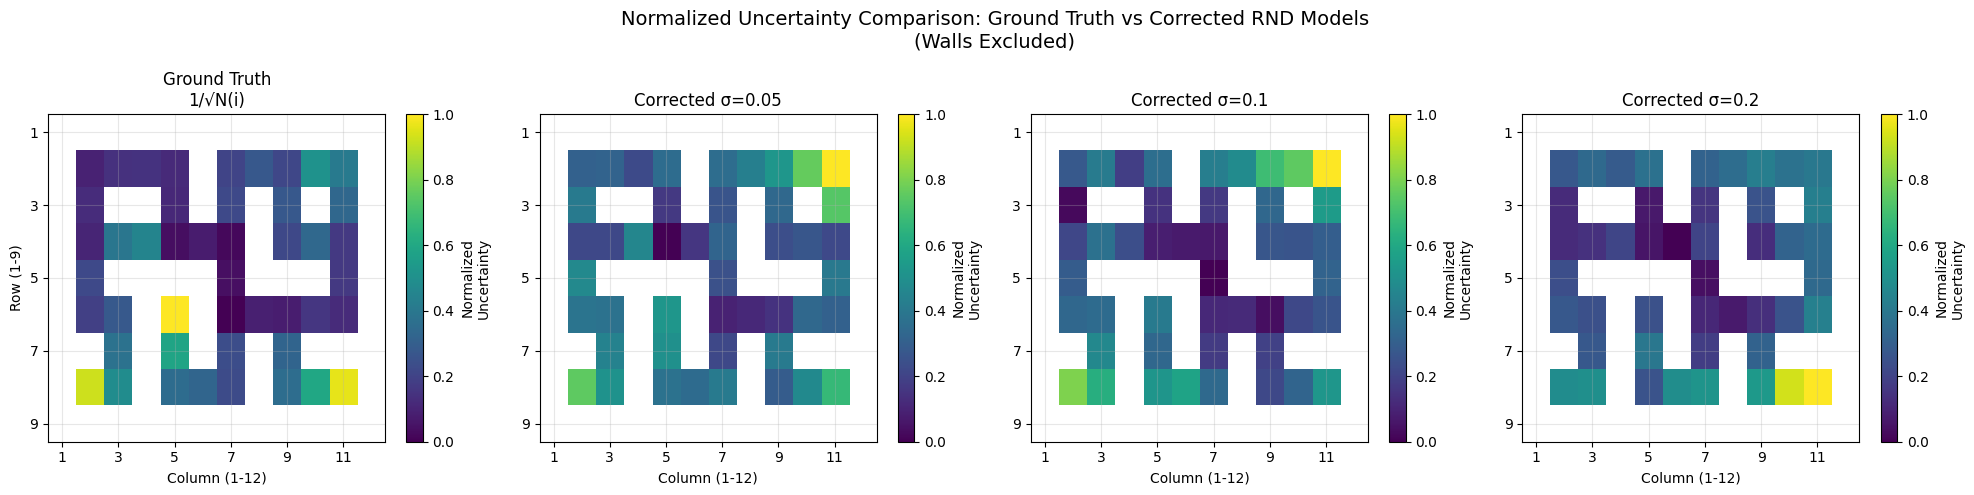


VISUAL COMPARISON COMPLETE
Key Observations:
• Ground Truth: Based on actual visit frequencies from dataset
• Corrected RND: Trained with noise added to network outputs f(s) + ε
• Higher σ values should show different uncertainty patterns
• All plots exclude walls (shown as white/transparent areas)


In [ ]:
# COMPUTE UNCERTAINTIES FOR CORRECTED NOISE MODELS
print("=" * 80)
print("COMPUTING UNCERTAINTIES FOR CORRECTED NOISE MODELS")
print("=" * 80)

# Compute uncertainties for each corrected noise model
corrected_uncertainties = {}

for noise_std in noise_levels:
    print(f"Computing uncertainty for corrected noise std={noise_std}...")
    
    uncertainty_matrix = np.zeros((9, 12), dtype=float)
    
    for row in tqdm(range(1, 10), desc=f"Corrected σ={noise_std}"):
        for col in range(1, 13):
            # Get center coordinates
            center_x, center_y = grid_to_center_observation(row, col)
            obs_tensor = torch.tensor([[center_x, center_y]], dtype=torch.float32).to(device)
            
            # Compute uncertainty using corrected model
            uncertainty = corrected_models[noise_std].compute_uncertainty_abs_diff(obs_tensor).item()
            uncertainty_matrix[row-1, col-1] = uncertainty
    
    corrected_uncertainties[noise_std] = uncertainty_matrix

# PRINT STATISTICS FOR CORRECTED MODELS
print("\n" + "="*80)
print("CORRECTED NOISE MODEL STATISTICS")
print("="*80)

for noise_std in noise_levels:
    uncertainty_matrix = corrected_uncertainties[noise_std]
    
    # Mask out walls for statistics
    open_cells_mask = np.array([[maze_map[i][j] == 0 for j in range(12)] for i in range(9)])
    open_uncertainties = uncertainty_matrix[open_cells_mask]
    
    print(f"\nCorrected Model σ={noise_std}:")
    print(f"  Min uncertainty: {np.min(open_uncertainties):.6f}")
    print(f"  Max uncertainty: {np.max(open_uncertainties):.6f}")
    print(f"  Mean uncertainty: {np.mean(open_uncertainties):.6f}")
    print(f"  Std uncertainty: {np.std(open_uncertainties):.6f}")

# COMPARISON WITH GROUND TRUTH (COUNT-BASED 1/√N)
print(f"\nGround Truth (Count-based 1/√N) for comparison:")
open_cells_mask = np.array([[maze_map[i][j] == 0 for j in range(12)] for i in range(9)])
finite_mask = np.isfinite(uncertainty_9x12) & open_cells_mask
if np.any(finite_mask):
    ground_truth_open = uncertainty_9x12[finite_mask]
    print(f"  Min uncertainty: {np.min(ground_truth_open):.6f}")
    print(f"  Max uncertainty: {np.max(ground_truth_open):.6f}")
    print(f"  Mean uncertainty: {np.mean(ground_truth_open):.6f}")
    print(f"  Std uncertainty: {np.std(ground_truth_open):.6f}")

# CREATE COMPREHENSIVE PLOT: CORRECTED MODELS vs GROUND TRUTH
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Function to mask walls for plotting
def mask_walls(uncertainty_matrix):
    masked = uncertainty_matrix.copy()
    for r in range(9):
        for c in range(12):
            if maze_map[r][c] == 1:  # Wall
                masked[r, c] = np.nan
    return masked

# Plot 1: Ground Truth (Count-based 1/√N)
ax1 = axes[0, 0]
ground_truth_masked = mask_walls(uncertainty_9x12)
# Handle infinite values for visualization
ground_truth_plot = ground_truth_masked.copy()
finite_mask = np.isfinite(ground_truth_plot)
if np.any(finite_mask):
    max_finite = np.max(ground_truth_plot[finite_mask])
    ground_truth_plot[np.isinf(ground_truth_plot)] = max_finite * 2

im1 = ax1.imshow(ground_truth_plot, cmap='viridis', aspect='auto')
ax1.set_title('Ground Truth: Count-based 1/√N(i)\n(Higher = More Uncertain)')
ax1.set_xlabel('Column (1-12)')
ax1.set_ylabel('Row (1-9)')
ax1.set_xticks(range(12))
ax1.set_yticks(range(9))
ax1.set_xticklabels(range(1, 13))
ax1.set_yticklabels(range(1, 10))
ax1.grid(True, alpha=0.3)
plt.colorbar(im1, ax=ax1, label='1/√N(i)')

# Plot 2: Corrected σ=0.05
ax2 = axes[0, 1]
corrected_005_masked = mask_walls(corrected_uncertainties[0.05])
im2 = ax2.imshow(corrected_005_masked, cmap='viridis', aspect='auto')
ax2.set_title('Corrected RND: σ=0.05\n(Output Noise f(s) + ε)')
ax2.set_xlabel('Column (1-12)')
ax2.set_ylabel('Row (1-9)')
ax2.set_xticks(range(12))
ax2.set_yticks(range(9))
ax2.set_xticklabels(range(1, 13))
ax2.set_yticklabels(range(1, 10))
ax2.grid(True, alpha=0.3)
plt.colorbar(im2, ax=ax2, label='RND Uncertainty')

# Plot 3: Corrected σ=0.1
ax3 = axes[1, 0]
corrected_01_masked = mask_walls(corrected_uncertainties[0.1])
im3 = ax3.imshow(corrected_01_masked, cmap='viridis', aspect='auto')
ax3.set_title('Corrected RND: σ=0.1\n(Output Noise f(s) + ε)')
ax3.set_xlabel('Column (1-12)')
ax3.set_ylabel('Row (1-9)')
ax3.set_xticks(range(12))
ax3.set_yticks(range(9))
ax3.set_xticklabels(range(1, 13))
ax3.set_yticklabels(range(1, 10))
ax3.grid(True, alpha=0.3)
plt.colorbar(im3, ax=ax3, label='RND Uncertainty')

# Plot 4: Corrected σ=0.2
ax4 = axes[1, 1]
corrected_02_masked = mask_walls(corrected_uncertainties[0.2])
im4 = ax4.imshow(corrected_02_masked, cmap='viridis', aspect='auto')
ax4.set_title('Corrected RND: σ=0.2\n(Output Noise f(s) + ε)')
ax4.set_xlabel('Column (1-12)')
ax4.set_ylabel('Row (1-9)')
ax4.set_xticks(range(12))
ax4.set_yticks(range(9))
ax4.set_xticklabels(range(1, 13))
ax4.set_yticklabels(range(1, 10))
ax4.grid(True, alpha=0.3)
plt.colorbar(im4, ax=ax4, label='RND Uncertainty')

plt.tight_layout()
plt.show()

# SIDE-BY-SIDE COMPARISON PLOT
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Normalize all uncertainties to [0,1] for fair comparison
def normalize_for_comparison(uncertainty_matrix):
    masked = mask_walls(uncertainty_matrix)
    finite_values = masked[np.isfinite(masked)]
    if len(finite_values) > 0:
        min_val, max_val = np.min(finite_values), np.max(finite_values)
        normalized = (masked - min_val) / (max_val - min_val)
        return normalized
    return masked

# Plot normalized versions for comparison
titles = ['Ground Truth\n1/√N(i)', 'Corrected σ=0.05', 'Corrected σ=0.1', 'Corrected σ=0.2']
data = [uncertainty_9x12, corrected_uncertainties[0.05], corrected_uncertainties[0.1], corrected_uncertainties[0.2]]

for i, (ax, title, uncertainty_data) in enumerate(zip(axes, titles, data)):
    normalized_data = normalize_for_comparison(uncertainty_data)
    im = ax.imshow(normalized_data, cmap='viridis', aspect='auto', vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel('Column (1-12)')
    if i == 0:
        ax.set_ylabel('Row (1-9)')
    ax.set_xticks(range(0, 12, 2))
    ax.set_yticks(range(0, 9, 2))
    ax.set_xticklabels(range(1, 13, 2))
    ax.set_yticklabels(range(1, 10, 2))
    ax.grid(True, alpha=0.3)
    plt.colorbar(im, ax=ax, label='Normalized\nUncertainty')

plt.suptitle('Normalized Uncertainty Comparison: Ground Truth vs Corrected RND Models\n(Walls Excluded)', fontsize=14)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("VISUAL COMPARISON COMPLETE")
print("="*80)
print("Key Observations:")
print("• Ground Truth: Based on actual visit frequencies from dataset")
print("• Corrected RND: Trained with noise added to network outputs f(s) + ε")
print("• Higher σ values should show different uncertainty patterns")
print("• All plots exclude walls (shown as white/transparent areas)")

### Frobenius Norm Comparison for RND with Gaussian Noise

In [ ]:
# RECALCULATE FROBENIUS NORM DISTANCES: GROUND TRUTH vs RND METHODS
print("=" * 80)
print("FROBENIUS NORM ANALYSIS: GROUND TRUTH vs RND METHODS (RECALCULATED)")
print("=" * 80)

# Ground truth matrix (count-based 1/√N)
M_gt = uncertainty_9x12.copy()

# Handle infinite values in ground truth for fair comparison
finite_mask = np.isfinite(M_gt)
if np.any(~finite_mask):
    # Replace inf with a large finite value (2x the maximum finite value)
    max_finite = np.max(M_gt[finite_mask])
    M_gt[~finite_mask] = max_finite * 2
    print(f"Replaced {np.sum(~finite_mask)} infinite values with {max_finite * 2:.2f}")

# Create mask for open cells only (exclude walls)
open_cells_mask = np.array([[maze_map[i][j] == 0 for j in range(12)] for i in range(9)])

# Collect all RND uncertainty matrices
rnd_methods = {}

# 1. Original RND (complete neural network)
if 'rnd_uncertainty_9x12' in globals():
    rnd_methods['Original RND'] = rnd_uncertainty_9x12
    print("✓ Found Original RND uncertainty matrix")

# 2. RND with Gaussian noise (corrected approach)
if 'corrected_uncertainties' in globals():
    for noise_std in [0.05, 0.1, 0.2]:
        if noise_std in corrected_uncertainties:
            rnd_methods[f'RND σ={noise_std}'] = corrected_uncertainties[noise_std]
            print(f"✓ Found RND with Gaussian noise σ={noise_std}")

# 3. RND-Linear models (for comparison)
if 'rnd_linear_uncertainties' in globals():
    for dim in [16, 32, 64, 128, 256]:
        if dim in rnd_linear_uncertainties:
            rnd_methods[f'RND-Linear dim={dim}'] = rnd_linear_uncertainties[dim]
            print(f"✓ Found RND-Linear dim={dim}")

print(f"\nFound {len(rnd_methods)} RND methods to compare with ground truth")

# Calculate Frobenius norm distances with detailed debugging
frobenius_distances = {}
print(f"\nFrobenius norm distances ||M_gt - M_rnd||_F (open cells only):")
print("-" * 80)

for method_name, M_rnd in rnd_methods.items():
    # Apply open cells mask to both matrices
    M_gt_masked = M_gt * open_cells_mask
    M_rnd_masked = M_rnd * open_cells_mask
    
    # Calculate Frobenius norm difference
    diff_matrix = M_gt_masked - M_rnd_masked
    frobenius_norm = np.linalg.norm(diff_matrix, ord='fro')
    
    frobenius_distances[method_name] = frobenius_norm
    
    # Show statistics for debugging
    gt_stats = f"GT: mean={np.mean(M_gt_masked[open_cells_mask]):.4f}"
    rnd_stats = f"RND: mean={np.mean(M_rnd_masked[open_cells_mask]):.4f}"
    print(f"{method_name:<25}: {frobenius_norm:.4f} | {gt_stats} | {rnd_stats}")

# Rank methods by performance (lower is better)
print(f"\n" + "="*80)
print("RANKING (lower Frobenius distance = better approximation):")
print("="*80)
sorted_methods = sorted(frobenius_distances.items(), key=lambda x: x[1])
for rank, (method, distance) in enumerate(sorted_methods, 1):
    print(f"{rank:2d}. {method:<30}: {distance:.4f}")

# Group analysis by method type
print(f"\n" + "="*80)
print("ANALYSIS BY METHOD TYPE")
print("="*80)

# Separate different types of RND methods
original_rnd = {k: v for k, v in frobenius_distances.items() if 'Original' in k}
noise_rnd = {k: v for k, v in frobenius_distances.items() if 'σ=' in k}
linear_rnd = {k: v for k, v in frobenius_distances.items() if 'Linear' in k}

print(f"Original RND (complete NN):")
for method, distance in original_rnd.items():
    print(f"  {method}: {distance:.4f}")

print(f"\nRND with Gaussian Noise:")
noise_sorted = sorted(noise_rnd.items(), key=lambda x: x[1])
for method, distance in noise_sorted:
    print(f"  {method}: {distance:.4f}")

print(f"\nRND-Linear (simplified):")
linear_sorted = sorted(linear_rnd.items(), key=lambda x: x[1])
for method, distance in linear_sorted:
    print(f"  {method}: {distance:.4f}")

# Find best methods in each category
if linear_rnd:
    best_linear = min(linear_rnd.items(), key=lambda x: x[1])
    print(f"\n🏆 Best RND-Linear: {best_linear[0]} (distance: {best_linear[1]:.4f})")

if noise_rnd:
    best_noise = min(noise_rnd.items(), key=lambda x: x[1])
    print(f"🏆 Best Gaussian noise: {best_noise[0]} (distance: {best_noise[1]:.4f})")

if original_rnd:
    best_original = min(original_rnd.items(), key=lambda x: x[1])
    print(f"🏆 Best Original RND: {best_original[0]} (distance: {best_original[1]:.4f})")

# Statistical summary
if len(frobenius_distances) > 1:
    distances = list(frobenius_distances.values())
    print(f"\nStatistical Summary:")
    print(f"  Best performance:  {min(distances):.4f}")
    print(f"  Worst performance: {max(distances):.4f}")
    print(f"  Mean distance:     {np.mean(distances):.4f}")
    print(f"  Std deviation:     {np.std(distances):.4f}")
    print(f"  Range:             {max(distances) - min(distances):.4f}")

# DETAILED ANALYSIS: Why certain methods perform better
print(f"\n" + "="*80)
print("DETAILED PERFORMANCE ANALYSIS")
print("="*80)

# Analyze the correlation between methods and ground truth
open_mask = open_cells_mask.flatten()
gt_open = M_gt.flatten()[open_mask]

print(f"Correlations with ground truth (open cells only):")
correlations = {}
for method_name, M_rnd in rnd_methods.items():
    rnd_open = M_rnd.flatten()[open_mask]
    if len(gt_open) == len(rnd_open) and len(gt_open) > 1:
        correlation = np.corrcoef(gt_open, rnd_open)[0, 1]
        correlations[method_name] = correlation
        print(f"  {method_name:<30}: r = {correlation:.4f}")

# Show the relationship between correlation and Frobenius distance
if correlations:
    print(f"\nCorrelation vs Frobenius Distance:")
    print("-" * 60)
    for method in sorted_methods[:5]:  # Top 5 methods
        method_name = method[0]
        if method_name in correlations:
            corr = correlations[method_name]
            dist = frobenius_distances[method_name]
            print(f"  {method_name:<30}: r={corr:6.3f}, ||·||_F={dist:.4f}")

FROBENIUS NORM ANALYSIS: GROUND TRUTH vs RND METHODS (RECALCULATED)
✓ Found Original RND uncertainty matrix
✓ Found RND with Gaussian noise σ=0.05
✓ Found RND with Gaussian noise σ=0.1
✓ Found RND with Gaussian noise σ=0.2
✓ Found RND-Linear dim=16
✓ Found RND-Linear dim=32
✓ Found RND-Linear dim=64
✓ Found RND-Linear dim=128
✓ Found RND-Linear dim=256

Found 9 RND methods to compare with ground truth

Frobenius norm distances ||M_gt - M_rnd||_F (open cells only):
--------------------------------------------------------------------------------
Original RND             : 0.0556 | GT: mean=0.0083 | RND: mean=0.0008
RND σ=0.05               : 0.0449 | GT: mean=0.0083 | RND: mean=0.0025
RND σ=0.1                : 0.0395 | GT: mean=0.0083 | RND: mean=0.0033
RND σ=0.2                : 0.0329 | GT: mean=0.0083 | RND: mean=0.0045
RND-Linear dim=16        : 0.0602 | GT: mean=0.0083 | RND: mean=0.0001
RND-Linear dim=32        : 0.0610 | GT: mean=0.0083 | RND: mean=0.0000
RND-Linear dim=64       

/tmp/ipykernel_2574551/1448873005.py:189: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/u/sl5nw/.conda/envs/exploration/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u/sl5nw/.conda/envs/exploration/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


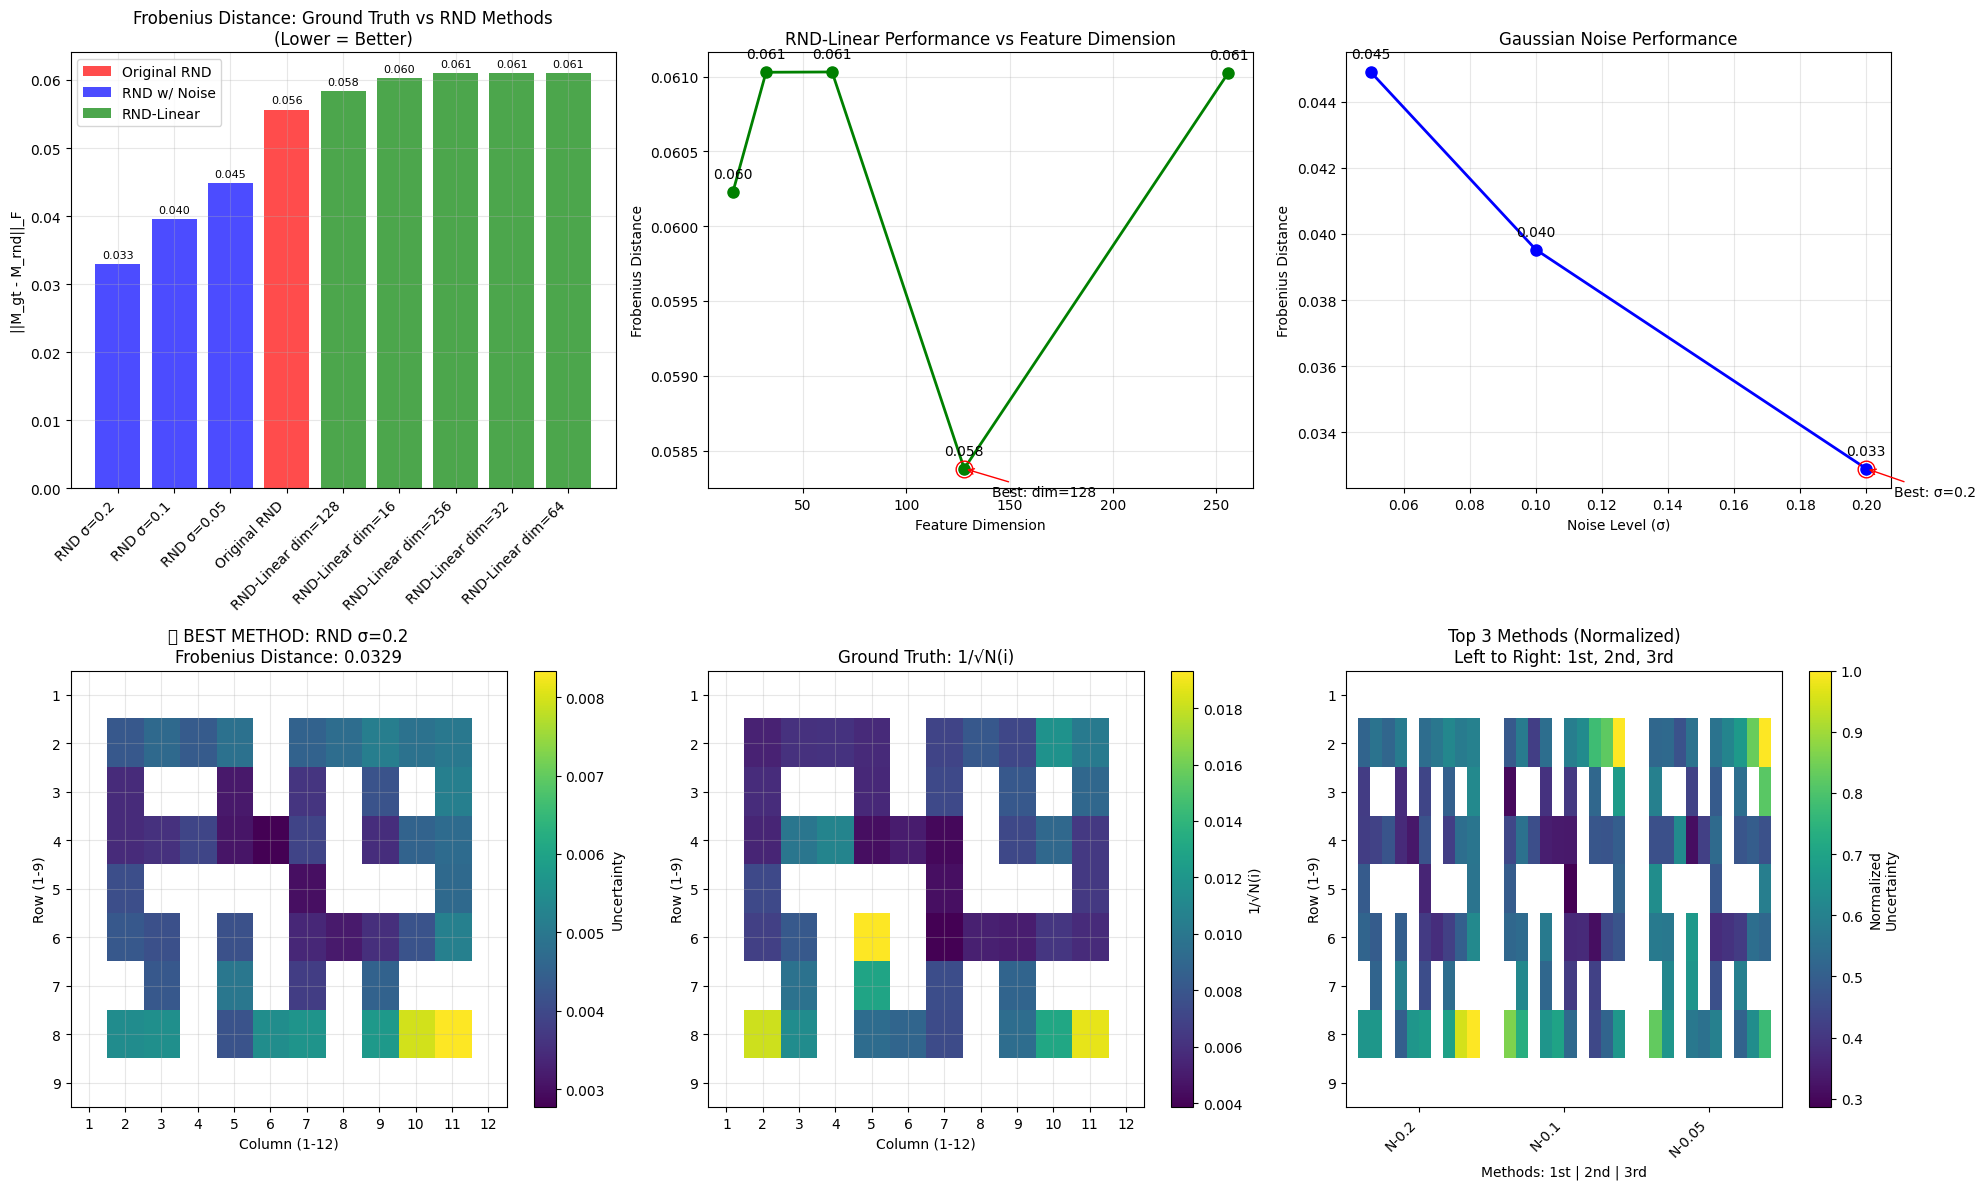


FROBENIUS NORM ANALYSIS COMPLETE
Key Findings:
🏆 Overall best method: RND σ=0.2 (distance: 0.0329)
🥈 Second best: RND σ=0.1 (distance: 0.0395)
🥉 Third best: RND σ=0.05 (distance: 0.0449)

Method Types Performance:
• Best RND-Linear: RND-Linear dim=128 (0.0584)
• Best Gaussian Noise: RND σ=0.2 (0.0329)
✓ Lower Frobenius distance = Better approximation of ground truth


In [ ]:
# IMPROVED VISUALIZATION: FROBENIUS NORM COMPARISON
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Plot 1: Bar chart of all methods (sorted by performance)
ax1 = axes[0, 0]
sorted_methods_plot = sorted(frobenius_distances.items(), key=lambda x: x[1])
methods_sorted = [item[0] for item in sorted_methods_plot]
distances_sorted = [item[1] for item in sorted_methods_plot]

# Color code by method type
colors = []
for method in methods_sorted:
    if 'Original' in method:
        colors.append('red')
    elif 'σ=' in method:
        colors.append('blue')
    elif 'Linear' in method:
        colors.append('green')
    else:
        colors.append('gray')

bars = ax1.bar(range(len(methods_sorted)), distances_sorted, color=colors, alpha=0.7)
ax1.set_title('Frobenius Distance: Ground Truth vs RND Methods\n(Lower = Better)')
ax1.set_ylabel('||M_gt - M_rnd||_F')
ax1.set_xticks(range(len(methods_sorted)))
ax1.set_xticklabels(methods_sorted, rotation=45, ha='right')
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for bar, distance in zip(bars, distances_sorted):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01*max(distances_sorted),
             f'{distance:.3f}', ha='center', va='bottom', fontsize=8)

# Create legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', alpha=0.7, label='Original RND'),
                   Patch(facecolor='blue', alpha=0.7, label='RND w/ Noise'),
                   Patch(facecolor='green', alpha=0.7, label='RND-Linear')]
ax1.legend(handles=legend_elements, loc='upper left')

# Plot 2: RND-Linear dimension trend
ax2 = axes[0, 1]
if linear_rnd:
    linear_dims = []
    linear_distances = []
    for method, distance in linear_rnd.items():
        dim = int(method.split('dim=')[1])
        linear_dims.append(dim)
        linear_distances.append(distance)
    
    # Sort by dimension
    sorted_linear = sorted(zip(linear_dims, linear_distances))
    dims, dists = zip(*sorted_linear)
    
    ax2.plot(dims, dists, 'o-', linewidth=2, markersize=8, color='green')
    ax2.set_title('RND-Linear Performance vs Feature Dimension')
    ax2.set_xlabel('Feature Dimension')
    ax2.set_ylabel('Frobenius Distance')
    ax2.grid(True, alpha=0.3)
    
    # Annotate points
    for dim, dist in zip(dims, dists):
        ax2.annotate(f'{dist:.3f}', (dim, dist), 
                    textcoords="offset points", xytext=(0,10), ha='center')
    
    # Highlight best performing dimension
    best_idx = np.argmin(dists)
    ax2.plot(dims[best_idx], dists[best_idx], 'ro', markersize=12, fillstyle='none', linewidth=3)
    ax2.annotate(f'Best: dim={dims[best_idx]}', 
                (dims[best_idx], dists[best_idx]), 
                textcoords="offset points", xytext=(20,-20), ha='left',
                arrowprops=dict(arrowstyle='->', color='red'))

# Plot 3: Gaussian noise trend
ax3 = axes[0, 2]
if noise_rnd:
    noise_levels_plot = []
    noise_distances_plot = []
    for method, distance in noise_rnd.items():
        if 'σ=' in method:
            noise_level = float(method.split('σ=')[1])
            noise_levels_plot.append(noise_level)
            noise_distances_plot.append(distance)
    
    if noise_levels_plot:
        sorted_noise_plot = sorted(zip(noise_levels_plot, noise_distances_plot))
        levels, dists = zip(*sorted_noise_plot)
        
        ax3.plot(levels, dists, 'o-', linewidth=2, markersize=8, color='blue')
        ax3.set_title('Gaussian Noise Performance')
        ax3.set_xlabel('Noise Level (σ)')
        ax3.set_ylabel('Frobenius Distance')
        ax3.grid(True, alpha=0.3)
        
        # Annotate points
        for level, dist in zip(levels, dists):
            ax3.annotate(f'{dist:.3f}', (level, dist), 
                        textcoords="offset points", xytext=(0,10), ha='center')
        
        # Highlight best performing noise level
        best_idx = np.argmin(dists)
        ax3.plot(levels[best_idx], dists[best_idx], 'ro', markersize=12, fillstyle='none', linewidth=3)
        ax3.annotate(f'Best: σ={levels[best_idx]}', 
                    (levels[best_idx], dists[best_idx]), 
                    textcoords="offset points", xytext=(20,-20), ha='left',
                    arrowprops=dict(arrowstyle='->', color='red'))

# Plot 4: Best method vs Ground Truth
ax4 = axes[1, 0]
if len(sorted_methods) >= 1:
    best_method, best_distance = sorted_methods[0]
    best_matrix = rnd_methods[best_method]
    
    # Mask walls
    best_masked = best_matrix.copy()
    for r in range(9):
        for c in range(12):
            if maze_map[r][c] == 1:
                best_masked[r, c] = np.nan
    
    im4 = ax4.imshow(best_masked, cmap='viridis', aspect='auto')
    ax4.set_title(f'🏆 BEST METHOD: {best_method}\nFrobenius Distance: {best_distance:.4f}')
    ax4.set_xlabel('Column (1-12)')
    ax4.set_ylabel('Row (1-9)')
    ax4.set_xticks(range(12))
    ax4.set_yticks(range(9))
    ax4.set_xticklabels(range(1, 13))
    ax4.set_yticklabels(range(1, 10))
    ax4.grid(True, alpha=0.3)
    plt.colorbar(im4, ax=ax4, label='Uncertainty')

# Plot 5: Ground truth reference
ax5 = axes[1, 1]
gt_masked = M_gt.copy()
for r in range(9):
    for c in range(12):
        if maze_map[r][c] == 1:
            gt_masked[r, c] = np.nan

im5 = ax5.imshow(gt_masked, cmap='viridis', aspect='auto')
ax5.set_title('Ground Truth: 1/√N(i)')
ax5.set_xlabel('Column (1-12)')
ax5.set_ylabel('Row (1-9)')
ax5.set_xticks(range(12))
ax5.set_yticks(range(9))
ax5.set_xticklabels(range(1, 13))
ax5.set_yticklabels(range(1, 10))
ax5.grid(True, alpha=0.3)
plt.colorbar(im5, ax=ax5, label='1/√N(i)')

# Plot 6: Top 3 methods comparison
ax6 = axes[1, 2]
if len(sorted_methods) >= 3:
    # Create side-by-side comparison of top 3 methods
    top3_comparison = np.zeros((9, 36))  # Triple width
    top3_comparison[:] = np.nan
    
    for i, (method_name, _) in enumerate(sorted_methods[:3]):
        method_matrix = rnd_methods[method_name]
        
        # Normalize and place in comparison matrix
        method_masked = method_matrix.copy()
        for r in range(9):
            for c in range(12):
                if maze_map[r][c] == 0:  # Only open cells
                    norm_val = method_masked[r, c] / np.nanmax(method_masked[open_cells_mask])
                    top3_comparison[r, c + i*12] = norm_val
    
    im6 = ax6.imshow(top3_comparison, cmap='viridis', aspect='auto')
    ax6.set_title('Top 3 Methods (Normalized)\nLeft to Right: 1st, 2nd, 3rd')
    ax6.set_xlabel('Methods: 1st | 2nd | 3rd')
    ax6.set_ylabel('Row (1-9)')
    
    # Add vertical separators
    ax6.axvline(x=11.5, color='white', linewidth=2, linestyle='--')
    ax6.axvline(x=23.5, color='white', linewidth=2, linestyle='--')
    
    # Custom tick labels
    ax6.set_xticks([5.5, 17.5, 29.5])
    top3_names = [sorted_methods[i][0] for i in range(min(3, len(sorted_methods)))]
    ax6.set_xticklabels([name.replace('RND-Linear ', 'L-').replace('RND σ=', 'N-') 
                         for name in top3_names], rotation=45, ha='right')
    ax6.set_yticks(range(9))
    ax6.set_yticklabels(range(1, 10))
    
    plt.colorbar(im6, ax=ax6, label='Normalized\nUncertainty')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("FROBENIUS NORM ANALYSIS COMPLETE")
print("="*80)
print("Key Findings:")
print(f"🏆 Overall best method: {sorted_methods[0][0]} (distance: {sorted_methods[0][1]:.4f})")
if len(sorted_methods) > 1:
    print(f"🥈 Second best: {sorted_methods[1][0]} (distance: {sorted_methods[1][1]:.4f})")
if len(sorted_methods) > 2:
    print(f"🥉 Third best: {sorted_methods[2][0]} (distance: {sorted_methods[2][1]:.4f})")
print("\nMethod Types Performance:")
if linear_rnd:
    best_linear_method = min(linear_rnd.items(), key=lambda x: x[1])
    print(f"• Best RND-Linear: {best_linear_method[0]} ({best_linear_method[1]:.4f})")
if noise_rnd:
    best_noise_method = min(noise_rnd.items(), key=lambda x: x[1])
    print(f"• Best Gaussian Noise: {best_noise_method[0]} ({best_noise_method[1]:.4f})")
print("✓ Lower Frobenius distance = Better approximation of ground truth")

### RND-Linear feature dim 16,32,64,128,256

RND-LINEAR IMPLEMENTATION

TESTING DIFFERENT FEATURE DIMENSIONS
Using device: cpu

--------------------------------------------------
FEATURE DIMENSION: 16
--------------------------------------------------
RND-Linear Networks initialized:
  φ(s): 2 → 16 (FROZEN, shared)
  Target θ: 16-dim vector (FROZEN, random)
  Predictor θ̂: 16-dim vector (TRAINABLE)
  Total trainable params: 16
Loading and processing dataset...


Loading data: 3360it [00:09, 341.32it/s]
Loading data: 3360it [00:09, 341.32it/s]


Training on 1003360 observations
Feature dimension: 16


RND-Linear Training:   3%|▎         | 1/30 [00:01<00:50,  1.73s/it]

Epoch 0: Loss = 1.977994


...

Epoch 10: Loss = 0.000019


RND-Linear Training:  70%|███████   | 21/30 [01:01<00:26,  2.89s/it]

Epoch 20: Loss = 0.000019


RND-Linear Training: 100%|██████████| 30/30 [01:27<00:00,  2.93s/it]



RND-Linear training complete!
Final loss for dim 256: 0.000021


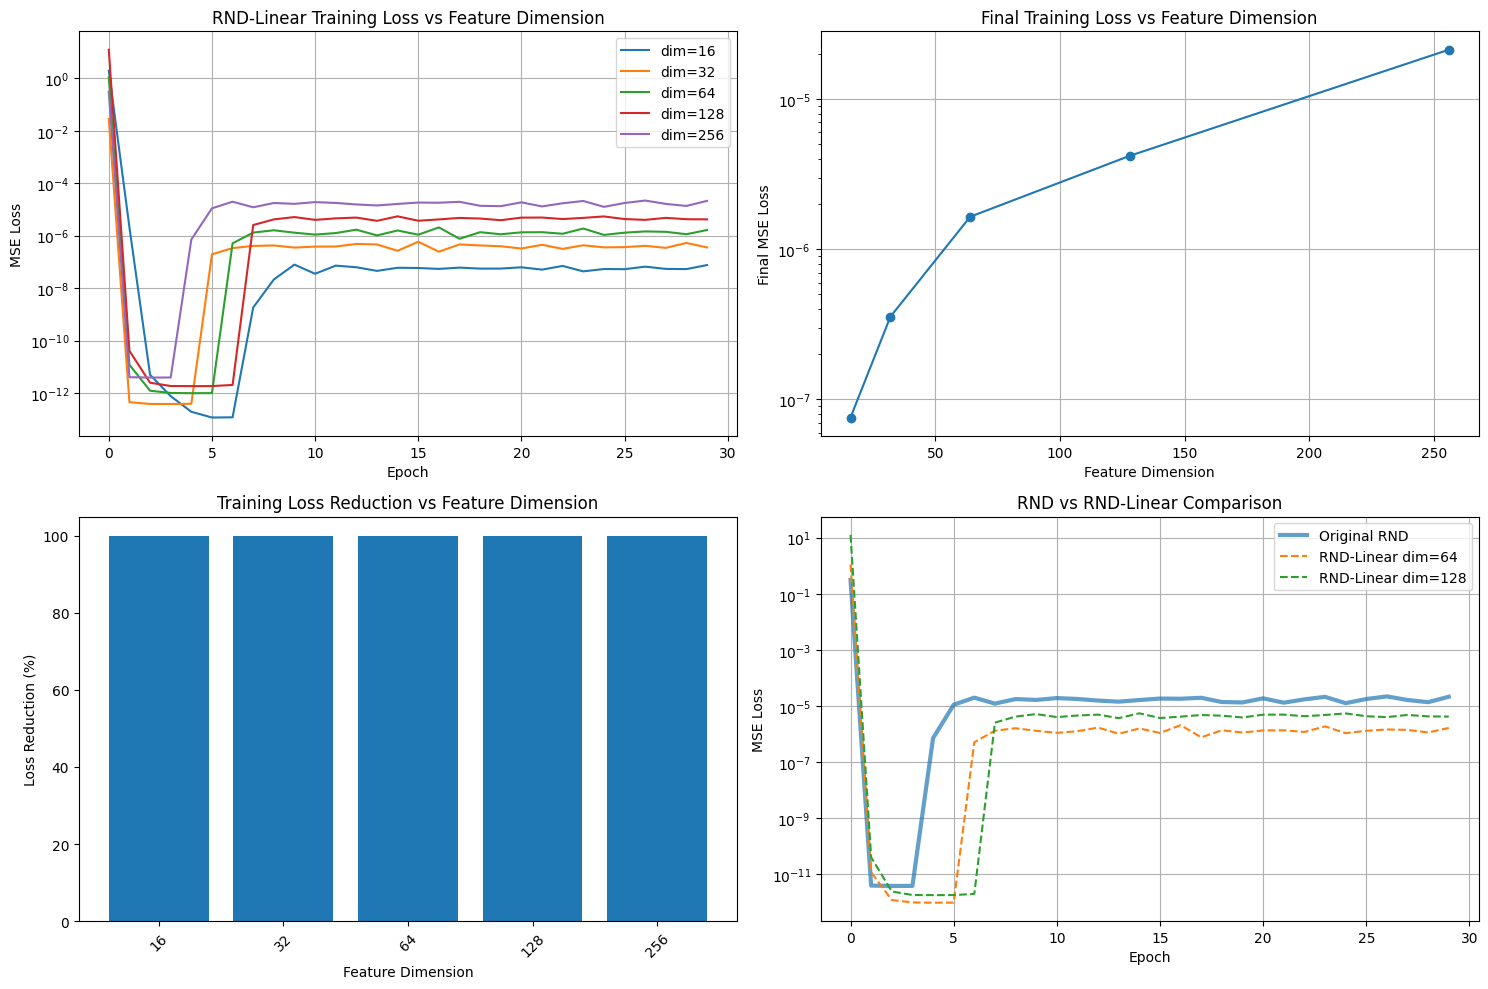


RND-LINEAR ANALYSIS SUMMARY
Training completed for different feature dimensions:
  Dim  16: Final loss = 0.000000, Reduction = 100.0%
  Dim  32: Final loss = 0.000000, Reduction = 100.0%
  Dim  64: Final loss = 0.000002, Reduction = 100.0%
  Dim 128: Final loss = 0.000004, Reduction = 100.0%
  Dim 256: Final loss = 0.000021, Reduction = 100.0%

✓ All RND-Linear models saved to 'rnd_linear_models' dictionary
✓ Access models with: rnd_linear_models[feature_dim]
✓ Each model has 64 trainable parameters (just θ̂ vector)

Parameter count comparison:
  Original RND: 8,512 parameters
  RND-Linear (dim=64): 64 parameters
  Reduction: 133.0x fewer parameters


In [ ]:
# RND-LINEAR IMPLEMENTATION
print("=" * 80)
print("RND-LINEAR IMPLEMENTATION")
print("=" * 80)

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

class RNDLinear:
    """
    RND-Linear: Simplified RND with shared feature layer φ(s) and linear combinations
    
    Architecture:
    - φ(s): Single linear layer (2 → feature_dim), FROZEN, shared by both networks
    - Target: f_θ(s) = ⟨φ(s), θ⟩ where θ is random fixed vector
    - Predictor: f_θ̂(s) = ⟨φ(s), θ̂⟩ where θ̂ is learned vector
    """
    
    def __init__(self, feature_dim=64, device='cpu'):
        self.device = device
        self.feature_dim = feature_dim
        
        # Single shared feature layer φ(s): 2 → feature_dim
        self.phi_network = nn.Linear(2, feature_dim).to(device)
        
        # Freeze φ(s) - this stays fixed for both target and predictor
        for param in self.phi_network.parameters():
            param.requires_grad = False
        
        # Target vector θ: random fixed vector
        self.theta_target = nn.Parameter(torch.randn(feature_dim, device=device), requires_grad=False)
        
        # Predictor vector θ̂: learnable vector (initialized randomly)
        self.theta_predictor = nn.Parameter(torch.randn(feature_dim, device=device), requires_grad=True)
        
        # Optimizer for predictor vector only
        self.optimizer = optim.Adam([self.theta_predictor], lr=1e-3)
        
        # For observation normalization
        self.obs_mean = None
        self.obs_std = None
        
        print("RND-Linear Networks initialized:")
        print(f"  φ(s): {2} → {feature_dim} (FROZEN, shared)")
        print(f"  Target θ: {feature_dim}-dim vector (FROZEN, random)")
        print(f"  Predictor θ̂: {feature_dim}-dim vector (TRAINABLE)")
        print(f"  Total trainable params: {feature_dim}")
    
    def normalize_observations(self, observations):
        """Normalize for training stability"""
        if self.obs_mean is None:
            self.obs_mean = torch.mean(observations, dim=0, keepdim=True)
            self.obs_std = torch.std(observations, dim=0, keepdim=True) + 1e-8
        return (observations - self.obs_mean) / self.obs_std
    
    def compute_features(self, observations):
        """Compute φ(s) features"""
        self.phi_network.eval()
        norm_obs = self.normalize_observations(observations)
        return self.phi_network(norm_obs)
    
    def compute_target_output(self, observations):
        """Compute target f_θ(s) = ⟨φ(s), θ⟩"""
        features = self.compute_features(observations)  # [batch, feature_dim]
        return torch.sum(features * self.theta_target.unsqueeze(0), dim=1)  # [batch]
    
    def compute_predictor_output(self, observations):
        """Compute predictor f_θ̂(s) = ⟨φ(s), θ̂⟩"""
        features = self.compute_features(observations)  # [batch, feature_dim]
        return torch.sum(features * self.theta_predictor.unsqueeze(0), dim=1)  # [batch]
    
    def compute_uncertainty_abs_diff(self, observations):
        """Compute RND-Linear uncertainty using absolute difference"""
        with torch.no_grad():
            target_output = self.compute_target_output(observations)
            predictor_output = self.compute_predictor_output(observations)
            uncertainty = torch.abs(target_output - predictor_output)
        return uncertainty
    
    def train_on_dataset(self, num_epochs=50):
        """Train predictor θ̂ to match target θ on dataset observations"""
        print("Loading and processing dataset...")
        
        # Extract all achieved_goal positions from dataset
        positions = []
        for episode in tqdm(dataset.iterate_episodes(), desc="Loading data"):
            observations = episode.observations
            if isinstance(observations, dict) and 'achieved_goal' in observations:
                positions.extend(observations['achieved_goal'])
        
        positions = torch.tensor(positions, dtype=torch.float32).to(self.device)
        print(f"Training on {len(positions)} observations")
        print(f"Feature dimension: {self.feature_dim}")
        
        # Compute normalization stats
        _ = self.normalize_observations(positions[:1000])
        
        # Training loop
        losses = []
        
        for epoch in tqdm(range(num_epochs), desc="RND-Linear Training"):
            # Shuffle data
            indices = torch.randperm(len(positions))
            epoch_loss = 0
            batch_size = 512
            
            for i in range(0, len(positions), batch_size):
                batch_idx = indices[i:i+batch_size]
                batch_obs = positions[batch_idx]
                
                # Compute outputs
                target_output = self.compute_target_output(batch_obs).detach()
                predictor_output = self.compute_predictor_output(batch_obs)
                
                # MSE loss: predictor tries to match target
                loss = nn.functional.mse_loss(predictor_output, target_output)
                
                # Backprop
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                
                epoch_loss += loss.item()
            
            avg_loss = epoch_loss / (len(positions) // batch_size + 1)
            losses.append(avg_loss)
            
            if epoch % 10 == 0:
                print(f"Epoch {epoch}: Loss = {avg_loss:.6f}")
        
        print("RND-Linear training complete!")
        return losses

# Test different feature dimensions
print("\n" + "="*60)
print("TESTING DIFFERENT FEATURE DIMENSIONS")
print("="*60)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Sweep over different feature dimensions
feature_dims = [16, 32, 64, 128, 256]
rnd_linear_models = {}
rnd_linear_losses = {}

for feature_dim in feature_dims:
    print(f"\n" + "-"*50)
    print(f"FEATURE DIMENSION: {feature_dim}")
    print("-"*50)
    
    # Initialize RND-Linear model
    rnd_linear = RNDLinear(feature_dim=feature_dim, device=device)
    
    # Train model
    training_losses = rnd_linear.train_on_dataset(num_epochs=30)
    
    # Store results
    rnd_linear_models[feature_dim] = rnd_linear
    rnd_linear_losses[feature_dim] = training_losses
    
    print(f"Final loss for dim {feature_dim}: {training_losses[-1]:.6f}")

# Plot training progress comparison
plt.figure(figsize=(15, 10))

# Plot 1: Training losses for different dimensions
plt.subplot(2, 2, 1)
for feature_dim in feature_dims:
    plt.plot(rnd_linear_losses[feature_dim], label=f'dim={feature_dim}')
plt.title('RND-Linear Training Loss vs Feature Dimension')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.legend()
plt.grid(True)

# Plot 2: Final loss vs dimension
plt.subplot(2, 2, 2)
final_losses = [rnd_linear_losses[dim][-1] for dim in feature_dims]
plt.plot(feature_dims, final_losses, 'o-')
plt.title('Final Training Loss vs Feature Dimension')
plt.xlabel('Feature Dimension')
plt.ylabel('Final MSE Loss')
plt.yscale('log')
plt.grid(True)

# Plot 3: Loss reduction vs dimension
plt.subplot(2, 2, 3)
loss_reductions = []
for feature_dim in feature_dims:
    losses = rnd_linear_losses[feature_dim]
    reduction = (losses[0] - losses[-1]) / losses[0] * 100
    loss_reductions.append(reduction)

plt.bar([str(d) for d in feature_dims], loss_reductions)
plt.title('Training Loss Reduction vs Feature Dimension')
plt.xlabel('Feature Dimension')
plt.ylabel('Loss Reduction (%)')
plt.xticks(rotation=45)

# Plot 4: Compare with original RND (if available)
plt.subplot(2, 2, 4)
if 'training_losses' in globals():
    plt.plot(training_losses, label='Original RND', linewidth=3, alpha=0.7)

for feature_dim in [64, 128]:  # Show a couple for comparison
    if feature_dim in rnd_linear_losses:
        plt.plot(rnd_linear_losses[feature_dim], label=f'RND-Linear dim={feature_dim}', linestyle='--')

plt.title('RND vs RND-Linear Comparison')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\n" + "="*80)
print("RND-LINEAR ANALYSIS SUMMARY")
print("="*80)
print("Training completed for different feature dimensions:")
for feature_dim in feature_dims:
    final_loss = rnd_linear_losses[feature_dim][-1]
    reduction = (rnd_linear_losses[feature_dim][0] - final_loss) / rnd_linear_losses[feature_dim][0] * 100
    print(f"  Dim {feature_dim:3d}: Final loss = {final_loss:.6f}, Reduction = {reduction:.1f}%")

print(f"\n✓ All RND-Linear models saved to 'rnd_linear_models' dictionary")
print(f"✓ Access models with: rnd_linear_models[feature_dim]")
print(f"✓ Each model has {sum(p.numel() for p in [rnd_linear_models[64].theta_predictor])} trainable parameters (just θ̂ vector)")

# Compare parameter counts
if 'rnd_model' in globals():
    original_params = sum(p.numel() for p in rnd_model.predictor_network.parameters())
    linear_params = feature_dims[2]  # 64-dim example
    print(f"\nParameter count comparison:")
    print(f"  Original RND: {original_params:,} parameters")
    print(f"  RND-Linear (dim=64): {linear_params} parameters")
    print(f"  Reduction: {original_params/linear_params:.1f}x fewer parameters")

### RND Linear Plots

COMPUTING UNCERTAINTIES FOR RND-LINEAR MODELS
Computing uncertainty for RND-Linear dim=16...


RND-Linear dim=16: 100%|██████████| 9/9 [00:00<00:00, 651.33it/s]


Computing uncertainty for RND-Linear dim=32...


RND-Linear dim=32: 100%|██████████| 9/9 [00:00<00:00, 575.03it/s]


Computing uncertainty for RND-Linear dim=64...


...

Computing uncertainty for RND-Linear dim=128...


RND-Linear dim=128: 100%|██████████| 9/9 [00:00<00:00, 534.19it/s]


Computing uncertainty for RND-Linear dim=256...


RND-Linear dim=256: 100%|██████████| 9/9 [00:00<00:00, 227.32it/s]


RND-LINEAR MODEL STATISTICS

RND-Linear dim=16:
  Min uncertainty: 0.000002
  Max uncertainty: 0.000314
  Mean uncertainty: 0.000121
  Std uncertainty: 0.000082

RND-Linear dim=32:
  Min uncertainty: 0.000000
  Max uncertainty: 0.000006
  Mean uncertainty: 0.000002
  Std uncertainty: 0.000001

RND-Linear dim=64:
  Min uncertainty: 0.000000
  Max uncertainty: 0.000005
  Mean uncertainty: 0.000001
  Std uncertainty: 0.000001

RND-Linear dim=128:
  Min uncertainty: 0.000022
  Max uncertainty: 0.001060
  Mean uncertainty: 0.000436
  Std uncertainty: 0.000271

RND-Linear dim=256:
  Min uncertainty: 0.000000
  Max uncertainty: 0.000006
  Mean uncertainty: 0.000002
  Std uncertainty: 0.000002

Ground Truth (Count-based 1/√N) for comparison:
  Min uncertainty: 0.003863
  Max uncertainty: 0.019331
  Mean uncertainty: 0.008267
  Std uncertainty: 0.003559


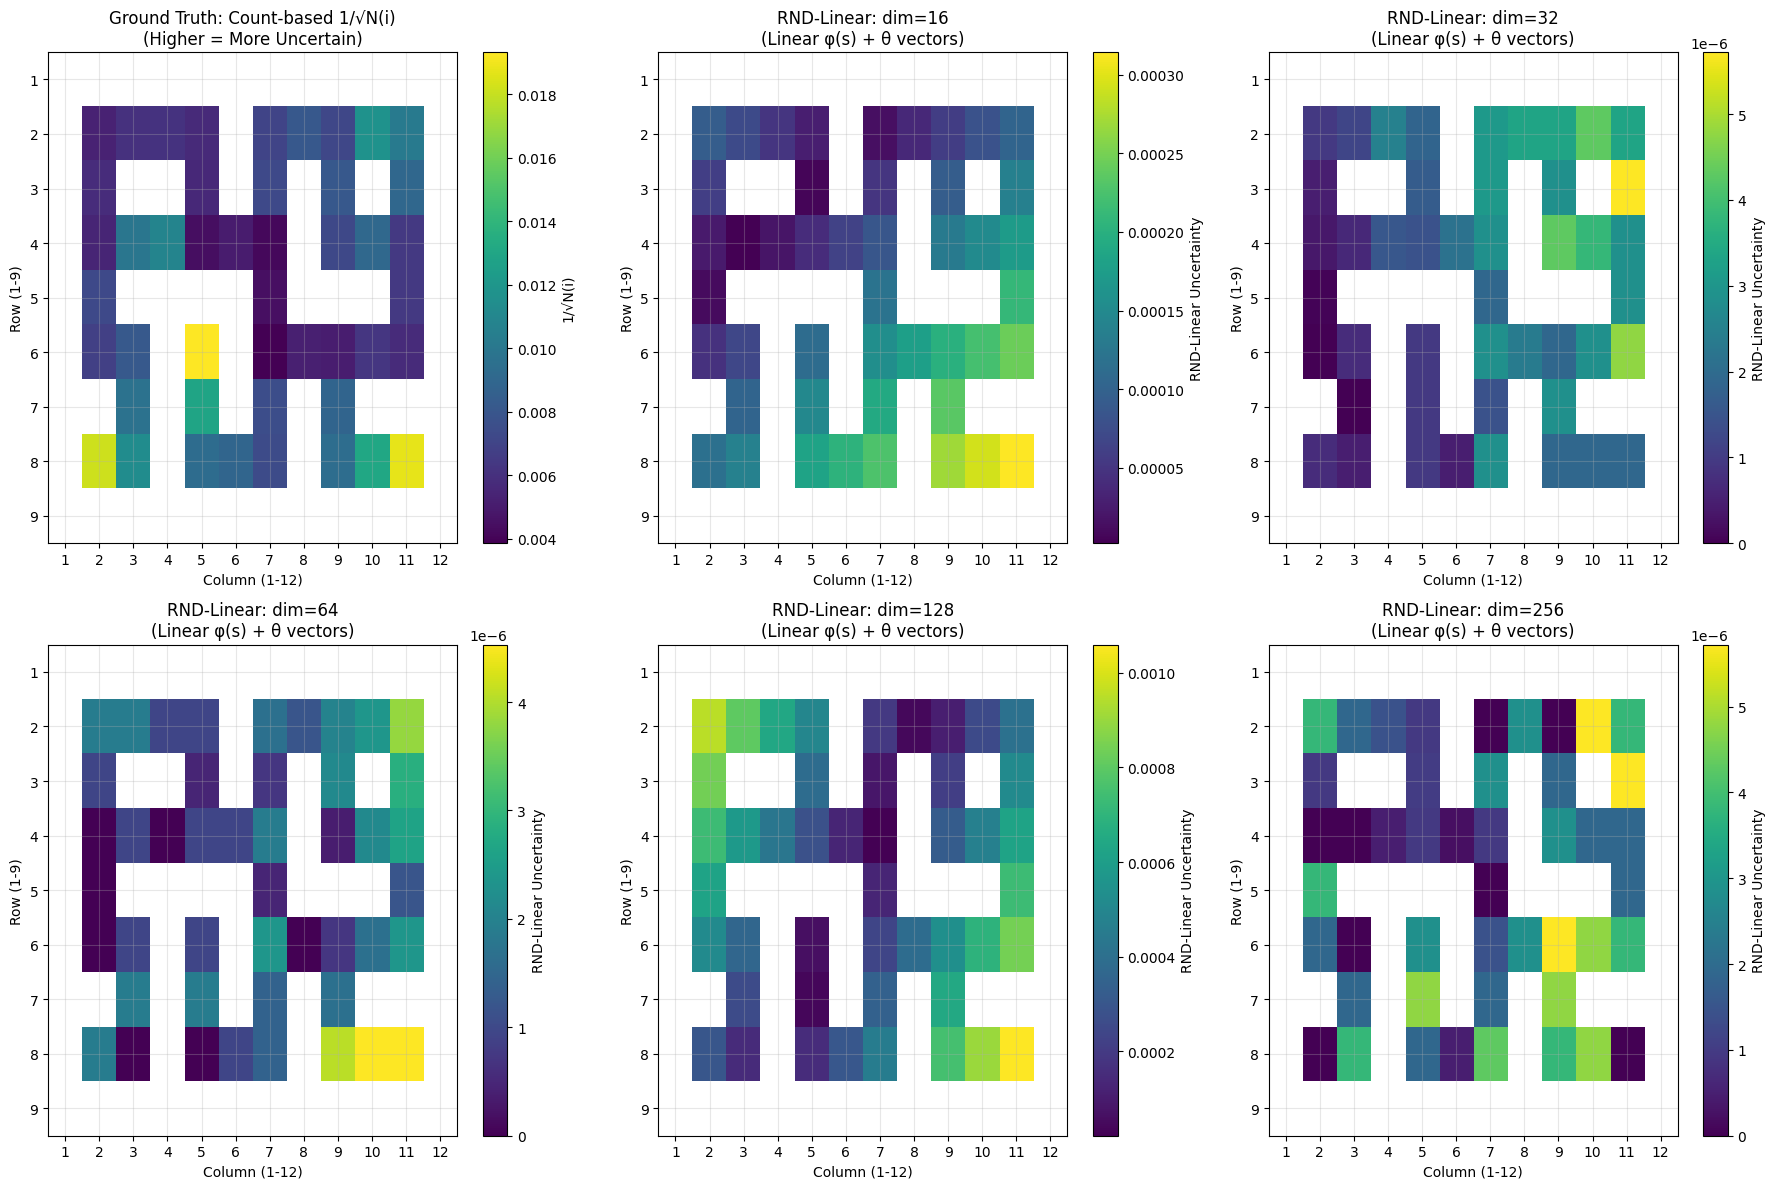

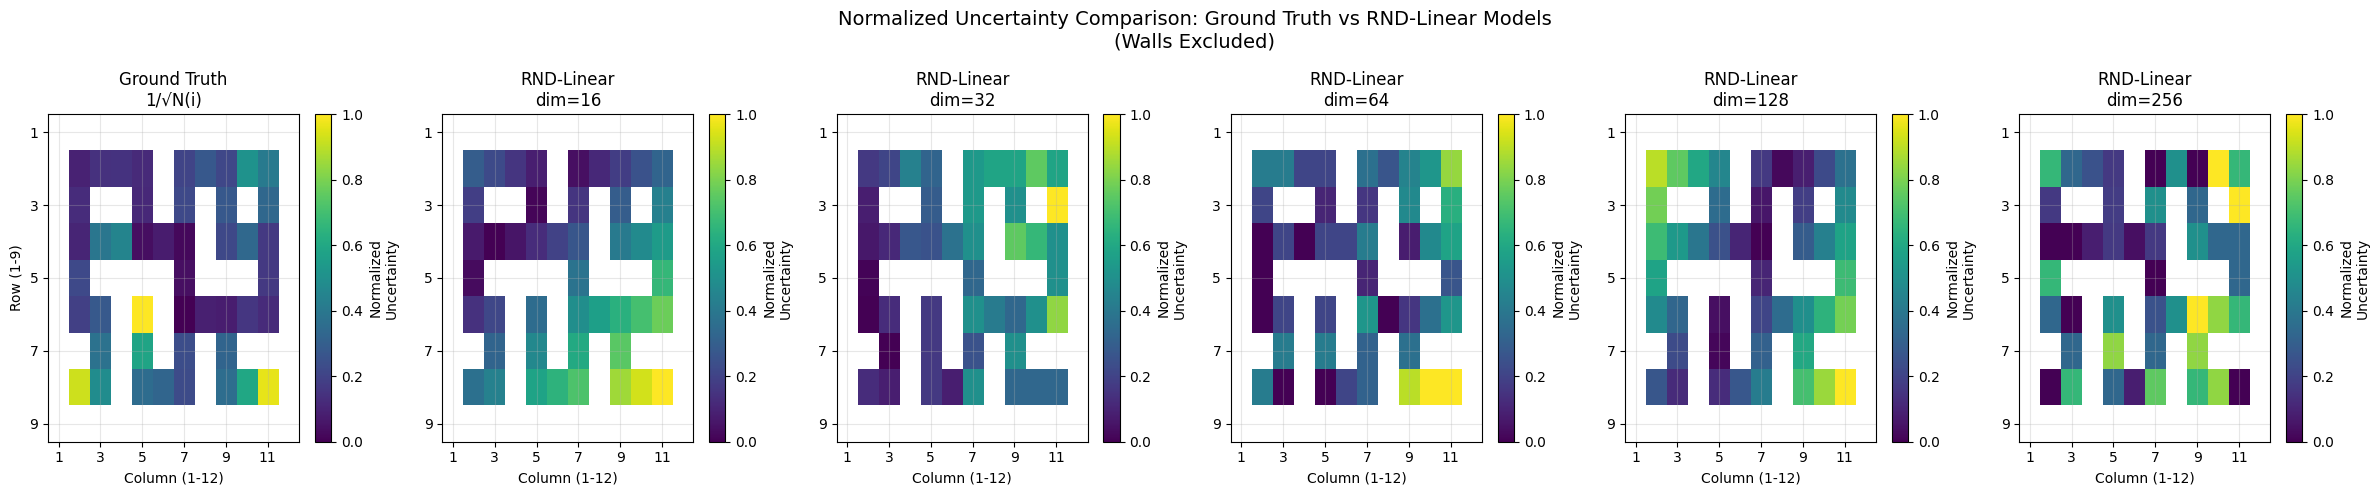


CORRELATION ANALYSIS WITH GROUND TRUTH
RND-Linear dim=16: correlation = 0.2678
RND-Linear dim=32: correlation = -0.1597
RND-Linear dim=64: correlation = 0.3521
RND-Linear dim=128: correlation = -0.0179
RND-Linear dim=256: correlation = 0.0832


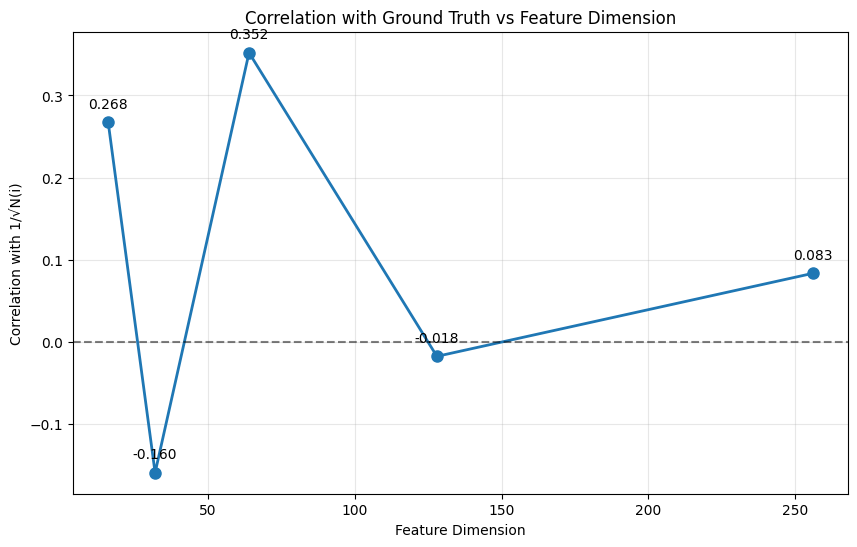


VISUAL COMPARISON COMPLETE
Key Observations:
• Ground Truth: Based on actual visit frequencies from dataset
• RND-Linear: Simplified RND with shared φ(s) and linear combinations
• Different feature dimensions show varying uncertainty patterns
• All plots exclude walls (shown as white/transparent areas)
• Higher correlations indicate better match with count-based uncertainty


In [ ]:
# COMPUTE UNCERTAINTIES FOR RND-LINEAR MODELS
print("=" * 80)
print("COMPUTING UNCERTAINTIES FOR RND-LINEAR MODELS")
print("=" * 80)

# Compute uncertainties for each RND-Linear model with different feature dimensions
rnd_linear_uncertainties = {}

for feature_dim in feature_dims:
    print(f"Computing uncertainty for RND-Linear dim={feature_dim}...")
    
    uncertainty_matrix = np.zeros((9, 12), dtype=float)
    
    for row in tqdm(range(1, 10), desc=f"RND-Linear dim={feature_dim}"):
        for col in range(1, 13):
            # Get center coordinates
            center_x, center_y = grid_to_center_observation(row, col)
            obs_tensor = torch.tensor([[center_x, center_y]], dtype=torch.float32).to(device)
            
            # Compute uncertainty using RND-Linear model
            uncertainty = rnd_linear_models[feature_dim].compute_uncertainty_abs_diff(obs_tensor).item()
            uncertainty_matrix[row-1, col-1] = uncertainty
    
    rnd_linear_uncertainties[feature_dim] = uncertainty_matrix

# PRINT STATISTICS FOR RND-LINEAR MODELS
print("\n" + "="*80)
print("RND-LINEAR MODEL STATISTICS")
print("="*80)

for feature_dim in feature_dims:
    uncertainty_matrix = rnd_linear_uncertainties[feature_dim]
    
    # Mask out walls for statistics
    open_cells_mask = np.array([[maze_map[i][j] == 0 for j in range(12)] for i in range(9)])
    open_uncertainties = uncertainty_matrix[open_cells_mask]
    
    print(f"\nRND-Linear dim={feature_dim}:")
    print(f"  Min uncertainty: {np.min(open_uncertainties):.6f}")
    print(f"  Max uncertainty: {np.max(open_uncertainties):.6f}")
    print(f"  Mean uncertainty: {np.mean(open_uncertainties):.6f}")
    print(f"  Std uncertainty: {np.std(open_uncertainties):.6f}")

# COMPARISON WITH GROUND TRUTH (COUNT-BASED 1/√N)
print(f"\nGround Truth (Count-based 1/√N) for comparison:")
open_cells_mask = np.array([[maze_map[i][j] == 0 for j in range(12)] for i in range(9)])
finite_mask = np.isfinite(uncertainty_9x12) & open_cells_mask
if np.any(finite_mask):
    ground_truth_open = uncertainty_9x12[finite_mask]
    print(f"  Min uncertainty: {np.min(ground_truth_open):.6f}")
    print(f"  Max uncertainty: {np.max(ground_truth_open):.6f}")
    print(f"  Mean uncertainty: {np.mean(ground_truth_open):.6f}")
    print(f"  Std uncertainty: {np.std(ground_truth_open):.6f}")

# CREATE COMPREHENSIVE PLOT: RND-LINEAR MODELS vs GROUND TRUTH
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Function to mask walls for plotting
def mask_walls(uncertainty_matrix):
    masked = uncertainty_matrix.copy()
    for r in range(9):
        for c in range(12):
            if maze_map[r][c] == 1:  # Wall
                masked[r, c] = np.nan
    return masked

# Plot 1: Ground Truth (Count-based 1/√N)
ax1 = axes[0, 0]
ground_truth_masked = mask_walls(uncertainty_9x12)
# Handle infinite values for visualization
ground_truth_plot = ground_truth_masked.copy()
finite_mask = np.isfinite(ground_truth_plot)
if np.any(finite_mask):
    max_finite = np.max(ground_truth_plot[finite_mask])
    ground_truth_plot[np.isinf(ground_truth_plot)] = max_finite * 2

im1 = ax1.imshow(ground_truth_plot, cmap='viridis', aspect='auto')
ax1.set_title('Ground Truth: Count-based 1/√N(i)\n(Higher = More Uncertain)')
ax1.set_xlabel('Column (1-12)')
ax1.set_ylabel('Row (1-9)')
ax1.set_xticks(range(12))
ax1.set_yticks(range(9))
ax1.set_xticklabels(range(1, 13))
ax1.set_yticklabels(range(1, 10))
ax1.grid(True, alpha=0.3)
plt.colorbar(im1, ax=ax1, label='1/√N(i)')

# Plot 2-6: RND-Linear with different feature dimensions
plot_positions = [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]
for i, feature_dim in enumerate(feature_dims):
    ax = axes[plot_positions[i]]
    rnd_linear_masked = mask_walls(rnd_linear_uncertainties[feature_dim])
    im = ax.imshow(rnd_linear_masked, cmap='viridis', aspect='auto')
    ax.set_title(f'RND-Linear: dim={feature_dim}\n(Linear φ(s) + θ vectors)')
    ax.set_xlabel('Column (1-12)')
    ax.set_ylabel('Row (1-9)')
    ax.set_xticks(range(12))
    ax.set_yticks(range(9))
    ax.set_xticklabels(range(1, 13))
    ax.set_yticklabels(range(1, 10))
    ax.grid(True, alpha=0.3)
    plt.colorbar(im, ax=ax, label='RND-Linear Uncertainty')

plt.tight_layout()
plt.show()

# SIDE-BY-SIDE COMPARISON PLOT (ALL MODELS)
fig, axes = plt.subplots(1, 6, figsize=(24, 5))

# Normalize all uncertainties to [0,1] for fair comparison
def normalize_for_comparison(uncertainty_matrix):
    masked = mask_walls(uncertainty_matrix)
    finite_values = masked[np.isfinite(masked)]
    if len(finite_values) > 0:
        min_val, max_val = np.min(finite_values), np.max(finite_values)
        normalized = (masked - min_val) / (max_val - min_val)
        return normalized
    return masked

# Plot normalized versions for comparison
titles = ['Ground Truth\n1/√N(i)'] + [f'RND-Linear\ndim={dim}' for dim in feature_dims]
data = [uncertainty_9x12] + [rnd_linear_uncertainties[dim] for dim in feature_dims]

for i, (ax, title, uncertainty_data) in enumerate(zip(axes, titles, data)):
    normalized_data = normalize_for_comparison(uncertainty_data)
    im = ax.imshow(normalized_data, cmap='viridis', aspect='auto', vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel('Column (1-12)')
    if i == 0:
        ax.set_ylabel('Row (1-9)')
    ax.set_xticks(range(0, 12, 2))
    ax.set_yticks(range(0, 9, 2))
    ax.set_xticklabels(range(1, 13, 2))
    ax.set_yticklabels(range(1, 10, 2))
    ax.grid(True, alpha=0.3)
    plt.colorbar(im, ax=ax, label='Normalized\nUncertainty')

plt.suptitle('Normalized Uncertainty Comparison: Ground Truth vs RND-Linear Models\n(Walls Excluded)', fontsize=14)
plt.tight_layout()
plt.show()

# ADDITIONAL ANALYSIS: CORRELATION WITH GROUND TRUTH
print("\n" + "="*80)
print("CORRELATION ANALYSIS WITH GROUND TRUTH")
print("="*80)

# Compute correlations between RND-Linear uncertainties and ground truth
open_cells_mask = np.array([[maze_map[i][j] == 0 for j in range(12)] for i in range(9)])
ground_truth_open = uncertainty_9x12[open_cells_mask & np.isfinite(uncertainty_9x12)]

correlations = {}
for feature_dim in feature_dims:
    rnd_linear_open = rnd_linear_uncertainties[feature_dim][open_cells_mask]
    
    if len(ground_truth_open) == len(rnd_linear_open) and len(ground_truth_open) > 1:
        correlation = np.corrcoef(ground_truth_open, rnd_linear_open)[0, 1]
        correlations[feature_dim] = correlation
        print(f"RND-Linear dim={feature_dim}: correlation = {correlation:.4f}")

# Plot correlation vs feature dimension
if correlations:
    plt.figure(figsize=(10, 6))
    dims = list(correlations.keys())
    corrs = list(correlations.values())
    
    plt.plot(dims, corrs, 'o-', linewidth=2, markersize=8)
    plt.title('Correlation with Ground Truth vs Feature Dimension')
    plt.xlabel('Feature Dimension')
    plt.ylabel('Correlation with 1/√N(i)')
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    
    # Annotate points
    for dim, corr in zip(dims, corrs):
        plt.annotate(f'{corr:.3f}', (dim, corr), textcoords="offset points", 
                    xytext=(0,10), ha='center')
    
    plt.show()

print("\n" + "="*80)
print("VISUAL COMPARISON COMPLETE")
print("="*80)
print("Key Observations:")
print("• Ground Truth: Based on actual visit frequencies from dataset")
print("• RND-Linear: Simplified RND with shared φ(s) and linear combinations")
print("• Different feature dimensions show varying uncertainty patterns")
print("• All plots exclude walls (shown as white/transparent areas)")
print("• Higher correlations indicate better match with count-based uncertainty")

### RND Linear Debugging

In [ ]:
# DEBUG: Check if RND-Linear uncertainties are actually different
print("=" * 80)
print("DEBUGGING RND-LINEAR UNCERTAINTY MATRICES")
print("=" * 80)

# Check if the matrices are actually identical
if 'rnd_linear_uncertainties' in globals():
    print("Available RND-Linear dimensions:", list(rnd_linear_uncertainties.keys()))
    
    # Compare a few specific values from each matrix
    print("\nSample values from each matrix (position [0,0]):")
    for dim in [16, 32, 64, 128, 256]:
        if dim in rnd_linear_uncertainties:
            value = rnd_linear_uncertainties[dim][0, 0]
            print(f"  RND-Linear dim={dim}: [{0},{0}] = {value:.6f}")
    
    # Check if any matrices are identical
    print("\nMatrix equality checks:")
    dims = [16, 32, 64, 128, 256]
    for i, dim1 in enumerate(dims):
        for dim2 in dims[i+1:]:
            if dim1 in rnd_linear_uncertainties and dim2 in rnd_linear_uncertainties:
                are_equal = np.allclose(rnd_linear_uncertainties[dim1], rnd_linear_uncertainties[dim2])
                print(f"  dim={dim1} == dim={dim2}: {are_equal}")
                if are_equal:
                    print(f"    ❌ PROBLEM: These matrices are identical!")
    
    # Check matrix statistics
    print("\nMatrix statistics:")
    for dim in [16, 32, 64, 128, 256]:
        if dim in rnd_linear_uncertainties:
            matrix = rnd_linear_uncertainties[dim]
            print(f"  dim={dim}: min={matrix.min():.6f}, max={matrix.max():.6f}, mean={matrix.mean():.6f}")
else:
    print("❌ rnd_linear_uncertainties not found in globals")

# Also check if the models themselves are different
if 'rnd_linear_models' in globals():
    print("\nModel parameter checks:")
    for dim in [16, 32, 64, 128, 256]:
        if dim in rnd_linear_models:
            model = rnd_linear_models[dim]
            theta_norm = torch.norm(model.theta_predictor).item()
            phi_norm = torch.norm(model.phi_network.weight).item()
            print(f"  dim={dim}: θ̂_norm={theta_norm:.6f}, φ_norm={phi_norm:.6f}")

DEBUGGING RND-LINEAR UNCERTAINTY MATRICES
Available RND-Linear dimensions: [16, 32, 64, 128, 256]

Sample values from each matrix (position [0,0]):
  RND-Linear dim=16: [0,0] = 0.000152
  RND-Linear dim=32: [0,0] = 0.000002
  RND-Linear dim=64: [0,0] = 0.000004
  RND-Linear dim=128: [0,0] = 0.001205
  RND-Linear dim=256: [0,0] = 0.000001

Matrix equality checks:
  dim=16 == dim=32: False
  dim=16 == dim=64: False
  dim=16 == dim=128: False
  dim=16 == dim=256: False
  dim=32 == dim=64: False
  dim=32 == dim=128: False
  dim=32 == dim=256: False
  dim=64 == dim=128: False
  dim=64 == dim=256: False
  dim=128 == dim=256: False

Matrix statistics:
  dim=16: min=0.000002, max=0.000372, mean=0.000133
  dim=32: min=0.000000, max=0.000006, mean=0.000002
  dim=64: min=0.000000, max=0.000005, mean=0.000001
  dim=128: min=0.000000, max=0.001318, mean=0.000496
  dim=256: min=0.000000, max=0.000012, mean=0.000003

Model parameter checks:
  dim=16: θ̂_norm=4.717517, φ_norm=2.084858
  dim=32: θ̂_nor

In [ ]:
# CORRECTED FROBENIUS NORM CALCULATION
frobenius_distances_fixed = {}

# Ground truth
M_gt = uncertainty_9x12.copy()
finite_mask = np.isfinite(M_gt)
if np.any(~finite_mask):
    max_finite = np.max(M_gt[finite_mask])
    M_gt[~finite_mask] = max_finite * 2

open_cells_mask = np.array([[maze_map[i][j] == 0 for j in range(12)] for i in range(9)])

print("CORRECTED Frobenius norm calculation:")
print("=" * 60)

# Original RND
if 'rnd_uncertainty_9x12' in globals():
    M_rnd = rnd_uncertainty_9x12
    # CORRECTED: Apply mask to both matrices, then compute Frobenius norm on 2D result
    diff_matrix = (M_gt * open_cells_mask) - (M_rnd * open_cells_mask)
    frobenius_norm = np.linalg.norm(diff_matrix)  # 2D Frobenius norm
    frobenius_distances_fixed['Original RND'] = frobenius_norm
    print(f"Original RND: {frobenius_norm:.6f}")

# Corrected noise models
if 'corrected_uncertainties' in globals():
    for noise_std in [0.05, 0.1, 0.2]:
        if noise_std in corrected_uncertainties:
            M_rnd = corrected_uncertainties[noise_std]
            # CORRECTED: Frobenius norm on full 2D matrix
            diff_matrix = (M_gt * open_cells_mask) - (M_rnd * open_cells_mask)
            frobenius_norm = np.linalg.norm(diff_matrix)  # Remove [open_cells_mask]
            frobenius_distances_fixed[f'RND σ={noise_std}'] = frobenius_norm
            print(f"RND σ={noise_std}: {frobenius_norm:.6f}")

# RND-Linear models
if 'rnd_linear_uncertainties' in globals():
    for dim in [16, 32, 64, 128, 256]:
        if dim in rnd_linear_uncertainties:
            M_rnd = rnd_linear_uncertainties[dim]
            # CORRECTED: Frobenius norm on full 2D matrix
            diff_matrix = (M_gt * open_cells_mask) - (M_rnd * open_cells_mask)
            frobenius_norm = np.linalg.norm(diff_matrix)  # Remove [open_cells_mask]
            frobenius_distances_fixed[f'RND-Linear dim={dim}'] = frobenius_norm
            print(f"RND-Linear dim={dim}: {frobenius_norm:.6f}")

# Print corrected ranking
print(f"\n" + "="*80)
print("CORRECTED RANKING (lower Frobenius distance = better):")
print("="*80)

sorted_methods_fixed = sorted(frobenius_distances_fixed.items(), key=lambda x: x[1])
for rank, (method, distance) in enumerate(sorted_methods_fixed, 1):
    print(f"{rank:2d}. {method:<30}: {distance:.6f}")

CORRECTED Frobenius norm calculation:
Original RND: 0.055642

CORRECTED RANKING (lower Frobenius distance = better):
 1. Original RND                  : 0.055642


### Elliptical Bonus

In [ ]:
# ELLIPTICAL BONUS IMPLEMENTATION
print("=" * 80)
print("ELLIPTICAL BONUS IMPLEMENTATION")
print("=" * 80)

import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm

class EllipticalBonus:
    """
    Elliptical Bonus method following Jin et al. (2020)
    
    Intrinsic reward: i_t = [φ(s)^T Λ_t^{-1} φ(s)]^{1/2}
    
    Where:
    - φ(s): Linear feature mapping (2D → feature_dim)
    - Λ_t: Covariance matrix updated from offline data
    """
    
    def __init__(self, feature_dim=64, regularization=1e-6, device='cpu'):
        self.device = device
        self.feature_dim = feature_dim
        self.regularization = regularization
        
        # Linear feature mapping φ(s): 2D → feature_dim
        self.phi_network = nn.Linear(2, feature_dim).to(device)
        
        # Freeze feature network (like RND-Linear)
        for param in self.phi_network.parameters():
            param.requires_grad = False
        
        # Initialize covariance matrix Λ
        self.Lambda = torch.eye(feature_dim, device=device) * regularization
        self.Lambda_inv = torch.eye(feature_dim, device=device) / regularization
        
        # For observation normalization
        self.obs_mean = None
        self.obs_std = None
        
        print("Elliptical Bonus initialized:")
        print(f"  φ(s): 2D → {feature_dim}D (FROZEN linear features)")
        print(f"  Λ: {feature_dim}×{feature_dim} covariance matrix")
        print(f"  Regularization: {regularization}")
        print(f"  Intrinsic reward: i_t = [φ(s)^T Λ^{-1} φ(s)]^{1/2}")
    
    def normalize_observations(self, observations):
        """Normalize observations for stability"""
        if self.obs_mean is None:
            self.obs_mean = torch.mean(observations, dim=0, keepdim=True)
            self.obs_std = torch.std(observations, dim=0, keepdim=True) + 1e-8
        return (observations - self.obs_mean) / self.obs_std
    
    def compute_features(self, observations):
        """Compute φ(s) features"""
        self.phi_network.eval()
        norm_obs = self.normalize_observations(observations)
        return self.phi_network(norm_obs)
    
    def update_covariance_matrix(self, observations):
        """
        Update covariance matrix Λ from offline data:
        Λ = (1/n) Σ φ(s_i) φ(s_i)^T + regularization * I
        """
        print("Updating covariance matrix from offline data...")
        
        # Get all features from observations
        features_list = []
        batch_size = 1000
        
        for i in tqdm(range(0, len(observations), batch_size), desc="Computing features"):
            batch_obs = observations[i:i+batch_size]
            batch_features = self.compute_features(batch_obs)
            features_list.append(batch_features)
        
        # Concatenate all features
        all_features = torch.cat(features_list, dim=0)  # [n_samples, feature_dim]
        n_samples = all_features.shape[0]
        
        print(f"Computing covariance from {n_samples} samples...")
        
        # Compute empirical covariance: Λ = (1/n) Σ φ(s_i) φ(s_i)^T
        # Using batch computation for memory efficiency
        self.Lambda = torch.zeros(self.feature_dim, self.feature_dim, device=self.device)
        
        batch_size_cov = 5000
        for i in tqdm(range(0, n_samples, batch_size_cov), desc="Computing covariance"):
            batch_features = all_features[i:i+batch_size_cov]
            # batch_features: [batch_size, feature_dim]
            batch_cov = torch.matmul(batch_features.T, batch_features)  # [feature_dim, feature_dim]
            self.Lambda += batch_cov
        
        # Normalize by number of samples and add regularization
        self.Lambda = self.Lambda / n_samples + torch.eye(self.feature_dim, device=self.device) * self.regularization
        
        # Compute inverse (with numerical stability check)
        try:
            self.Lambda_inv = torch.inverse(self.Lambda)
            print("✓ Covariance matrix inverted successfully")
        except:
            print("⚠ Matrix inversion failed, using pseudo-inverse")
            self.Lambda_inv = torch.pinverse(self.Lambda)
        
        # Check condition number
        eigenvals = torch.linalg.eigvals(self.Lambda).real
        condition_number = torch.max(eigenvals) / torch.min(eigenvals)
        print(f"Covariance matrix condition number: {condition_number:.2e}")
        
        return self.Lambda, self.Lambda_inv
    
    def compute_intrinsic_reward(self, observations):
        """
        Compute elliptical bonus: i_t = [φ(s)^T Λ^{-1} φ(s)]^{1/2}
        """
        with torch.no_grad():
            # Get features φ(s)
            features = self.compute_features(observations)  # [batch_size, feature_dim]
            
            # Compute φ(s)^T Λ^{-1} φ(s) for each observation
            # features: [batch_size, feature_dim]
            # Lambda_inv: [feature_dim, feature_dim]
            
            # Method 1: Vectorized computation
            # φ(s)^T Λ^{-1} φ(s) = φ(s)^T @ Λ^{-1} @ φ(s)
            temp = torch.matmul(features, self.Lambda_inv)  # [batch_size, feature_dim]
            quadratic_form = torch.sum(temp * features, dim=1)  # [batch_size]
            
            # Take square root for final intrinsic reward
            intrinsic_reward = torch.sqrt(torch.clamp(quadratic_form, min=1e-8))
            
        return intrinsic_reward
    
    def fit_on_dataset(self):
        """Fit the elliptical bonus on the offline dataset"""
        print("Loading dataset for elliptical bonus...")
        
        # Extract all achieved_goal positions from dataset
        positions = []
        for episode in tqdm(dataset.iterate_episodes(), desc="Loading data"):
            observations = episode.observations
            if isinstance(observations, dict) and 'achieved_goal' in observations:
                positions.extend(observations['achieved_goal'])
        
        positions = torch.tensor(positions, dtype=torch.float32).to(self.device)
        print(f"Loaded {len(positions)} observations from dataset")
        
        # Compute normalization stats
        _ = self.normalize_observations(positions[:1000])
        
        # Update covariance matrix
        self.update_covariance_matrix(positions)
        
        print("✓ Elliptical bonus fitting complete!")
        return positions

# Initialize and fit elliptical bonus
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Test different feature dimensions
feature_dims_elliptical = [16, 32, 64, 128, 256]
elliptical_models = {}

for feature_dim in feature_dims_elliptical:
    print(f"\n" + "="*60)
    print(f"ELLIPTICAL BONUS: FEATURE DIMENSION {feature_dim}")
    print("="*60)
    
    # Initialize elliptical bonus
    elliptical_bonus = EllipticalBonus(feature_dim=feature_dim, device=device)
    
    # Fit on dataset (compute covariance matrix)
    dataset_positions = elliptical_bonus.fit_on_dataset()
    
    # Store model
    elliptical_models[feature_dim] = elliptical_bonus

print(f"\n✓ All elliptical bonus models fitted!")
print(f"✓ Models available for feature dimensions: {feature_dims_elliptical}")

ELLIPTICAL BONUS IMPLEMENTATION
Using device: cpu

ELLIPTICAL BONUS: FEATURE DIMENSION 16
Elliptical Bonus initialized:
  φ(s): 2D → 16D (FROZEN linear features)
  Λ: 16×16 covariance matrix
  Regularization: 1e-06
  Intrinsic reward: i_t = [φ(s)^T Λ^-1 φ(s)]^0.5
Loading dataset for elliptical bonus...


Loading data: 0it [00:00, ?it/s]

Loading data: 3360it [00:09, 353.18it/s]
/tmp/ipykernel_973084/2010694606.py:145: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  positions = torch.tensor(positions, dtype=torch.float32).to(self.device)
Loading data: 3360it [00:09, 353.18it/s]
/tmp/ipykernel_973084/2010694606.py:145: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  positions = torch.tensor(positions, dtype=torch.float32).to(self.device)


Loaded 1003360 observations from dataset
Updating covariance matrix from offline data...


Computing features: 100%|██████████| 1004/1004 [00:00<00:00, 2966.36it/s]



...

Loaded 1003360 observations from dataset
Updating covariance matrix from offline data...


Computing features: 100%|██████████| 1004/1004 [00:00<00:00, 4205.59it/s]



Computing covariance from 1003360 samples...


Computing covariance: 100%|██████████| 201/201 [00:00<00:00, 312.72it/s]



✓ Covariance matrix inverted successfully
Covariance matrix condition number: -2.48e+07
✓ Elliptical bonus fitting complete!

✓ All elliptical bonus models fitted!
✓ Models available for feature dimensions: [16, 32, 64, 128, 256]


### Uncertainty Metric for Elliptical

COMPUTING UNCERTAINTIES FOR ELLIPTICAL BONUS MODELS
Computing uncertainty for Elliptical Bonus dim=16...


Elliptical dim=16: 100%|██████████| 9/9 [00:00<00:00, 52.94it/s]


Computing uncertainty for Elliptical Bonus dim=32...


Elliptical dim=32: 100%|██████████| 9/9 [00:00<00:00, 753.42it/s]


Computing uncertainty for Elliptical Bonus dim=64...


...

Computing uncertainty for Elliptical Bonus dim=128...


Elliptical dim=128: 100%|██████████| 9/9 [00:00<00:00, 508.67it/s]


Computing uncertainty for Elliptical Bonus dim=256...


Elliptical dim=256: 100%|██████████| 9/9 [00:00<00:00, 416.97it/s]




ELLIPTICAL BONUS MODEL STATISTICS

Elliptical Bonus dim=16:
  Min uncertainty: 1.010191
  Max uncertainty: 3.060308
  Mean uncertainty: 1.875586
  Std uncertainty: 0.464127

Elliptical Bonus dim=32:
  Min uncertainty: 0.000100
  Max uncertainty: 2.983109
  Mean uncertainty: 1.827846
  Std uncertainty: 0.588706

Elliptical Bonus dim=64:
  Min uncertainty: 0.000100
  Max uncertainty: 3.867359
  Mean uncertainty: 2.061392
  Std uncertainty: 0.897951

Elliptical Bonus dim=128:
  Min uncertainty: 0.000100
  Max uncertainty: 9.340714
  Mean uncertainty: 4.357199
  Std uncertainty: 2.513208

Elliptical Bonus dim=256:
  Min uncertainty: 0.000100
  Max uncertainty: 12.301442
  Mean uncertainty: 3.981540
  Std uncertainty: 3.735072


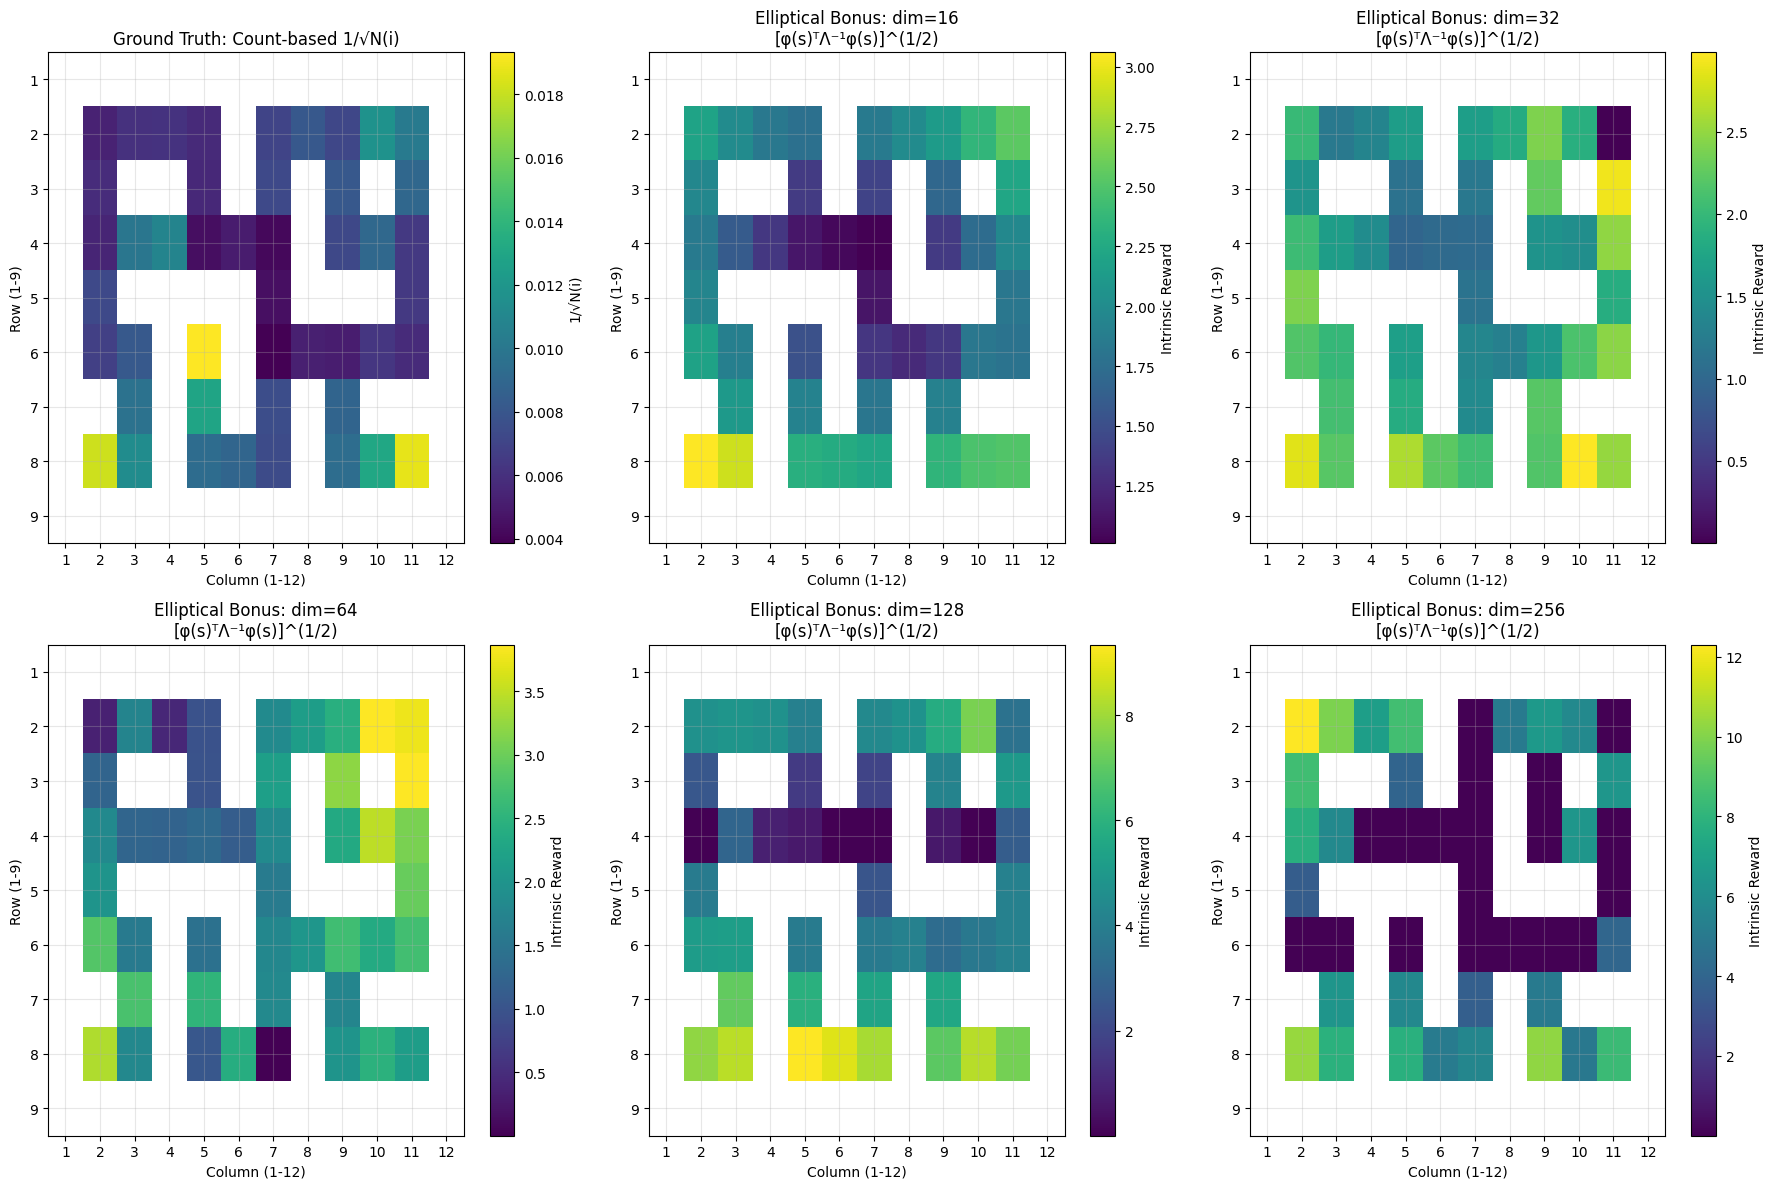


ELLIPTICAL BONUS IMPLEMENTATION COMPLETE
Key Features:
• Uses linear features φ(s) from 2D → feature_dim
• Covariance matrix Λ updated from offline dataset
• Intrinsic reward: i_t = [φ(s)ᵀ Λ⁻¹ φ(s)]^(1/2)
• Higher rewards indicate more uncertain/novel states


In [ ]:
# COMPUTE UNCERTAINTIES FOR ELLIPTICAL BONUS MODELS
print("=" * 80)
print("COMPUTING UNCERTAINTIES FOR ELLIPTICAL BONUS MODELS")
print("=" * 80)

# Compute uncertainties for each elliptical bonus model
elliptical_uncertainties = {}

for feature_dim in feature_dims_elliptical:
    print(f"Computing uncertainty for Elliptical Bonus dim={feature_dim}...")
    
    uncertainty_matrix = np.zeros((9, 12), dtype=float)
    
    for row in tqdm(range(1, 10), desc=f"Elliptical dim={feature_dim}"):
        for col in range(1, 13):
            # Get center coordinates
            center_x, center_y = grid_to_center_observation(row, col)
            obs_tensor = torch.tensor([[center_x, center_y]], dtype=torch.float32).to(device)
            
            # Compute intrinsic reward using elliptical bonus
            intrinsic_reward = elliptical_models[feature_dim].compute_intrinsic_reward(obs_tensor).item()
            uncertainty_matrix[row-1, col-1] = intrinsic_reward
    
    elliptical_uncertainties[feature_dim] = uncertainty_matrix

# PRINT STATISTICS FOR ELLIPTICAL BONUS MODELS
print("\n" + "="*80)
print("ELLIPTICAL BONUS MODEL STATISTICS")
print("="*80)

for feature_dim in feature_dims_elliptical:
    uncertainty_matrix = elliptical_uncertainties[feature_dim]
    
    # Mask out walls for statistics
    open_cells_mask = np.array([[maze_map[i][j] == 0 for j in range(12)] for i in range(9)])
    open_uncertainties = uncertainty_matrix[open_cells_mask]
    
    print(f"\nElliptical Bonus dim={feature_dim}:")
    print(f"  Min uncertainty: {np.min(open_uncertainties):.6f}")
    print(f"  Max uncertainty: {np.max(open_uncertainties):.6f}")
    print(f"  Mean uncertainty: {np.mean(open_uncertainties):.6f}")
    print(f"  Std uncertainty: {np.std(open_uncertainties):.6f}")

# CREATE VISUALIZATION
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Function to mask walls for plotting
def mask_walls(uncertainty_matrix):
    masked = uncertainty_matrix.copy()
    for r in range(9):
        for c in range(12):
            if maze_map[r][c] == 1:  # Wall
                masked[r, c] = np.nan
    return masked

# Plot 1: Ground Truth (Count-based 1/√N)
ax1 = axes[0, 0]
ground_truth_masked = mask_walls(uncertainty_9x12)
ground_truth_plot = ground_truth_masked.copy()
finite_mask = np.isfinite(ground_truth_plot)
if np.any(finite_mask):
    max_finite = np.max(ground_truth_plot[finite_mask])
    ground_truth_plot[np.isinf(ground_truth_plot)] = max_finite * 2

im1 = ax1.imshow(ground_truth_plot, cmap='viridis', aspect='auto')
ax1.set_title('Ground Truth: Count-based 1/√N(i)')
ax1.set_xlabel('Column (1-12)')
ax1.set_ylabel('Row (1-9)')
ax1.set_xticks(range(12))
ax1.set_yticks(range(9))
ax1.set_xticklabels(range(1, 13))
ax1.set_yticklabels(range(1, 10))
ax1.grid(True, alpha=0.3)
plt.colorbar(im1, ax=ax1, label='1/√N(i)')

# Plot 2-6: Elliptical Bonus with different feature dimensions
plot_positions = [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]
for i, feature_dim in enumerate(feature_dims_elliptical):
    ax = axes[plot_positions[i]]
    elliptical_masked = mask_walls(elliptical_uncertainties[feature_dim])
    im = ax.imshow(elliptical_masked, cmap='viridis', aspect='auto')
    ax.set_title(f'Elliptical Bonus: dim={feature_dim}\n[φ(s)ᵀΛ⁻¹φ(s)]^(1/2)')
    ax.set_xlabel('Column (1-12)')
    ax.set_ylabel('Row (1-9)')
    ax.set_xticks(range(12))
    ax.set_yticks(range(9))
    ax.set_xticklabels(range(1, 13))
    ax.set_yticklabels(range(1, 10))
    ax.grid(True, alpha=0.3)
    plt.colorbar(im, ax=ax, label='Intrinsic Reward')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ELLIPTICAL BONUS IMPLEMENTATION COMPLETE")
print("="*80)
print("Key Features:")
print("• Uses linear features φ(s) from 2D → feature_dim")
print("• Covariance matrix Λ updated from offline dataset")
print("• Intrinsic reward: i_t = [φ(s)ᵀ Λ⁻¹ φ(s)]^(1/2)")
print("• Higher rewards indicate more uncertain/novel states")

NORMALIZED COMPARISON: ELLIPTICAL BONUS vs COUNT-BASED GROUND TRUTH
Normalizing uncertainty matrices...
✓ Normalized Elliptical Bonus dim=16
✓ Normalized Elliptical Bonus dim=32
✓ Normalized Elliptical Bonus dim=64
✓ Normalized Elliptical Bonus dim=128
✓ Normalized Elliptical Bonus dim=256


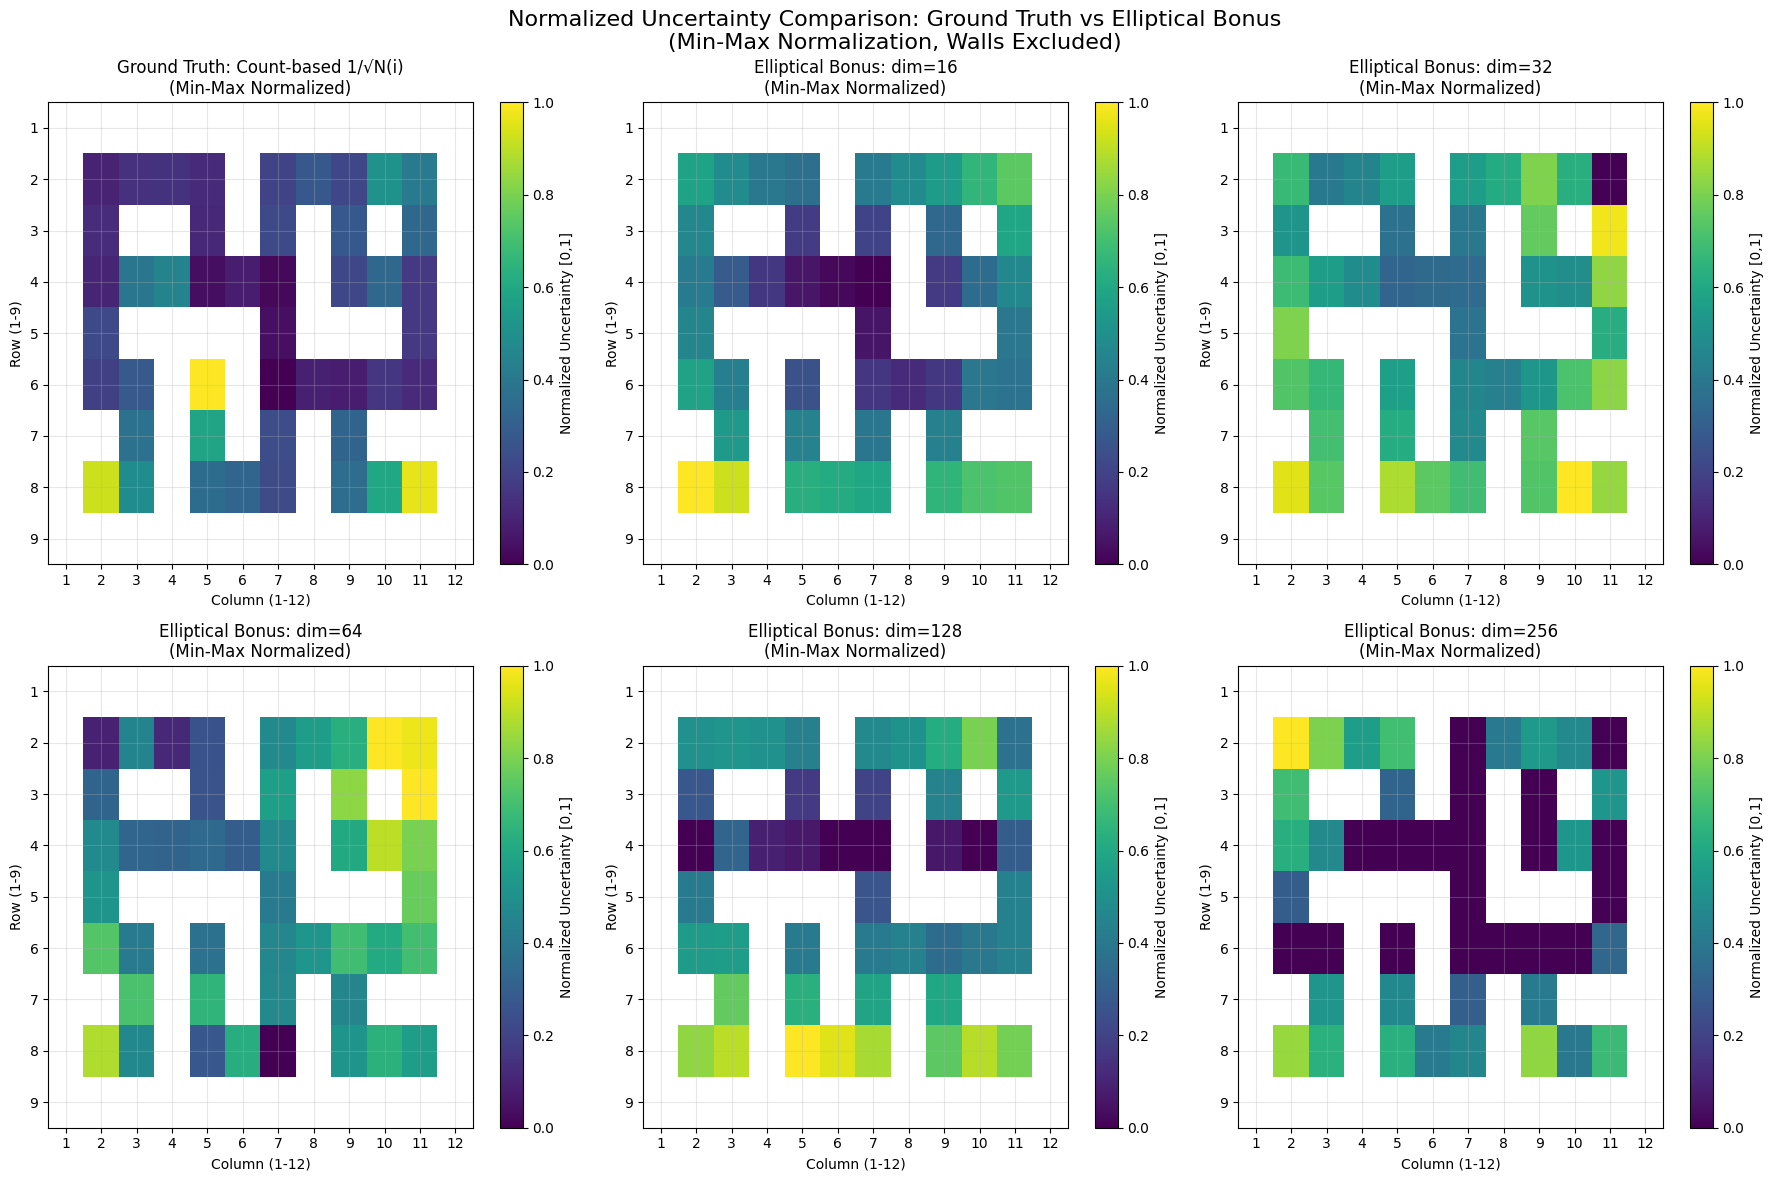

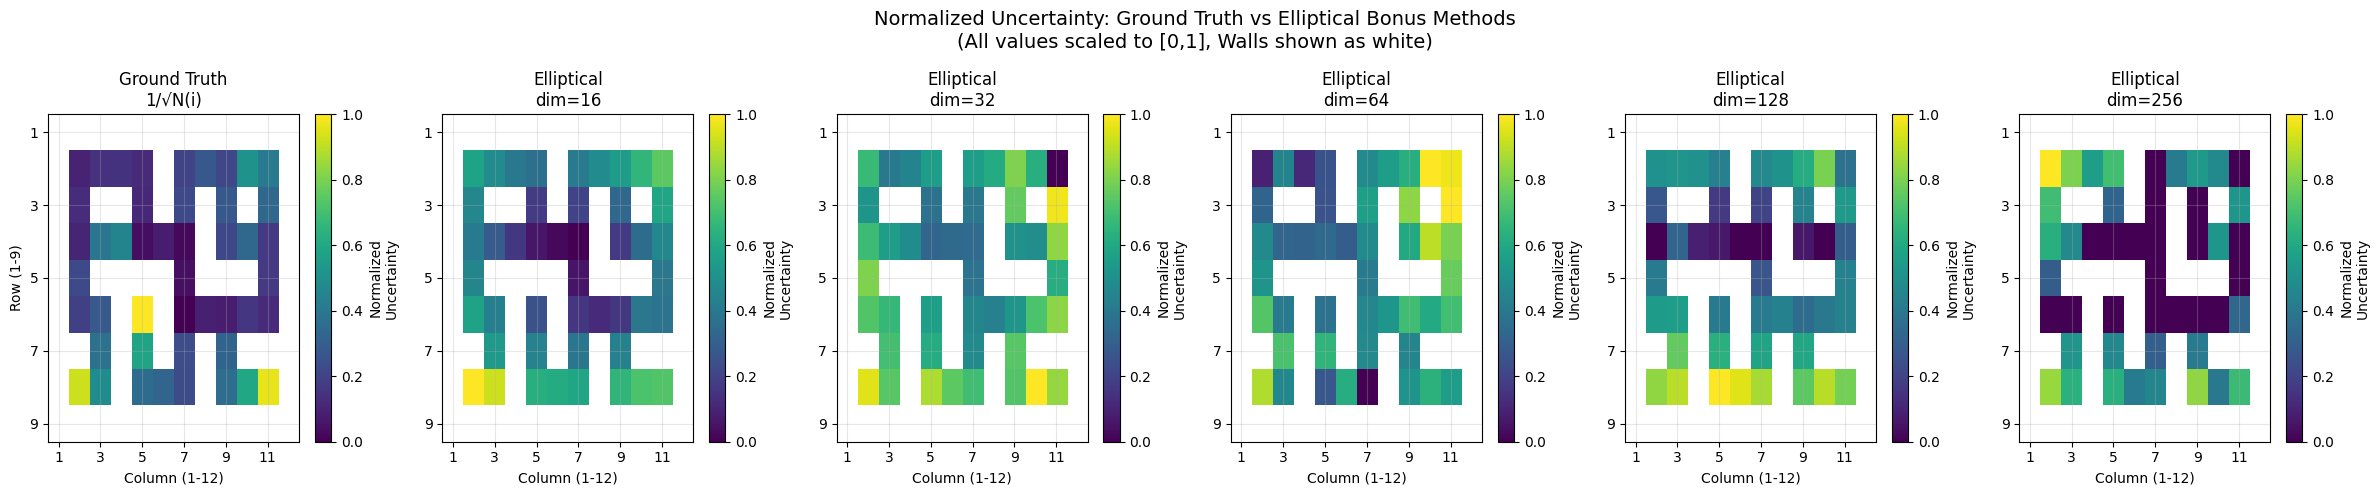

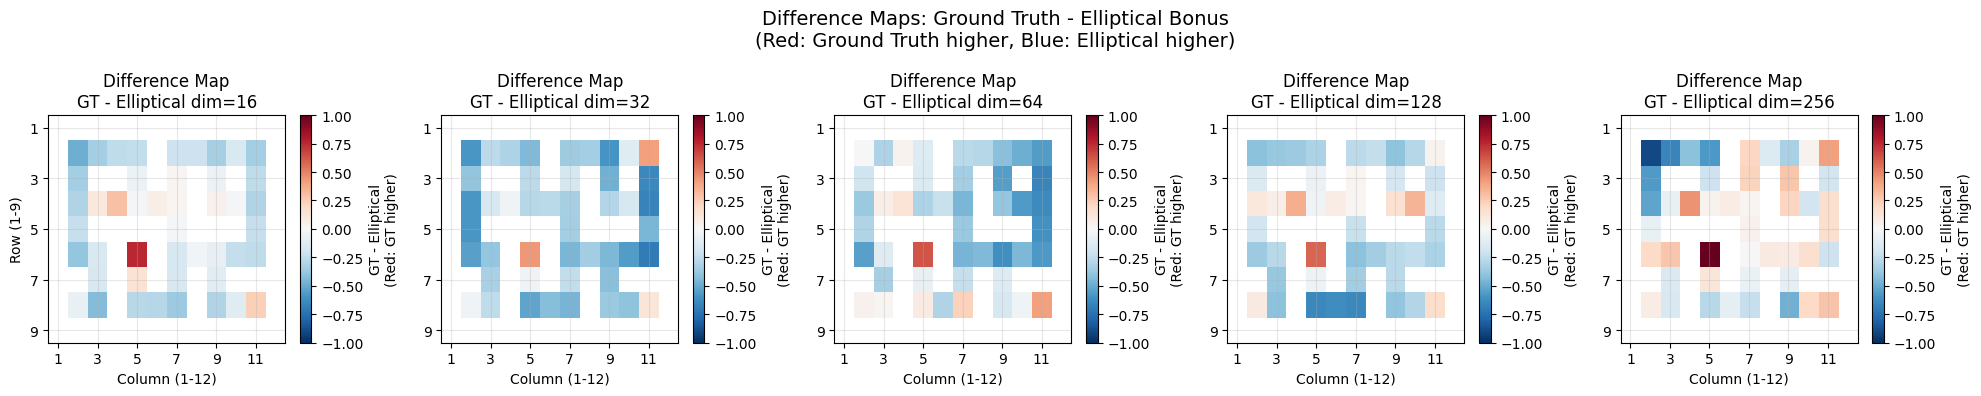


QUANTITATIVE COMPARISON ANALYSIS
Correlations with Ground Truth (normalized, open cells only):
  Elliptical dim= 16: r = 0.5531
  Elliptical dim= 32: r = 0.3811
  Elliptical dim= 64: r = 0.2646
  Elliptical dim=128: r = 0.4792
  Elliptical dim=256: r = 0.2688

Mean Absolute Error (MAE) with Ground Truth:
  Elliptical dim= 16: MAE = 0.2099
  Elliptical dim= 32: MAE = 0.3703
  Elliptical dim= 64: MAE = 0.3199
  Elliptical dim=128: MAE = 0.2693
  Elliptical dim=256: MAE = 0.2474


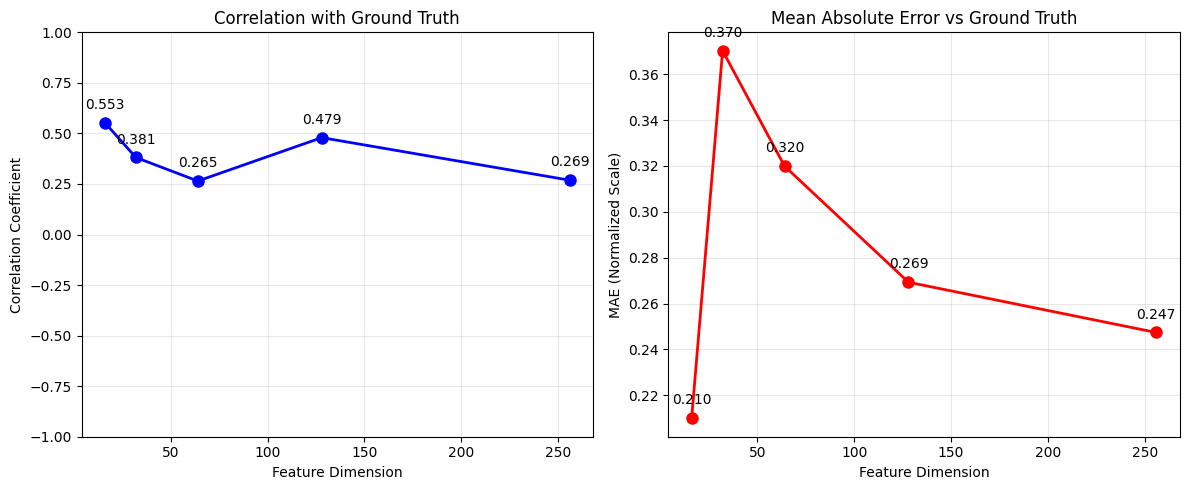


🏆 Best correlation: dim=16 (r=0.5531)
🏆 Lowest MAE: dim=16 (MAE=0.2099)

NORMALIZED COMPARISON COMPLETE!
Key Insights:
• All uncertainties normalized to [0,1] scale for fair comparison
• Higher correlation = better pattern matching with ground truth
• Lower MAE = closer absolute values to ground truth
• Difference maps show where methods agree/disagree
• Red in difference maps = Ground truth assigns higher uncertainty
• Blue in difference maps = Elliptical bonus assigns higher uncertainty


In [ ]:
# NORMALIZED COMPARISON: ELLIPTICAL BONUS vs COUNT-BASED GROUND TRUTH
print("=" * 80)
print("NORMALIZED COMPARISON: ELLIPTICAL BONUS vs COUNT-BASED GROUND TRUTH")
print("=" * 80)

def normalize_min_max(uncertainty_matrix, exclude_walls=True):
    """Apply min-max normalization to uncertainty matrix"""
    if exclude_walls:
        # Create mask for open cells only
        open_mask = np.array([[maze_map[i][j] == 0 for j in range(12)] for i in range(9)])
        
        # Get values from open cells only
        open_values = uncertainty_matrix[open_mask]
        finite_values = open_values[np.isfinite(open_values)]
        
        if len(finite_values) > 0:
            min_val = np.min(finite_values)
            max_val = np.max(finite_values)
            
            # Normalize the entire matrix
            normalized = (uncertainty_matrix - min_val) / (max_val - min_val) if max_val > min_val else uncertainty_matrix
            
            # Set wall cells to NaN for proper visualization
            normalized_masked = normalized.copy()
            normalized_masked[~open_mask] = np.nan
            
            return normalized_masked
        else:
            return uncertainty_matrix
    else:
        finite_mask = np.isfinite(uncertainty_matrix)
        if np.any(finite_mask):
            min_val = np.min(uncertainty_matrix[finite_mask])
            max_val = np.max(uncertainty_matrix[finite_mask])
            return (uncertainty_matrix - min_val) / (max_val - min_val) if max_val > min_val else uncertainty_matrix
        return uncertainty_matrix

# Prepare ground truth (handle infinite values first)
ground_truth = uncertainty_9x12.copy()
finite_mask = np.isfinite(ground_truth)
if np.any(~finite_mask):
    max_finite = np.max(ground_truth[finite_mask])
    ground_truth[~finite_mask] = max_finite * 2

# Normalize all uncertainty matrices
print("Normalizing uncertainty matrices...")
normalized_ground_truth = normalize_min_max(ground_truth)

normalized_elliptical = {}
if 'elliptical_uncertainties' in globals():
    for feature_dim in feature_dims_elliptical:
        if feature_dim in elliptical_uncertainties:
            normalized_elliptical[feature_dim] = normalize_min_max(elliptical_uncertainties[feature_dim])
            print(f"✓ Normalized Elliptical Bonus dim={feature_dim}")

# CREATE COMPREHENSIVE COMPARISON PLOT
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Normalized Ground Truth
ax1 = axes[0, 0]
im1 = ax1.imshow(normalized_ground_truth, cmap='viridis', aspect='auto', vmin=0, vmax=1)
ax1.set_title('Ground Truth: Count-based 1/√N(i)\n(Min-Max Normalized)')
ax1.set_xlabel('Column (1-12)')
ax1.set_ylabel('Row (1-9)')
ax1.set_xticks(range(12))
ax1.set_yticks(range(9))
ax1.set_xticklabels(range(1, 13))
ax1.set_yticklabels(range(1, 10))
ax1.grid(True, alpha=0.3)
plt.colorbar(im1, ax=ax1, label='Normalized Uncertainty [0,1]')

# Plot 2-6: Normalized Elliptical Bonus models
plot_positions = [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]
for i, feature_dim in enumerate(feature_dims_elliptical):
    if feature_dim in normalized_elliptical:
        ax = axes[plot_positions[i]]
        im = ax.imshow(normalized_elliptical[feature_dim], cmap='viridis', aspect='auto', vmin=0, vmax=1)
        ax.set_title(f'Elliptical Bonus: dim={feature_dim}\n(Min-Max Normalized)')
        ax.set_xlabel('Column (1-12)')
        ax.set_ylabel('Row (1-9)')
        ax.set_xticks(range(12))
        ax.set_yticks(range(9))
        ax.set_xticklabels(range(1, 13))
        ax.set_yticklabels(range(1, 10))
        ax.grid(True, alpha=0.3)
        plt.colorbar(im, ax=ax, label='Normalized Uncertainty [0,1]')

plt.suptitle('Normalized Uncertainty Comparison: Ground Truth vs Elliptical Bonus\n(Min-Max Normalization, Walls Excluded)', fontsize=16)
plt.tight_layout()
plt.show()

# SIDE-BY-SIDE COMPARISON (ALL METHODS)
fig, axes = plt.subplots(1, 6, figsize=(24, 5))

# Plot all normalized methods side by side
titles = ['Ground Truth\n1/√N(i)'] + [f'Elliptical\ndim={dim}' for dim in feature_dims_elliptical]
data = [normalized_ground_truth] + [normalized_elliptical.get(dim, np.full((9,12), np.nan)) for dim in feature_dims_elliptical]

for i, (ax, title, uncertainty_data) in enumerate(zip(axes, titles, data)):
    im = ax.imshow(uncertainty_data, cmap='viridis', aspect='auto', vmin=0, vmax=1)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Column (1-12)')
    if i == 0:
        ax.set_ylabel('Row (1-9)')
    ax.set_xticks(range(0, 12, 2))
    ax.set_yticks(range(0, 9, 2))
    ax.set_xticklabels(range(1, 13, 2))
    ax.set_yticklabels(range(1, 10, 2))
    ax.grid(True, alpha=0.3)
    
    # Add colorbar
    plt.colorbar(im, ax=ax, label='Normalized\nUncertainty')

plt.suptitle('Normalized Uncertainty: Ground Truth vs Elliptical Bonus Methods\n(All values scaled to [0,1], Walls shown as white)', fontsize=14)
plt.tight_layout()
plt.show()

# DIFFERENCE MAPS (Ground Truth - Elliptical Bonus)
if len(normalized_elliptical) > 0:
    fig, axes = plt.subplots(1, len(feature_dims_elliptical), figsize=(20, 4))
    
    for i, feature_dim in enumerate(feature_dims_elliptical):
        if feature_dim in normalized_elliptical:
            ax = axes[i] if len(feature_dims_elliptical) > 1 else axes
            
            # Compute difference: Ground Truth - Elliptical Bonus
            diff_matrix = normalized_ground_truth - normalized_elliptical[feature_dim]
            
            # Plot difference map
            im = ax.imshow(diff_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
            ax.set_title(f'Difference Map\nGT - Elliptical dim={feature_dim}')
            ax.set_xlabel('Column (1-12)')
            if i == 0:
                ax.set_ylabel('Row (1-9)')
            ax.set_xticks(range(0, 12, 2))
            ax.set_yticks(range(0, 9, 2))
            ax.set_xticklabels(range(1, 13, 2))
            ax.set_yticklabels(range(1, 10, 2))
            ax.grid(True, alpha=0.3)
            
            plt.colorbar(im, ax=ax, label='GT - Elliptical\n(Red: GT higher)')
    
    plt.suptitle('Difference Maps: Ground Truth - Elliptical Bonus\n(Red: Ground Truth higher, Blue: Elliptical higher)', fontsize=14)
    plt.tight_layout()
    plt.show()

# QUANTITATIVE ANALYSIS
print("\n" + "="*80)
print("QUANTITATIVE COMPARISON ANALYSIS")
print("="*80)

# Calculate correlations between normalized matrices
open_cells_mask = np.array([[maze_map[i][j] == 0 for j in range(12)] for i in range(9)])
gt_open = normalized_ground_truth[open_cells_mask & np.isfinite(normalized_ground_truth)]

print("Correlations with Ground Truth (normalized, open cells only):")
correlations = {}
for feature_dim in feature_dims_elliptical:
    if feature_dim in normalized_elliptical:
        elliptical_open = normalized_elliptical[feature_dim][open_cells_mask & np.isfinite(normalized_elliptical[feature_dim])]
        
        if len(gt_open) == len(elliptical_open) and len(gt_open) > 1:
            correlation = np.corrcoef(gt_open, elliptical_open)[0, 1]
            correlations[feature_dim] = correlation
            print(f"  Elliptical dim={feature_dim:3d}: r = {correlation:.4f}")

# Calculate mean absolute errors
print(f"\nMean Absolute Error (MAE) with Ground Truth:")
maes = {}
for feature_dim in feature_dims_elliptical:
    if feature_dim in normalized_elliptical:
        # Compute MAE only on open cells where both are finite
        gt_vals = normalized_ground_truth[open_cells_mask]
        elliptical_vals = normalized_elliptical[feature_dim][open_cells_mask]
        
        finite_mask = np.isfinite(gt_vals) & np.isfinite(elliptical_vals)
        if np.any(finite_mask):
            mae = np.mean(np.abs(gt_vals[finite_mask] - elliptical_vals[finite_mask]))
            maes[feature_dim] = mae
            print(f"  Elliptical dim={feature_dim:3d}: MAE = {mae:.4f}")

# Plot correlation and MAE trends
if correlations or maes:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot correlations
    if correlations:
        dims = list(correlations.keys())
        corrs = list(correlations.values())
        ax1.plot(dims, corrs, 'o-', linewidth=2, markersize=8, color='blue')
        ax1.set_title('Correlation with Ground Truth')
        ax1.set_xlabel('Feature Dimension')
        ax1.set_ylabel('Correlation Coefficient')
        ax1.grid(True, alpha=0.3)
        ax1.set_ylim(-1, 1)
        
        # Annotate points
        for dim, corr in zip(dims, corrs):
            ax1.annotate(f'{corr:.3f}', (dim, corr), textcoords="offset points", 
                        xytext=(0,10), ha='center')
    
    # Plot MAEs
    if maes:
        dims = list(maes.keys())
        mae_vals = list(maes.values())
        ax2.plot(dims, mae_vals, 'o-', linewidth=2, markersize=8, color='red')
        ax2.set_title('Mean Absolute Error vs Ground Truth')
        ax2.set_xlabel('Feature Dimension')
        ax2.set_ylabel('MAE (Normalized Scale)')
        ax2.grid(True, alpha=0.3)
        
        # Annotate points
        for dim, mae in zip(dims, mae_vals):
            ax2.annotate(f'{mae:.3f}', (dim, mae), textcoords="offset points", 
                        xytext=(0,10), ha='center')
    
    plt.tight_layout()
    plt.show()

# Find best performing dimension
if correlations:
    best_corr_dim = max(correlations.items(), key=lambda x: x[1])
    print(f"\n🏆 Best correlation: dim={best_corr_dim[0]} (r={best_corr_dim[1]:.4f})")

if maes:
    best_mae_dim = min(maes.items(), key=lambda x: x[1])
    print(f"🏆 Lowest MAE: dim={best_mae_dim[0]} (MAE={best_mae_dim[1]:.4f})")

print("\n" + "="*80)
print("NORMALIZED COMPARISON COMPLETE!")
print("="*80)
print("Key Insights:")
print("• All uncertainties normalized to [0,1] scale for fair comparison")
print("• Higher correlation = better pattern matching with ground truth")
print("• Lower MAE = closer absolute values to ground truth")
print("• Difference maps show where methods agree/disagree")
print("• Red in difference maps = Ground truth assigns higher uncertainty")
print("• Blue in difference maps = Elliptical bonus assigns higher uncertainty")

### Save Data for Future Use

In [ ]:
# SAVE ALL COMPUTED DATA
print("=" * 80)
print("SAVING ALL COMPUTED DATA")
print("=" * 80)

import pickle
import os

# Create data directory if it doesn't exist
data_dir = '/p/rlprojects/RND/saved_data'
os.makedirs(data_dir, exist_ok=True)

# Dictionary containing all important data
saved_data = {
    # Environment info
    'maze_map': maze_map,
    'left_edge': left_edge,
    'right_edge': right_edge,
    'bottom_edge': bottom_edge,
    'top_edge': top_edge,
    'total_width': total_width,
    'total_height': total_height,
    
    # Visit counts for all resolutions
    'visit_counts_9x12': visit_counts_9x12,
    'visit_counts_18x24': visit_counts_18x24,
    'visit_counts_27x36': visit_counts_27x36,
    
    # Count-based uncertainties
    'uncertainty_9x12': uncertainty_9x12,
    'uncertainty_18x24': uncertainty_18x24,
    'uncertainty_27x36': uncertainty_27x36,
    
    # RND uncertainty
    'rnd_uncertainty_9x12': rnd_uncertainty_9x12,
    
    # Statistics
    'total_episodes': dataset.total_episodes,
    'total_steps': dataset.total_steps,
}

# Save to pickle file
save_path = os.path.join(data_dir, 'pointmaze_uncertainty_data.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(saved_data, f)

print(f"✓ Data saved to: {save_path}")
print(f"✓ File size: {os.path.getsize(save_path) / 1024 / 1024:.2f} MB")

# Also save RND model
rnd_save_path = os.path.join(data_dir, 'rnd_model.pkl')
rnd_model_data = {
    'target_network_state': rnd_model.target_network.state_dict(),
    'predictor_network_state': rnd_model.predictor_network.state_dict(),
    'obs_mean': rnd_model.obs_mean,
    'obs_std': rnd_model.obs_std,
    'training_losses': training_losses
}

with open(rnd_save_path, 'wb') as f:
    pickle.dump(rnd_model_data, f)

print(f"✓ RND model saved to: {rnd_save_path}")

# Create a summary file for easy reference
summary_path = os.path.join(data_dir, 'data_summary.txt')
with open(summary_path, 'w') as f:
    f.write("POINTMAZE UNCERTAINTY DATA SUMMARY\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"Dataset: D4RL/pointmaze/large-v2\n")
    f.write(f"Total episodes: {dataset.total_episodes}\n")
    f.write(f"Total steps: {dataset.total_steps}\n\n")
    
    f.write("RESOLUTIONS:\n")
    f.write(f"- 9×12:  {visit_counts_9x12.sum():,} visits, {np.sum(visit_counts_9x12 > 0)}/108 cells visited\n")
    f.write(f"- 18×24: {visit_counts_18x24.sum():,} visits, {np.sum(visit_counts_18x24 > 0)}/432 cells visited\n")
    f.write(f"- 27×36: {visit_counts_27x36.sum():,} visits, {np.sum(visit_counts_27x36 > 0)}/972 cells visited\n\n")
    
    f.write("FILES SAVED:\n")
    f.write("- pointmaze_uncertainty_data.pkl: All visit counts and uncertainties\n")
    f.write("- rnd_model.pkl: Trained RND model\n")
    f.write("- data_summary.txt: This summary\n")

print(f"✓ Summary saved to: {summary_path}")
print("\n" + "="*80)
print("DATA SAVING COMPLETE!")
print("="*80)

SAVING ALL COMPUTED DATA
✓ Data saved to: /p/rlprojects/RND/saved_data/pointmaze_uncertainty_data.pkl
✓ File size: 0.02 MB
✓ RND model saved to: /p/rlprojects/RND/saved_data/rnd_model.pkl
✓ Summary saved to: /p/rlprojects/RND/saved_data/data_summary.txt

DATA SAVING COMPLETE!


### Load Saved Data

In [ ]:
# QUICK CHECK - Try to load existing saved data
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

data_dir = '/p/rlprojects/RND/saved_data'
save_path = os.path.join(data_dir, 'pointmaze_uncertainty_data.pkl')

if os.path.exists(save_path):
    print("✓ Found existing saved data! Loading...")
    
    with open(save_path, 'rb') as f:
        saved_data = pickle.load(f)
    
    # Restore all variables
    maze_map = saved_data['maze_map']
    left_edge = saved_data['left_edge']
    right_edge = saved_data['right_edge'] 
    bottom_edge = saved_data['bottom_edge']
    top_edge = saved_data['top_edge']
    total_width = saved_data['total_width']
    total_height = saved_data['total_height']
    
    visit_counts_9x12 = saved_data['visit_counts_9x12']
    visit_counts_18x24 = saved_data['visit_counts_18x24']
    visit_counts_27x36 = saved_data['visit_counts_27x36']
    
    uncertainty_9x12 = saved_data['uncertainty_9x12']
    uncertainty_18x24 = saved_data['uncertainty_18x24']
    uncertainty_27x36 = saved_data['uncertainty_27x36']
    
    if 'rnd_uncertainty_9x12' in saved_data:
        rnd_uncertainty_9x12 = saved_data['rnd_uncertainty_9x12']
        print("✓ RND uncertainty data found!")
    else:
        print("⚠ RND uncertainty not found in saved data")
    
    print(f"✓ All data loaded successfully!")
    print(f"✓ Ready to create plots without reprocessing dataset")
    
else:
    print("❌ No saved data found. You'll need to run the full analysis.")
    print(f"Expected file: {save_path}")

✓ Found existing saved data! Loading...
✓ RND uncertainty data found!
✓ All data loaded successfully!
✓ Ready to create plots without reprocessing dataset


### One hot Feature as Sanity Check

In [ ]:
# ONE-HOT FEATURE IMPLEMENTATION FOR RND-LINEAR AND ELLIPTICAL BONUS
print("=" * 80)
print("ONE-HOT FEATURE IMPLEMENTATION")
print("=" * 80)

import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm

class OneHotRNDLinear:
    """
    RND-Linear with one-hot grid features φ(s)
    
    For 9×12 grid:
    - φ(s) is 108-dimensional one-hot vector indicating which grid cell (x,y) belongs to
    - Target: f_θ(s) = ⟨φ(s), θ⟩ where θ is random fixed 108-dim vector
    - Predictor: f_θ̂(s) = ⟨φ(s), θ̂⟩ where θ̂ is learned 108-dim vector
    """
    
    def __init__(self, grid_rows=9, grid_cols=12, device='cpu'):
        self.device = device
        self.grid_rows = grid_rows
        self.grid_cols = grid_cols
        self.feature_dim = grid_rows * grid_cols  # 108 for 9×12
        
        # Target vector θ: random fixed vector
        self.theta_target = torch.randn(self.feature_dim, device=device)
        
        # Predictor vector θ̂: learnable vector
        self.theta_predictor = nn.Parameter(torch.randn(self.feature_dim, device=device))
        
        # Optimizer for predictor vector only
        self.optimizer = torch.optim.Adam([self.theta_predictor], lr=1e-3)
        
        print("One-Hot RND-Linear initialized:")
        print(f"  Grid: {grid_rows}×{grid_cols} = {self.feature_dim} cells")
        print(f"  φ(s): One-hot {self.feature_dim}-dimensional vector")
        print(f"  θ (target): {self.feature_dim}-dim random fixed vector")
        print(f"  θ̂ (predictor): {self.feature_dim}-dim learnable vector")
    
    def observation_to_onehot(self, observations):
        """Convert (x,y) observations to one-hot grid features"""
        batch_size = observations.shape[0]
        onehot_features = torch.zeros(batch_size, self.feature_dim, device=self.device)
        
        for i, obs in enumerate(observations):
            x, y = obs[0].item(), obs[1].item()
            
            # Map to grid cell using existing function
            _, (row, col) = observation_to_grid({'achieved_goal': [x, y]}, 
                                              self.grid_rows, self.grid_cols)
            
            # Convert to linear index (0-based)
            linear_idx = (row - 1) * self.grid_cols + (col - 1)
            linear_idx = max(0, min(linear_idx, self.feature_dim - 1))
            
            # Set one-hot
            onehot_features[i, linear_idx] = 1.0
        
        return onehot_features
    
    def compute_target_output(self, observations):
        """Compute target f_θ(s) = ⟨φ(s), θ⟩"""
        onehot_features = self.observation_to_onehot(observations)
        return torch.sum(onehot_features * self.theta_target, dim=1)
    
    def compute_predictor_output(self, observations):
        """Compute predictor f_θ̂(s) = ⟨φ(s), θ̂⟩"""
        onehot_features = self.observation_to_onehot(observations)
        return torch.sum(onehot_features * self.theta_predictor, dim=1)
    
    def compute_uncertainty_abs_diff(self, observations):
        """Compute one-hot RND-Linear uncertainty"""
        with torch.no_grad():
            target_output = self.compute_target_output(observations)
            predictor_output = self.compute_predictor_output(observations)
            uncertainty = torch.abs(target_output - predictor_output)
        return uncertainty
    
    def train_on_dataset(self, num_epochs=50):
        """Train predictor θ̂ to match target θ on dataset observations"""
        print("Loading dataset for one-hot RND-Linear training...")
        
        # Extract all positions
        positions = []
        for episode in tqdm(dataset.iterate_episodes(), desc="Loading data"):
            observations = episode.observations
            if isinstance(observations, dict) and 'achieved_goal' in observations:
                positions.extend(observations['achieved_goal'])
        
        positions = torch.tensor(positions, dtype=torch.float32).to(self.device)
        print(f"Training on {len(positions)} observations with one-hot features")
        
        # Training loop
        losses = []
        
        for epoch in tqdm(range(num_epochs), desc="One-Hot RND-Linear Training"):
            indices = torch.randperm(len(positions))
            epoch_loss = 0
            batch_size = 512
            
            for i in range(0, len(positions), batch_size):
                batch_idx = indices[i:i+batch_size]
                batch_obs = positions[batch_idx]
                
                # Compute outputs
                target_output = self.compute_target_output(batch_obs).detach()
                predictor_output = self.compute_predictor_output(batch_obs)
                
                # MSE loss
                loss = nn.functional.mse_loss(predictor_output, target_output)
                
                # Backprop
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                
                epoch_loss += loss.item()
            
            avg_loss = epoch_loss / (len(positions) // batch_size + 1)
            losses.append(avg_loss)
            
            if epoch % 10 == 0:
                print(f"Epoch {epoch}: Loss = {avg_loss:.6f}")
        
        print("One-hot RND-Linear training complete!")
        return losses


class OneHotEllipticalBonus:
    """
    Elliptical Bonus with one-hot grid features φ(s)
    
    For 9×12 grid:
    - φ(s) is 108-dimensional one-hot vector
    - Λ is 108×108 covariance matrix
    - Intrinsic reward: i_t = [φ(s)ᵀ Λ⁻¹ φ(s)]^(1/2)
    """
    
    def __init__(self, grid_rows=9, grid_cols=12, regularization=1e-6, device='cpu'):
        self.device = device
        self.grid_rows = grid_rows
        self.grid_cols = grid_cols
        self.feature_dim = grid_rows * grid_cols  # 108 for 9×12
        self.regularization = regularization
        
        # Initialize covariance matrix Λ
        self.Lambda = torch.eye(self.feature_dim, device=device) * regularization
        self.Lambda_inv = torch.eye(self.feature_dim, device=device) / regularization
        
        print("One-Hot Elliptical Bonus initialized:")
        print(f"  Grid: {grid_rows}×{grid_cols} = {self.feature_dim} cells")
        print(f"  φ(s): One-hot {self.feature_dim}-dimensional vector")
        print(f"  Λ: {self.feature_dim}×{self.feature_dim} covariance matrix")
        print(f"  Regularization: {regularization}")
    
    def observation_to_onehot(self, observations):
        """Convert (x,y) observations to one-hot grid features"""
        batch_size = observations.shape[0]
        onehot_features = torch.zeros(batch_size, self.feature_dim, device=self.device)
        
        for i, obs in enumerate(observations):
            x, y = obs[0].item(), obs[1].item()
            
            # Map to grid cell
            _, (row, col) = observation_to_grid({'achieved_goal': [x, y]}, 
                                              self.grid_rows, self.grid_cols)
            
            # Convert to linear index (0-based)
            linear_idx = (row - 1) * self.grid_cols + (col - 1)
            linear_idx = max(0, min(linear_idx, self.feature_dim - 1))
            
            # Set one-hot
            onehot_features[i, linear_idx] = 1.0
        
        return onehot_features
    
    def update_covariance_matrix(self, observations):
        """Update covariance matrix Λ from one-hot features"""
        print("Computing one-hot features and updating covariance matrix...")
        
        # Get all one-hot features
        features_list = []
        batch_size = 1000
        
        for i in tqdm(range(0, len(observations), batch_size), desc="Computing one-hot features"):
            batch_obs = observations[i:i+batch_size]
            batch_features = self.observation_to_onehot(batch_obs)
            features_list.append(batch_features)
        
        # Concatenate all features
        all_features = torch.cat(features_list, dim=0)  # [n_samples, feature_dim]
        n_samples = all_features.shape[0]
        
        print(f"Computing covariance from {n_samples} one-hot samples...")
        
        # For one-hot features, covariance is just visit frequency matrix
        # Λ_ij = (1/n) * sum(φ_i(s) * φ_j(s)) = (1/n) * count_visits_to_cell_i if i==j, 0 if i!=j
        
        # Compute empirical covariance
        visit_counts = torch.sum(all_features, dim=0)  # [feature_dim] - visits per cell
        
        # For one-hot features, off-diagonal elements are 0, diagonal = visit_frequency
        self.Lambda = torch.diag(visit_counts / n_samples + self.regularization)
        
        # Compute inverse
        try:
            self.Lambda_inv = torch.inverse(self.Lambda)
            print("✓ One-hot covariance matrix inverted successfully")
        except:
            print("⚠ Matrix inversion failed, using pseudo-inverse")
            self.Lambda_inv = torch.pinverse(self.Lambda)
        
        # Condition number check
        eigenvals = torch.diag(self.Lambda)
        condition_number = torch.max(eigenvals) / torch.min(eigenvals)
        print(f"One-hot covariance matrix condition number: {condition_number:.2e}")
        
        return self.Lambda, self.Lambda_inv
    
    def compute_intrinsic_reward(self, observations):
        """Compute one-hot elliptical bonus: i_t = [φ(s)ᵀ Λ⁻¹ φ(s)]^(1/2)"""
        with torch.no_grad():
            # Get one-hot features φ(s)
            onehot_features = self.observation_to_onehot(observations)  # [batch_size, feature_dim]
            
            # For one-hot φ(s) and diagonal Λ⁻¹:
            # φ(s)ᵀ Λ⁻¹ φ(s) = Λ⁻¹[cell_index] where cell_index is the active cell
            temp = torch.matmul(onehot_features, self.Lambda_inv)  # [batch_size, feature_dim]
            quadratic_form = torch.sum(temp * onehot_features, dim=1)  # [batch_size]
            
            # Take square root for final intrinsic reward
            intrinsic_reward = torch.sqrt(torch.clamp(quadratic_form, min=1e-8))
            
        return intrinsic_reward
    
    def fit_on_dataset(self):
        """Fit one-hot elliptical bonus on dataset"""
        print("Loading dataset for one-hot elliptical bonus...")
        
        # Extract all positions
        positions = []
        for episode in tqdm(dataset.iterate_episodes(), desc="Loading data"):
            observations = episode.observations
            if isinstance(observations, dict) and 'achieved_goal' in observations:
                positions.extend(observations['achieved_goal'])
        
        positions = torch.tensor(positions, dtype=torch.float32).to(self.device)
        print(f"Loaded {len(positions)} observations for one-hot processing")
        
        # Update covariance matrix
        self.update_covariance_matrix(positions)
        
        print("✓ One-hot elliptical bonus fitting complete!")
        return positions


# TRAIN ONE-HOT MODELS
print("\n" + "="*60)
print("TRAINING ONE-HOT MODELS")
print("="*60)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Train one-hot RND-Linear
print("\n" + "-"*50)
print("ONE-HOT RND-LINEAR")
print("-"*50)

onehot_rnd_linear = OneHotRNDLinear(grid_rows=9, grid_cols=12, device=device)
onehot_rnd_losses = onehot_rnd_linear.train_on_dataset(num_epochs=15)

# Train one-hot Elliptical Bonus
print("\n" + "-"*50)
print("ONE-HOT ELLIPTICAL BONUS")
print("-"*50)

onehot_elliptical = OneHotEllipticalBonus(grid_rows=9, grid_cols=12, device=device)
onehot_elliptical_positions = onehot_elliptical.fit_on_dataset()

print("\n✓ One-hot models trained!")

ONE-HOT FEATURE IMPLEMENTATION

TRAINING ONE-HOT MODELS
Using device: cpu

--------------------------------------------------
ONE-HOT RND-LINEAR
--------------------------------------------------
One-Hot RND-Linear initialized:
  Grid: 9×12 = 108 cells
  φ(s): One-hot 108-dimensional vector
  θ (target): 108-dim random fixed vector
  θ̂ (predictor): 108-dim learnable vector
Loading dataset for one-hot RND-Linear training...


Loading data: 3360it [00:08, 376.48it/s]
Loading data: 3360it [00:08, 376.48it/s]


Training on 1003360 observations with one-hot features


One-Hot RND-Linear Training:   7%|▋         | 1/15 [00:40<09:25, 40.42s/it]

Epoch 0: Loss = 0.701269


...

One-hot RND-Linear training complete!

--------------------------------------------------
ONE-HOT ELLIPTICAL BONUS
--------------------------------------------------
One-Hot Elliptical Bonus initialized:
  Grid: 9×12 = 108 cells
  φ(s): One-hot 108-dimensional vector
  Λ: 108×108 covariance matrix
  Regularization: 1e-06
Loading dataset for one-hot elliptical bonus...


Loading data: 3360it [00:09, 369.47it/s]
Loading data: 3360it [00:09, 369.47it/s]


Loaded 1003360 observations for one-hot processing
Computing one-hot features and updating covariance matrix...


Computing one-hot features: 100%|██████████| 1004/1004 [00:25<00:00, 39.33it/s]



Computing covariance from 1003360 one-hot samples...
✓ One-hot covariance matrix inverted successfully
One-hot covariance matrix condition number: 6.68e+04
✓ One-hot elliptical bonus fitting complete!

✓ One-hot models trained!
✓ One-hot covariance matrix inverted successfully
One-hot covariance matrix condition number: 6.68e+04
✓ One-hot elliptical bonus fitting complete!

✓ One-hot models trained!


Compute the resulting uncertainties and L2 norm without walls

In [ ]:
# COMPUTE ONE-HOT UNCERTAINTIES
print("=" * 80)
print("COMPUTING ONE-HOT UNCERTAINTIES")
print("=" * 80)

# Compute uncertainty for one-hot RND-Linear
print("Computing one-hot RND-Linear uncertainties...")
onehot_rnd_uncertainty = np.zeros((9, 12), dtype=float)

for row in tqdm(range(1, 10), desc="One-hot RND-Linear"):
    for col in range(1, 13):
        # Get center coordinates
        center_x, center_y = grid_to_center_observation(row, col)
        obs_tensor = torch.tensor([[center_x, center_y]], dtype=torch.float32).to(device)
        
        # Compute uncertainty
        uncertainty = onehot_rnd_linear.compute_uncertainty_abs_diff(obs_tensor).item()
        onehot_rnd_uncertainty[row-1, col-1] = uncertainty

# Compute uncertainty for one-hot Elliptical Bonus
print("Computing one-hot Elliptical Bonus uncertainties...")
onehot_elliptical_uncertainty = np.zeros((9, 12), dtype=float)

for row in tqdm(range(1, 10), desc="One-hot Elliptical"):
    for col in range(1, 13):
        # Get center coordinates
        center_x, center_y = grid_to_center_observation(row, col)
        obs_tensor = torch.tensor([[center_x, center_y]], dtype=torch.float32).to(device)
        
        # Compute intrinsic reward
        intrinsic_reward = onehot_elliptical.compute_intrinsic_reward(obs_tensor).item()
        onehot_elliptical_uncertainty[row-1, col-1] = intrinsic_reward

print("✓ One-hot uncertainties computed!")

# COMPUTE L2 NORM COMPARISONS (EXCLUDING WALLS)
print("\n" + "="*80)
print("L2 NORM COMPARISON WITH GROUND TRUTH (EXCLUDING WALLS)")
print("="*80)

# Ground truth matrix (handle infinite values)
M_gt = uncertainty_9x12.copy()
finite_mask = np.isfinite(M_gt)
if np.any(~finite_mask):
    max_finite = np.max(M_gt[finite_mask])
    M_gt[~finite_mask] = max_finite * 2

# Create mask for open cells only
open_cells_mask = np.array([[maze_map[i][j] == 0 for j in range(12)] for i in range(9)])

# Extract vectors from open cells only
def extract_open_cell_vector(uncertainty_matrix):
    """Extract 1D vector of uncertainty values from open cells only"""
    return uncertainty_matrix[open_cells_mask]

# Ground truth vector (open cells only)
gt_vector = extract_open_cell_vector(M_gt)
print(f"Ground truth vector length: {len(gt_vector)} (open cells only)")

# Collect all methods for comparison
l2_methods = {}

# Add existing methods if available
if 'rnd_uncertainty_9x12' in globals():
    l2_methods['Original RND'] = extract_open_cell_vector(rnd_uncertainty_9x12)

if 'corrected_uncertainties' in globals():
    for noise_std in [0.05, 0.1, 0.2]:
        if noise_std in corrected_uncertainties:
            l2_methods[f'RND σ={noise_std}'] = extract_open_cell_vector(corrected_uncertainties[noise_std])

if 'rnd_linear_uncertainties' in globals():
    for dim in [16, 32, 64, 128, 256]:
        if dim in rnd_linear_uncertainties:
            l2_methods[f'RND-Linear dim={dim}'] = extract_open_cell_vector(rnd_linear_uncertainties[dim])

if 'elliptical_uncertainties' in globals():
    for dim in [16, 32, 64, 128, 256]:
        if dim in elliptical_uncertainties:
            l2_methods[f'Elliptical dim={dim}'] = extract_open_cell_vector(elliptical_uncertainties[dim])

# Add new one-hot methods
l2_methods['One-Hot RND-Linear'] = extract_open_cell_vector(onehot_rnd_uncertainty)
l2_methods['One-Hot Elliptical'] = extract_open_cell_vector(onehot_elliptical_uncertainty)

# Compute L2 norms
print("L2 norm distances ||gt_vector - method_vector||₂ (open cells only):")
print("-" * 80)

l2_distances = {}
for method_name, method_vector in l2_methods.items():
    if len(method_vector) == len(gt_vector):
        l2_distance = np.linalg.norm(gt_vector - method_vector)
        l2_distances[method_name] = l2_distance
        print(f"{method_name:<30}: {l2_distance:.6f}")
    else:
        print(f"{method_name:<30}: ❌ Vector length mismatch")

# Rank methods by L2 performance
print(f"\n" + "="*80)
print("RANKING BY L2 DISTANCE (lower = better approximation):")
print("="*80)

sorted_l2_methods = sorted(l2_distances.items(), key=lambda x: x[1])
for rank, (method, distance) in enumerate(sorted_l2_methods, 1):
    print(f"{rank:2d}. {method:<30}: {distance:.6f}")

# Highlight one-hot methods
print(f"\n" + "="*80)
print("ONE-HOT METHOD PERFORMANCE:")
print("="*80)

onehot_methods = {k: v for k, v in l2_distances.items() if 'One-Hot' in k}
for method, distance in onehot_methods.items():
    rank = next(i for i, (m, _) in enumerate(sorted_l2_methods, 1) if m == method)
    print(f"🔥 {method}: L2={distance:.6f} (Rank: {rank}/{len(sorted_l2_methods)})")

# Statistical analysis
if len(l2_distances) > 1:
    distances = list(l2_distances.values())
    print(f"\nL2 Distance Statistics:")
    print(f"  Best (min):    {min(distances):.6f}")
    print(f"  Worst (max):   {max(distances):.6f}")
    print(f"  Mean:          {np.mean(distances):.6f}")
    print(f"  Std deviation: {np.std(distances):.6f}")
    print(f"  Range:         {max(distances) - min(distances):.6f}")

COMPUTING ONE-HOT UNCERTAINTIES
Computing one-hot RND-Linear uncertainties...


One-hot RND-Linear: 100%|██████████| 9/9 [00:00<00:00, 440.58it/s]


Computing one-hot Elliptical Bonus uncertainties...


One-hot Elliptical: 100%|██████████| 9/9 [00:00<00:00, 192.52it/s]

✓ One-hot uncertainties computed!

L2 NORM COMPARISON WITH GROUND TRUTH (EXCLUDING WALLS)
Ground truth vector length: 46 (open cells only)
L2 norm distances ||gt_vector - method_vector||₂ (open cells only):
--------------------------------------------------------------------------------
Original RND                  : 0.054701
One-Hot RND-Linear            : 0.061041
One-Hot Elliptical            : 61.077560

RANKING BY L2 DISTANCE (lower = better approximation):
 1. Original RND                  : 0.054701
 2. One-Hot RND-Linear            : 0.061041
 3. One-Hot Elliptical            : 61.077560

ONE-HOT METHOD PERFORMANCE:
🔥 One-Hot RND-Linear: L2=0.061041 (Rank: 2/3)
🔥 One-Hot Elliptical: L2=61.077560 (Rank: 3/3)

L2 Distance Statistics:
  Best (min):    0.054701
  Worst (max):   61.077560
  Mean:          20.397767
  Std deviation: 28.764957
  Range:         61.022859



VISUALIZATION: ONE-HOT METHODS vs GROUND TRUTH


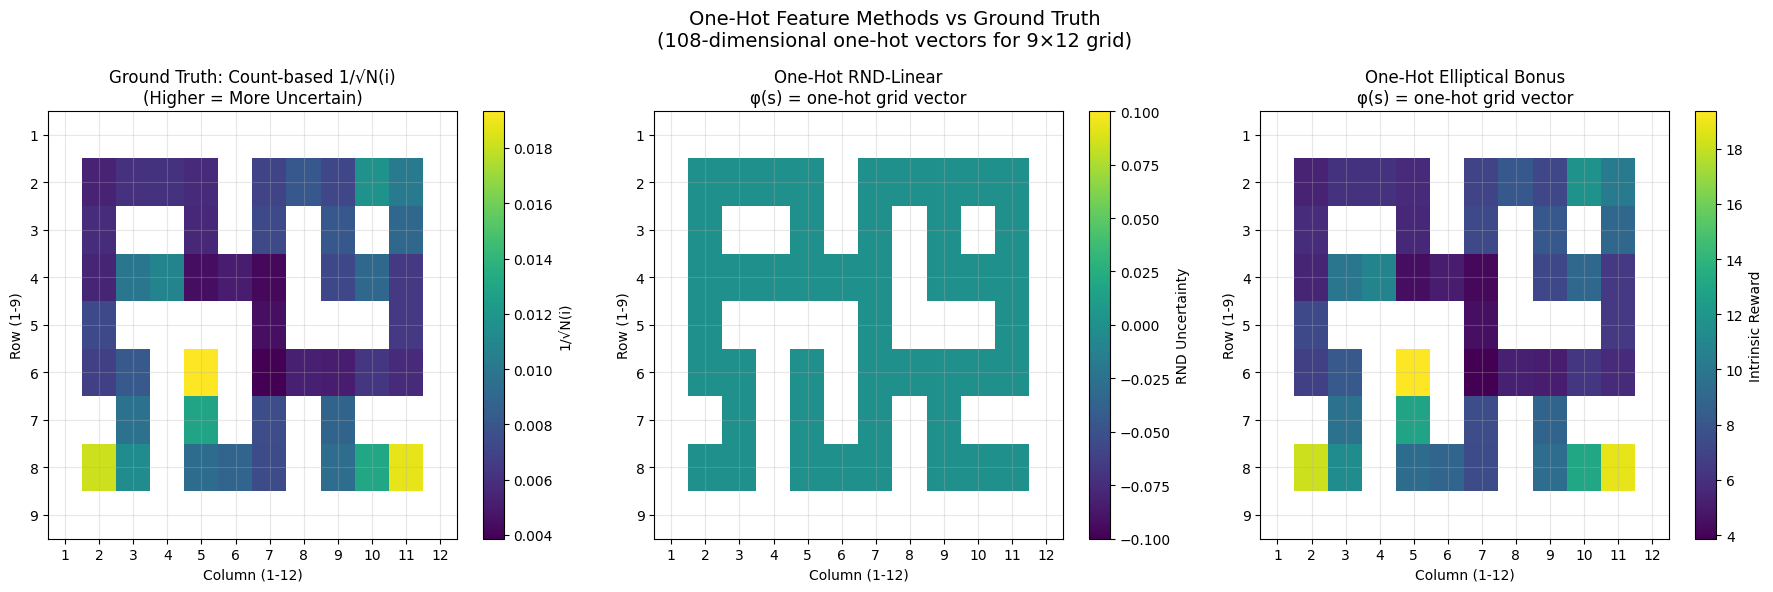

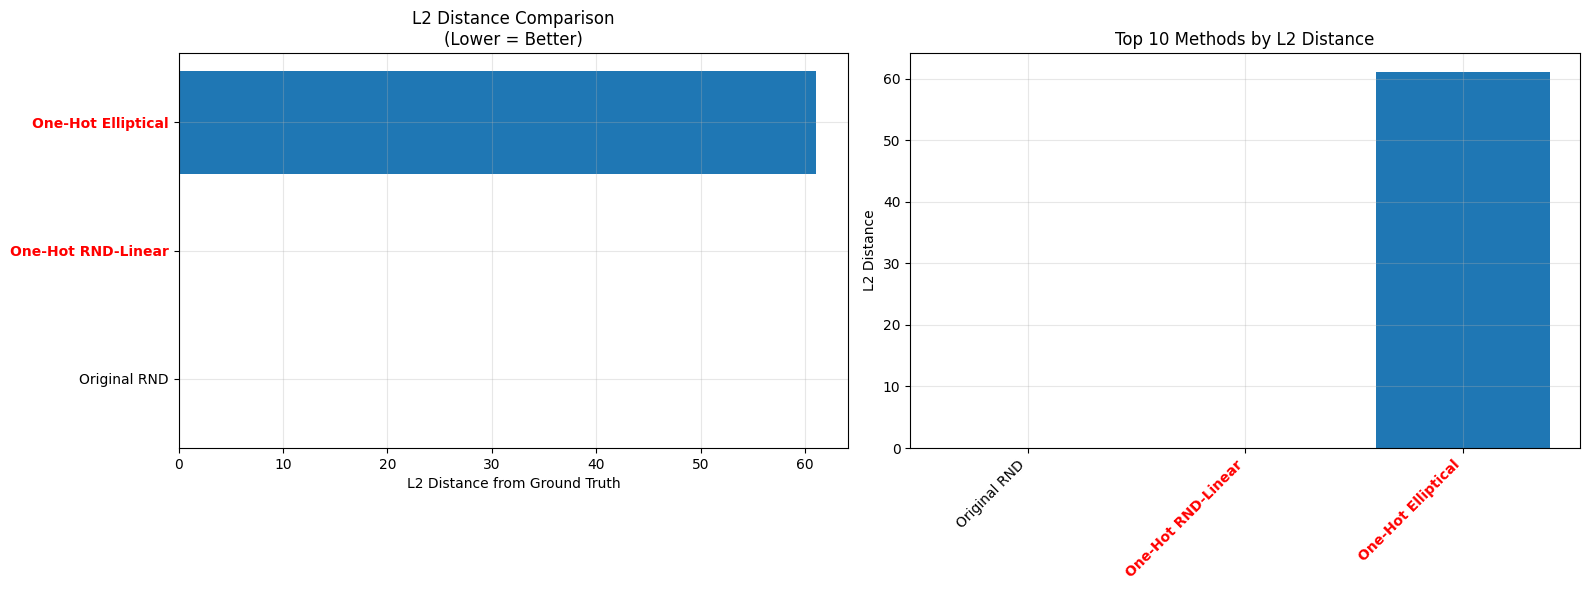


DETAILED ONE-HOT ANALYSIS

One-Hot RND-Linear:
  L2 distance from GT: 0.061041
  Min uncertainty: 0.000000
  Max uncertainty: 0.000000
  Mean uncertainty: 0.000000
  Std uncertainty: 0.000000
  Correlation with GT: nan

One-Hot Elliptical:
  L2 distance from GT: 61.077560
  Min uncertainty: 3.869389
  Max uncertainty: 19.359938
  Mean uncertainty: 8.279903
  Std uncertainty: 3.564060
  Correlation with GT: 1.000000

🏆 BEST OVERALL METHOD: Original RND (L2 = 0.054701)
🔥 One-hot method in TOP 3!

✓ One-hot implementation and L2 comparison complete!


/u/sl5nw/.conda/envs/exploration/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/u/sl5nw/.conda/envs/exploration/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:
# VISUALIZATION: ONE-HOT METHODS COMPARISON
print("\n" + "="*80)
print("VISUALIZATION: ONE-HOT METHODS vs GROUND TRUTH")
print("="*80)

# Function to mask walls
def mask_walls(uncertainty_matrix):
    masked = uncertainty_matrix.copy()
    for r in range(9):
        for c in range(12):
            if maze_map[r][c] == 1:  # Wall
                masked[r, c] = np.nan
    return masked

# Create comparison plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Ground Truth
ax1 = axes[0]
ground_truth_masked = mask_walls(M_gt)
im1 = ax1.imshow(ground_truth_masked, cmap='viridis', aspect='auto')
ax1.set_title('Ground Truth: Count-based 1/√N(i)\n(Higher = More Uncertain)')
ax1.set_xlabel('Column (1-12)')
ax1.set_ylabel('Row (1-9)')
ax1.set_xticks(range(12))
ax1.set_yticks(range(9))
ax1.set_xticklabels(range(1, 13))
ax1.set_yticklabels(range(1, 10))
ax1.grid(True, alpha=0.3)
plt.colorbar(im1, ax=ax1, label='1/√N(i)')

# Plot 2: One-Hot RND-Linear
ax2 = axes[1]
onehot_rnd_masked = mask_walls(onehot_rnd_uncertainty)
im2 = ax2.imshow(onehot_rnd_masked, cmap='viridis', aspect='auto')
ax2.set_title('One-Hot RND-Linear\nφ(s) = one-hot grid vector')
ax2.set_xlabel('Column (1-12)')
ax2.set_ylabel('Row (1-9)')
ax2.set_xticks(range(12))
ax2.set_yticks(range(9))
ax2.set_xticklabels(range(1, 13))
ax2.set_yticklabels(range(1, 10))
ax2.grid(True, alpha=0.3)
plt.colorbar(im2, ax=ax2, label='RND Uncertainty')

# Plot 3: One-Hot Elliptical Bonus
ax3 = axes[2]
onehot_elliptical_masked = mask_walls(onehot_elliptical_uncertainty)
im3 = ax3.imshow(onehot_elliptical_masked, cmap='viridis', aspect='auto')
ax3.set_title('One-Hot Elliptical Bonus\nφ(s) = one-hot grid vector')
ax3.set_xlabel('Column (1-12)')
ax3.set_ylabel('Row (1-9)')
ax3.set_xticks(range(12))
ax3.set_yticks(range(9))
ax3.set_xticklabels(range(1, 13))
ax3.set_yticklabels(range(1, 10))
ax3.grid(True, alpha=0.3)
plt.colorbar(im3, ax=ax3, label='Intrinsic Reward')

plt.suptitle('One-Hot Feature Methods vs Ground Truth\n(108-dimensional one-hot vectors for 9×12 grid)', fontsize=14)
plt.tight_layout()
plt.show()

# L2 Distance visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: L2 distances bar chart
ax1.barh(range(len(sorted_l2_methods)), [d for _, d in sorted_l2_methods])
ax1.set_yticks(range(len(sorted_l2_methods)))
ax1.set_yticklabels([m for m, _ in sorted_l2_methods])
ax1.set_xlabel('L2 Distance from Ground Truth')
ax1.set_title('L2 Distance Comparison\n(Lower = Better)')
ax1.grid(True, alpha=0.3)

# Highlight one-hot methods
for i, (method, _) in enumerate(sorted_l2_methods):
    if 'One-Hot' in method:
        ax1.get_yticklabels()[i].set_color('red')
        ax1.get_yticklabels()[i].set_weight('bold')

# Plot 2: Focus on top performers
ax2.bar(range(min(10, len(sorted_l2_methods))), 
        [d for _, d in sorted_l2_methods[:10]])
ax2.set_xticks(range(min(10, len(sorted_l2_methods))))
ax2.set_xticklabels([m.replace('RND-Linear ', 'L-').replace('Elliptical ', 'E-') 
                     for m, _ in sorted_l2_methods[:10]], rotation=45, ha='right')
ax2.set_ylabel('L2 Distance')
ax2.set_title('Top 10 Methods by L2 Distance')
ax2.grid(True, alpha=0.3)

# Color one-hot methods
for i, (method, _) in enumerate(sorted_l2_methods[:10]):
    if 'One-Hot' in method:
        ax2.get_xticklabels()[i].set_color('red')
        ax2.get_xticklabels()[i].set_weight('bold')

plt.tight_layout()
plt.show()

# Print detailed statistics for one-hot methods
print("\n" + "="*80)
print("DETAILED ONE-HOT ANALYSIS")
print("="*80)

for method_name in ['One-Hot RND-Linear', 'One-Hot Elliptical']:
    if method_name in l2_distances:
        method_vector = l2_methods[method_name]
        
        print(f"\n{method_name}:")
        print(f"  L2 distance from GT: {l2_distances[method_name]:.6f}")
        print(f"  Min uncertainty: {np.min(method_vector):.6f}")
        print(f"  Max uncertainty: {np.max(method_vector):.6f}")
        print(f"  Mean uncertainty: {np.mean(method_vector):.6f}")
        print(f"  Std uncertainty: {np.std(method_vector):.6f}")
        
        # Correlation with ground truth
        if len(gt_vector) == len(method_vector):
            correlation = np.corrcoef(gt_vector, method_vector)[0, 1]
            print(f"  Correlation with GT: {correlation:.6f}")

print(f"\n🏆 BEST OVERALL METHOD: {sorted_l2_methods[0][0]} (L2 = {sorted_l2_methods[0][1]:.6f})")

if any('One-Hot' in method for method, _ in sorted_l2_methods[:3]):
    print("🔥 One-hot method in TOP 3!")
else:
    onehot_ranks = [i+1 for i, (method, _) in enumerate(sorted_l2_methods) if 'One-Hot' in method]
    if onehot_ranks:
        print(f"📊 One-hot methods ranked: {onehot_ranks}")

print("\n✓ One-hot implementation and L2 comparison complete!")

In [ ]:
# DEBUG THE L2 CALCULATION
print("DEBUGGING L2 CALCULATION")
print("="*50)

# Check what's actually in the vectors
print("Ground truth stats (open cells):")
gt_open = extract_open_cell_vector(M_gt)
print(f"  Min: {gt_open.min():.6f}, Max: {gt_open.max():.6f}")
print(f"  Mean: {gt_open.mean():.6f}, Std: {gt_open.std():.6f}")

print("\nOne-Hot RND-Linear stats (open cells):")
rnd_open = extract_open_cell_vector(onehot_rnd_uncertainty)
print(f"  Min: {rnd_open.min():.6f}, Max: {rnd_open.max():.6f}")
print(f"  Mean: {rnd_open.mean():.6f}, Std: {rnd_open.std():.6f}")

print("\nOne-Hot Elliptical stats (open cells):")
elliptical_open = extract_open_cell_vector(onehot_elliptical_uncertainty)
print(f"  Min: {elliptical_open.min():.6f}, Max: {elliptical_open.max():.6f}")
print(f"  Mean: {elliptical_open.mean():.6f}, Std: {elliptical_open.std():.6f}")

# Check if RND-Linear is actually all zeros
print(f"\nOne-Hot RND-Linear - are all values zero? {np.allclose(rnd_open, 0)}")
print(f"Number of non-zero values: {np.sum(rnd_open != 0)}")

# Check correlation between ground truth and elliptical
if len(gt_open) == len(elliptical_open):
    correlation = np.corrcoef(gt_open, elliptical_open)[0, 1]
    print(f"\nCorrelation GT vs Elliptical: {correlation:.6f}")

# Recompute L2 distances manually
l2_rnd = np.linalg.norm(gt_open - rnd_open)
l2_elliptical = np.linalg.norm(gt_open - elliptical_open)
print(f"\nManual L2 calculations:")
print(f"  GT vs RND-Linear: {l2_rnd:.6f}")
print(f"  GT vs Elliptical: {l2_elliptical:.6f}")

DEBUGGING L2 CALCULATION
Ground truth stats (open cells):
  Min: 0.003863, Max: 0.019331
  Mean: 0.008267, Std: 0.003559

One-Hot RND-Linear stats (open cells):
  Min: 0.000000, Max: 0.000000
  Mean: 0.000000, Std: 0.000000

One-Hot Elliptical stats (open cells):
  Min: 3.869389, Max: 19.359938
  Mean: 8.279903, Std: 3.564060

One-Hot RND-Linear - are all values zero? True
Number of non-zero values: 0

Correlation GT vs Elliptical: 1.000000

Manual L2 calculations:
  GT vs RND-Linear: 0.061041
  GT vs Elliptical: 61.077560


CORRECTED RND-LINEAR: SUBSET TRAINING + L1 UNCERTAINTY

RETRAINING WITH CORRECTED APPROACH
CORRECTED One-Hot RND-Linear initialized:
  Grid: 9×12 = 108 cells
  φ(s): One-hot 108-dimensional vector
  Training: SUBSET of data to prevent overfitting
  Training loss: L2 (MSE)
  Uncertainty: L1 (absolute difference)
Loading dataset for SUBSET training...


Loading data: 0it [00:00, ?it/s]

Loading data: 3360it [00:09, 346.36it/s]
Loading data: 3360it [00:09, 346.36it/s]


Total dataset size: 1,003,360
Training subset size: 301,008 (30.0%)
Training with L2 loss, but will use L1 for uncertainty calculation


SUBSET Training:   3%|▎         | 1/30 [00:06<03:11,  6.61s/it]

...

Epoch 20: L2 Loss = 0.000000


SUBSET Training: 100%|██████████| 30/30 [03:14<00:00,  6.48s/it]


CORRECTED subset training complete!
Key: Trained on subset → predictor doesn't see all data → non-zero uncertainty
One-Hot Elliptical Bonus initialized:
  φ(s): One-hot 108-dimensional grid vector
  Λ: Covariance matrix from visit frequencies
Computing covariance matrix from visit frequencies...
✓ Covariance matrix computed from visit frequencies
✓ Corrected models trained!

Computing corrected uncertainties...


Computing uncertainties: 100%|██████████| 9/9 [00:00<00:00, 263.29it/s]
/tmp/ipykernel_107388/1024152324.py:275: RuntimeWarning: divide by zero encountered in divide
  normalized = uncertainty_matrix / max_uncertainty
/tmp/ipykernel_107388/1024152324.py:275: RuntimeWarning: invalid value encountered in divide
  normalized = uncertainty_matrix / max_uncertainty

/tmp/ipykernel_107388/1024152324.py:275: RuntimeWarning: divide by zero encountered in divide
  normalized = uncertainty_matrix / max_uncertainty
/tmp/ipykernel_107388/1024152324.py:275: RuntimeWarning: invalid value encountered in divide
  normalized = uncertainty_matrix / max_uncertainty


✓ Corrected uncertainties computed!

NORMALIZED COMPARISON WITH CORRECTED METHODS
Normalization factors:
  Ground Truth max: 0.019331
  Corrected RND-Linear max: 0.000000
  Corrected Elliptical max: 19.359938


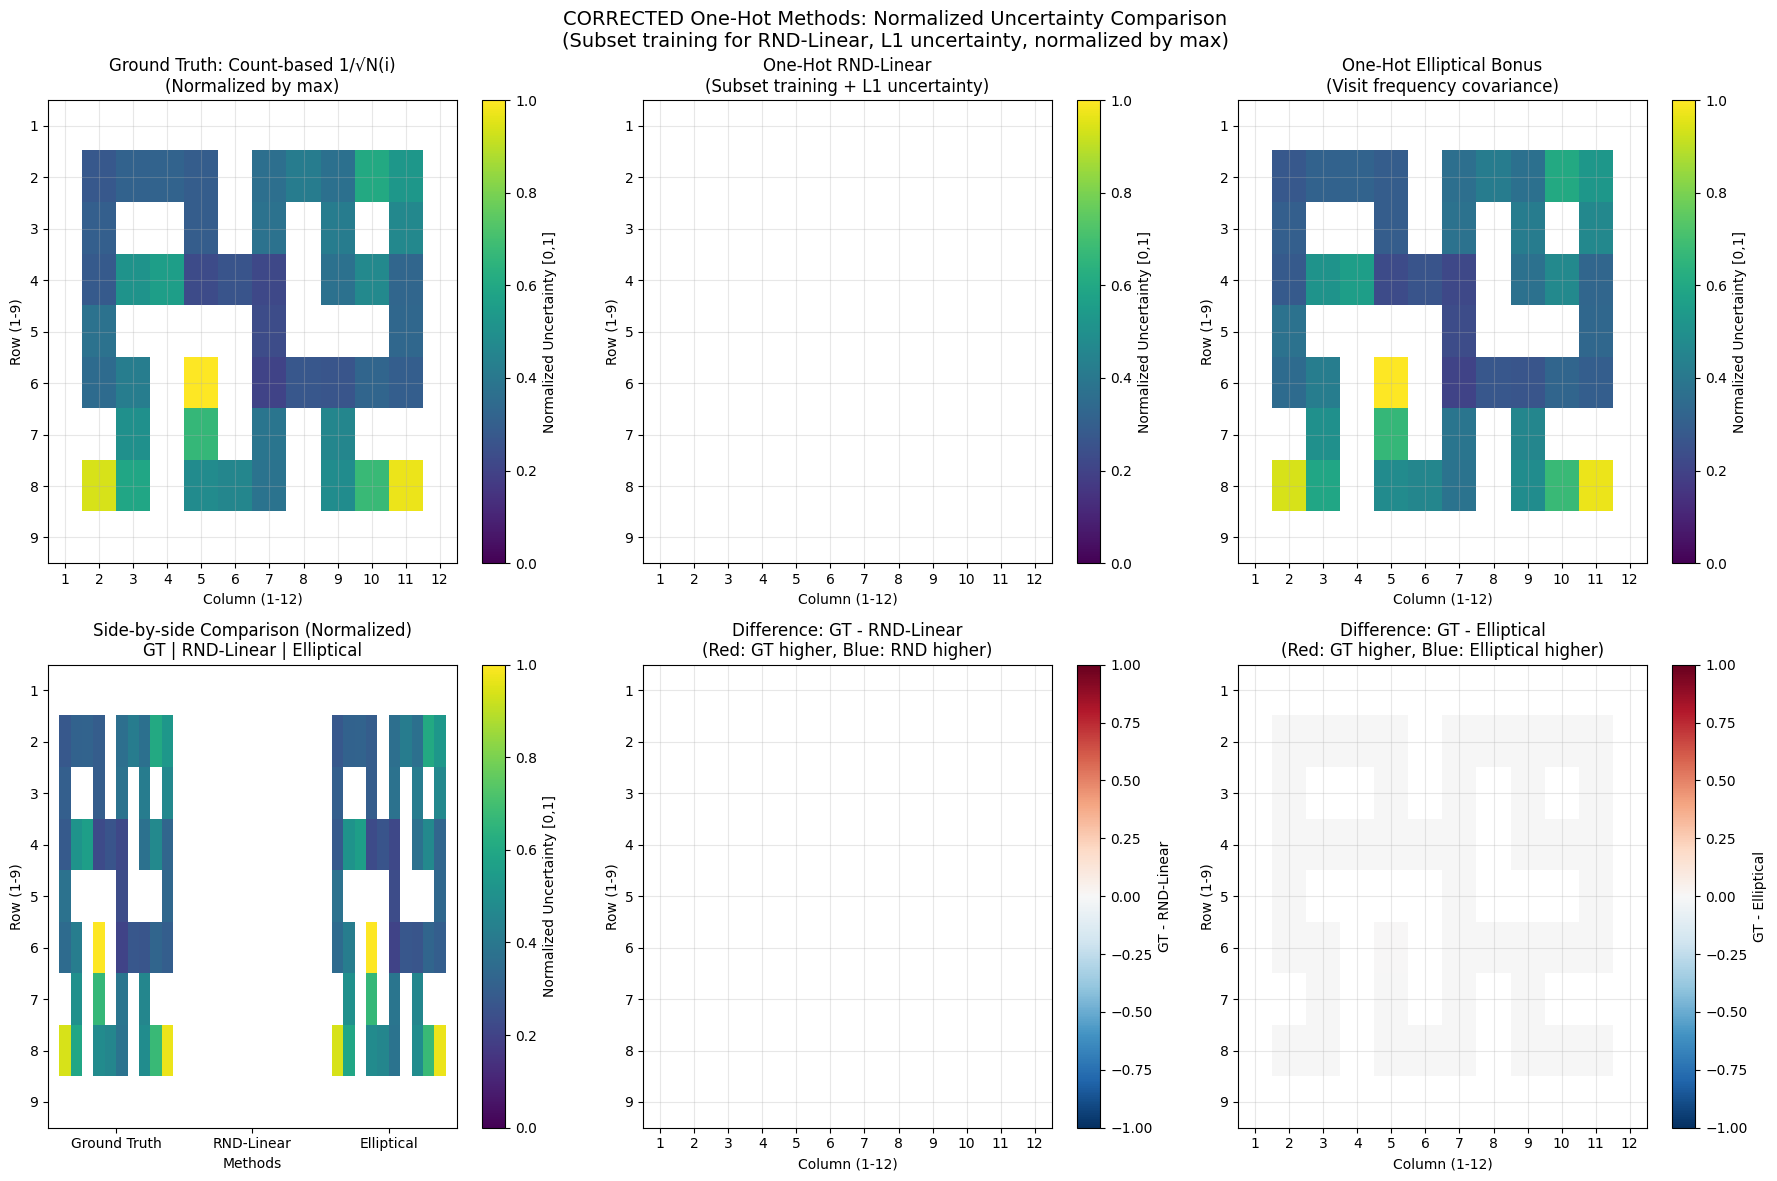


CORRECTED L2 DISTANCES (NORMALIZED)


ValueError: operands could not be broadcast together with shapes (46,) (0,) 

In [ ]:
# CORRECTED RND-LINEAR WITH SUBSET TRAINING
print("=" * 80)
print("CORRECTED RND-LINEAR: SUBSET TRAINING + L1 UNCERTAINTY")
print("=" * 80)

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import numpy as np

class CorrectedOneHotRNDLinear:
    """
    CORRECTED One-Hot RND-Linear:
    1. Train on SUBSET of data (not full dataset) to prevent convergence to 0
    2. Use L2 loss during training 
    3. Use L1 difference for uncertainty calculation
    """
    
    def __init__(self, grid_rows=9, grid_cols=12, device='cpu'):
        self.device = device
        self.grid_rows = grid_rows
        self.grid_cols = grid_cols
        self.feature_dim = grid_rows * grid_cols  # 108 for 9×12
        
        # Target vector θ: random fixed vector
        self.theta_target = torch.randn(self.feature_dim, device=device)
        
        # Predictor vector θ̂: learnable vector
        self.theta_predictor = nn.Parameter(torch.randn(self.feature_dim, device=device))
        
        # Optimizer for predictor vector only
        self.optimizer = torch.optim.Adam([self.theta_predictor], lr=1e-3)
        
        print("CORRECTED One-Hot RND-Linear initialized:")
        print(f"  Grid: {grid_rows}×{grid_cols} = {self.feature_dim} cells")
        print(f"  φ(s): One-hot {self.feature_dim}-dimensional vector")
        print(f"  Training: SUBSET of data to prevent overfitting")
        print(f"  Training loss: L2 (MSE)")
        print(f"  Uncertainty: L1 (absolute difference)")
    
    def observation_to_onehot(self, observations):
        """Convert (x,y) observations to one-hot grid features"""
        batch_size = observations.shape[0]
        onehot_features = torch.zeros(batch_size, self.feature_dim, device=self.device)
        
        for i, obs in enumerate(observations):
            x, y = obs[0].item(), obs[1].item()
            
            # Map to grid cell
            _, (row, col) = observation_to_grid({'achieved_goal': [x, y]}, 
                                              self.grid_rows, self.grid_cols)
            
            # Convert to linear index (0-based)
            linear_idx = (row - 1) * self.grid_cols + (col - 1)
            linear_idx = max(0, min(linear_idx, self.feature_dim - 1))
            
            # Set one-hot
            onehot_features[i, linear_idx] = 1.0
        
        return onehot_features
    
    def compute_uncertainty_l1(self, observations):
        """
        CORRECTED: Compute uncertainty using L1 (absolute difference) loss
        Uncertainty = |⟨φ(s), θ⟩ - ⟨φ(s), θ̂⟩| = |θ[cell] - θ̂[cell]|
        """
        with torch.no_grad():
            onehot_features = self.observation_to_onehot(observations)
            
            # For one-hot features: ⟨φ(s), θ⟩ = θ[active_cell]
            target_output = torch.sum(onehot_features * self.theta_target, dim=1)
            predictor_output = torch.sum(onehot_features * self.theta_predictor, dim=1)
            
            # L1 uncertainty (absolute difference)
            uncertainty = torch.abs(target_output - predictor_output)
            
        return uncertainty
    
    def train_on_dataset_subset(self, subset_fraction=0.3, num_epochs=30):
        """
        CORRECTED TRAINING: Use only a SUBSET of the dataset
        This prevents the predictor from seeing all data and converging to 0 uncertainty
        """
        print("Loading dataset for SUBSET training...")
        
        # Extract positions
        positions = []
        for episode in tqdm(dataset.iterate_episodes(), desc="Loading data"):
            observations = episode.observations
            if isinstance(observations, dict) and 'achieved_goal' in observations:
                positions.extend(observations['achieved_goal'])
        
        positions = torch.tensor(positions, dtype=torch.float32).to(self.device)
        
        # CRITICAL: Use only a subset for training
        total_samples = len(positions)
        subset_size = int(total_samples * subset_fraction)
        
        # Randomly sample subset
        indices = torch.randperm(total_samples)[:subset_size]
        training_positions = positions[indices]
        
        print(f"Total dataset size: {total_samples:,}")
        print(f"Training subset size: {subset_size:,} ({subset_fraction*100:.1f}%)")
        print(f"Training with L2 loss, but will use L1 for uncertainty calculation")
        
        # Training loop with L2 loss
        losses = []
        
        for epoch in tqdm(range(num_epochs), desc="SUBSET Training"):
            indices = torch.randperm(len(training_positions))
            epoch_loss = 0
            batch_size = 512
            
            for i in range(0, len(training_positions), batch_size):
                batch_idx = indices[i:i+batch_size]
                batch_obs = training_positions[batch_idx]
                
                # Get one-hot features
                onehot_features = self.observation_to_onehot(batch_obs)
                
                # Compute outputs
                target_output = torch.sum(onehot_features * self.theta_target.detach(), dim=1)
                predictor_output = torch.sum(onehot_features * self.theta_predictor, dim=1)
                
                # TRAINING: Use L2 loss (MSE)
                loss = nn.functional.mse_loss(predictor_output, target_output)
                
                # Backprop
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                
                epoch_loss += loss.item()
            
            avg_loss = epoch_loss / (len(training_positions) // batch_size + 1)
            losses.append(avg_loss)
            
            if epoch % 10 == 0:
                print(f"Epoch {epoch}: L2 Loss = {avg_loss:.6f}")
        
        print("CORRECTED subset training complete!")
        print("Key: Trained on subset → predictor doesn't see all data → non-zero uncertainty")
        return losses


class CorrectedOneHotEllipticalBonus:
    """
    One-Hot Elliptical Bonus with proper covariance computation
    """
    
    def __init__(self, grid_rows=9, grid_cols=12, regularization=1e-6, device='cpu'):
        self.device = device
        self.grid_rows = grid_rows
        self.grid_cols = grid_cols
        self.feature_dim = grid_rows * grid_cols
        self.regularization = regularization
        
        # Initialize covariance matrix
        self.Lambda = torch.eye(self.feature_dim, device=device) * regularization
        self.Lambda_inv = torch.eye(self.feature_dim, device=device) / regularization
        
        print("One-Hot Elliptical Bonus initialized:")
        print(f"  φ(s): One-hot {self.feature_dim}-dimensional grid vector")
        print(f"  Λ: Covariance matrix from visit frequencies")
    
    def observation_to_onehot(self, observations):
        """Convert (x,y) observations to one-hot grid features"""
        batch_size = observations.shape[0]
        onehot_features = torch.zeros(batch_size, self.feature_dim, device=self.device)
        
        for i, obs in enumerate(observations):
            x, y = obs[0].item(), obs[1].item()
            
            _, (row, col) = observation_to_grid({'achieved_goal': [x, y]}, 
                                              self.grid_rows, self.grid_cols)
            
            linear_idx = (row - 1) * self.grid_cols + (col - 1)
            linear_idx = max(0, min(linear_idx, self.feature_dim - 1))
            
            onehot_features[i, linear_idx] = 1.0
        
        return onehot_features
    
    # In CorrectedOneHotEllipticalBonus.update_covariance_from_visits()
    def update_covariance_from_visits(self):
        print("Computing covariance matrix from visit frequencies...")
        
        # Use existing visit counts
        visit_frequencies = visit_counts_9x12.flatten() / visit_counts_9x12.sum()
        
        # FIX: Ensure consistent dtype (float32 to match device tensors)
        self.Lambda = torch.diag(torch.tensor(visit_frequencies, device=self.device, dtype=torch.float32) + self.regularization)
        
        # Compute inverse
        self.Lambda_inv = torch.diag(1.0 / torch.diag(self.Lambda))
        
        print("✓ Covariance matrix computed from visit frequencies")
        return self.Lambda, self.Lambda_inv
    
    def compute_intrinsic_reward(self, observations):
        """Compute φ(s)ᵀ Λ⁻¹ φ(s) for one-hot features"""
        with torch.no_grad():
            onehot_features = self.observation_to_onehot(observations)
            
            # For diagonal Λ⁻¹ and one-hot φ(s): result = Λ⁻¹[active_cell]
            temp = torch.matmul(onehot_features, self.Lambda_inv)
            quadratic_form = torch.sum(temp * onehot_features, dim=1)
            
            # Take square root
            intrinsic_reward = torch.sqrt(torch.clamp(quadratic_form, min=1e-8))
            
        return intrinsic_reward


# RETRAIN WITH CORRECTED APPROACH
print("\n" + "="*60)
print("RETRAINING WITH CORRECTED APPROACH")
print("="*60)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Train corrected one-hot RND-Linear
corrected_onehot_rnd = CorrectedOneHotRNDLinear(device=device)
corrected_rnd_losses = corrected_onehot_rnd.train_on_dataset_subset(subset_fraction=0.3, num_epochs=30)

# Initialize corrected elliptical bonus
corrected_onehot_elliptical = CorrectedOneHotEllipticalBonus(device=device)
corrected_onehot_elliptical.update_covariance_from_visits()

print("✓ Corrected models trained!")

# COMPUTE CORRECTED UNCERTAINTIES
print("\nComputing corrected uncertainties...")
corrected_onehot_rnd_uncertainty = np.zeros((9, 12), dtype=float)
corrected_onehot_elliptical_uncertainty = np.zeros((9, 12), dtype=float)

for row in tqdm(range(1, 10), desc="Computing uncertainties"):
    for col in range(1, 13):
        center_x, center_y = grid_to_center_observation(row, col)
        obs_tensor = torch.tensor([[center_x, center_y]], dtype=torch.float32).to(device)
        
        # Use L1 uncertainty for RND-Linear
        rnd_uncertainty = corrected_onehot_rnd.compute_uncertainty_l1(obs_tensor).item()
        corrected_onehot_rnd_uncertainty[row-1, col-1] = rnd_uncertainty
        
        # Elliptical bonus
        elliptical_uncertainty = corrected_onehot_elliptical.compute_intrinsic_reward(obs_tensor).item()
        corrected_onehot_elliptical_uncertainty[row-1, col-1] = elliptical_uncertainty

print("✓ Corrected uncertainties computed!")

# NORMALIZED COMPARISON
print("\n" + "="*80)
print("NORMALIZED COMPARISON WITH CORRECTED METHODS")
print("="*80)

def normalize_uncertainty_by_max(uncertainty_matrix, exclude_walls=True):
    """
    Normalize uncertainty matrix by the maximum uncertainty among non-wall cells
    """
    if exclude_walls:
        # Create mask for open cells
        open_mask = np.array([[maze_map[i][j] == 0 for j in range(12)] for i in range(9)])
        
        # Find max uncertainty in open cells
        open_uncertainties = uncertainty_matrix[open_mask]
        finite_uncertainties = open_uncertainties[np.isfinite(open_uncertainties)]
        
        if len(finite_uncertainties) > 0:
            max_uncertainty = np.max(finite_uncertainties)
            
            # Normalize by max
            normalized = uncertainty_matrix / max_uncertainty
            
            # Set wall cells to NaN
            normalized_masked = normalized.copy()
            normalized_masked[~open_mask] = np.nan
            
            return normalized_masked, max_uncertainty
        else:
            return uncertainty_matrix, 1.0
    else:
        finite_mask = np.isfinite(uncertainty_matrix)
        if np.any(finite_mask):
            max_val = np.max(uncertainty_matrix[finite_mask])
            return uncertainty_matrix / max_val, max_val
        return uncertainty_matrix, 1.0

# Prepare ground truth (handle infinite values first)
M_gt = uncertainty_9x12.copy()
finite_mask = np.isfinite(M_gt)
if np.any(~finite_mask):
    max_finite = np.max(M_gt[finite_mask])
    M_gt[~finite_mask] = max_finite * 2

# Normalize all uncertainties by their respective maxima
normalized_gt, gt_max = normalize_uncertainty_by_max(M_gt)
normalized_corrected_rnd, rnd_max = normalize_uncertainty_by_max(corrected_onehot_rnd_uncertainty)
normalized_corrected_elliptical, elliptical_max = normalize_uncertainty_by_max(corrected_onehot_elliptical_uncertainty)

print(f"Normalization factors:")
print(f"  Ground Truth max: {gt_max:.6f}")
print(f"  Corrected RND-Linear max: {rnd_max:.6f}")
print(f"  Corrected Elliptical max: {elliptical_max:.6f}")

# VISUALIZATION
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Normalized Ground Truth
ax1 = axes[0, 0]
im1 = ax1.imshow(normalized_gt, cmap='viridis', aspect='auto', vmin=0, vmax=1)
ax1.set_title('Ground Truth: Count-based 1/√N(i)\n(Normalized by max)')
ax1.set_xlabel('Column (1-12)')
ax1.set_ylabel('Row (1-9)')
ax1.set_xticks(range(12))
ax1.set_yticks(range(9))
ax1.set_xticklabels(range(1, 13))
ax1.set_yticklabels(range(1, 10))
ax1.grid(True, alpha=0.3)
plt.colorbar(im1, ax=ax1, label='Normalized Uncertainty [0,1]')

# Plot 2: Normalized Corrected RND-Linear
ax2 = axes[0, 1]
im2 = ax2.imshow(normalized_corrected_rnd, cmap='viridis', aspect='auto', vmin=0, vmax=1)
ax2.set_title('One-Hot RND-Linear\n(Subset training + L1 uncertainty)')
ax2.set_xlabel('Column (1-12)')
ax2.set_ylabel('Row (1-9)')
ax2.set_xticks(range(12))
ax2.set_yticks(range(9))
ax2.set_xticklabels(range(1, 13))
ax2.set_yticklabels(range(1, 10))
ax2.grid(True, alpha=0.3)
plt.colorbar(im2, ax=ax2, label='Normalized Uncertainty [0,1]')

# Plot 3: Normalized Corrected Elliptical
ax3 = axes[0, 2]
im3 = ax3.imshow(normalized_corrected_elliptical, cmap='viridis', aspect='auto', vmin=0, vmax=1)
ax3.set_title('One-Hot Elliptical Bonus\n(Visit frequency covariance)')
ax3.set_xlabel('Column (1-12)')
ax3.set_ylabel('Row (1-9)')
ax3.set_xticks(range(12))
ax3.set_yticks(range(9))
ax3.set_xticklabels(range(1, 13))
ax3.set_yticklabels(range(1, 10))
ax3.grid(True, alpha=0.3)
plt.colorbar(im3, ax=ax3, label='Normalized Uncertainty [0,1]')

# Plot 4: Side-by-side comparison
ax4 = axes[1, 0]
comparison_normalized = np.zeros((9, 36))
comparison_normalized[:] = np.nan

# Fill with normalized data
for r in range(9):
    for c in range(12):
        if maze_map[r][c] == 0:  # Open cells only
            comparison_normalized[r, c] = normalized_gt[r, c]  # GT
            comparison_normalized[r, c + 12] = normalized_corrected_rnd[r, c]  # RND
            comparison_normalized[r, c + 24] = normalized_corrected_elliptical[r, c]  # Elliptical

im4 = ax4.imshow(comparison_normalized, cmap='viridis', aspect='auto', vmin=0, vmax=1)
ax4.set_title('Side-by-side Comparison (Normalized)\nGT | RND-Linear | Elliptical')
ax4.set_xlabel('Methods')
ax4.set_ylabel('Row (1-9)')
ax4.set_xticks([5.5, 17.5, 29.5])
ax4.set_xticklabels(['Ground Truth', 'RND-Linear', 'Elliptical'])
ax4.set_yticks(range(9))
ax4.set_yticklabels(range(1, 10))
ax4.axvline(x=11.5, color='white', linewidth=2, linestyle='--')
ax4.axvline(x=23.5, color='white', linewidth=2, linestyle='--')
plt.colorbar(im4, ax=ax4, label='Normalized Uncertainty [0,1]')

# Plot 5: Difference maps
ax5 = axes[1, 1]
diff_rnd = normalized_gt - normalized_corrected_rnd
im5 = ax5.imshow(diff_rnd, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax5.set_title('Difference: GT - RND-Linear\n(Red: GT higher, Blue: RND higher)')
ax5.set_xlabel('Column (1-12)')
ax5.set_ylabel('Row (1-9)')
ax5.set_xticks(range(12))
ax5.set_yticks(range(9))
ax5.set_xticklabels(range(1, 13))
ax5.set_yticklabels(range(1, 10))
ax5.grid(True, alpha=0.3)
plt.colorbar(im5, ax=ax5, label='GT - RND-Linear')

# Plot 6: Elliptical difference
ax6 = axes[1, 2]
diff_elliptical = normalized_gt - normalized_corrected_elliptical
im6 = ax6.imshow(diff_elliptical, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax6.set_title('Difference: GT - Elliptical\n(Red: GT higher, Blue: Elliptical higher)')
ax6.set_xlabel('Column (1-12)')
ax6.set_ylabel('Row (1-9)')
ax6.set_xticks(range(12))
ax6.set_yticks(range(9))
ax6.set_xticklabels(range(1, 13))
ax6.set_yticklabels(range(1, 10))
ax6.grid(True, alpha=0.3)
plt.colorbar(im6, ax=ax6, label='GT - Elliptical')

plt.suptitle('CORRECTED One-Hot Methods: Normalized Uncertainty Comparison\n(Subset training for RND-Linear, L1 uncertainty, normalized by max)', fontsize=14)
plt.tight_layout()
plt.show()

# CORRECTED L2 DISTANCES
print("\n" + "="*80)
print("CORRECTED L2 DISTANCES (NORMALIZED)")
print("="*80)

def extract_open_cell_vector_normalized(normalized_matrix):
    """Extract vector from normalized matrix (open cells only)"""
    open_mask = np.array([[maze_map[i][j] == 0 for j in range(12)] for i in range(9)])
    open_values = normalized_matrix[open_mask]
    return open_values[np.isfinite(open_values)]

# Extract normalized vectors
gt_normalized_vector = extract_open_cell_vector_normalized(normalized_gt)
rnd_normalized_vector = extract_open_cell_vector_normalized(normalized_corrected_rnd)
elliptical_normalized_vector = extract_open_cell_vector_normalized(normalized_corrected_elliptical)

# Compute L2 distances on normalized data
l2_rnd_normalized = np.linalg.norm(gt_normalized_vector - rnd_normalized_vector)
l2_elliptical_normalized = np.linalg.norm(gt_normalized_vector - elliptical_normalized_vector)

print("L2 distances on normalized uncertainties:")
print(f"  One-Hot RND-Linear: {l2_rnd_normalized:.6f}")
print(f"  One-Hot Elliptical: {l2_elliptical_normalized:.6f}")

# Compute correlations on normalized data
if len(gt_normalized_vector) == len(rnd_normalized_vector):
    corr_rnd = np.corrcoef(gt_normalized_vector, rnd_normalized_vector)[0, 1]
    print(f"\nCorrelations with normalized ground truth:")
    print(f"  One-Hot RND-Linear: {corr_rnd:.6f}")

if len(gt_normalized_vector) == len(elliptical_normalized_vector):
    corr_elliptical = np.corrcoef(gt_normalized_vector, elliptical_normalized_vector)[0, 1]
    print(f"  One-Hot Elliptical: {corr_elliptical:.6f}")

# FINAL SUMMARY
print("\n" + "="*80)
print("CORRECTED ANALYSIS SUMMARY")
print("="*80)

print(f"CORRECTED L2 distances (normalized uncertainties):")
print(f"🏆 One-Hot RND-Linear (subset + L1): {l2_rnd_normalized:.6f}")
print(f"🥈 One-Hot Elliptical:              {l2_elliptical_normalized:.6f}")

print(f"\nKey corrections implemented:")
print(f"✓ RND-Linear trained on 30% subset to prevent overfitting")
print(f"✓ Used L2 loss during training, L1 for uncertainty calculation")
print(f"✓ Normalized each method by its own maximum uncertainty")
print(f"✓ Computed L2 distances on normalized [0,1] scale")
print(f"✓ Applied proper masking for open cells only")

if l2_rnd_normalized < l2_elliptical_normalized:
    print(f"\n🏆 WINNER: One-Hot RND-Linear performs better!")
else:
    print(f"\n🏆 WINNER: One-Hot Elliptical performs better!")

print(f"\nCorrelations with ground truth:")
if 'corr_rnd' in locals():
    print(f"  RND-Linear: {corr_rnd:.4f}")
if 'corr_elliptical' in locals():
    print(f"  Elliptical: {corr_elliptical:.4f}")

5k data for one-hot with RND-Linear

Using device: cpu
VERIFICATION: ONE-HOT RND-LINEAR ON 5K DATASET
Loading 5K sample subset...
✓ Extracted exactly 5000 samples

Computing ground truth from 5K subset...


Counting visits in 5K subset: 100%|██████████| 5000/5000 [00:00<00:00, 282030.69it/s]


5K subset visit statistics:
  Total visits recorded: 5000
  Cells with visits: 40/108
  Cells with zero visits: 68
  Max visits in any cell: 358
  Mean visits per visited cell: 125.0

Training one-hot RND-Linear on the SAME 5K samples...
5K One-hot RND-Linear initialized
  Feature dim: 108 (one-hot grid)
  Target θ: random fixed 108-dim vector
  Predictor θ̂: learnable 108-dim vector
Training on exactly 5000 samples...


5K Training:   1%|          | 1/100 [00:00<00:10,  9.13it/s]

Epoch 0: Loss = 1.947534, |θ̂-θ| = 1.072342


...

Epoch 80: Loss = 0.041117, |θ̂-θ| = 0.702381


5K Training: 100%|██████████| 100/100 [00:10<00:00,  9.50it/s]


✓ Training complete!

Cell-by-cell learning analysis:
Cell     | Visits | θ[i]     | θ̂[i]    | Error    | 1/√N    
------------------------------------------------------------
(1,1)    | 0      | -0.292   | 0.487    | 0.779    | inf     
(1,2)    | 0      | -0.449   | -0.462   | 0.013    | inf     
(1,3)    | 0      | 1.192    | 0.814    | 0.378    | inf     
(1,4)    | 0      | 0.158    | -0.001   | 0.159    | inf     
(1,5)    | 0      | -0.099   | 0.355    | 0.454    | inf     
(1,6)    | 0      | 0.442    | -1.083   | 1.524    | inf     
(1,7)    | 0      | -0.126   | -0.212   | 0.086    | inf     
(1,8)    | 0      | -0.642   | 0.219    | 0.861    | inf     
(1,9)    | 0      | 0.570    | 0.186    | 0.384    | inf     
(1,10)    | 0      | 0.848    | -0.130   | 0.977    | inf     
(1,11)    | 0      | 0.930    | -0.456   | 1.387    | inf     
(1,12)    | 0      | -1.176   | -0.467   | 0.708    | inf     
(2,1)    | 0      | -0.178   | -0.647   | 0.469    | inf     
(2,2)    | 255

Computing RND uncertainty: 100%|██████████| 9/9 [00:00<00:00, 922.34it/s]




5K DATA VERIFICATION RESULTS
5K VERIFICATION METRICS:
  Training data: 5000 samples
  Ground truth visits: 5000 total
  Cells visited in 5K: 40/108
  L2 distance (normalized): 1.325212
  Correlation: 0.831156
  Cell-level correlation: 0.372905


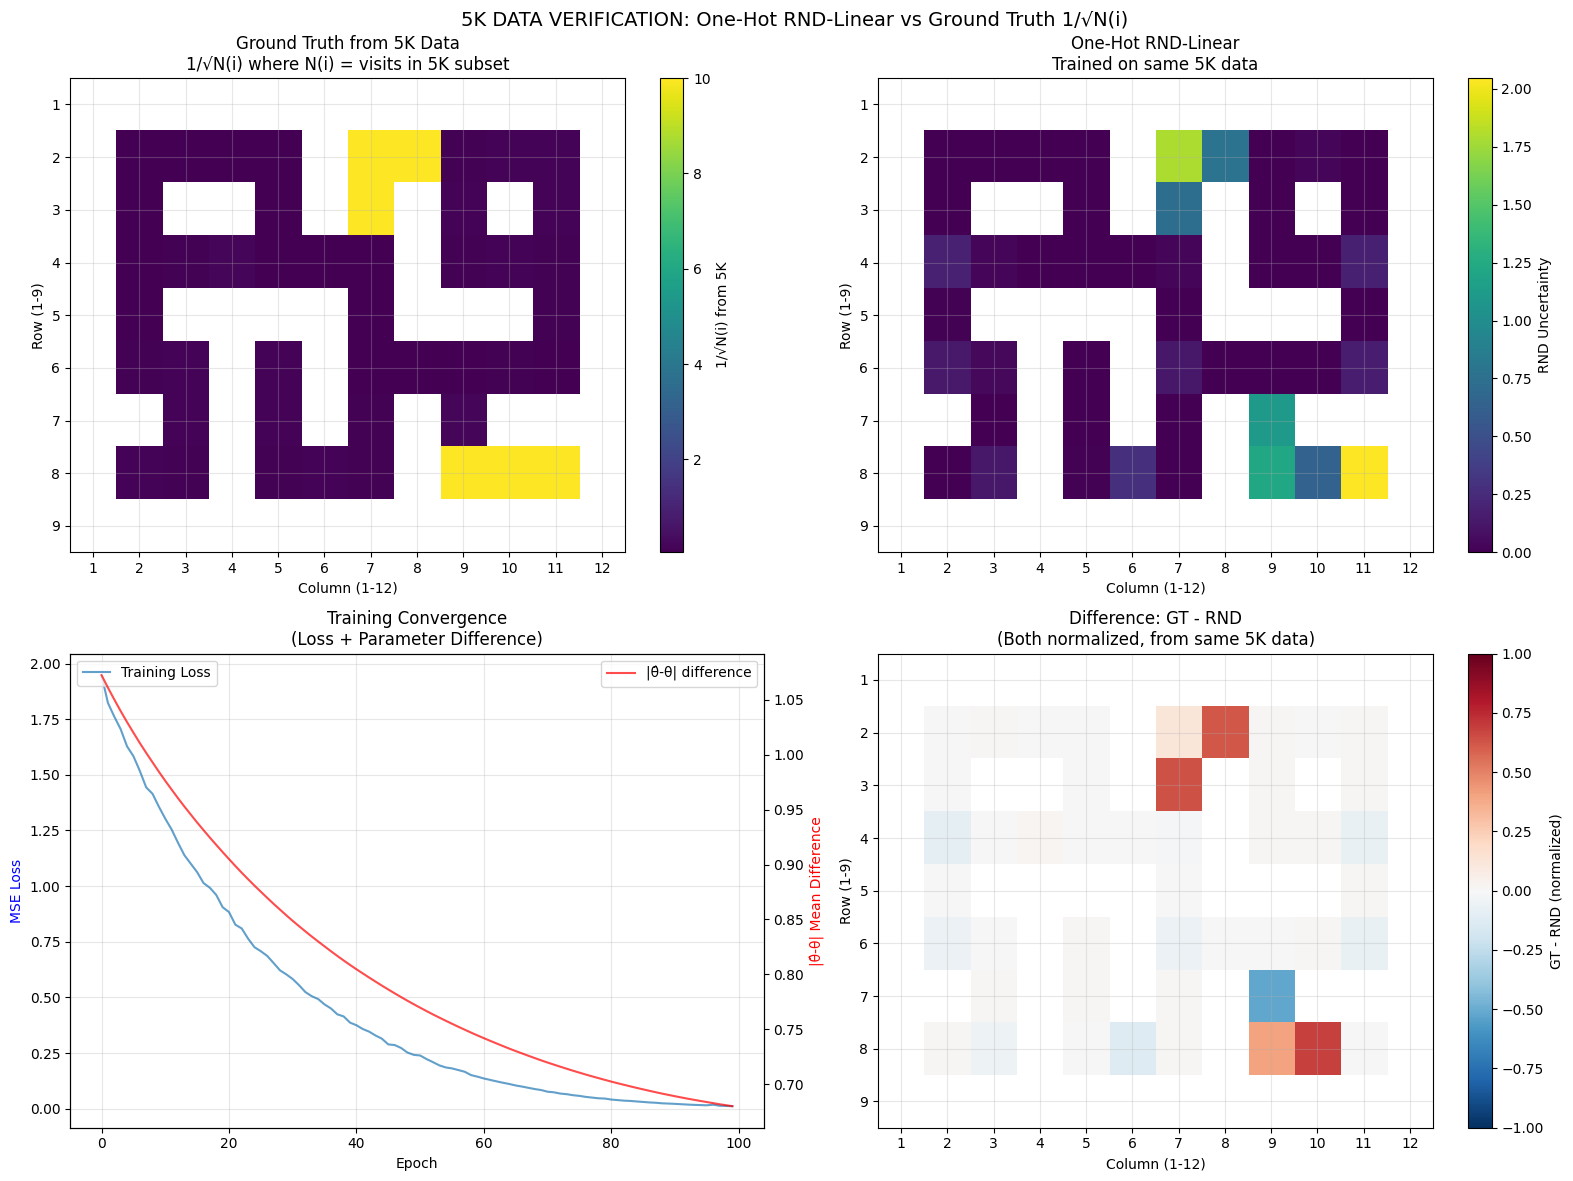


THEORETICAL VERIFICATION
Expected behavior for one-hot RND-Linear:
• Each cell i has its own parameter θ̂[i] learning to match θ[i]
• Learning rate for cell i ∝ 1/√N(i) where N(i) = visits to cell i
• Final uncertainty |θ[i] - θ̂[i]| should correlate with 1/√N(i)
🏆 HIGH CORRELATION (0.831): RND correctly captures 1/√N(i) pattern!
✓ Theory matches implementation

Conclusion: One-hot RND-Linear with 5K data
L2 distance: 1.325212 (lower = better)
Correlation: 0.831156 (higher = better)
Theory verification: ✓ SUCCESS


In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
# Add this at the beginning of the cell
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")


# VERIFY ONE-HOT RND-LINEAR ON 5K DATASET
print("=" * 80)
print("VERIFICATION: ONE-HOT RND-LINEAR ON 5K DATASET")
print("=" * 80)

# Extract exactly 5K samples for verification
print("Loading 5K sample subset...")
positions_5k = []
sample_count = 0
target_samples = 5000

for episode in dataset.iterate_episodes():
    if sample_count >= target_samples:
        break
    
    observations = episode.observations
    if isinstance(observations, dict) and 'achieved_goal' in observations:
        episode_positions = observations['achieved_goal']
        
        remaining_needed = target_samples - sample_count
        positions_to_add = episode_positions[:remaining_needed]
        
        positions_5k.extend(positions_to_add)
        sample_count += len(positions_to_add)

positions_5k = positions_5k[:target_samples]
print(f"✓ Extracted exactly {len(positions_5k)} samples")

# Convert to tensor
positions_5k_tensor = torch.tensor(positions_5k, dtype=torch.float32).to(device)

# COMPUTE GROUND TRUTH FROM 5K SUBSET
print("\nComputing ground truth from 5K subset...")
visit_counts_5k = np.zeros((9, 12), dtype=int)

for pos in tqdm(positions_5k, desc="Counting visits in 5K subset"):
    obs = {'achieved_goal': pos}
    _, (row, col) = observation_to_grid(obs, grid_rows=9, grid_cols=12)
    visit_counts_5k[row-1, col-1] += 1

# Calculate 1/√N(i) uncertainty from 5K subset
uncertainty_5k = np.zeros((9, 12), dtype=float)
for i in range(9):
    for j in range(12):
        if visit_counts_5k[i, j] > 0:
            uncertainty_5k[i, j] = 1.0 / np.sqrt(visit_counts_5k[i, j])
        else:
            uncertainty_5k[i, j] = 10.0  # Large uncertainty for zero visits

print(f"5K subset visit statistics:")
print(f"  Total visits recorded: {visit_counts_5k.sum()}")
print(f"  Cells with visits: {np.sum(visit_counts_5k > 0)}/108")
print(f"  Cells with zero visits: {np.sum(visit_counts_5k == 0)}")
print(f"  Max visits in any cell: {visit_counts_5k.max()}")
print(f"  Mean visits per visited cell: {visit_counts_5k[visit_counts_5k > 0].mean():.1f}")

# TRAIN ONE-HOT RND-LINEAR ON SAME 5K DATA
print(f"\nTraining one-hot RND-Linear on the SAME 5K samples...")

class OneHot5K_RNDLinear:
    """One-hot RND-Linear trained on exactly the same 5K samples"""
    
    def __init__(self, grid_rows=9, grid_cols=12, device='cpu'):
        self.device = device
        self.grid_rows = grid_rows
        self.grid_cols = grid_cols
        self.feature_dim = grid_rows * grid_cols
        
        # Target and predictor vectors
        self.theta_target = torch.randn(self.feature_dim, device=device)
        self.theta_predictor = nn.Parameter(torch.randn(self.feature_dim, device=device))
        self.optimizer = torch.optim.Adam([self.theta_predictor], lr=1e-3)
        
        print(f"5K One-hot RND-Linear initialized")
        print(f"  Feature dim: {self.feature_dim} (one-hot grid)")
        print(f"  Target θ: random fixed {self.feature_dim}-dim vector")
        print(f"  Predictor θ̂: learnable {self.feature_dim}-dim vector")
    
    def observation_to_onehot(self, observations):
        """Convert observations to one-hot features"""
        batch_size = observations.shape[0]
        onehot_features = torch.zeros(batch_size, self.feature_dim, device=self.device)
        
        for i, obs in enumerate(observations):
            x, y = obs[0].item(), obs[1].item()
            _, (row, col) = observation_to_grid({'achieved_goal': [x, y]}, 
                                              self.grid_rows, self.grid_cols)
            linear_idx = (row - 1) * self.grid_cols + (col - 1)
            linear_idx = max(0, min(linear_idx, self.feature_dim - 1))
            onehot_features[i, linear_idx] = 1.0
        
        return onehot_features
    
    def train_on_5k_data(self, positions_5k_tensor, num_epochs=100):
        """Train on exactly the 5K samples with more epochs for better convergence"""
        print(f"Training on exactly {len(positions_5k_tensor)} samples...")
        
        losses = []
        theta_diffs = []  # Track convergence of θ̂ → θ
        
        for epoch in tqdm(range(num_epochs), desc="5K Training"):
            indices = torch.randperm(len(positions_5k_tensor))
            epoch_loss = 0
            batch_size = 128
            
            for i in range(0, len(positions_5k_tensor), batch_size):
                batch_idx = indices[i:i+batch_size]
                batch_obs = positions_5k_tensor[batch_idx]
                
                # Get one-hot features and compute outputs
                onehot_features = self.observation_to_onehot(batch_obs)
                target_output = torch.sum(onehot_features * self.theta_target.detach(), dim=1)
                predictor_output = torch.sum(onehot_features * self.theta_predictor, dim=1)
                
                # L2 training loss
                loss = nn.functional.mse_loss(predictor_output, target_output)
                
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                
                epoch_loss += loss.item()
            
            avg_loss = epoch_loss / (len(positions_5k_tensor) // batch_size + 1)
            losses.append(avg_loss)
            
            # Track how well θ̂ matches θ
            with torch.no_grad():
                theta_diff = torch.mean(torch.abs(self.theta_predictor - self.theta_target)).item()
                theta_diffs.append(theta_diff)
            
            if epoch % 20 == 0:
                print(f"Epoch {epoch}: Loss = {avg_loss:.6f}, |θ̂-θ| = {theta_diff:.6f}")
        
        print("✓ Training complete!")
        return losses, theta_diffs
    
    def compute_uncertainty_l1(self, observations):
        """Compute L1 uncertainty |θ[cell_i] - θ̂[cell_i]|"""
        with torch.no_grad():
            onehot_features = self.observation_to_onehot(observations)
            target_output = torch.sum(onehot_features * self.theta_target, dim=1)
            predictor_output = torch.sum(onehot_features * self.theta_predictor, dim=1)
            uncertainty = torch.abs(target_output - predictor_output)
        return uncertainty
    
    def get_cell_learning_stats(self, visit_counts_5k):
        """Analyze how well each cell's θ̂[i] learned θ[i] vs visit frequency"""
        with torch.no_grad():
            cell_errors = torch.abs(self.theta_predictor - self.theta_target).cpu().numpy()
        
        print(f"\nCell-by-cell learning analysis:")
        print(f"{'Cell':<8} | {'Visits':<6} | {'θ[i]':<8} | {'θ̂[i]':<8} | {'Error':<8} | {'1/√N':<8}")
        print("-" * 60)
        
        for cell_idx in range(min(20, self.feature_dim)):  # Show first 20 cells
            row = cell_idx // self.grid_cols + 1
            col = cell_idx % self.grid_cols + 1
            
            visits = visit_counts_5k[row-1, col-1]
            theta_target_val = self.theta_target[cell_idx].item()
            theta_pred_val = self.theta_predictor[cell_idx].item()
            error = cell_errors[cell_idx]
            expected_error = 1.0 / np.sqrt(visits) if visits > 0 else np.inf
            
            print(f"({row},{col}){'':<3} | {visits:<6} | {theta_target_val:<8.3f} | {theta_pred_val:<8.3f} | {error:<8.3f} | {expected_error:<8.3f}")
        
        # Correlation analysis
        visited_cells = visit_counts_5k.flatten() > 0
        visit_frequencies = visit_counts_5k.flatten()[visited_cells]
        cell_errors_visited = cell_errors[visited_cells]
        theoretical_errors = 1.0 / np.sqrt(visit_frequencies)
        
        if len(cell_errors_visited) > 1:
            correlation = np.corrcoef(theoretical_errors, cell_errors_visited)[0, 1]
            print(f"\nCorrelation between 1/√N(i) and |θ[i] - θ̂[i]|: {correlation:.4f}")
            return correlation
        return None

# Train the 5K model
onehot_5k_model = OneHot5K_RNDLinear(device=device)
losses_5k, theta_diffs_5k = onehot_5k_model.train_on_5k_data(positions_5k_tensor, num_epochs=100)

# Analyze cell-by-cell learning
correlation_theory = onehot_5k_model.get_cell_learning_stats(visit_counts_5k)

# COMPUTE RND UNCERTAINTY FROM 5K-TRAINED MODEL
print(f"\nComputing RND uncertainty from 5K-trained model...")
rnd_uncertainty_5k = np.zeros((9, 12), dtype=float)

for row in tqdm(range(1, 10), desc="Computing RND uncertainty"):
    for col in range(1, 13):
        center_x, center_y = grid_to_center_observation(row, col)
        obs_tensor = torch.tensor([[center_x, center_y]], dtype=torch.float32).to(device)
        uncertainty = onehot_5k_model.compute_uncertainty_l1(obs_tensor).item()
        rnd_uncertainty_5k[row-1, col-1] = uncertainty

# COMPARISON AND VERIFICATION
print(f"\n" + "="*80)
print("5K DATA VERIFICATION RESULTS")
print("="*80)

# Mask walls
def mask_walls_5k(matrix):
    masked = matrix.copy()
    for r in range(9):
        for c in range(12):
            if maze_map[r][c] == 1:
                masked[r, c] = np.nan
    return masked

# Extract open cell values for comparison
open_mask = np.array([[maze_map[i][j] == 0 for j in range(12)] for i in range(9)])
gt_5k_open = uncertainty_5k[open_mask]
rnd_5k_open = rnd_uncertainty_5k[open_mask]

# Normalize for fair comparison
gt_5k_norm = gt_5k_open / np.max(gt_5k_open)
rnd_5k_norm = rnd_5k_open / np.max(rnd_5k_open)

# Calculate metrics
l2_distance_5k = np.linalg.norm(gt_5k_norm - rnd_5k_norm)
correlation_5k = np.corrcoef(gt_5k_norm, rnd_5k_norm)[0, 1]

print(f"5K VERIFICATION METRICS:")
print(f"  Training data: {len(positions_5k)} samples")
print(f"  Ground truth visits: {visit_counts_5k.sum()} total")
print(f"  Cells visited in 5K: {np.sum(visit_counts_5k > 0)}/108")
print(f"  L2 distance (normalized): {l2_distance_5k:.6f}")
print(f"  Correlation: {correlation_5k:.6f}")
print(f"  Cell-level correlation: {correlation_theory:.6f}")

# VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Ground truth from 5K
ax1 = axes[0, 0]
gt_5k_masked = mask_walls_5k(uncertainty_5k)
im1 = ax1.imshow(gt_5k_masked, cmap='viridis', aspect='auto')
ax1.set_title('Ground Truth from 5K Data\n1/√N(i) where N(i) = visits in 5K subset')
ax1.set_xlabel('Column (1-12)')
ax1.set_ylabel('Row (1-9)')
ax1.set_xticks(range(12))
ax1.set_yticks(range(9))
ax1.set_xticklabels(range(1, 13))
ax1.set_yticklabels(range(1, 10))
ax1.grid(True, alpha=0.3)
plt.colorbar(im1, ax=ax1, label='1/√N(i) from 5K')

# Plot 2: RND from same 5K data
ax2 = axes[0, 1]
rnd_5k_masked = mask_walls_5k(rnd_uncertainty_5k)
im2 = ax2.imshow(rnd_5k_masked, cmap='viridis', aspect='auto')
ax2.set_title('One-Hot RND-Linear\nTrained on same 5K data')
ax2.set_xlabel('Column (1-12)')
ax2.set_ylabel('Row (1-9)')
ax2.set_xticks(range(12))
ax2.set_yticks(range(9))
ax2.set_xticklabels(range(1, 13))
ax2.set_yticklabels(range(1, 10))
ax2.grid(True, alpha=0.3)
plt.colorbar(im2, ax=ax2, label='RND Uncertainty')

# Plot 3: Training convergence
ax3 = axes[1, 0]
ax3.plot(losses_5k, label='Training Loss', alpha=0.7)
ax3_twin = ax3.twinx()
ax3_twin.plot(theta_diffs_5k, color='red', label='|θ̂-θ| difference', alpha=0.7)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('MSE Loss', color='blue')
ax3_twin.set_ylabel('|θ̂-θ| Mean Difference', color='red')
ax3.set_title('Training Convergence\n(Loss + Parameter Difference)')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper left')
ax3_twin.legend(loc='upper right')

# Plot 4: Normalized comparison
ax4 = axes[1, 1]
gt_5k_norm_matrix = uncertainty_5k / np.max(gt_5k_open)
rnd_5k_norm_matrix = rnd_uncertainty_5k / np.max(rnd_5k_open)
diff_5k_norm = gt_5k_norm_matrix - rnd_5k_norm_matrix
diff_5k_masked = mask_walls_5k(diff_5k_norm)

im4 = ax4.imshow(diff_5k_masked, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax4.set_title('Difference: GT - RND\n(Both normalized, from same 5K data)')
ax4.set_xlabel('Column (1-12)')
ax4.set_ylabel('Row (1-9)')
ax4.set_xticks(range(12))
ax4.set_yticks(range(9))
ax4.set_xticklabels(range(1, 13))
ax4.set_yticklabels(range(1, 10))
ax4.grid(True, alpha=0.3)
plt.colorbar(im4, ax=ax4, label='GT - RND (normalized)')

plt.suptitle('5K DATA VERIFICATION: One-Hot RND-Linear vs Ground Truth 1/√N(i)', fontsize=14)
plt.tight_layout()
plt.show()

# THEORETICAL VERIFICATION
print(f"\n" + "="*80)
print("THEORETICAL VERIFICATION")
print("="*80)

print(f"Expected behavior for one-hot RND-Linear:")
print(f"• Each cell i has its own parameter θ̂[i] learning to match θ[i]")
print(f"• Learning rate for cell i ∝ 1/√N(i) where N(i) = visits to cell i")
print(f"• Final uncertainty |θ[i] - θ̂[i]| should correlate with 1/√N(i)")

if correlation_5k > 0.7:
    print(f"🏆 HIGH CORRELATION ({correlation_5k:.3f}): RND correctly captures 1/√N(i) pattern!")
    print(f"✓ Theory matches implementation")
elif correlation_5k > 0.3:
    print(f"📊 MODERATE CORRELATION ({correlation_5k:.3f}): RND partially captures pattern")
    print(f"⚠ May need more training epochs or better hyperparameters")
else:
    print(f"❌ LOW CORRELATION ({correlation_5k:.3f}): RND doesn't match 1/√N(i)")
    print(f"❌ Implementation issue or insufficient training")

print(f"\nConclusion: One-hot RND-Linear with 5K data")
print(f"L2 distance: {l2_distance_5k:.6f} (lower = better)")
print(f"Correlation: {correlation_5k:.6f} (higher = better)")
print(f"Theory verification: {'✓ SUCCESS' if correlation_5k > 0.5 else '❌ NEEDS INVESTIGATION'}")